02/10/2025 verzija

In [ ]:
# !pip uninstall pybamm -y

Found existing installation: pybamm 25.4.3.dev106+g1de58edcd.d20250722
Uninstalling pybamm-25.4.3.dev106+g1de58edcd.d20250722:
  Successfully uninstalled pybamm-25.4.3.dev106+g1de58edcd.d20250722


In [ ]:
# ! pip install -e.

Obtaining file:///C:/Users/tabak/OneDrive%20-%20Univerza%20v%20Ljubljani%20%281%29/2.%20letnik/Magistrska%20naloga/PyBaMM/code/prenapetosti/mojPyBaMM/jasmina


ERROR: file:///C:/Users/tabak/OneDrive%20-%20Univerza%20v%20Ljubljani%20%281%29/2.%20letnik/Magistrska%20naloga/PyBaMM/code/prenapetosti/mojPyBaMM/jasmina does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.


In [1]:
# aktiviraj myenv okolje
import pybamm
import pybammeis 
import numpy as np
import matplotlib.pyplot as plt
import time
from ipywidgets import interact, FloatSlider
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from scipy import interpolate
from scipy import optimize

In [3]:
# Shrani slike
save_fig = False 

# Shrani animacijo
save_ani = False

# Formatiranje grafov
# Nastavitev velikosti grafa (širina, višina v inch-ih)
fig_size = figsize=(8, 6)  

# Nastavitev velikosti pisave
plt.rcParams.update({
    'font.size': 20,           # Osnovna velikost pisave
    'axes.titlesize': 20,      # Velikost naslova grafa
    'axes.labelsize': 20,      # Velikost pisave na osi
    'xtick.labelsize': 18,     # Velikost številk na x osi
    'ytick.labelsize': 18,     # Velikost številk na y osi
    'legend.fontsize': 18,     # Velikost pisave v legendi
})

## Nova koda

In [3]:
def my_current(t):
    return pybamm.sin( 2*np.pi * t *10)/1e1 # amplitude 0.1 A, frequency 10 Hz

t_eval = np.linspace(0, 1, 1000)

In [7]:
# model, ki ima le mehansko degradacijo
# model_DFN = pybamm.lithium_ion.BasicDFN()

model_DFN = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        name="Meh.",)

param0 = pybamm.ParameterValues("Ai2020") 
param0.update(
    {"Hydrostatic stress [Pa]": 0},
    check_already_exists=False  
)
param0["Current function [A]"] = my_current

param1 = pybamm.ParameterValues("Ai2020") 
param1.update(
    {"Hydrostatic stress [Pa]": 1e9},
    check_already_exists=False  
)
param1["Current function [A]"] = my_current

param2 = pybamm.ParameterValues("Ai2020") 
param2.update(
    {"Hydrostatic stress [Pa]": 2e9},
    check_already_exists=False  
)
param2["Current function [A]"] = my_current

var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

# experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
solver = pybamm.IDAKLUSolver()  

sim_DFN_0 = pybamm.Simulation(model= model_DFN, parameter_values=param0, var_pts=var_pts, solver=solver, 
                              #experiment=experiment 
                              )
sim_DFN_1 = pybamm.Simulation(model= model_DFN, parameter_values=param1, var_pts=var_pts, solver=solver, 
                              #experiment=experiment 
                              )
sim_DFN_2 = pybamm.Simulation(model= model_DFN, parameter_values=param2, var_pts=var_pts, solver=solver,
                              #experiment=experiment 
                              )

######################
# t_eval = [0, 3600]  
######################

start = time.time()
sol_DFN = sim_DFN_0.solve(t_eval=t_eval)
end = time.time()
print(f"Simulacija DFN_0 zaključena v {end - start:.2f} s.")

start = time.time()
sol_DFN_1 = sim_DFN_1.solve(t_eval=t_eval)
end = time.time()
print(f"Simulacija DFN_1 zaključena v {end - start:.2f} s.")

start = time.time()
sol_DFN_2 = sim_DFN_2.solve(t_eval=t_eval)
end = time.time()
print(f"Simulacija DFN_2 zaključena v {end - start:.2f} s.")

Simulacija DFN_0 zaključena v 6.78 s.
Simulacija DFN_1 zaključena v 6.07 s.
Simulacija DFN_2 zaključena v 5.37 s.


In [ ]:
# print("0 Pa: ", param0["Open-circuit voltage at 0% SOC [V]"])
# print("1 GPa: ", param1["Open-circuit voltage at 0% SOC [V]"])
# print("2 GPa: ", param2["Open-circuit voltage at 0% SOC [V]"])

0 Pa:  3.0
1 GPa:  3.0
2 GPa:  3.0


In [ ]:
# print("0 Pa: ", param0["Open-circuit voltage at 100% SOC [V]"])
# print("1 GPa: ", param1["Open-circuit voltage at 100% SOC [V]"])
# print("2 GPa: ", param2["Open-circuit voltage at 100% SOC [V]"])

0 Pa:  4.2
1 GPa:  4.2
2 GPa:  4.2


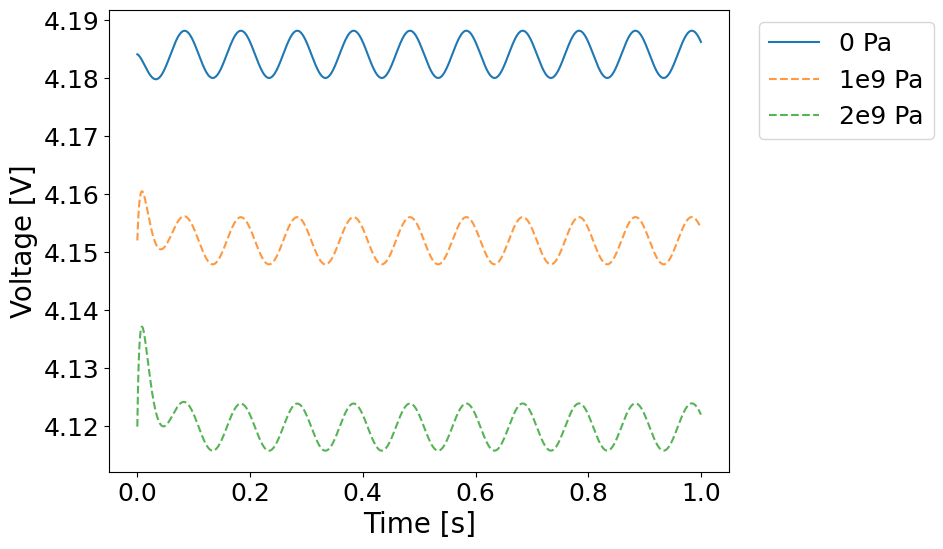

In [8]:
voltage = sol_DFN["Voltage [V]"].entries 
voltage_1 = sol_DFN_1["Voltage [V]"].entries
voltage_2 = sol_DFN_2["Voltage [V]"].entries
x = sol_DFN["Time [s]"].entries
x_1 = sol_DFN_1["Time [s]"].entries
x_2 = sol_DFN_2["Time [s]"].entries

plt.figure(figsize=fig_size)
plt.plot(x, voltage, label="0 Pa")
plt.plot(x_1, voltage_1, label="1e9 Pa", alpha=0.8, linestyle='--')
plt.plot(x_2, voltage_2, label="2e9 Pa", alpha=0.8, linestyle='--')
plt.xlabel("Time [s]")
plt.ylabel("Voltage [V]")
plt.legend(loc ='upper right', bbox_to_anchor=(1.35, 1))

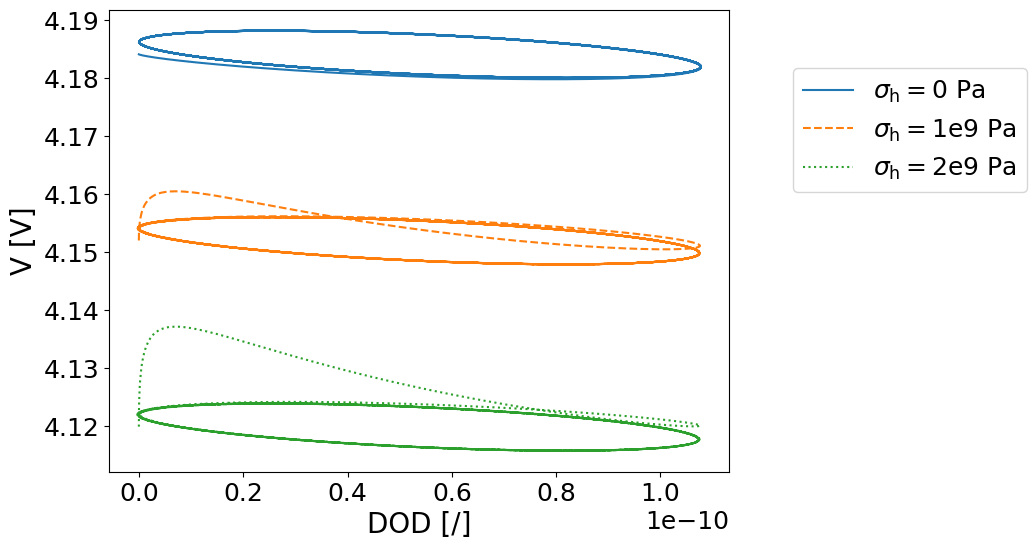

In [9]:
Q_discharged = sol_DFN["Discharge capacity [A.h]"].entries
# Q_max = Q_discharged[-1] 
Q_max = 2.28*3600
DOD = (Q_discharged / Q_max)

Q_discharged = sol_DFN_1["Discharge capacity [A.h]"].entries
# Q_max = Q_discharged[-1] 
Q_max = 2.28*3600
DOD_1 = (Q_discharged / Q_max)

Q_discharged = sol_DFN_2["Discharge capacity [A.h]"].entries
# Q_max = Q_discharged[-1] 
Q_max = 2.28*3600
DOD_2 = (Q_discharged / Q_max)

x_val = [DOD, 
         DOD_1,
        DOD_2
         ]
y_val = [sol_DFN["Voltage [V]"].data, 
         sol_DFN_1["Voltage [V]"].data,
        sol_DFN_2["Voltage [V]"].data
         ]

plt.figure(figsize=fig_size)
for i in range(len(x_val)):
    plt.plot(x_val[i], y_val[i], label=["$\sigma_{\mathrm{h}}=$0 Pa", 
                                        "$\sigma_{\mathrm{h}}=$1e9 Pa", 
                                        "$\sigma_{\mathrm{h}}=$2e9 Pa"
                                        
                                        ][i], 
                                        linestyle=["-", "--", ":", "-", "-", "-", "-", "-", "-", "-"][i])
    
# plt.xlim(3000, 3600)
# plt.ylim(3.5, 3.6)
plt.xlabel("DOD [/]")
plt.ylabel("V [V]")
plt.legend(loc="upper right", bbox_to_anchor=(1.5, 0.9))

if save_fig:
    plt.savefig("graphs/OCV_i0.eps", format='eps', dpi=600, bbox_inches='tight')


## Stara koda

In [ ]:
# model, ki ima le mehansko degradacijo
model_DFN = pybamm.lithium_ion.BasicDFN()

param0 = pybamm.ParameterValues("Ai2020") 
param0.update(
    {"Hydrostatic stress [Pa]": 0},
    check_already_exists=False  
)


param1 = pybamm.ParameterValues("Ai2020") 
param1.update(
    {"Hydrostatic stress [Pa]": 1e9},
    check_already_exists=False  
)


param2 = pybamm.ParameterValues("Ai2020") 
param2.update(
    {"Hydrostatic stress [Pa]": 2e9},
    check_already_exists=False  
)


var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
solver = pybamm.IDAKLUSolver()  



sim_DFN_0 = pybamm.Simulation(model= model_DFN, parameter_values=param0, var_pts=var_pts, solver=solver, experiment=experiment 
                              )
sim_DFN_1 = pybamm.Simulation(model= model_DFN, parameter_values=param1, var_pts=var_pts, solver=solver, experiment=experiment 
                              )
sim_DFN_2 = pybamm.Simulation(model= model_DFN, parameter_values=param2, var_pts=var_pts, solver=solver,experiment=experiment 
                              )

######################
t_eval = [0, 3600]
# t_eval = np.linspace(0, 0.3, 1000)  
######################

start = time.time()
sol_DFN = sim_DFN_0.solve(t_eval=t_eval)
end = time.time()
print(f"Simulacija DFN_0 zaključena v {end - start:.2f} s.")

start = time.time()
sol_DFN_1 = sim_DFN_1.solve(t_eval=t_eval)
end = time.time()
print(f"Simulacija DFN_1 zaključena v {end - start:.2f} s.")

start = time.time()
sol_DFN_2 = sim_DFN_2.solve(t_eval=t_eval)
end = time.time()
print(f"Simulacija DFN_2 zaključena v {end - start:.2f} s.")

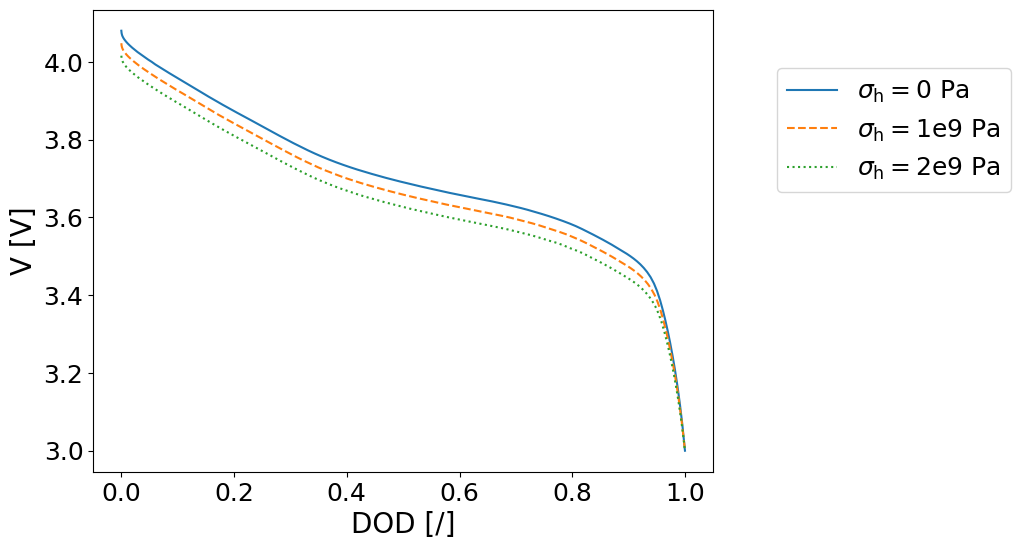

In [ ]:
Q_discharged = sol_DFN["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD = (Q_discharged / Q_max)

Q_discharged = sol_DFN_1["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD_1 = (Q_discharged / Q_max)

Q_discharged = sol_DFN_2["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD_2 = (Q_discharged / Q_max)

x_val = [DOD, 
         DOD_1,
        DOD_2
         ]
y_val = [sol_DFN["Voltage [V]"].data, 
         sol_DFN_1["Voltage [V]"].data,
        sol_DFN_2["Voltage [V]"].data
         ]

plt.figure(figsize=fig_size)
for i in range(len(x_val)):
    plt.plot(x_val[i], y_val[i], label=["$\sigma_{\mathrm{h}}=$0 Pa", 
                                        "$\sigma_{\mathrm{h}}=$1e9 Pa", 
                                        "$\sigma_{\mathrm{h}}=$2e9 Pa"
                                        ][i], 
                                        linestyle=["-", "--", ":", "-", "-", "-", "-", "-", "-", "-"][i])
    
# plt.xlim(3000, 3600)
# plt.ylim(3.5, 3.6)
plt.xlabel("DOD [/]")
plt.ylabel("V [V]")
plt.legend(loc="upper right", bbox_to_anchor=(1.5, 0.9))

if save_fig:
    plt.savefig("graphs/OCV_i0.eps", format='eps', dpi=600, bbox_inches='tight')


## EIS

In [ ]:
# import numpy as np
# from scipy import interpolate
# from scipy import optimize
# import pybamm
# import matplotlib.pyplot as plt

$\sigma_h$ = 0e9 Pa

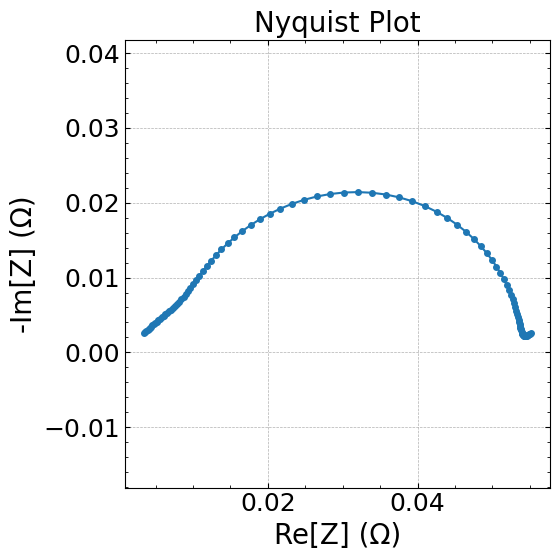

<Figure size 640x480 with 0 Axes>

In [12]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_0 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        )

    param0 = pybamm.ParameterValues("Ai2020") 
    param0.update(
        {"Hydrostatic stress [Pa]": 0},
        check_already_exists=False  
    )
    param0["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param0, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_0.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_0 = np.array(Z_0)

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_0[:, 1], -Z_0[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4)

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_0[:, 1] + 1j * Z_0[:, 2])  # Combine real and imag parts
phase = np.angle(Z_0[:, 1] + 1j * Z_0[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_0[:, 0]  # Assuming first column is frequency

# # Create figure with two subplots
# fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# # Magnitude plot
# ax[0].semilogx(freq, magnitude, color='b', linewidth=1.5)
# ax[0].set_ylabel('Absolute Impedance (Ω)', fontsize=12)
# ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)
# ax[0].set_title('Bode Plot', fontsize=14)

# # Phase plot
# ax[1].semilogx(freq, phase, color='r', linewidth=1.5)
# ax[1].set_xlabel('Frequency (Hz)', fontsize=12)
# ax[1].set_ylabel('Phase (°)', fontsize=12)
# ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# Tidy layout
plt.tight_layout()
plt.show()

In [13]:
# save to txt
np.savetxt("Z_0Pa_highPrecision.txt", Z_0, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

$\sigma_h$ = 1e9 Pa

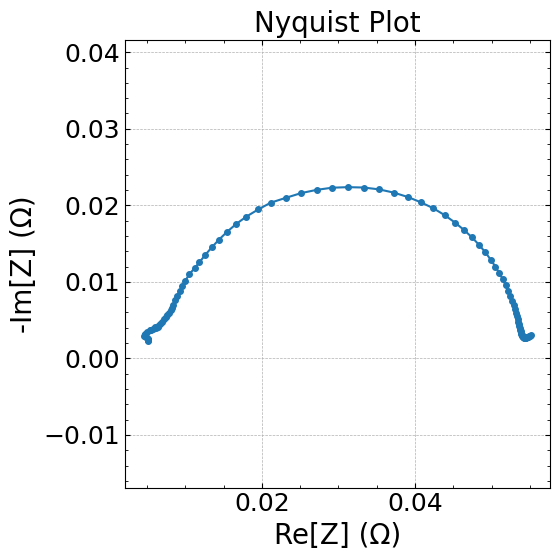

<Figure size 640x480 with 0 Axes>

In [14]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_1 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values
    model_DFN = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        ) 


    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": 1e9},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN_1 = sim_DFN_1.solve(t_eval=t)

    simulated_U_L_1 =  sol_DFN_1["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST

    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L_1) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L_1)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN_1["Time [s]"].entries + x[1]) + x[2] - simulated_U_L_1
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L_1)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_1.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_1 = np.array(Z_1)

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_1[:, 1], -Z_1[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4)

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_1[:, 1] + 1j * Z_1[:, 2])  # Combine real and imag parts
phase = np.angle(Z_1[:, 1] + 1j * Z_1[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_1[:, 0]  # Assuming first column is frequency

# # Create figure with two subplots
# fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# # Magnitude plot
# ax[0].semilogx(freq, magnitude, color='b', linewidth=1.5)
# ax[0].set_ylabel('Absolute Impedance (Ω)', fontsize=12)
# ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)
# ax[0].set_title('Bode Plot', fontsize=14)

# # Phase plot
# ax[1].semilogx(freq, phase, color='r', linewidth=1.5)
# ax[1].set_xlabel('Frequency (Hz)', fontsize=12)
# ax[1].set_ylabel('Phase (°)', fontsize=12)
# ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# Tidy layout
plt.tight_layout()
plt.show()

In [15]:
# save to txt
np.savetxt("Z_1GPa_highPrecision.txt", Z_1, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

$\sigma_h$ = 2e9 Pa

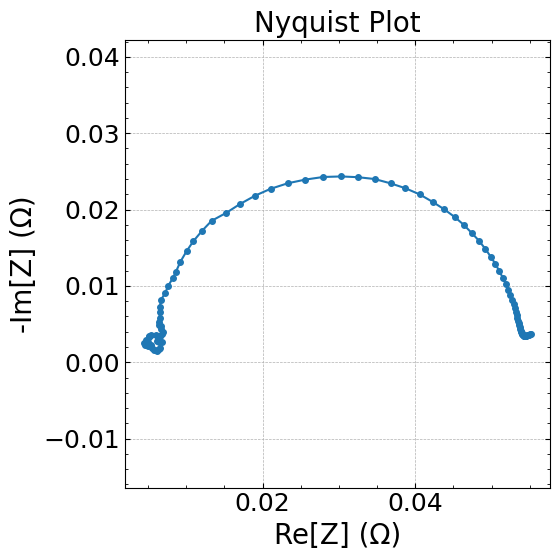

<Figure size 640x480 with 0 Axes>

In [16]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_2 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 
    model_DFN = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                     )

    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": 2e9},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_2 = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN_2 = sim_DFN_2.solve(t_eval=t)
   
    simulated_U_L_2 =  sol_DFN_2["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L_2) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L_2)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN_2["Time [s]"].entries + x[1]) + x[2] - simulated_U_L_2
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L_2)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_2.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_2 = np.array(Z_2)

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_2[:, 1], -Z_2[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4)

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_2[:, 1] + 1j * Z_2[:, 2])  # Combine real and imag parts
phase = np.angle(Z_2[:, 1] + 1j * Z_2[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_2[:, 0]  # Assuming first column is frequency

# # Create figure with two subplots
# fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# # Magnitude plot
# ax[0].semilogx(freq, magnitude, color='b', linewidth=1.5)
# ax[0].set_ylabel('Absolute Impedance (Ω)', fontsize=12)
# ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)
# ax[0].set_title('Bode Plot', fontsize=14)

# # Phase plot
# ax[1].semilogx(freq, phase, color='r', linewidth=1.5)
# ax[1].set_xlabel('Frequency (Hz)', fontsize=12)
# ax[1].set_ylabel('Phase (°)', fontsize=12)
# ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# Tidy layout
plt.tight_layout()
plt.show()

In [17]:
# save to txt
np.savetxt("Z_2GPa_highPrecision.txt", Z_2, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

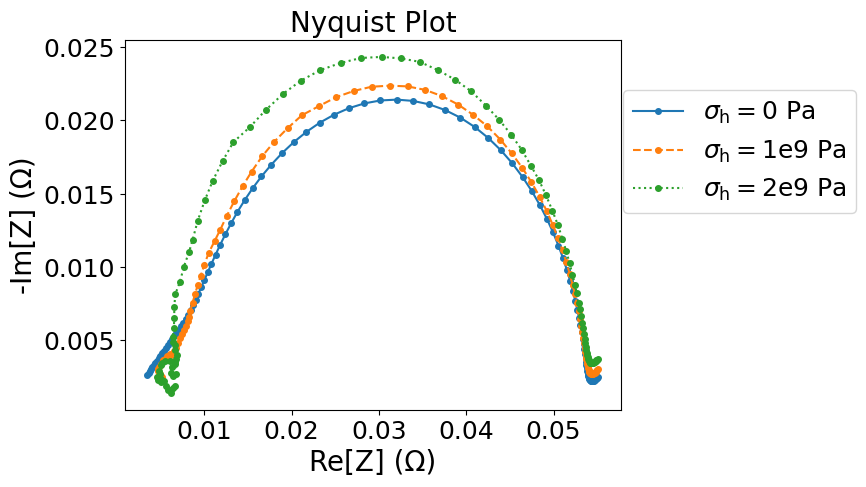

In [18]:
plt.plot(Z_0[:, 1], -Z_0[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=0$ Pa")
plt.plot(Z_1[:, 1], -Z_1[:, 2], marker='o', linestyle='--', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=1$e9 Pa")
plt.plot(Z_2[:, 1], -Z_2[:, 2], marker='o', linestyle=':', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=2$e9 Pa")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

plt.legend(loc = "upper right", bbox_to_anchor=(1.5, 0.9))

# Različni SOC

### $\sigma_h$ = 0e9 Pa

#### SOC = 1

In [5]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_0_soc100 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        )

    param0 = pybamm.ParameterValues("Ai2020") 
    param0.update(
        {"Hydrostatic stress [Pa]": 0},
        check_already_exists=False  
    )
    param0["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param0, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_0_soc100.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_0_soc100 = np.array(Z_0_soc100)

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_0_soc100[:, 1], -Z_0_soc100[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4)

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_0_soc100[:, 1] + 1j * Z_0_soc100[:, 2])  # Combine real and imag parts
phase = np.angle(Z_0_soc100[:, 1] + 1j * Z_0_soc100[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_0_soc100[:, 0]  # Assuming first column is frequency

# # Create figure with two subplots
# fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# # Magnitude plot
# ax[0].semilogx(freq, magnitude, color='b', linewidth=1.5)
# ax[0].set_ylabel('Absolute Impedance (Ω)', fontsize=12)
# ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)
# ax[0].set_title('Bode Plot', fontsize=14)

# # Phase plot
# ax[1].semilogx(freq, phase, color='r', linewidth=1.5)
# ax[1].set_xlabel('Frequency (Hz)', fontsize=12)
# ax[1].set_ylabel('Phase (°)', fontsize=12)
# ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# Tidy layout
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

In [5]:
# save to txt
np.savetxt("Z_0Pa_soc100_highPrecision.txt", Z_0_soc100, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#### SOC = 0.9

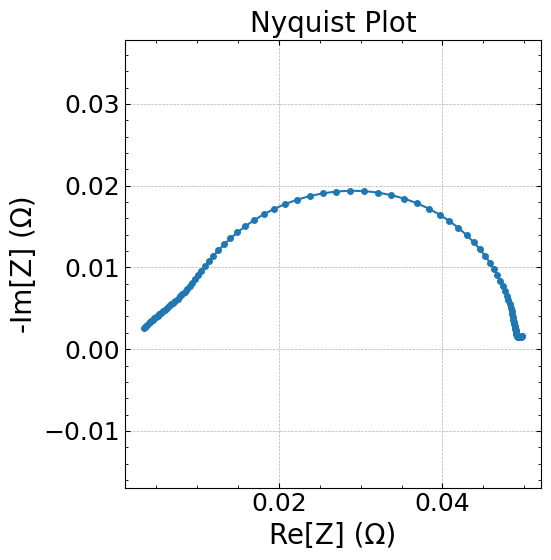

<Figure size 640x480 with 0 Axes>

In [73]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_0_soc90 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values
    model_DFN = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        ) 


    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": 0},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN_1 = sim_DFN_1.solve(t_eval=t, initial_soc=0.9)

    simulated_U_L_1 =  sol_DFN_1["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST

    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L_1) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L_1)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN_1["Time [s]"].entries + x[1]) + x[2] - simulated_U_L_1
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L_1)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_0_soc90.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_0_soc90 = np.array(Z_0_soc90)

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_0_soc90[:, 1], -Z_0_soc90[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4)

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_0_soc90[:, 1] + 1j * Z_0_soc90[:, 2])  # Combine real and imag parts
phase = np.angle(Z_0_soc90[:, 1] + 1j * Z_0_soc90[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_0_soc90[:, 0]  # Assuming first column is frequency

# # Create figure with two subplots
# fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# # Magnitude plot
# ax[0].semilogx(freq, magnitude, color='b', linewidth=1.5)
# ax[0].set_ylabel('Absolute Impedance (Ω)', fontsize=12)
# ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)
# ax[0].set_title('Bode Plot', fontsize=14)

# # Phase plot
# ax[1].semilogx(freq, phase, color='r', linewidth=1.5)
# ax[1].set_xlabel('Frequency (Hz)', fontsize=12)
# ax[1].set_ylabel('Phase (°)', fontsize=12)
# ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# Tidy layout
plt.tight_layout()
plt.show()

In [74]:
# save to txt
np.savetxt("Z_0GPa_soc90_highPrecision.txt", Z_0_soc90, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#### SOC = 0.8

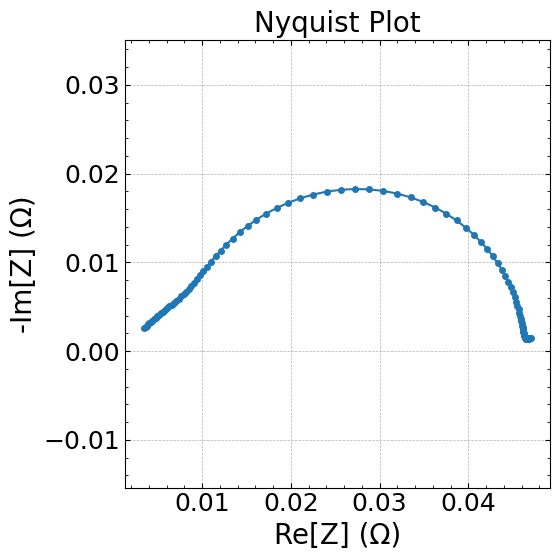

<Figure size 640x480 with 0 Axes>

In [75]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_0_soc80 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values
    model_DFN = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        ) 


    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": 0},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN_1 = sim_DFN_1.solve(t_eval=t, initial_soc=0.8)

    simulated_U_L_1 =  sol_DFN_1["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST

    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L_1) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L_1)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN_1["Time [s]"].entries + x[1]) + x[2] - simulated_U_L_1
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L_1)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_0_soc80.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_0_soc80 = np.array(Z_0_soc80)

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_0_soc80[:, 1], -Z_0_soc80[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4)

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_0_soc80[:, 1] + 1j * Z_0_soc80[:, 2])  # Combine real and imag parts
phase = np.angle(Z_0_soc80[:, 1] + 1j * Z_0_soc80[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_0_soc80[:, 0]  # Assuming first column is frequency

# # Create figure with two subplots
# fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# # Magnitude plot
# ax[0].semilogx(freq, magnitude, color='b', linewidth=1.5)
# ax[0].set_ylabel('Absolute Impedance (Ω)', fontsize=12)
# ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)
# ax[0].set_title('Bode Plot', fontsize=14)

# # Phase plot
# ax[1].semilogx(freq, phase, color='r', linewidth=1.5)
# ax[1].set_xlabel('Frequency (Hz)', fontsize=12)
# ax[1].set_ylabel('Phase (°)', fontsize=12)
# ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# Tidy layout
plt.tight_layout()
plt.show()

In [76]:
# save to txt
np.savetxt("Z_0GPa_soc80_highPrecision.txt", Z_0_soc80, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#### SOC = 0.7

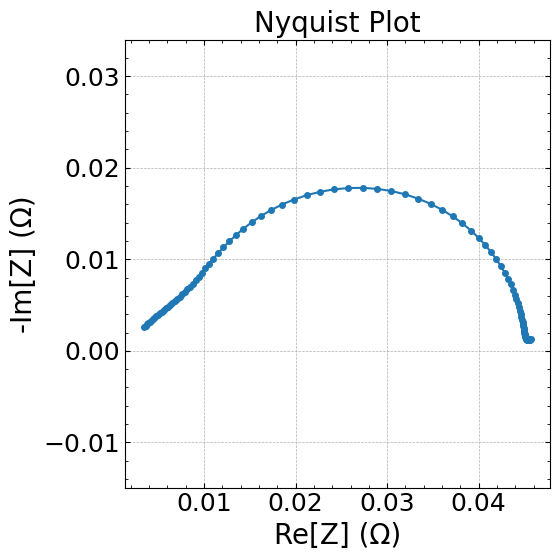

<Figure size 640x480 with 0 Axes>

In [77]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_0_soc70 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values
    model_DFN = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        ) 


    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": 0},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN_1 = sim_DFN_1.solve(t_eval=t, initial_soc=0.7)

    simulated_U_L_1 =  sol_DFN_1["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST

    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L_1) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L_1)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN_1["Time [s]"].entries + x[1]) + x[2] - simulated_U_L_1
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L_1)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_0_soc70.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_0_soc70 = np.array(Z_0_soc70)

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_0_soc70[:, 1], -Z_0_soc70[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4)

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_0_soc70[:, 1] + 1j * Z_0_soc70[:, 2])  # Combine real and imag parts
phase = np.angle(Z_0_soc70[:, 1] + 1j * Z_0_soc70[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_0_soc70[:, 0]  # Assuming first column is frequency

# # Create figure with two subplots
# fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# # Magnitude plot
# ax[0].semilogx(freq, magnitude, color='b', linewidth=1.5)
# ax[0].set_ylabel('Absolute Impedance (Ω)', fontsize=12)
# ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)
# ax[0].set_title('Bode Plot', fontsize=14)

# # Phase plot
# ax[1].semilogx(freq, phase, color='r', linewidth=1.5)
# ax[1].set_xlabel('Frequency (Hz)', fontsize=12)
# ax[1].set_ylabel('Phase (°)', fontsize=12)
# ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# Tidy layout
plt.tight_layout()
plt.show()

In [78]:
# save to txt
np.savetxt("Z_0GPa_soc70_highPrecision.txt", Z_0_soc70, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#### SOC = 0.6

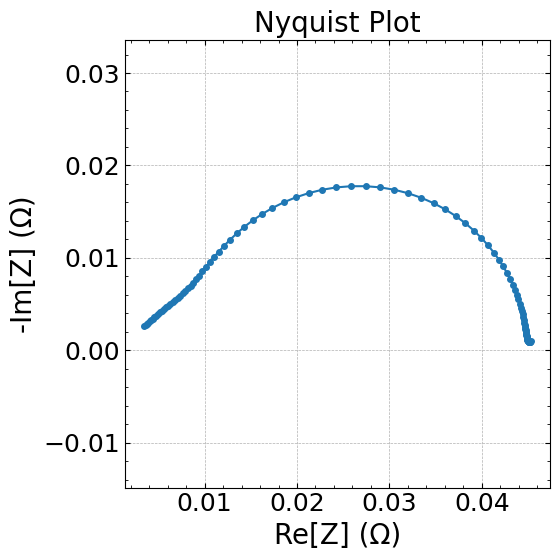

<Figure size 640x480 with 0 Axes>

In [79]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_0_soc60 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values
    model_DFN = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        ) 


    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": 0},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN_1 = sim_DFN_1.solve(t_eval=t, initial_soc=0.6)

    simulated_U_L_1 =  sol_DFN_1["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST

    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L_1) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L_1)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN_1["Time [s]"].entries + x[1]) + x[2] - simulated_U_L_1
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L_1)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_0_soc60.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_0_soc60 = np.array(Z_0_soc60)

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_0_soc60[:, 1], -Z_0_soc60[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4)

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_0_soc60[:, 1] + 1j * Z_0_soc60[:, 2])  # Combine real and imag parts
phase = np.angle(Z_0_soc60[:, 1] + 1j * Z_0_soc60[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_0_soc60[:, 0]  # Assuming first column is frequency

# # Create figure with two subplots
# fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# # Magnitude plot
# ax[0].semilogx(freq, magnitude, color='b', linewidth=1.5)
# ax[0].set_ylabel('Absolute Impedance (Ω)', fontsize=12)
# ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)
# ax[0].set_title('Bode Plot', fontsize=14)

# # Phase plot
# ax[1].semilogx(freq, phase, color='r', linewidth=1.5)
# ax[1].set_xlabel('Frequency (Hz)', fontsize=12)
# ax[1].set_ylabel('Phase (°)', fontsize=12)
# ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# Tidy layout
plt.tight_layout()
plt.show()

In [80]:
# save to txt
np.savetxt("Z_0GPa_soc60_highPrecision.txt", Z_0_soc60, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#### SOC = 0.5

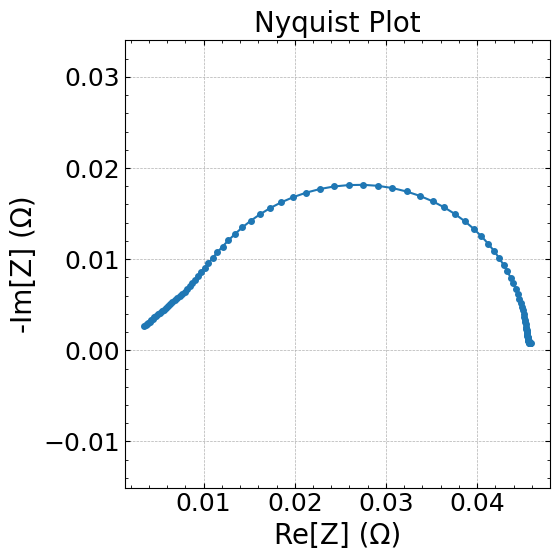

<Figure size 640x480 with 0 Axes>

In [ ]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_0_soc50 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        )

    param0 = pybamm.ParameterValues("Ai2020") 
    param0.update(
        {"Hydrostatic stress [Pa]": 0},
        check_already_exists=False  
    )
    param0["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param0, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=0.5)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_0_soc50.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_0_soc50 = np.array(Z_0_soc50)

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_0_soc50[:, 1], -Z_0_soc50[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4)

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_0_soc50[:, 1] + 1j * Z_0_soc50[:, 2])  # Combine real and imag parts
phase = np.angle(Z_0_soc50[:, 1] + 1j * Z_0_soc50[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_0_soc50[:, 0]  # Assuming first column is frequency

# # Create figure with two subplots
# fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# # Magnitude plot
# ax[0].semilogx(freq, magnitude, color='b', linewidth=1.5)
# ax[0].set_ylabel('Absolute Impedance (Ω)', fontsize=12)
# ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)
# ax[0].set_title('Bode Plot', fontsize=14)

# # Phase plot
# ax[1].semilogx(freq, phase, color='r', linewidth=1.5)
# ax[1].set_xlabel('Frequency (Hz)', fontsize=12)
# ax[1].set_ylabel('Phase (°)', fontsize=12)
# ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# Tidy layout
plt.tight_layout()
plt.show()

In [ ]:
# save to txt
np.savetxt("Z_0Pa_soc50_highPrecision.txt", Z_0_soc50, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#### SOC = 0.4

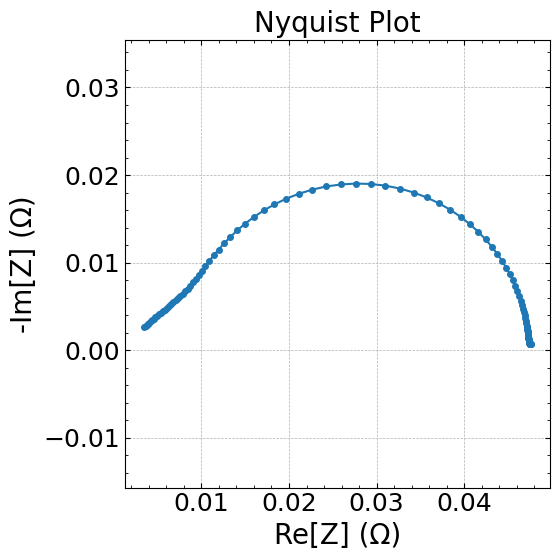

<Figure size 640x480 with 0 Axes>

In [81]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_0_soc40 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values
    model_DFN = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        ) 


    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": 0},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN_1 = sim_DFN_1.solve(t_eval=t, initial_soc=0.4)

    simulated_U_L_1 =  sol_DFN_1["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST

    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L_1) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L_1)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN_1["Time [s]"].entries + x[1]) + x[2] - simulated_U_L_1
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L_1)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_0_soc40.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_0_soc40 = np.array(Z_0_soc40)

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_0_soc40[:, 1], -Z_0_soc40[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4)

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_0_soc40[:, 1] + 1j * Z_0_soc40[:, 2])  # Combine real and imag parts
phase = np.angle(Z_0_soc40[:, 1] + 1j * Z_0_soc40[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_0_soc40[:, 0]  # Assuming first column is frequency

# # Create figure with two subplots
# fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# # Magnitude plot
# ax[0].semilogx(freq, magnitude, color='b', linewidth=1.5)
# ax[0].set_ylabel('Absolute Impedance (Ω)', fontsize=12)
# ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)
# ax[0].set_title('Bode Plot', fontsize=14)

# # Phase plot
# ax[1].semilogx(freq, phase, color='r', linewidth=1.5)
# ax[1].set_xlabel('Frequency (Hz)', fontsize=12)
# ax[1].set_ylabel('Phase (°)', fontsize=12)
# ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# Tidy layout
plt.tight_layout()
plt.show()

In [82]:
# save to txt
np.savetxt("Z_0GPa_soc40_highPrecision.txt", Z_0_soc40, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#### SOC = 0.3

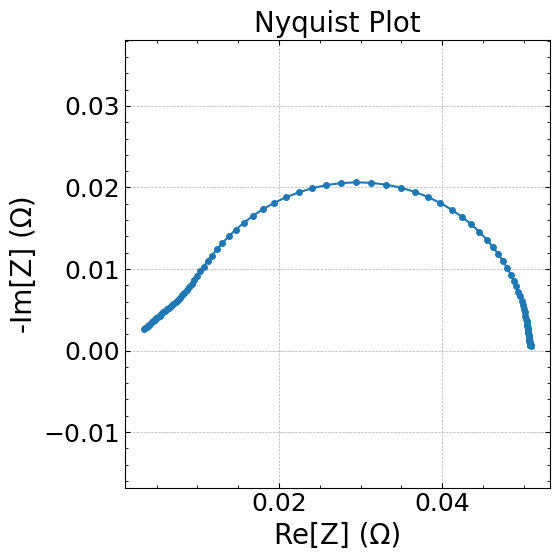

<Figure size 640x480 with 0 Axes>

In [83]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_0_soc30 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values
    model_DFN = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        ) 


    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": 0},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN_1 = sim_DFN_1.solve(t_eval=t, initial_soc=0.3)

    simulated_U_L_1 =  sol_DFN_1["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST

    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L_1) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L_1)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN_1["Time [s]"].entries + x[1]) + x[2] - simulated_U_L_1
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L_1)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_0_soc30.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_0_soc30 = np.array(Z_0_soc30)

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_0_soc30[:, 1], -Z_0_soc30[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4)

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_0_soc30[:, 1] + 1j * Z_0_soc30[:, 2])  # Combine real and imag parts
phase = np.angle(Z_0_soc30[:, 1] + 1j * Z_0_soc30[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_0_soc30[:, 0]  # Assuming first column is frequency

# # Create figure with two subplots
# fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# # Magnitude plot
# ax[0].semilogx(freq, magnitude, color='b', linewidth=1.5)
# ax[0].set_ylabel('Absolute Impedance (Ω)', fontsize=12)
# ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)
# ax[0].set_title('Bode Plot', fontsize=14)

# # Phase plot
# ax[1].semilogx(freq, phase, color='r', linewidth=1.5)
# ax[1].set_xlabel('Frequency (Hz)', fontsize=12)
# ax[1].set_ylabel('Phase (°)', fontsize=12)
# ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# Tidy layout
plt.tight_layout()
plt.show()

In [84]:
# save to txt
np.savetxt("Z_0GPa_soc30_highPrecision.txt", Z_0_soc30, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#### SOC = 0.2

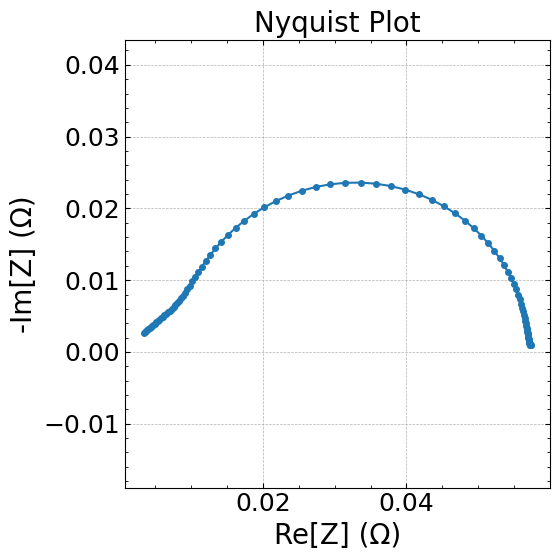

<Figure size 640x480 with 0 Axes>

In [ ]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_0_soc20 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        )

    param0 = pybamm.ParameterValues("Ai2020") 
    param0.update(
        {"Hydrostatic stress [Pa]": 0},
        check_already_exists=False  
    )
    param0["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param0, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=0.2)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_0_soc20.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_0_soc20 = np.array(Z_0_soc20)

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_0_soc20[:, 1], -Z_0_soc20[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4)

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_0_soc20[:, 1] + 1j * Z_0_soc20[:, 2])  # Combine real and imag parts
phase = np.angle(Z_0_soc20[:, 1] + 1j * Z_0_soc20[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_0_soc20[:, 0]  # Assuming first column is frequency

# # Create figure with two subplots
# fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# # Magnitude plot
# ax[0].semilogx(freq, magnitude, color='b', linewidth=1.5)
# ax[0].set_ylabel('Absolute Impedance (Ω)', fontsize=12)
# ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)
# ax[0].set_title('Bode Plot', fontsize=14)

# # Phase plot
# ax[1].semilogx(freq, phase, color='r', linewidth=1.5)
# ax[1].set_xlabel('Frequency (Hz)', fontsize=12)
# ax[1].set_ylabel('Phase (°)', fontsize=12)
# ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# Tidy layout
plt.tight_layout()
plt.show()

In [ ]:
# save to txt
np.savetxt("Z_0Pa_soc20_highPrecision.txt", Z_0_soc20, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#### SOC = 0.1

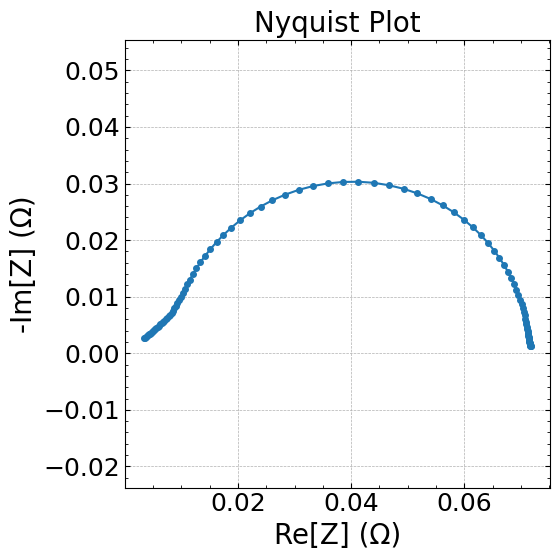

<Figure size 640x480 with 0 Axes>

In [85]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_0_soc10 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values
    model_DFN = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        ) 


    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": 0},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN_1 = sim_DFN_1.solve(t_eval=t, initial_soc=0.1)

    simulated_U_L_1 =  sol_DFN_1["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST

    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L_1) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L_1)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN_1["Time [s]"].entries + x[1]) + x[2] - simulated_U_L_1
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L_1)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_0_soc10.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_0_soc10 = np.array(Z_0_soc10)

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_0_soc10[:, 1], -Z_0_soc10[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4)

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_0_soc10[:, 1] + 1j * Z_0_soc10[:, 2])  # Combine real and imag parts
phase = np.angle(Z_0_soc10[:, 1] + 1j * Z_0_soc10[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_0_soc10[:, 0]  # Assuming first column is frequency

# # Create figure with two subplots
# fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# # Magnitude plot
# ax[0].semilogx(freq, magnitude, color='b', linewidth=1.5)
# ax[0].set_ylabel('Absolute Impedance (Ω)', fontsize=12)
# ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)
# ax[0].set_title('Bode Plot', fontsize=14)

# # Phase plot
# ax[1].semilogx(freq, phase, color='r', linewidth=1.5)
# ax[1].set_xlabel('Frequency (Hz)', fontsize=12)
# ax[1].set_ylabel('Phase (°)', fontsize=12)
# ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# Tidy layout
plt.tight_layout()
plt.show()

In [86]:
# save to txt
np.savetxt("Z_0GPa_soc10_highPrecision.txt", Z_0_soc10, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

### $\sigma_h$ = 1e9 Pa

#### SOC = 1

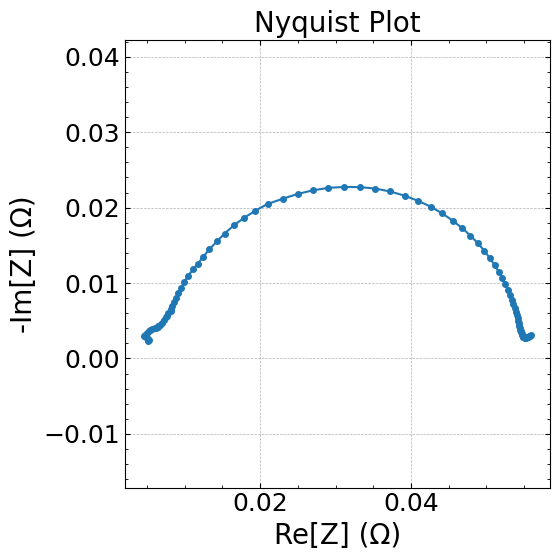

<Figure size 640x480 with 0 Axes>

In [91]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_1_soc100 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values
    model_DFN = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        ) 


    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": 1e9},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN_1 = sim_DFN_1.solve(t_eval=t, initial_soc=1)

    simulated_U_L_1 =  sol_DFN_1["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST

    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L_1) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L_1)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN_1["Time [s]"].entries + x[1]) + x[2] - simulated_U_L_1
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L_1)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_1_soc100.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_1_soc100 = np.array(Z_1_soc100)

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_1_soc100[:, 1], -Z_1_soc100[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4)

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_1_soc100[:, 1] + 1j * Z_1_soc100[:, 2])  # Combine real and imag parts
phase = np.angle(Z_1_soc100[:, 1] + 1j * Z_1_soc100[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_1_soc100[:, 0]  # Assuming first column is frequency

# # Create figure with two subplots
# fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# # Magnitude plot
# ax[0].semilogx(freq, magnitude, color='b', linewidth=1.5)
# ax[0].set_ylabel('Absolute Impedance (Ω)', fontsize=12)
# ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)
# ax[0].set_title('Bode Plot', fontsize=14)

# # Phase plot
# ax[1].semilogx(freq, phase, color='r', linewidth=1.5)
# ax[1].set_xlabel('Frequency (Hz)', fontsize=12)
# ax[1].set_ylabel('Phase (°)', fontsize=12)
# ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# Tidy layout
plt.tight_layout()
plt.show()

In [92]:
# save to txt
np.savetxt("Z_1GPa_soc100_highPrecision.txt", Z_1_soc100, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#### SOC = 0.9

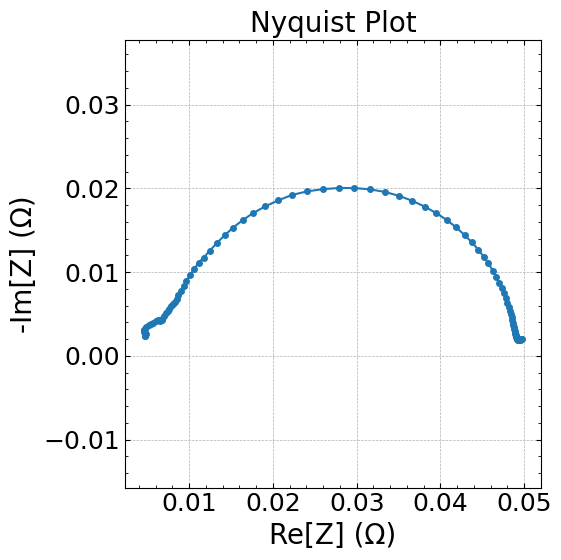

<Figure size 640x480 with 0 Axes>

In [45]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_1_soc90 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values
    model_DFN = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        ) 


    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": 1e9},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN_1 = sim_DFN_1.solve(t_eval=t, initial_soc=0.9)

    simulated_U_L_1 =  sol_DFN_1["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST

    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L_1) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L_1)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN_1["Time [s]"].entries + x[1]) + x[2] - simulated_U_L_1
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L_1)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_1_soc90.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_1_soc90 = np.array(Z_1_soc90)

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_1_soc90[:, 1], -Z_1_soc90[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4)

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_1_soc90[:, 1] + 1j * Z_1_soc90[:, 2])  # Combine real and imag parts
phase = np.angle(Z_1_soc90[:, 1] + 1j * Z_1_soc90[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_1_soc90[:, 0]  # Assuming first column is frequency

# # Create figure with two subplots
# fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# # Magnitude plot
# ax[0].semilogx(freq, magnitude, color='b', linewidth=1.5)
# ax[0].set_ylabel('Absolute Impedance (Ω)', fontsize=12)
# ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)
# ax[0].set_title('Bode Plot', fontsize=14)

# # Phase plot
# ax[1].semilogx(freq, phase, color='r', linewidth=1.5)
# ax[1].set_xlabel('Frequency (Hz)', fontsize=12)
# ax[1].set_ylabel('Phase (°)', fontsize=12)
# ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# Tidy layout
plt.tight_layout()
plt.show()

In [46]:
# save to txt
np.savetxt("Z_1GPa_soc90_highPrecision.txt", Z_1_soc90, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#### SOC = 0.8

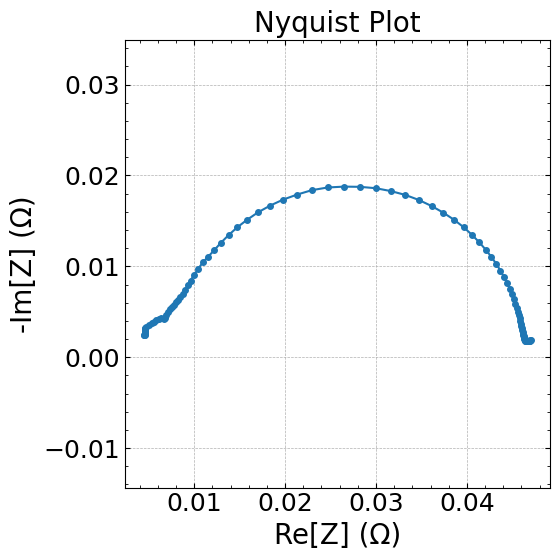

<Figure size 640x480 with 0 Axes>

In [47]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_1_soc80 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values
    model_DFN = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        ) 


    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": 1e9},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN_1 = sim_DFN_1.solve(t_eval=t, initial_soc=0.8)

    simulated_U_L_1 =  sol_DFN_1["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST

    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L_1) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L_1)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN_1["Time [s]"].entries + x[1]) + x[2] - simulated_U_L_1
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L_1)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_1_soc80.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_1_soc80 = np.array(Z_1_soc80)

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_1_soc80[:, 1], -Z_1_soc80[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4)

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_1_soc80[:, 1] + 1j * Z_1_soc80[:, 2])  # Combine real and imag parts
phase = np.angle(Z_1_soc80[:, 1] + 1j * Z_1_soc80[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_1_soc80[:, 0]  # Assuming first column is frequency

# # Create figure with two subplots
# fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# # Magnitude plot
# ax[0].semilogx(freq, magnitude, color='b', linewidth=1.5)
# ax[0].set_ylabel('Absolute Impedance (Ω)', fontsize=12)
# ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)
# ax[0].set_title('Bode Plot', fontsize=14)

# # Phase plot
# ax[1].semilogx(freq, phase, color='r', linewidth=1.5)
# ax[1].set_xlabel('Frequency (Hz)', fontsize=12)
# ax[1].set_ylabel('Phase (°)', fontsize=12)
# ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# Tidy layout
plt.tight_layout()
plt.show()

In [48]:
# save to txt
np.savetxt("Z_1GPa_soc80_highPrecision.txt", Z_1_soc80, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#### SOC = 0.7

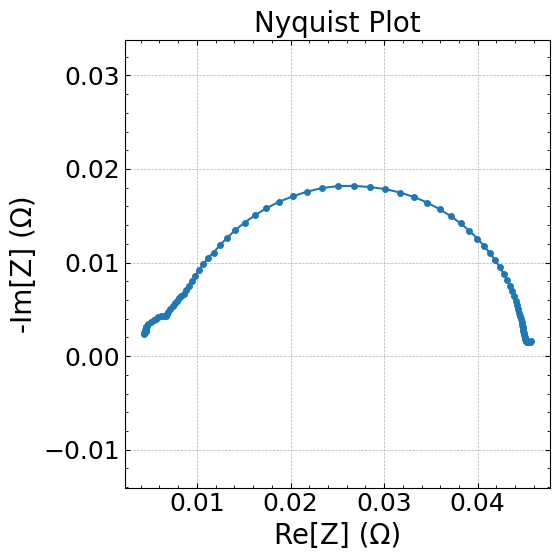

<Figure size 640x480 with 0 Axes>

In [49]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_1_soc70 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values
    model_DFN = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        ) 


    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": 1e9},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN_1 = sim_DFN_1.solve(t_eval=t, initial_soc=0.7)

    simulated_U_L_1 =  sol_DFN_1["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST

    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L_1) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L_1)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN_1["Time [s]"].entries + x[1]) + x[2] - simulated_U_L_1
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L_1)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_1_soc70.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_1_soc70 = np.array(Z_1_soc70)

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_1_soc70[:, 1], -Z_1_soc70[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4)

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_1_soc70[:, 1] + 1j * Z_1_soc70[:, 2])  # Combine real and imag parts
phase = np.angle(Z_1_soc70[:, 1] + 1j * Z_1_soc70[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_1_soc70[:, 0]  # Assuming first column is frequency

# # Create figure with two subplots
# fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# # Magnitude plot
# ax[0].semilogx(freq, magnitude, color='b', linewidth=1.5)
# ax[0].set_ylabel('Absolute Impedance (Ω)', fontsize=12)
# ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)
# ax[0].set_title('Bode Plot', fontsize=14)

# # Phase plot
# ax[1].semilogx(freq, phase, color='r', linewidth=1.5)
# ax[1].set_xlabel('Frequency (Hz)', fontsize=12)
# ax[1].set_ylabel('Phase (°)', fontsize=12)
# ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# Tidy layout
plt.tight_layout()
plt.show()

In [50]:
# save to txt
np.savetxt("Z_1GPa_soc70_highPrecision.txt", Z_1_soc70, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#### SOC = 0.6

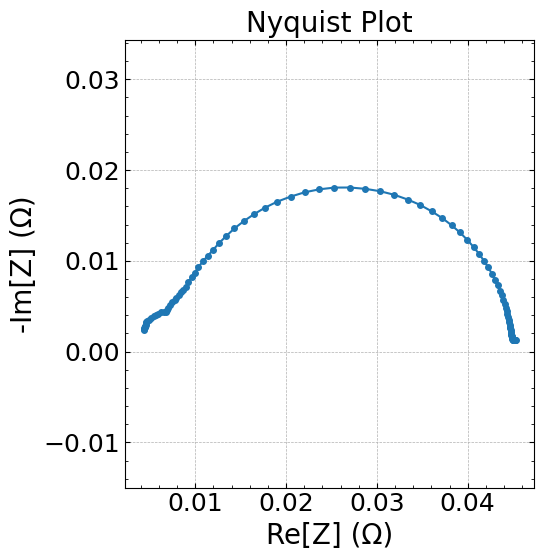

<Figure size 640x480 with 0 Axes>

In [51]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_1_soc60 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values
    model_DFN = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        ) 


    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": 1e9},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN_1 = sim_DFN_1.solve(t_eval=t, initial_soc=0.6)

    simulated_U_L_1 =  sol_DFN_1["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST

    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L_1) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L_1)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN_1["Time [s]"].entries + x[1]) + x[2] - simulated_U_L_1
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L_1)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_1_soc60.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_1_soc60 = np.array(Z_1_soc60)

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_1_soc60[:, 1], -Z_1_soc60[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4)

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_1_soc60[:, 1] + 1j * Z_1_soc60[:, 2])  # Combine real and imag parts
phase = np.angle(Z_1_soc60[:, 1] + 1j * Z_1_soc60[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_1_soc60[:, 0]  # Assuming first column is frequency

# # Create figure with two subplots
# fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# # Magnitude plot
# ax[0].semilogx(freq, magnitude, color='b', linewidth=1.5)
# ax[0].set_ylabel('Absolute Impedance (Ω)', fontsize=12)
# ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)
# ax[0].set_title('Bode Plot', fontsize=14)

# # Phase plot
# ax[1].semilogx(freq, phase, color='r', linewidth=1.5)
# ax[1].set_xlabel('Frequency (Hz)', fontsize=12)
# ax[1].set_ylabel('Phase (°)', fontsize=12)
# ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# Tidy layout
plt.tight_layout()
plt.show()

In [52]:
# save to txt
np.savetxt("Z_1GPa_soc60_highPrecision.txt", Z_1_soc60, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#### SOC = 0.5

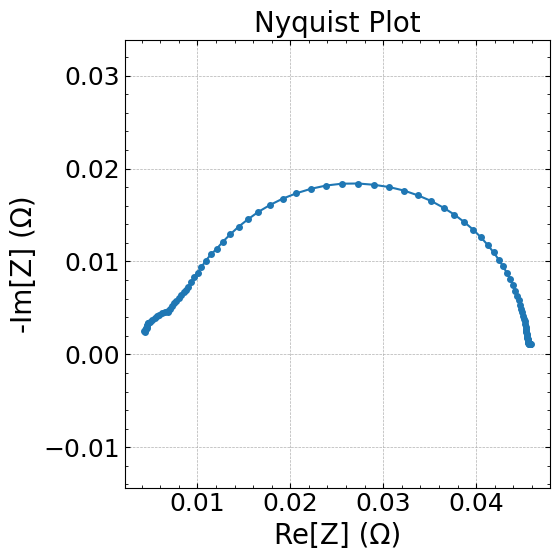

<Figure size 640x480 with 0 Axes>

In [27]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_1_soc50 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values
    model_DFN = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        ) 


    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": 1e9},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN_1 = sim_DFN_1.solve(t_eval=t, initial_soc=0.5)

    simulated_U_L_1 =  sol_DFN_1["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST

    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L_1) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L_1)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN_1["Time [s]"].entries + x[1]) + x[2] - simulated_U_L_1
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L_1)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_1_soc50.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_1_soc50 = np.array(Z_1_soc50)

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_1_soc50[:, 1], -Z_1_soc50[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4)

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_1_soc50[:, 1] + 1j * Z_1_soc50[:, 2])  # Combine real and imag parts
phase = np.angle(Z_1_soc50[:, 1] + 1j * Z_1_soc50[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_1_soc50[:, 0]  # Assuming first column is frequency

# # Create figure with two subplots
# fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# # Magnitude plot
# ax[0].semilogx(freq, magnitude, color='b', linewidth=1.5)
# ax[0].set_ylabel('Absolute Impedance (Ω)', fontsize=12)
# ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)
# ax[0].set_title('Bode Plot', fontsize=14)

# # Phase plot
# ax[1].semilogx(freq, phase, color='r', linewidth=1.5)
# ax[1].set_xlabel('Frequency (Hz)', fontsize=12)
# ax[1].set_ylabel('Phase (°)', fontsize=12)
# ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# Tidy layout
plt.tight_layout()
plt.show()

In [28]:
# save to txt
np.savetxt("Z_1GPa_soc50_highPrecision.txt", Z_1_soc50, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#### SOC = 0.4

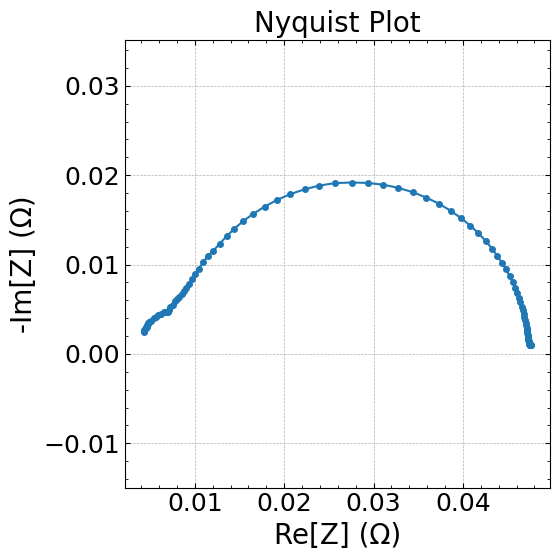

<Figure size 640x480 with 0 Axes>

In [53]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_1_soc40 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values
    model_DFN = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        ) 


    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": 1e9},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN_1 = sim_DFN_1.solve(t_eval=t, initial_soc=0.4)

    simulated_U_L_1 =  sol_DFN_1["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST

    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L_1) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L_1)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN_1["Time [s]"].entries + x[1]) + x[2] - simulated_U_L_1
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L_1)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_1_soc40.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_1_soc40 = np.array(Z_1_soc40)

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_1_soc40[:, 1], -Z_1_soc40[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4)

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_1_soc40[:, 1] + 1j * Z_1_soc40[:, 2])  # Combine real and imag parts
phase = np.angle(Z_1_soc40[:, 1] + 1j * Z_1_soc40[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_1_soc40[:, 0]  # Assuming first column is frequency

# # Create figure with two subplots
# fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# # Magnitude plot
# ax[0].semilogx(freq, magnitude, color='b', linewidth=1.5)
# ax[0].set_ylabel('Absolute Impedance (Ω)', fontsize=12)
# ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)
# ax[0].set_title('Bode Plot', fontsize=14)

# # Phase plot
# ax[1].semilogx(freq, phase, color='r', linewidth=1.5)
# ax[1].set_xlabel('Frequency (Hz)', fontsize=12)
# ax[1].set_ylabel('Phase (°)', fontsize=12)
# ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# Tidy layout
plt.tight_layout()
plt.show()

In [54]:
# save to txt
np.savetxt("Z_1GPa_soc40_highPrecision.txt", Z_1_soc40, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#### SOC = 0.3

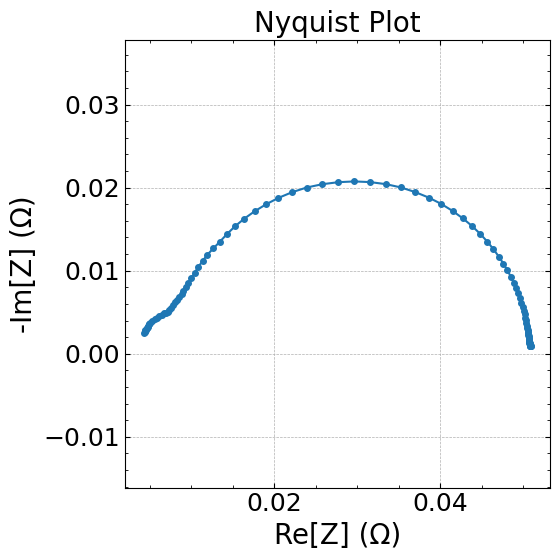

<Figure size 640x480 with 0 Axes>

In [55]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_1_soc30 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values
    model_DFN = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        ) 


    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": 1e9},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN_1 = sim_DFN_1.solve(t_eval=t, initial_soc=0.3)

    simulated_U_L_1 =  sol_DFN_1["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST

    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L_1) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L_1)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN_1["Time [s]"].entries + x[1]) + x[2] - simulated_U_L_1
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L_1)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_1_soc30.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_1_soc30 = np.array(Z_1_soc30)

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_1_soc30[:, 1], -Z_1_soc30[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4)

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_1_soc30[:, 1] + 1j * Z_1_soc30[:, 2])  # Combine real and imag parts
phase = np.angle(Z_1_soc30[:, 1] + 1j * Z_1_soc30[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_1_soc30[:, 0]  # Assuming first column is frequency

# # Create figure with two subplots
# fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# # Magnitude plot
# ax[0].semilogx(freq, magnitude, color='b', linewidth=1.5)
# ax[0].set_ylabel('Absolute Impedance (Ω)', fontsize=12)
# ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)
# ax[0].set_title('Bode Plot', fontsize=14)

# # Phase plot
# ax[1].semilogx(freq, phase, color='r', linewidth=1.5)
# ax[1].set_xlabel('Frequency (Hz)', fontsize=12)
# ax[1].set_ylabel('Phase (°)', fontsize=12)
# ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# Tidy layout
plt.tight_layout()
plt.show()

In [56]:
# save to txt
np.savetxt("Z_1GPa_soc30_highPrecision.txt", Z_1_soc30, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#### SOC = 0.2

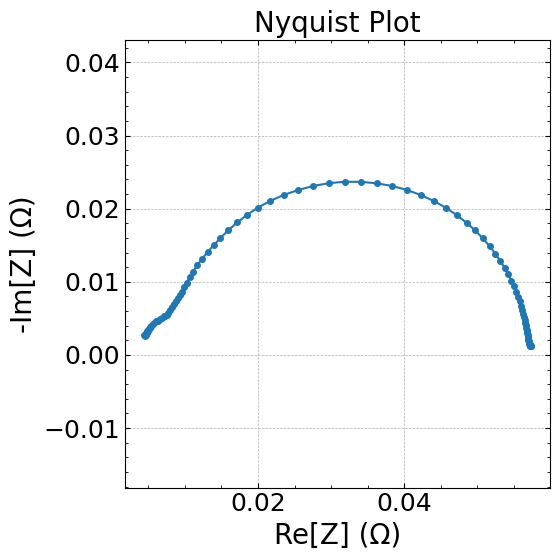

<Figure size 640x480 with 0 Axes>

In [29]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_1_soc20 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values
    model_DFN = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        ) 


    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": 1e9},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN_1 = sim_DFN_1.solve(t_eval=t, initial_soc=0.2)

    simulated_U_L_1 =  sol_DFN_1["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST

    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L_1) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L_1)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN_1["Time [s]"].entries + x[1]) + x[2] - simulated_U_L_1
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L_1)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_1_soc20.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_1_soc20 = np.array(Z_1_soc20)

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_1_soc20[:, 1], -Z_1_soc20[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4)

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_1_soc20[:, 1] + 1j * Z_1_soc20[:, 2])  # Combine real and imag parts
phase = np.angle(Z_1_soc20[:, 1] + 1j * Z_1_soc20[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_1_soc20[:, 0]  # Assuming first column is frequency

# # Create figure with two subplots
# fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# # Magnitude plot
# ax[0].semilogx(freq, magnitude, color='b', linewidth=1.5)
# ax[0].set_ylabel('Absolute Impedance (Ω)', fontsize=12)
# ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)
# ax[0].set_title('Bode Plot', fontsize=14)

# # Phase plot
# ax[1].semilogx(freq, phase, color='r', linewidth=1.5)
# ax[1].set_xlabel('Frequency (Hz)', fontsize=12)
# ax[1].set_ylabel('Phase (°)', fontsize=12)
# ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# Tidy layout
plt.tight_layout()
plt.show()

In [30]:
# save to txt
np.savetxt("Z_1GPa_soc20_highPrecision.txt", Z_1_soc20, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#### SOC = 0.1

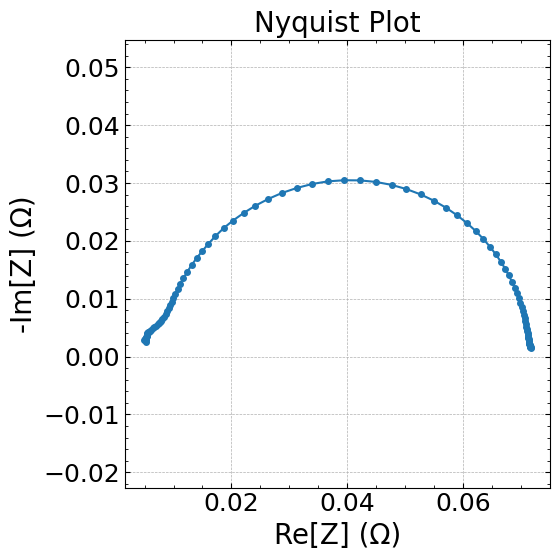

<Figure size 640x480 with 0 Axes>

In [57]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_1_soc10 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values
    model_DFN = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        ) 


    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": 1e9},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN_1 = sim_DFN_1.solve(t_eval=t, initial_soc=0.1)

    simulated_U_L_1 =  sol_DFN_1["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST

    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L_1) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L_1)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN_1["Time [s]"].entries + x[1]) + x[2] - simulated_U_L_1
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L_1)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_1_soc10.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_1_soc10 = np.array(Z_1_soc10)

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_1_soc10[:, 1], -Z_1_soc10[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4)

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_1_soc10[:, 1] + 1j * Z_1_soc10[:, 2])  # Combine real and imag parts
phase = np.angle(Z_1_soc10[:, 1] + 1j * Z_1_soc10[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_1_soc10[:, 0]  # Assuming first column is frequency

# # Create figure with two subplots
# fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# # Magnitude plot
# ax[0].semilogx(freq, magnitude, color='b', linewidth=1.5)
# ax[0].set_ylabel('Absolute Impedance (Ω)', fontsize=12)
# ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)
# ax[0].set_title('Bode Plot', fontsize=14)

# # Phase plot
# ax[1].semilogx(freq, phase, color='r', linewidth=1.5)
# ax[1].set_xlabel('Frequency (Hz)', fontsize=12)
# ax[1].set_ylabel('Phase (°)', fontsize=12)
# ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# Tidy layout
plt.tight_layout()
plt.show()

In [58]:
# save to txt
np.savetxt("Z_1GPa_soc10_highPrecision.txt", Z_1_soc10, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

### $\sigma_h$ = 2e9 Pa

#### SOC = 1

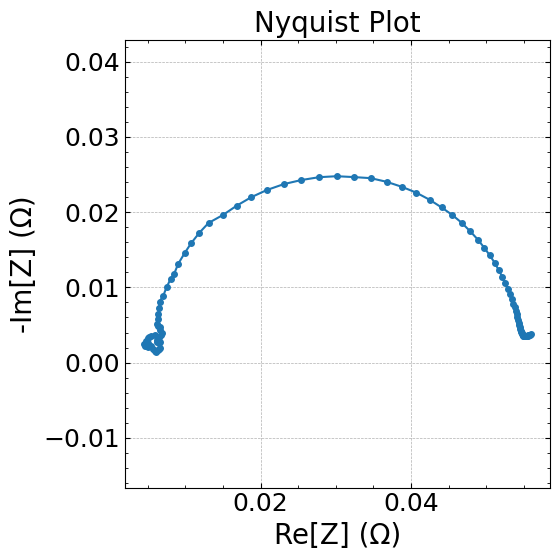

<Figure size 640x480 with 0 Axes>

In [31]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_2_soc100 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values
    model_DFN = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        ) 


    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": 2e9},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN_1 = sim_DFN_1.solve(t_eval=t, initial_soc=1)

    simulated_U_L_1 =  sol_DFN_1["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST

    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L_1) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L_1)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN_1["Time [s]"].entries + x[1]) + x[2] - simulated_U_L_1
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L_1)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_2_soc100.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_2_soc100 = np.array(Z_2_soc100)

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_2_soc100[:, 1], -Z_2_soc100[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4)

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_2_soc100[:, 1] + 1j * Z_2_soc100[:, 2])  # Combine real and imag parts
phase = np.angle(Z_2_soc100[:, 1] + 1j * Z_2_soc100[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_2_soc100[:, 0]  # Assuming first column is frequency

# # Create figure with two subplots
# fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# # Magnitude plot
# ax[0].semilogx(freq, magnitude, color='b', linewidth=1.5)
# ax[0].set_ylabel('Absolute Impedance (Ω)', fontsize=12)
# ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)
# ax[0].set_title('Bode Plot', fontsize=14)

# # Phase plot
# ax[1].semilogx(freq, phase, color='r', linewidth=1.5)
# ax[1].set_xlabel('Frequency (Hz)', fontsize=12)
# ax[1].set_ylabel('Phase (°)', fontsize=12)
# ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# Tidy layout
plt.tight_layout()
plt.show()

In [32]:
# save to txt
np.savetxt("Z_2GPa_soc100_highPrecision.txt", Z_2_soc100, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#### SOC = 0.9

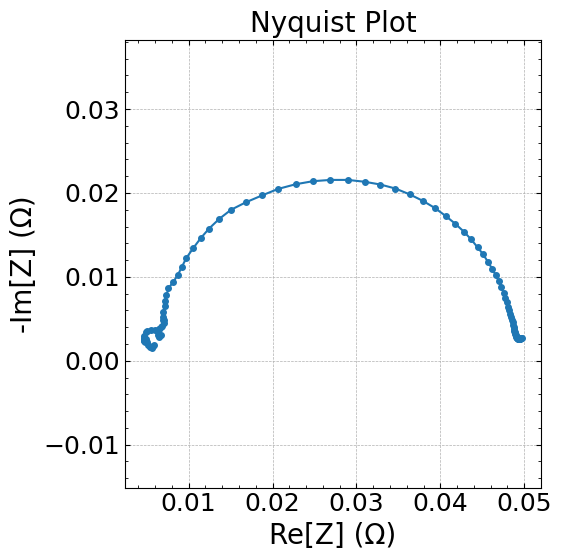

<Figure size 640x480 with 0 Axes>

In [59]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_2_soc90 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values
    model_DFN = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        ) 


    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": 2e9},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN_1 = sim_DFN_1.solve(t_eval=t, initial_soc=0.9)

    simulated_U_L_1 =  sol_DFN_1["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST

    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L_1) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L_1)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN_1["Time [s]"].entries + x[1]) + x[2] - simulated_U_L_1
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L_1)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_2_soc90.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_2_soc90 = np.array(Z_2_soc90)

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_2_soc90[:, 1], -Z_2_soc90[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4)

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_2_soc90[:, 1] + 1j * Z_2_soc90[:, 2])  # Combine real and imag parts
phase = np.angle(Z_2_soc90[:, 1] + 1j * Z_2_soc90[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_2_soc90[:, 0]  # Assuming first column is frequency

# # Create figure with two subplots
# fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# # Magnitude plot
# ax[0].semilogx(freq, magnitude, color='b', linewidth=1.5)
# ax[0].set_ylabel('Absolute Impedance (Ω)', fontsize=12)
# ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)
# ax[0].set_title('Bode Plot', fontsize=14)

# # Phase plot
# ax[1].semilogx(freq, phase, color='r', linewidth=1.5)
# ax[1].set_xlabel('Frequency (Hz)', fontsize=12)
# ax[1].set_ylabel('Phase (°)', fontsize=12)
# ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# Tidy layout
plt.tight_layout()
plt.show()

In [60]:
# save to txt
np.savetxt("Z_2GPa_soc90_highPrecision.txt", Z_2_soc90, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#### SOC = 0.8

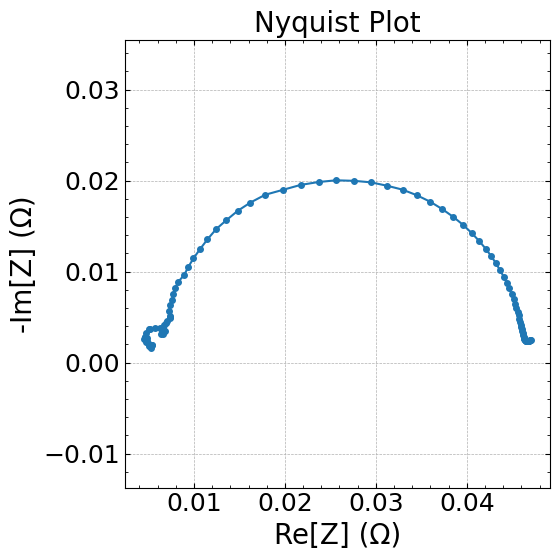

<Figure size 640x480 with 0 Axes>

In [61]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_2_soc80 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values
    model_DFN = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        ) 


    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": 2e9},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN_1 = sim_DFN_1.solve(t_eval=t, initial_soc=0.8)

    simulated_U_L_1 =  sol_DFN_1["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST

    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L_1) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L_1)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN_1["Time [s]"].entries + x[1]) + x[2] - simulated_U_L_1
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L_1)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_2_soc80.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_2_soc80 = np.array(Z_2_soc80)

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_2_soc80[:, 1], -Z_2_soc80[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4)

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_2_soc80[:, 1] + 1j * Z_2_soc80[:, 2])  # Combine real and imag parts
phase = np.angle(Z_2_soc80[:, 1] + 1j * Z_2_soc80[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_2_soc80[:, 0]  # Assuming first column is frequency

# # Create figure with two subplots
# fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# # Magnitude plot
# ax[0].semilogx(freq, magnitude, color='b', linewidth=1.5)
# ax[0].set_ylabel('Absolute Impedance (Ω)', fontsize=12)
# ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)
# ax[0].set_title('Bode Plot', fontsize=14)

# # Phase plot
# ax[1].semilogx(freq, phase, color='r', linewidth=1.5)
# ax[1].set_xlabel('Frequency (Hz)', fontsize=12)
# ax[1].set_ylabel('Phase (°)', fontsize=12)
# ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# Tidy layout
plt.tight_layout()
plt.show()

In [62]:
# save to txt
np.savetxt("Z_2GPa_soc80_highPrecision.txt", Z_2_soc80, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#### SOC = 0.7

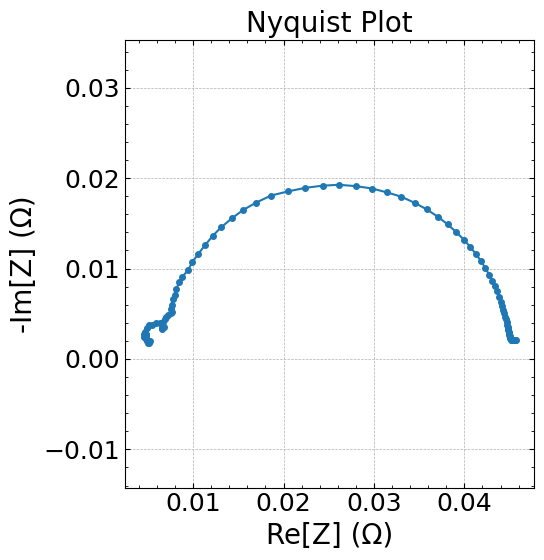

<Figure size 640x480 with 0 Axes>

In [63]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_2_soc70 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values
    model_DFN = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        ) 


    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": 2e9},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN_1 = sim_DFN_1.solve(t_eval=t, initial_soc=0.7)

    simulated_U_L_1 =  sol_DFN_1["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST

    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L_1) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L_1)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN_1["Time [s]"].entries + x[1]) + x[2] - simulated_U_L_1
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L_1)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_2_soc70.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_2_soc70 = np.array(Z_2_soc70)

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_2_soc70[:, 1], -Z_2_soc70[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4)

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_2_soc70[:, 1] + 1j * Z_2_soc70[:, 2])  # Combine real and imag parts
phase = np.angle(Z_2_soc70[:, 1] + 1j * Z_2_soc70[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_2_soc70[:, 0]  # Assuming first column is frequency

# # Create figure with two subplots
# fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# # Magnitude plot
# ax[0].semilogx(freq, magnitude, color='b', linewidth=1.5)
# ax[0].set_ylabel('Absolute Impedance (Ω)', fontsize=12)
# ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)
# ax[0].set_title('Bode Plot', fontsize=14)

# # Phase plot
# ax[1].semilogx(freq, phase, color='r', linewidth=1.5)
# ax[1].set_xlabel('Frequency (Hz)', fontsize=12)
# ax[1].set_ylabel('Phase (°)', fontsize=12)
# ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# Tidy layout
plt.tight_layout()
plt.show()

In [64]:
# save to txt
np.savetxt("Z_2GPa_soc70_highPrecision.txt", Z_2_soc70, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#### SOC = 0.6

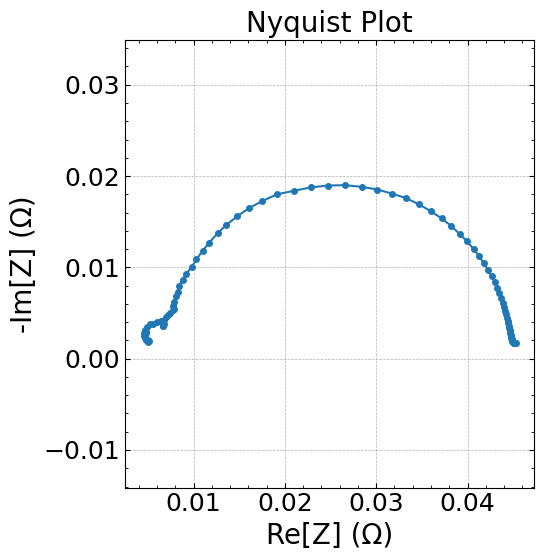

<Figure size 640x480 with 0 Axes>

In [65]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_2_soc60 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values
    model_DFN = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        ) 


    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": 2e9},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN_1 = sim_DFN_1.solve(t_eval=t, initial_soc=0.6)

    simulated_U_L_1 =  sol_DFN_1["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST

    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L_1) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L_1)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN_1["Time [s]"].entries + x[1]) + x[2] - simulated_U_L_1
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L_1)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_2_soc60.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_2_soc60 = np.array(Z_2_soc60)

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_2_soc60[:, 1], -Z_2_soc60[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4)

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_2_soc60[:, 1] + 1j * Z_2_soc60[:, 2])  # Combine real and imag parts
phase = np.angle(Z_2_soc60[:, 1] + 1j * Z_2_soc60[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_2_soc60[:, 0]  # Assuming first column is frequency

# # Create figure with two subplots
# fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# # Magnitude plot
# ax[0].semilogx(freq, magnitude, color='b', linewidth=1.5)
# ax[0].set_ylabel('Absolute Impedance (Ω)', fontsize=12)
# ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)
# ax[0].set_title('Bode Plot', fontsize=14)

# # Phase plot
# ax[1].semilogx(freq, phase, color='r', linewidth=1.5)
# ax[1].set_xlabel('Frequency (Hz)', fontsize=12)
# ax[1].set_ylabel('Phase (°)', fontsize=12)
# ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# Tidy layout
plt.tight_layout()
plt.show()

In [66]:
# save to txt
np.savetxt("Z_2GPa_soc60_highPrecision.txt", Z_2_soc60, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#### SOC = 0.5

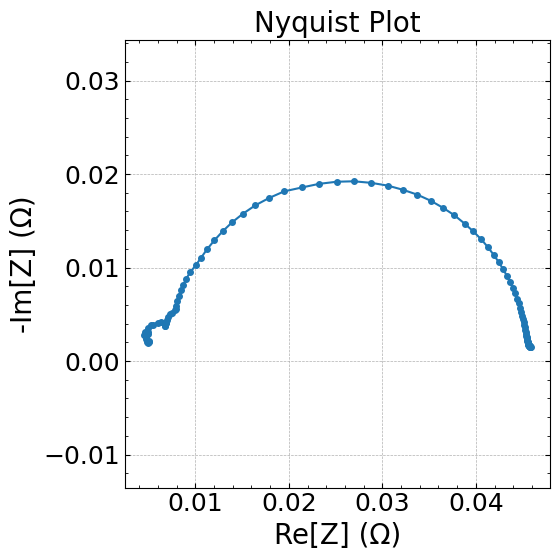

<Figure size 640x480 with 0 Axes>

In [ ]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_2_soc50 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values
    model_DFN = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        ) 


    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": 2e9},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN_1 = sim_DFN_1.solve(t_eval=t, initial_soc=0.5)

    simulated_U_L_1 =  sol_DFN_1["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST

    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L_1) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L_1)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN_1["Time [s]"].entries + x[1]) + x[2] - simulated_U_L_1
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L_1)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_2_soc50.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_2_soc50 = np.array(Z_2_soc50)

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_2_soc50[:, 1], -Z_2_soc50[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4)

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_2_soc50[:, 1] + 1j * Z_2_soc50[:, 2])  # Combine real and imag parts
phase = np.angle(Z_2_soc50[:, 1] + 1j * Z_2_soc50[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_2_soc50[:, 0]  # Assuming first column is frequency

# # Create figure with two subplots
# fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# # Magnitude plot
# ax[0].semilogx(freq, magnitude, color='b', linewidth=1.5)
# ax[0].set_ylabel('Absolute Impedance (Ω)', fontsize=12)
# ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)
# ax[0].set_title('Bode Plot', fontsize=14)

# # Phase plot
# ax[1].semilogx(freq, phase, color='r', linewidth=1.5)
# ax[1].set_xlabel('Frequency (Hz)', fontsize=12)
# ax[1].set_ylabel('Phase (°)', fontsize=12)
# ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# Tidy layout
plt.tight_layout()
plt.show()

In [ ]:
# save to txt
np.savetxt("Z_2GPa_soc50_highPrecision.txt", Z_2_soc50, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#### SOC = 0.4

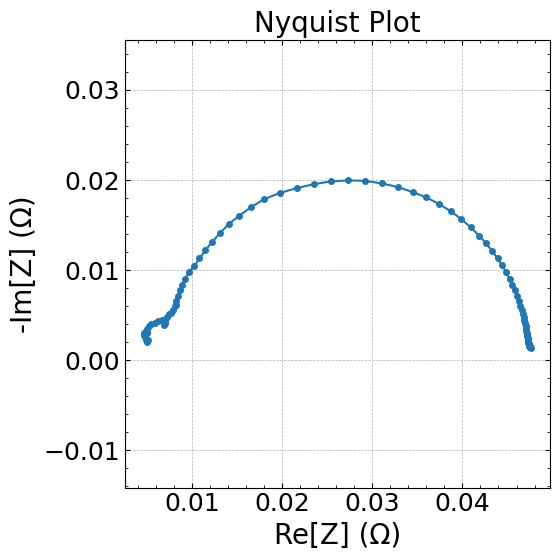

<Figure size 640x480 with 0 Axes>

In [67]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_2_soc40 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values
    model_DFN = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        ) 


    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": 2e9},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN_1 = sim_DFN_1.solve(t_eval=t, initial_soc=0.4)

    simulated_U_L_1 =  sol_DFN_1["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST

    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L_1) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L_1)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN_1["Time [s]"].entries + x[1]) + x[2] - simulated_U_L_1
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L_1)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_2_soc40.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_2_soc40 = np.array(Z_2_soc40)

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_2_soc40[:, 1], -Z_2_soc40[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4)

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_2_soc40[:, 1] + 1j * Z_2_soc40[:, 2])  # Combine real and imag parts
phase = np.angle(Z_2_soc40[:, 1] + 1j * Z_2_soc40[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_2_soc40[:, 0]  # Assuming first column is frequency

# # Create figure with two subplots
# fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# # Magnitude plot
# ax[0].semilogx(freq, magnitude, color='b', linewidth=1.5)
# ax[0].set_ylabel('Absolute Impedance (Ω)', fontsize=12)
# ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)
# ax[0].set_title('Bode Plot', fontsize=14)

# # Phase plot
# ax[1].semilogx(freq, phase, color='r', linewidth=1.5)
# ax[1].set_xlabel('Frequency (Hz)', fontsize=12)
# ax[1].set_ylabel('Phase (°)', fontsize=12)
# ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# Tidy layout
plt.tight_layout()
plt.show()

In [68]:
# save to txt
np.savetxt("Z_2GPa_soc40_highPrecision.txt", Z_2_soc40, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#### SOC = 0.3

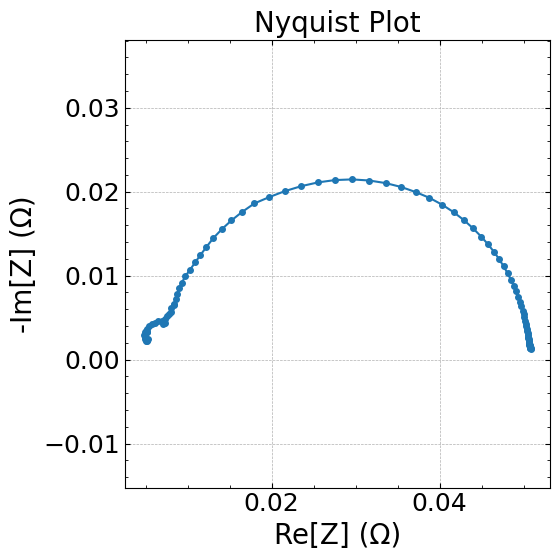

<Figure size 640x480 with 0 Axes>

In [69]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_2_soc30 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values
    model_DFN = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        ) 


    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": 2e9},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN_1 = sim_DFN_1.solve(t_eval=t, initial_soc=0.3)

    simulated_U_L_1 =  sol_DFN_1["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST

    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L_1) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L_1)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN_1["Time [s]"].entries + x[1]) + x[2] - simulated_U_L_1
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L_1)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_2_soc30.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_2_soc30 = np.array(Z_2_soc30)

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_2_soc30[:, 1], -Z_2_soc30[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4)

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_2_soc30[:, 1] + 1j * Z_2_soc30[:, 2])  # Combine real and imag parts
phase = np.angle(Z_2_soc30[:, 1] + 1j * Z_2_soc30[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_2_soc30[:, 0]  # Assuming first column is frequency

# # Create figure with two subplots
# fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# # Magnitude plot
# ax[0].semilogx(freq, magnitude, color='b', linewidth=1.5)
# ax[0].set_ylabel('Absolute Impedance (Ω)', fontsize=12)
# ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)
# ax[0].set_title('Bode Plot', fontsize=14)

# # Phase plot
# ax[1].semilogx(freq, phase, color='r', linewidth=1.5)
# ax[1].set_xlabel('Frequency (Hz)', fontsize=12)
# ax[1].set_ylabel('Phase (°)', fontsize=12)
# ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# Tidy layout
plt.tight_layout()
plt.show()

In [70]:
# save to txt
np.savetxt("Z_2GPa_soc30_highPrecision.txt", Z_2_soc30, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#### SOC = 0.2

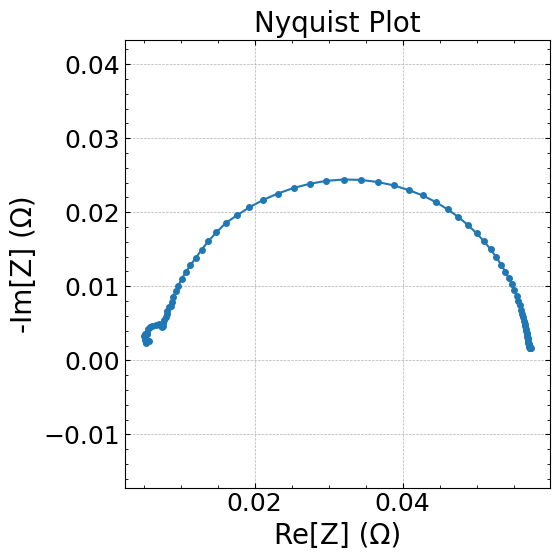

<Figure size 640x480 with 0 Axes>

In [ ]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_2_soc20 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values
    model_DFN = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        ) 


    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": 2e9},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN_1 = sim_DFN_1.solve(t_eval=t, initial_soc=0.2)

    simulated_U_L_1 =  sol_DFN_1["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST

    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L_1) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L_1)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN_1["Time [s]"].entries + x[1]) + x[2] - simulated_U_L_1
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L_1)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_2_soc20.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_2_soc20 = np.array(Z_2_soc20)

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_2_soc20[:, 1], -Z_2_soc20[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4)

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_2_soc20[:, 1] + 1j * Z_2_soc20[:, 2])  # Combine real and imag parts
phase = np.angle(Z_2_soc20[:, 1] + 1j * Z_2_soc20[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_2_soc20[:, 0]  # Assuming first column is frequency

# # Create figure with two subplots
# fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# # Magnitude plot
# ax[0].semilogx(freq, magnitude, color='b', linewidth=1.5)
# ax[0].set_ylabel('Absolute Impedance (Ω)', fontsize=12)
# ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)
# ax[0].set_title('Bode Plot', fontsize=14)

# # Phase plot
# ax[1].semilogx(freq, phase, color='r', linewidth=1.5)
# ax[1].set_xlabel('Frequency (Hz)', fontsize=12)
# ax[1].set_ylabel('Phase (°)', fontsize=12)
# ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# Tidy layout
plt.tight_layout()
plt.show()

In [ ]:
# save to txt
np.savetxt("Z_2GPa_soc20_highPrecision.txt", Z_2_soc20, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#### SOC = 0.1

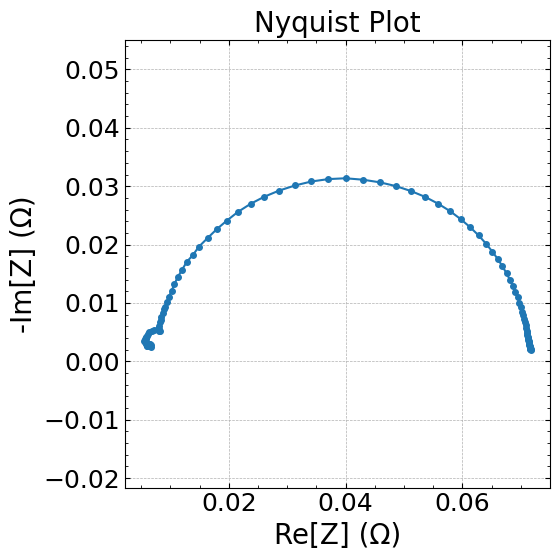

<Figure size 640x480 with 0 Axes>

In [71]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_2_soc10 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values
    model_DFN = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        ) 


    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": 2e9},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN_1 = sim_DFN_1.solve(t_eval=t, initial_soc=0.1)

    simulated_U_L_1 =  sol_DFN_1["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST

    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L_1) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L_1)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN_1["Time [s]"].entries + x[1]) + x[2] - simulated_U_L_1
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L_1)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_2_soc10.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_2_soc10 = np.array(Z_2_soc10)

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_2_soc10[:, 1], -Z_2_soc10[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4)

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_2_soc10[:, 1] + 1j * Z_2_soc10[:, 2])  # Combine real and imag parts
phase = np.angle(Z_2_soc10[:, 1] + 1j * Z_2_soc10[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_2_soc10[:, 0]  # Assuming first column is frequency

# # Create figure with two subplots
# fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

# # Magnitude plot
# ax[0].semilogx(freq, magnitude, color='b', linewidth=1.5)
# ax[0].set_ylabel('Absolute Impedance (Ω)', fontsize=12)
# ax[0].grid(True, which='both', linestyle='--', linewidth=0.5)
# ax[0].set_title('Bode Plot', fontsize=14)

# # Phase plot
# ax[1].semilogx(freq, phase, color='r', linewidth=1.5)
# ax[1].set_xlabel('Frequency (Hz)', fontsize=12)
# ax[1].set_ylabel('Phase (°)', fontsize=12)
# ax[1].grid(True, which='both', linestyle='--', linewidth=0.5)

# Tidy layout
plt.tight_layout()
plt.show()

In [134]:
# save to txt
np.savetxt("Z_2GPa_soc10_highPrecision.txt", Z_2_soc10, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

### $\sigma_h$ = 10 MPa, SOC 1

In [22]:
hydrostatic_stress = 10e6

I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_10MPa_soc100 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                "particle mechanics": "swelling only",
                                                },
                                        )

    param10 = pybamm.ParameterValues("Ai2020") 
    param10.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param10["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param10, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]


    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_10MPa_soc100.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_10MPa_soc100 = np.array(Z_10MPa_soc100)

# save to txt
np.savetxt("Z_10MPa_soc100.txt", Z_10MPa_soc100)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")



### $\sigma_h$ = 100 MPa, SOC 1

In [3]:
hydrostatic_stress = 1e8

I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_100MPa_soc100 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                "particle mechanics": "swelling only",
                                                },
                                        )

    param100 = pybamm.ParameterValues("Ai2020") 
    param100.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param100["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param100, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]


    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_100MPa_soc100.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_100MPa_soc100 = np.array(Z_100MPa_soc100)

# save to txt
np.savetxt("Z_100MPa_soc100.txt", Z_100MPa_soc100)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")



### Vsi rezultati

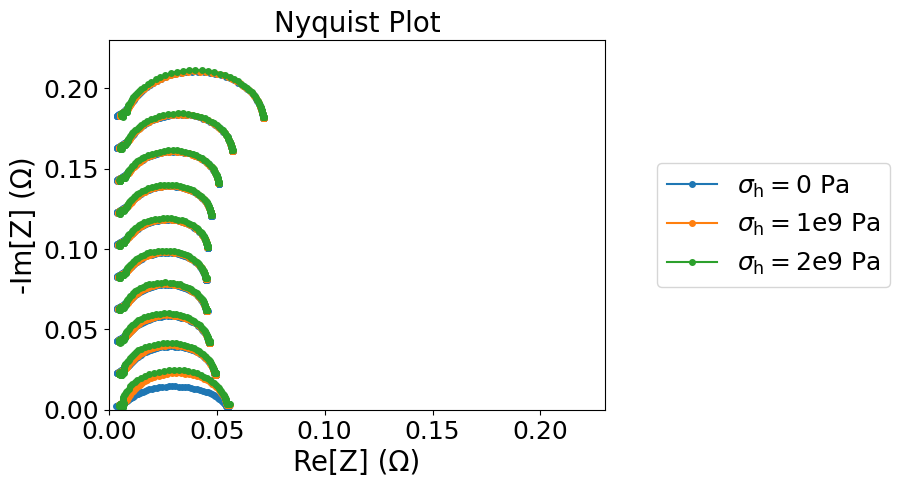

In [133]:
plt.plot(Z_0_soc100[:, 1], -Z_0_soc100[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, color = 'C0', label="$\sigma_{\mathrm{h}}=0$ Pa") #label="$\sigma_{\mathrm{h}}=0$ Pa, SOC = 1")
plt.plot(Z_0_soc90[:, 1], -Z_0_soc90[:, 2]+0.02, marker='o', linestyle='-', linewidth=1.5, markersize=4, color = 'C0') #label="$\sigma_{\mathrm{h}}=0$ Pa, SOC = 0.9")
plt.plot(Z_0_soc80[:, 1], -Z_0_soc80[:, 2]+0.04, marker='o', linestyle='-', linewidth=1.5, markersize=4, color = 'C0') #label="$\sigma_{\mathrm{h}}=0$ Pa, SOC = 0.8")
plt.plot(Z_0_soc70[:, 1], -Z_0_soc70[:, 2]+0.06, marker='o', linestyle='-', linewidth=1.5, markersize=4, color = 'C0') #label="$\sigma_{\mathrm{h}}=0$ Pa, SOC = 0.7")
plt.plot(Z_0_soc60[:, 1], -Z_0_soc60[:, 2]+0.08, marker='o', linestyle='-', linewidth=1.5, markersize=4, color = 'C0') #label="$\sigma_{\mathrm{h}}=0$ Pa, SOC = 0.6")
plt.plot(Z_0_soc50[:, 1], -Z_0_soc50[:, 2]+0.10, marker='o', linestyle='-', linewidth=1.5, markersize=4, color = 'C0') #label="$\sigma_{\mathrm{h}}=0$ Pa, SOC = 0.5")
plt.plot(Z_0_soc40[:, 1], -Z_0_soc40[:, 2]+0.12, marker='o', linestyle='-', linewidth=1.5, markersize=4, color = 'C0') #label="$\sigma_{\mathrm{h}}=0$ Pa, SOC = 0.4")
plt.plot(Z_0_soc30[:, 1], -Z_0_soc30[:, 2]+0.14, marker='o', linestyle='-', linewidth=1.5, markersize=4, color = 'C0') #label="$\sigma_{\mathrm{h}}=0$ Pa, SOC = 0.3")
plt.plot(Z_0_soc20[:, 1], -Z_0_soc20[:, 2]+0.16, marker='o', linestyle='-', linewidth=1.5, markersize=4, color = 'C0') #label="$\sigma_{\mathrm{h}}=0$ Pa, SOC = 0.2")
plt.plot(Z_0_soc10[:, 1], -Z_0_soc10[:, 2]+0.18, marker='o', linestyle='-', linewidth=1.5, markersize=4, color = 'C0') #label="$\sigma_{\mathrm{h}}=0$ Pa, SOC = 0.1")

plt.plot(Z_1_soc100[:, 1], -Z_1_soc100[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, color = 'C1', label="$\sigma_{\mathrm{h}}=1$e9 Pa") #label="$\sigma_{\mathrm{h}}=1$e9 Pa, SOC = 1")
plt.plot(Z_1_soc90[:, 1], -Z_1_soc90[:, 2]+0.02, marker='o', linestyle='-', linewidth=1.5, markersize=4, color = 'C1')#label="$\sigma_{\mathrm{h}}=1$e9 Pa, SOC = 0.9")
plt.plot(Z_1_soc80[:, 1], -Z_1_soc80[:, 2]+0.04, marker='o', linestyle='-', linewidth=1.5, markersize=4, color = 'C1')#label="$\sigma_{\mathrm{h}}=1$e9 Pa, SOC = 0.8")
plt.plot(Z_1_soc70[:, 1], -Z_1_soc70[:, 2]+0.06, marker='o', linestyle='-', linewidth=1.5, markersize=4, color = 'C1')#label="$\sigma_{\mathrm{h}}=1$e9 Pa, SOC = 0.7")
plt.plot(Z_1_soc60[:, 1], -Z_1_soc60[:, 2]+0.08, marker='o', linestyle='-', linewidth=1.5, markersize=4, color = 'C1')#label="$\sigma_{\mathrm{h}}=1$e9 Pa, SOC = 0.6")
plt.plot(Z_1_soc50[:, 1], -Z_1_soc50[:, 2]+0.10, marker='o', linestyle='-', linewidth=1.5, markersize=4, color = 'C1')#label="$\sigma_{\mathrm{h}}=1$e9 Pa, SOC = 0.5")
plt.plot(Z_1_soc40[:, 1], -Z_1_soc40[:, 2]+0.12, marker='o', linestyle='-', linewidth=1.5, markersize=4, color = 'C1')#label="$\sigma_{\mathrm{h}}=1$e9 Pa, SOC = 0.4")
plt.plot(Z_1_soc30[:, 1], -Z_1_soc30[:, 2]+0.14, marker='o', linestyle='-', linewidth=1.5, markersize=4, color = 'C1')#label="$\sigma_{\mathrm{h}}=1$e9 Pa, SOC = 0.3")
plt.plot(Z_1_soc20[:, 1], -Z_1_soc20[:, 2]+0.16, marker='o', linestyle='-', linewidth=1.5, markersize=4, color = 'C1')#label="$\sigma_{\mathrm{h}}=1$e9 Pa, SOC = 0.2")
plt.plot(Z_1_soc10[:, 1], -Z_1_soc10[:, 2]+0.18, marker='o', linestyle='-', linewidth=1.5, markersize=4, color = 'C1')#label="$\sigma_{\mathrm{h}}=1$e9 Pa, SOC = 0.1")

plt.plot(Z_2_soc100[:, 1], -Z_2_soc100[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, color = 'C2', label="$\sigma_{\mathrm{h}}=2$e9 Pa")  #label="$\sigma_{\mathrm{h}}=2$e9 Pa, SOC = 1")
plt.plot(Z_2_soc90[:, 1], -Z_2_soc90[:, 2]+0.02, marker='o', linestyle='-', linewidth=1.5, markersize=4, color = 'C2') #label="$\sigma_{\mathrm{h}}=2$e9 Pa, SOC = 0.9")
plt.plot(Z_2_soc80[:, 1], -Z_2_soc80[:, 2]+0.04, marker='o', linestyle='-', linewidth=1.5, markersize=4, color = 'C2') #label="$\sigma_{\mathrm{h}}=2$e9 Pa, SOC = 0.8")
plt.plot(Z_2_soc70[:, 1], -Z_2_soc70[:, 2]+0.06, marker='o', linestyle='-', linewidth=1.5, markersize=4, color = 'C2') #label="$\sigma_{\mathrm{h}}=2$e9 Pa, SOC = 0.7")
plt.plot(Z_2_soc60[:, 1], -Z_2_soc60[:, 2]+0.08, marker='o', linestyle='-', linewidth=1.5, markersize=4, color = 'C2') #label="$\sigma_{\mathrm{h}}=2$e9 Pa, SOC = 0.6")
plt.plot(Z_2_soc50[:, 1], -Z_2_soc50[:, 2]+0.10, marker='o', linestyle='-', linewidth=1.5, markersize=4, color = 'C2') #label="$\sigma_{\mathrm{h}}=2$e9 Pa, SOC = 0.5")
plt.plot(Z_2_soc40[:, 1], -Z_2_soc40[:, 2]+0.12, marker='o', linestyle='-', linewidth=1.5, markersize=4, color = 'C2') #label="$\sigma_{\mathrm{h}}=2$e9 Pa, SOC = 0.4")
plt.plot(Z_2_soc30[:, 1], -Z_2_soc30[:, 2]+0.14, marker='o', linestyle='-', linewidth=1.5, markersize=4, color = 'C2') #label="$\sigma_{\mathrm{h}}=2$e9 Pa, SOC = 0.3")
plt.plot(Z_2_soc20[:, 1], -Z_2_soc20[:, 2]+0.16, marker='o', linestyle='-', linewidth=1.5, markersize=4, color = 'C2') #label="$\sigma_{\mathrm{h}}=2$e9 Pa, SOC = 0.2")
plt.plot(Z_2_soc10[:, 1], -Z_2_soc10[:, 2]+0.18, marker='o', linestyle='-', linewidth=1.5, markersize=4, color = 'C2') #label="$\sigma_{\mathrm{h}}=2$e9 Pa, SOC = 0.1")


# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

plt.xlim(0, 0.23)
plt.ylim(0, 0.23)

plt.legend(loc = "center right", bbox_to_anchor=(1.6, 0.5))

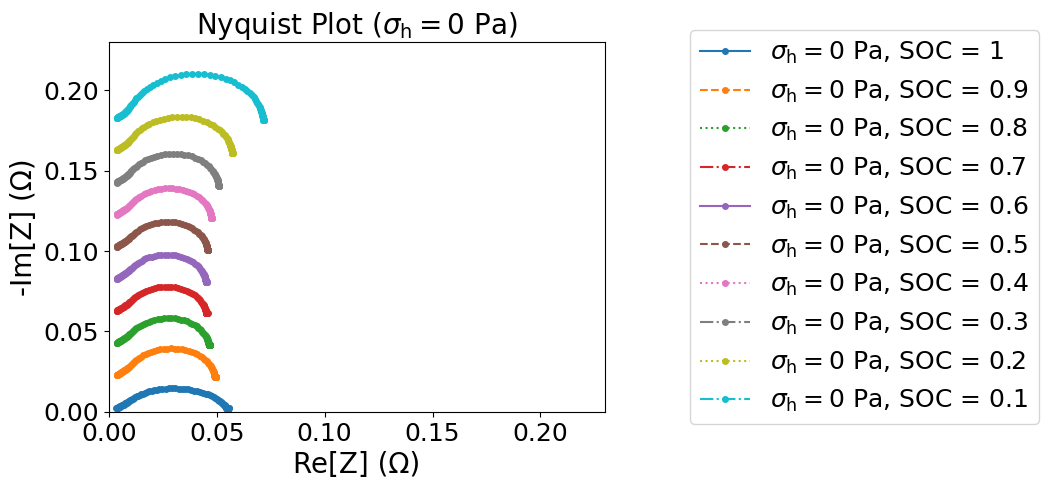

In [ ]:
plt.plot(Z_0_soc100[:, 1], -Z_0_soc100[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=0$ Pa, SOC = 1")
plt.plot(Z_0_soc90[:, 1], -Z_0_soc90[:, 2]+0.02, marker='o', linestyle='--', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=0$ Pa, SOC = 0.9")
plt.plot(Z_0_soc80[:, 1], -Z_0_soc80[:, 2]+0.04, marker='o', linestyle=':', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=0$ Pa, SOC = 0.8")
plt.plot(Z_0_soc70[:, 1], -Z_0_soc70[:, 2]+0.06, marker='o', linestyle='-.', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=0$ Pa, SOC = 0.7")
plt.plot(Z_0_soc60[:, 1], -Z_0_soc60[:, 2]+0.08, marker='o', linestyle='-', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=0$ Pa, SOC = 0.6")
plt.plot(Z_0_soc50[:, 1], -Z_0_soc50[:, 2]+0.10, marker='o', linestyle='--', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=0$ Pa, SOC = 0.5")
plt.plot(Z_0_soc40[:, 1], -Z_0_soc40[:, 2]+0.12, marker='o', linestyle=':', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=0$ Pa, SOC = 0.4")
plt.plot(Z_0_soc30[:, 1], -Z_0_soc30[:, 2]+0.14, marker='o', linestyle='-.', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=0$ Pa, SOC = 0.3")
plt.plot(Z_0_soc20[:, 1], -Z_0_soc20[:, 2]+0.16, marker='o', linestyle=':', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=0$ Pa, SOC = 0.2")
plt.plot(Z_0_soc10[:, 1], -Z_0_soc10[:, 2]+0.18, marker='o', linestyle='-.', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=0$ Pa, SOC = 0.1")


# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot ($\sigma_{\mathrm{h}}=0$ Pa)')
plt.xlim(0, 0.23)
plt.ylim(0, 0.23)

plt.legend(loc = "center right", bbox_to_anchor=(1.9, 0.5))

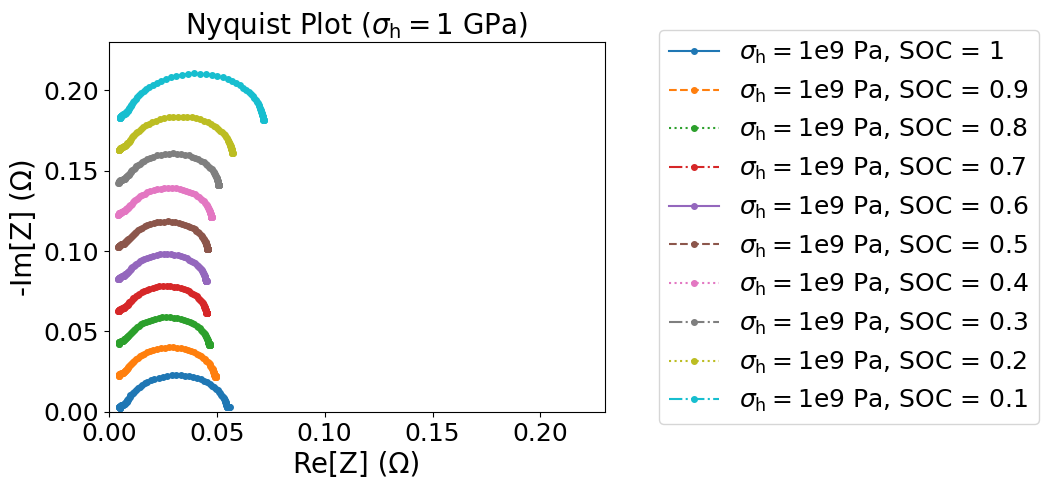

In [120]:
plt.plot(Z_1_soc100[:, 1], -Z_1_soc100[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=1$e9 Pa, SOC = 1")
plt.plot(Z_1_soc90[:, 1], -Z_1_soc90[:, 2]+0.02, marker='o', linestyle='--', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=1$e9 Pa, SOC = 0.9")
plt.plot(Z_1_soc80[:, 1], -Z_1_soc80[:, 2]+0.04, marker='o', linestyle=':', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=1$e9 Pa, SOC = 0.8")
plt.plot(Z_1_soc70[:, 1], -Z_1_soc70[:, 2]+0.06, marker='o', linestyle='-.', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=1$e9 Pa, SOC = 0.7")
plt.plot(Z_1_soc60[:, 1], -Z_1_soc60[:, 2]+0.08, marker='o', linestyle='-', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=1$e9 Pa, SOC = 0.6")
plt.plot(Z_1_soc50[:, 1], -Z_1_soc50[:, 2]+0.1, marker='o', linestyle='--', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=1$e9 Pa, SOC = 0.5")
plt.plot(Z_1_soc40[:, 1], -Z_1_soc40[:, 2]+0.12, marker='o', linestyle=':', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=1$e9 Pa, SOC = 0.4")
plt.plot(Z_1_soc30[:, 1], -Z_1_soc30[:, 2]+0.14, marker='o', linestyle='-.', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=1$e9 Pa, SOC = 0.3")
plt.plot(Z_1_soc20[:, 1], -Z_1_soc20[:, 2]+0.16, marker='o', linestyle=':', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=1$e9 Pa, SOC = 0.2")
plt.plot(Z_1_soc10[:, 1], -Z_1_soc10[:, 2]+0.18, marker='o', linestyle='-.', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=1$e9 Pa, SOC = 0.1")



# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot ($\sigma_{\mathrm{h}}=1$ GPa)')

plt.xlim(0, 0.23)
plt.ylim(0, 0.23)

plt.legend(loc = "center right", bbox_to_anchor=(1.9, 0.5))

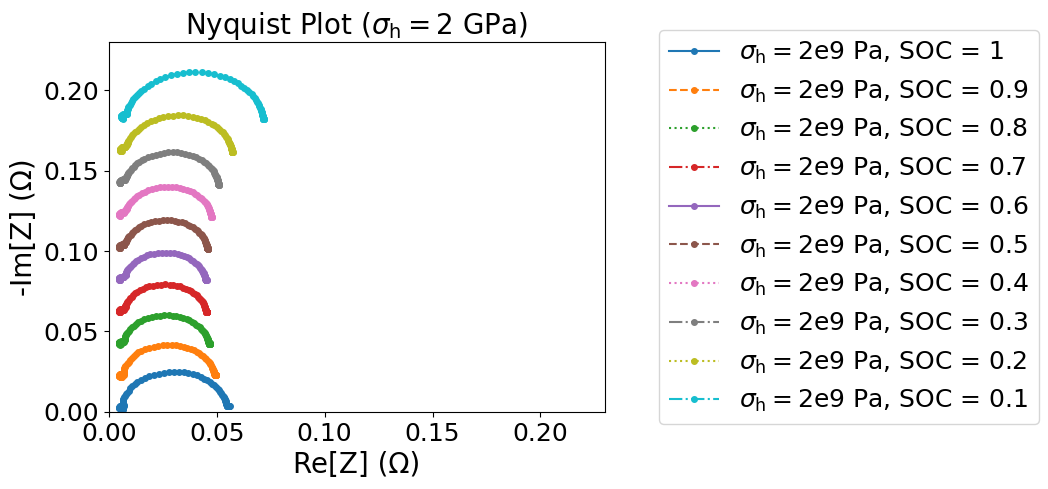

In [123]:
plt.plot(Z_2_soc100[:, 1], -Z_2_soc100[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=2$e9 Pa, SOC = 1")
plt.plot(Z_2_soc90[:, 1], -Z_2_soc90[:, 2]+0.02, marker='o', linestyle='--', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=2$e9 Pa, SOC = 0.9")
plt.plot(Z_2_soc80[:, 1], -Z_2_soc80[:, 2]+0.04, marker='o', linestyle=':', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=2$e9 Pa, SOC = 0.8")
plt.plot(Z_2_soc70[:, 1], -Z_2_soc70[:, 2]+0.06, marker='o', linestyle='-.', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=2$e9 Pa, SOC = 0.7")
plt.plot(Z_2_soc60[:, 1], -Z_2_soc60[:, 2]+0.08, marker='o', linestyle='-', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=2$e9 Pa, SOC = 0.6")
plt.plot(Z_2_soc50[:, 1], -Z_2_soc50[:, 2]+0.1, marker='o', linestyle='--', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=2$e9 Pa, SOC = 0.5")
plt.plot(Z_2_soc40[:, 1], -Z_2_soc40[:, 2]+0.12, marker='o', linestyle=':', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=2$e9 Pa, SOC = 0.4")
plt.plot(Z_2_soc30[:, 1], -Z_2_soc30[:, 2]+0.14, marker='o', linestyle='-.', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=2$e9 Pa, SOC = 0.3")
plt.plot(Z_2_soc20[:, 1], -Z_2_soc20[:, 2]+0.16, marker='o', linestyle=':', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=2$e9 Pa, SOC = 0.2")
plt.plot(Z_2_soc10[:, 1], -Z_2_soc10[:, 2]+0.18, marker='o', linestyle='-.', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=2$e9 Pa, SOC = 0.1")


# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot ($\sigma_{\mathrm{h}}=2$ GPa)')

plt.xlim(0, 0.23)
plt.ylim(0, 0.23)

plt.legend(loc = "center right", bbox_to_anchor=(1.9, 0.5))

In [7]:
# import from txt
Z_0_soc100 = np.loadtxt("Z_0GPa_soc100_highPrecision.txt", skiprows=1)
Z_1_soc100 = np.loadtxt("Z_1GPa_soc100_highPrecision.txt", skiprows=1)
Z_2_soc100 = np.loadtxt("Z_2GPa_soc100_highPrecision.txt", skiprows=1)
Z_10MPa_soc100 = np.loadtxt("Z_10MPa_soc100.txt", skiprows=1)

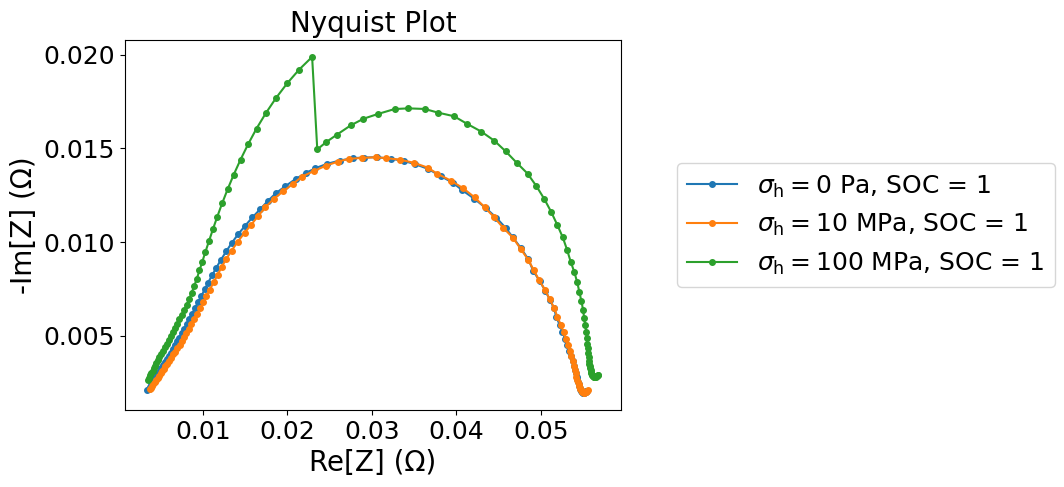

In [8]:
plt.plot(Z_0_soc100[:, 1], -Z_0_soc100[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=0$ Pa, SOC = 1")
# plt.plot(Z_1_soc100[:, 1], -Z_1_soc100[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=1$e9 Pa, SOC = 1")
# plt.plot(Z_2_soc100[:, 1], -Z_2_soc100[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=2$e9 Pa, SOC = 1")
plt.plot(Z_10MPa_soc100[:, 1], -Z_10MPa_soc100[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=10$ MPa, SOC = 1")
plt.plot(Z_100MPa_soc100[:, 1], -Z_100MPa_soc100[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=100$ MPa, SOC = 1")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

plt.legend(loc = "center right", bbox_to_anchor=(1.9, 0.5))

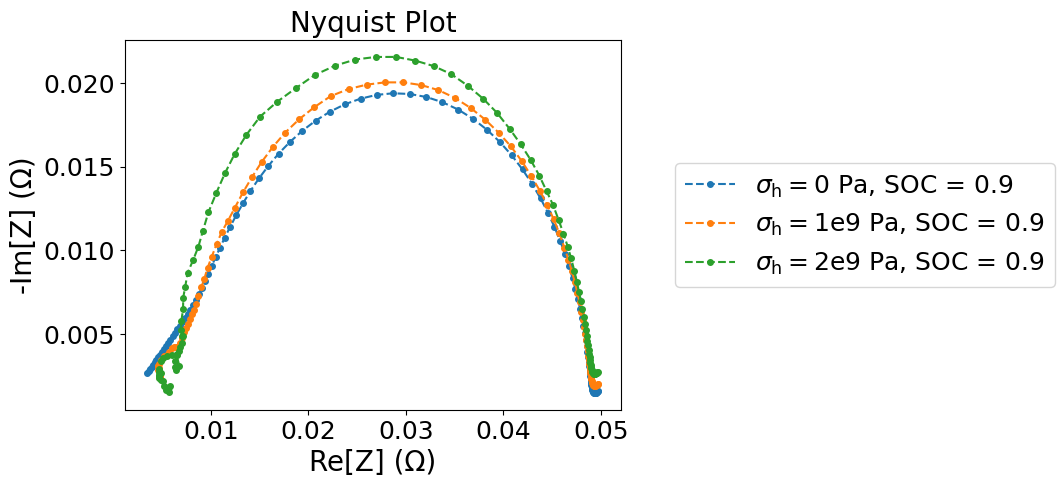

In [98]:
plt.plot(Z_0_soc90[:, 1], -Z_0_soc90[:, 2], marker='o', linestyle='--', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=0$ Pa, SOC = 0.9")
plt.plot(Z_1_soc90[:, 1], -Z_1_soc90[:, 2], marker='o', linestyle='--', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=1$e9 Pa, SOC = 0.9")
plt.plot(Z_2_soc90[:, 1], -Z_2_soc90[:, 2], marker='o', linestyle='--', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=2$e9 Pa, SOC = 0.9")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

plt.legend(loc = "center right", bbox_to_anchor=(1.9, 0.5))

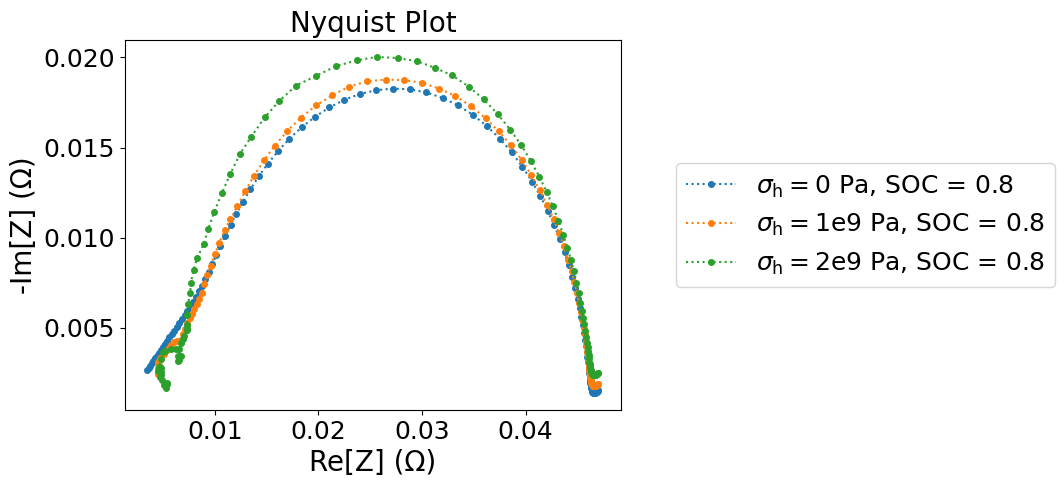

In [99]:
plt.plot(Z_0_soc80[:, 1], -Z_0_soc80[:, 2], marker='o', linestyle=':', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=0$ Pa, SOC = 0.8")
plt.plot(Z_1_soc80[:, 1], -Z_1_soc80[:, 2], marker='o', linestyle=':', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=1$e9 Pa, SOC = 0.8")
plt.plot(Z_2_soc80[:, 1], -Z_2_soc80[:, 2], marker='o', linestyle=':', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=2$e9 Pa, SOC = 0.8")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

plt.legend(loc = "center right", bbox_to_anchor=(1.9, 0.5))

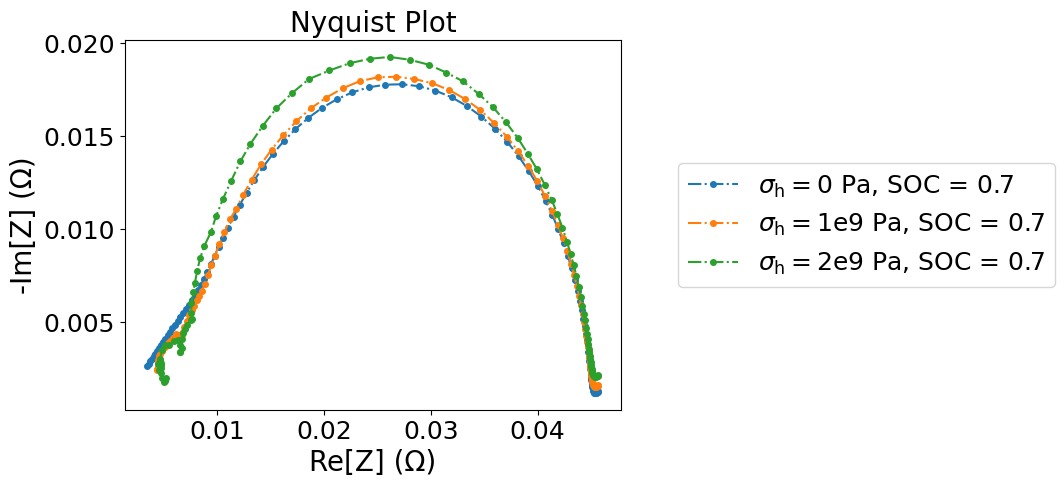

In [100]:
plt.plot(Z_0_soc70[:, 1], -Z_0_soc70[:, 2], marker='o', linestyle='-.', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=0$ Pa, SOC = 0.7")
plt.plot(Z_1_soc70[:, 1], -Z_1_soc70[:, 2], marker='o', linestyle='-.', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=1$e9 Pa, SOC = 0.7")
plt.plot(Z_2_soc70[:, 1], -Z_2_soc70[:, 2], marker='o', linestyle='-.', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=2$e9 Pa, SOC = 0.7")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

plt.legend(loc = "center right", bbox_to_anchor=(1.9, 0.5))

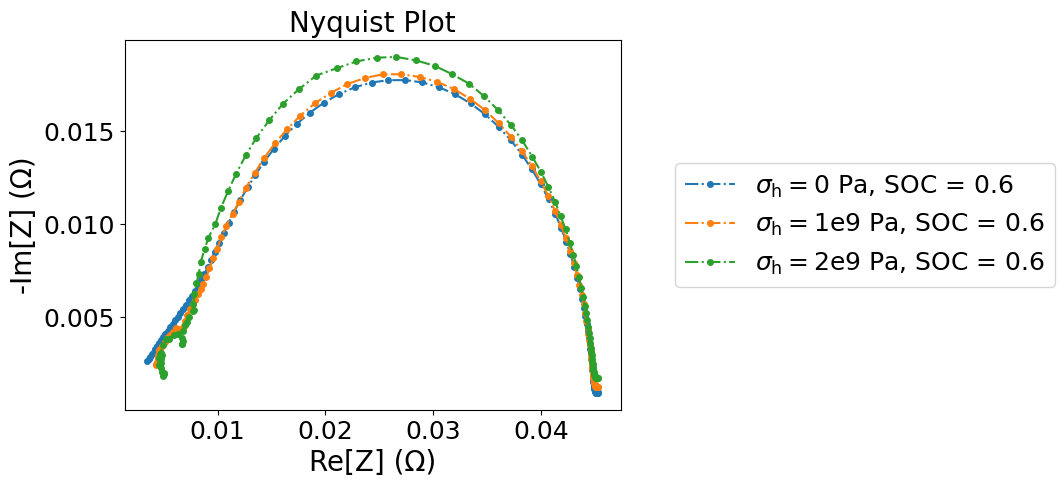

In [101]:
plt.plot(Z_0_soc60[:, 1], -Z_0_soc60[:, 2], marker='o', linestyle='-.', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=0$ Pa, SOC = 0.6")
plt.plot(Z_1_soc60[:, 1], -Z_1_soc60[:, 2], marker='o', linestyle='-.', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=1$e9 Pa, SOC = 0.6")
plt.plot(Z_2_soc60[:, 1], -Z_2_soc60[:, 2], marker='o', linestyle='-.', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=2$e9 Pa, SOC = 0.6")


# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

plt.legend(loc = "center right", bbox_to_anchor=(1.9, 0.5))

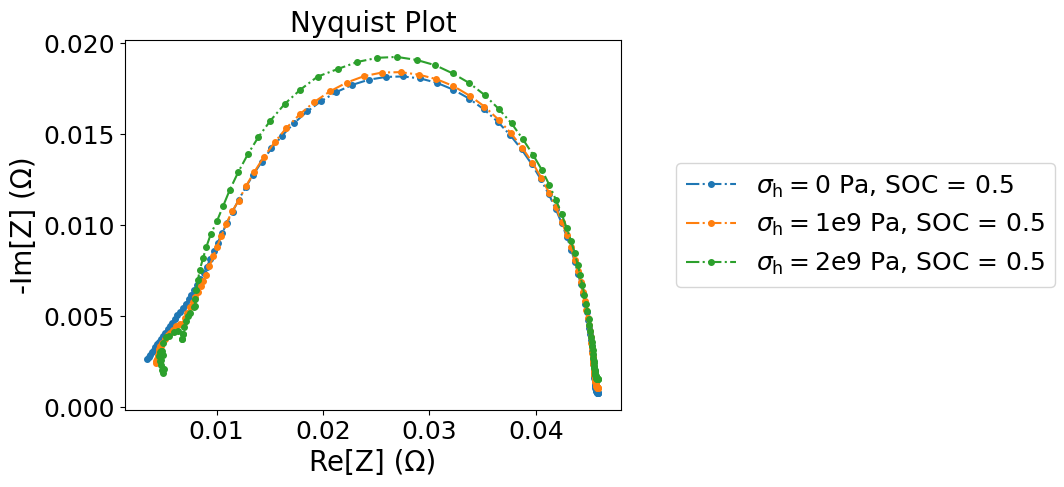

In [102]:
plt.plot(Z_0_soc50[:, 1], -Z_0_soc50[:, 2], marker='o', linestyle='-.', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=0$ Pa, SOC = 0.5")
plt.plot(Z_1_soc50[:, 1], -Z_1_soc50[:, 2], marker='o', linestyle='-.', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=1$e9 Pa, SOC = 0.5")
plt.plot(Z_2_soc50[:, 1], -Z_2_soc50[:, 2], marker='o', linestyle='-.', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=2$e9 Pa, SOC = 0.5")


# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

plt.legend(loc = "center right", bbox_to_anchor=(1.9, 0.5))

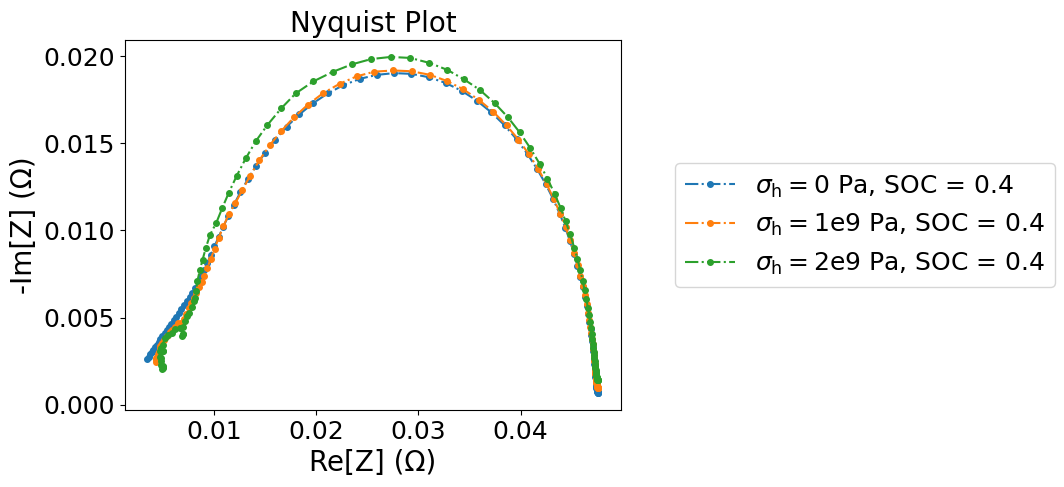

In [103]:
plt.plot(Z_0_soc40[:, 1], -Z_0_soc40[:, 2], marker='o', linestyle='-.', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=0$ Pa, SOC = 0.4")
plt.plot(Z_1_soc40[:, 1], -Z_1_soc40[:, 2], marker='o', linestyle='-.', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=1$e9 Pa, SOC = 0.4")
plt.plot(Z_2_soc40[:, 1], -Z_2_soc40[:, 2], marker='o', linestyle='-.', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=2$e9 Pa, SOC = 0.4")


# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

plt.legend(loc = "center right", bbox_to_anchor=(1.9, 0.5))

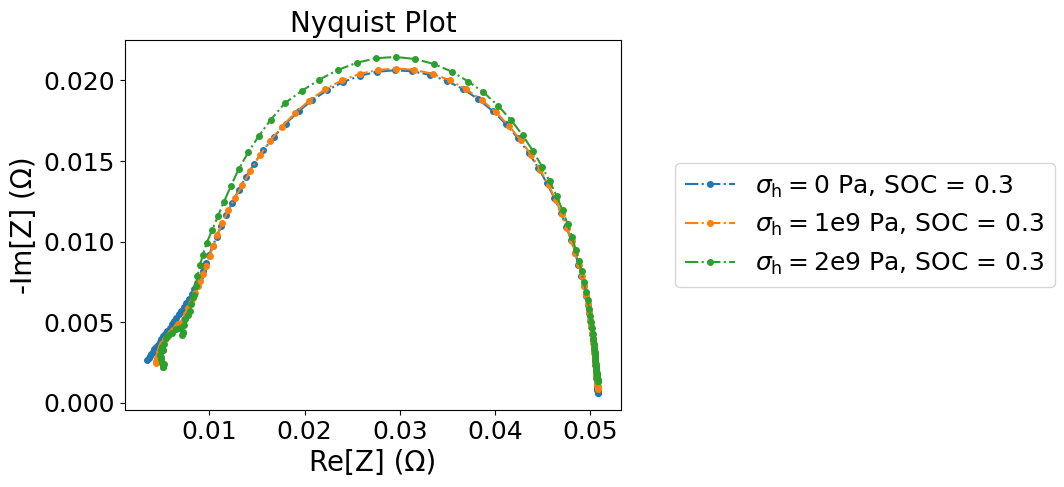

In [104]:
plt.plot(Z_0_soc30[:, 1], -Z_0_soc30[:, 2], marker='o', linestyle='-.', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=0$ Pa, SOC = 0.3")
plt.plot(Z_1_soc30[:, 1], -Z_1_soc30[:, 2], marker='o', linestyle='-.', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=1$e9 Pa, SOC = 0.3")
plt.plot(Z_2_soc30[:, 1], -Z_2_soc30[:, 2], marker='o', linestyle='-.', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=2$e9 Pa, SOC = 0.3")


# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

plt.legend(loc = "center right", bbox_to_anchor=(1.9, 0.5))

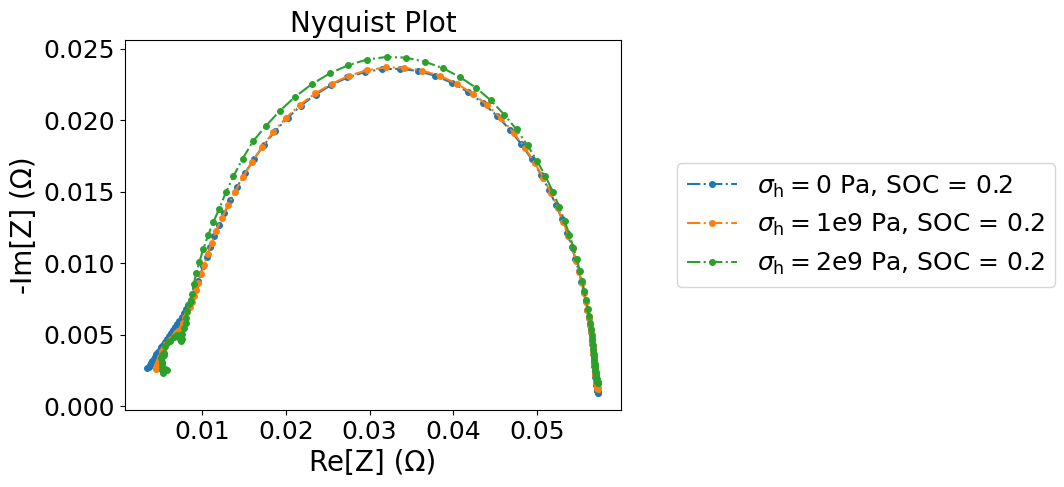

In [105]:
plt.plot(Z_0_soc20[:, 1], -Z_0_soc20[:, 2], marker='o', linestyle='-.', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=0$ Pa, SOC = 0.2")
plt.plot(Z_1_soc20[:, 1], -Z_1_soc20[:, 2], marker='o', linestyle='-.', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=1$e9 Pa, SOC = 0.2")
plt.plot(Z_2_soc20[:, 1], -Z_2_soc20[:, 2], marker='o', linestyle='-.', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=2$e9 Pa, SOC = 0.2")


# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

plt.legend(loc = "center right", bbox_to_anchor=(1.9, 0.5))

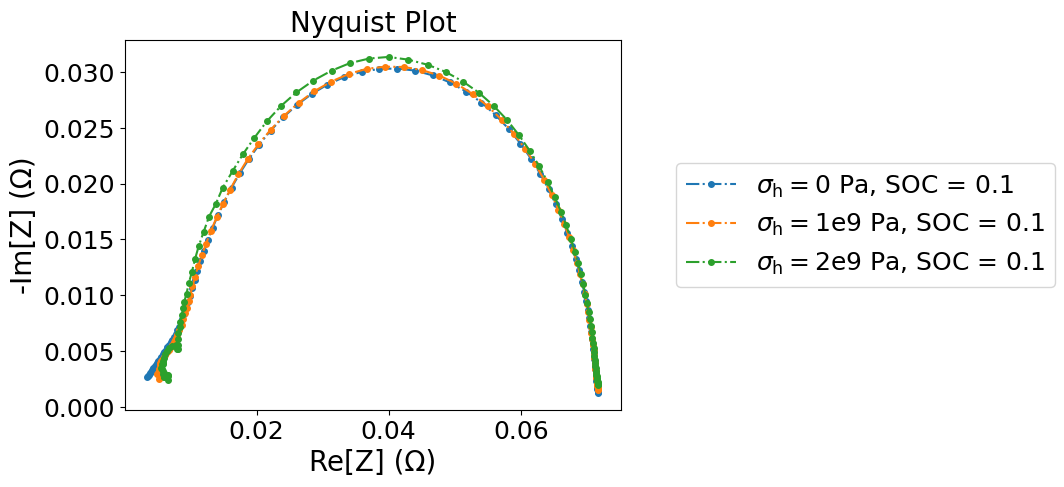

In [106]:
plt.plot(Z_0_soc10[:, 1], -Z_0_soc10[:, 2], marker='o', linestyle='-.', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=0$ Pa, SOC = 0.1")
plt.plot(Z_1_soc10[:, 1], -Z_1_soc10[:, 2], marker='o', linestyle='-.', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=1$e9 Pa, SOC = 0.1")
plt.plot(Z_2_soc10[:, 1], -Z_2_soc10[:, 2], marker='o', linestyle='-.', linewidth=1.5, markersize=4, label="$\sigma_{\mathrm{h}}=2$e9 Pa, SOC = 0.1")


# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

plt.legend(loc = "center right", bbox_to_anchor=(1.9, 0.5))

# Različne $\Omega$

In [52]:
param0 = pybamm.ParameterValues("Ai2020") 
param0.search("molar volume")

Results for 'molar volume': ['SEI partial molar volume [m3.mol-1]', 'Negative electrode partial molar volume [m3.mol-1]', 'Positive electrode partial molar volume [m3.mol-1]']
SEI partial molar volume [m3.mol-1] -> 9.585e-05
Negative electrode partial molar volume [m3.mol-1] -> 3.1e-06
Positive electrode partial molar volume [m3.mol-1] -> -7.28e-07


### $\Omega$ = 3.1e-6 $m^3/mol$ (default)

#### $\sigma_h$ = 0 Pa, SOC 1

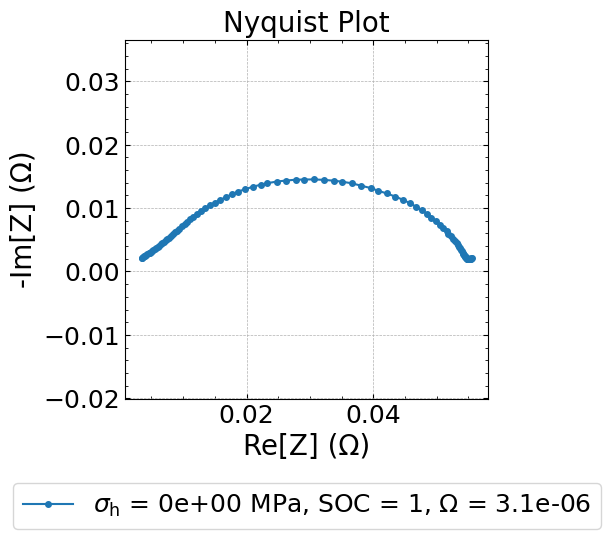

<Figure size 640x480 with 0 Axes>

In [24]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_0MPa_soc100_omgDef = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        )

    param0 = pybamm.ParameterValues("Ai2020") 
    param0.update(
        {"Hydrostatic stress [Pa]": 0},
        check_already_exists=False  
    )
    param0["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param0, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_0MPa_soc100_omgDef.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_0MPa_soc100_omgDef = np.array(Z_0MPa_soc100_omgDef)

# save to txt
np.savetxt("Z_0MPa_soc100_OmgDef.txt", Z_0MPa_soc100_omgDef)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_0MPa_soc100_omgDef[:, 1], -Z_0MPa_soc100_omgDef[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
         label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param0['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param0['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_0MPa_soc100_omgDef[:, 1] + 1j * Z_0MPa_soc100_omgDef[:, 2])  # Combine real and imag parts
phase = np.angle(Z_0MPa_soc100_omgDef[:, 1] + 1j * Z_0MPa_soc100_omgDef[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_0MPa_soc100_omgDef[:, 0]  # Assuming first column is frequency

# Tidy layout
plt.tight_layout()
plt.show()

#### $\sigma_h$ = 1 MPa, SOC 1

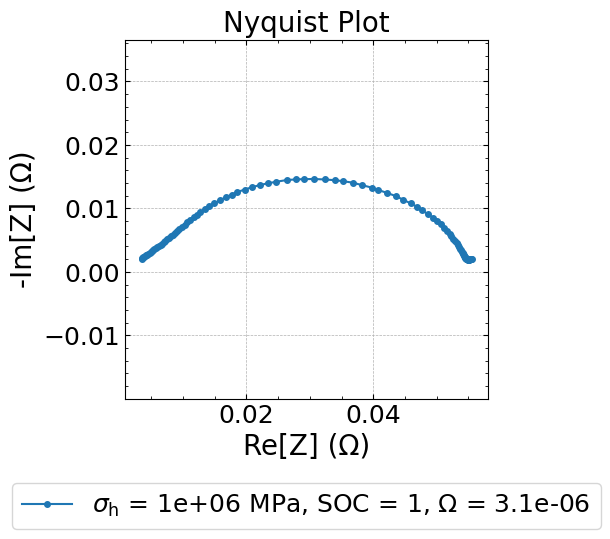

<Figure size 640x480 with 0 Axes>

In [57]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_1MPa_soc100_omgDef = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        )

    param1 = pybamm.ParameterValues("Ai2020") 
    param1.update(
        {"Hydrostatic stress [Pa]": 1e6},
        check_already_exists=False  
    )
    param1["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param1, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_1MPa_soc100_omgDef.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_1MPa_soc100_omgDef = np.array(Z_1MPa_soc100_omgDef)

# save to txt
np.savetxt("Z_1MPa_soc100_OmgDef.txt", Z_1MPa_soc100_omgDef)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_1MPa_soc100_omgDef[:, 1], -Z_1MPa_soc100_omgDef[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
         label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param1['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param1['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_1MPa_soc100_omgDef[:, 1] + 1j * Z_1MPa_soc100_omgDef[:, 2])  # Combine real and imag parts
phase = np.angle(Z_1MPa_soc100_omgDef[:, 1] + 1j * Z_1MPa_soc100_omgDef[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_1MPa_soc100_omgDef[:, 0]  # Assuming first column is frequency

# Tidy layout
plt.tight_layout()
plt.show()

#### $\sigma_h$ = 0.5 MPa, SOC 1

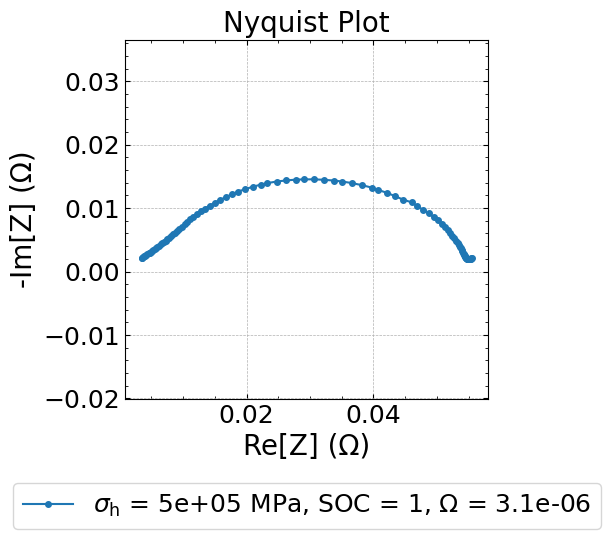

<Figure size 640x480 with 0 Axes>

In [61]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_05MPa_soc100_omgDef = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        )

    param05 = pybamm.ParameterValues("Ai2020") 
    param05.update(
        {"Hydrostatic stress [Pa]": 0.5e6},
        check_already_exists=False  
    )
    param05["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param05, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_05MPa_soc100_omgDef.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_05MPa_soc100_omgDef = np.array(Z_05MPa_soc100_omgDef)

# save to txt
np.savetxt("Z_05MPa_soc100_OmgDef.txt", Z_05MPa_soc100_omgDef)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_05MPa_soc100_omgDef[:, 1], -Z_05MPa_soc100_omgDef[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
         label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param05['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param05['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_05MPa_soc100_omgDef[:, 1] + 1j * Z_05MPa_soc100_omgDef[:, 2])  # Combine real and imag parts
phase = np.angle(Z_05MPa_soc100_omgDef[:, 1] + 1j * Z_05MPa_soc100_omgDef[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_05MPa_soc100_omgDef[:, 0]  # Assuming first column is frequency

# Tidy layout
plt.tight_layout()
plt.show()

#### $\sigma_h$ = 0.1 MPa, SOC 1

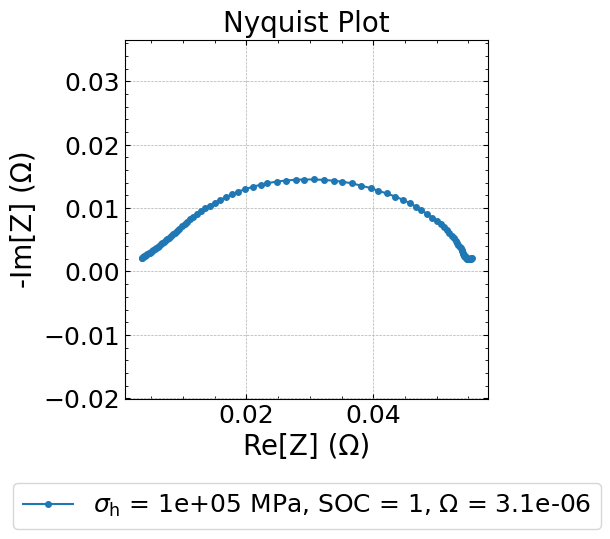

<Figure size 640x480 with 0 Axes>

In [64]:
hydrostatic_stress = 0.1e6

I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_01MPa_soc100_omgDef = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        )

    param01 = pybamm.ParameterValues("Ai2020") 
    param01.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param01["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param01, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_01MPa_soc100_omgDef.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_01MPa_soc100_omgDef = np.array(Z_01MPa_soc100_omgDef)

# save to txt
np.savetxt("Z_01MPa_soc100_OmgDef.txt", Z_01MPa_soc100_omgDef)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_01MPa_soc100_omgDef[:, 1], -Z_01MPa_soc100_omgDef[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
         label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param01['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param01['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_01MPa_soc100_omgDef[:, 1] + 1j * Z_01MPa_soc100_omgDef[:, 2])  # Combine real and imag parts
phase = np.angle(Z_01MPa_soc100_omgDef[:, 1] + 1j * Z_01MPa_soc100_omgDef[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_01MPa_soc100_omgDef[:, 0]  # Assuming first column is frequency

# Tidy layout
plt.tight_layout()
plt.show()

#### $\sigma_h$ = 2 MPa, SOC 1

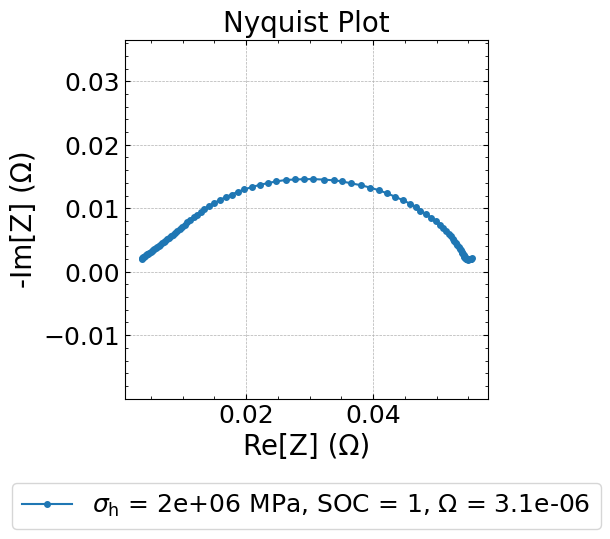

<Figure size 640x480 with 0 Axes>

In [65]:
hydrostatic_stress = 2e6

I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_2MPa_soc100_omgDef = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        )

    param2 = pybamm.ParameterValues("Ai2020") 
    param2.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param2["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param2, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_2MPa_soc100_omgDef.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_2MPa_soc100_omgDef = np.array(Z_2MPa_soc100_omgDef)

# save to txt
np.savetxt("Z_2MPa_soc100_OmgDef.txt", Z_2MPa_soc100_omgDef)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_2MPa_soc100_omgDef[:, 1], -Z_2MPa_soc100_omgDef[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
         label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param2['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param2['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_2MPa_soc100_omgDef[:, 1] + 1j * Z_2MPa_soc100_omgDef[:, 2])  # Combine real and imag parts
phase = np.angle(Z_2MPa_soc100_omgDef[:, 1] + 1j * Z_2MPa_soc100_omgDef[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_2MPa_soc100_omgDef[:, 0]  # Assuming first column is frequency

# Tidy layout
plt.tight_layout()
plt.show()

#### Primerjava

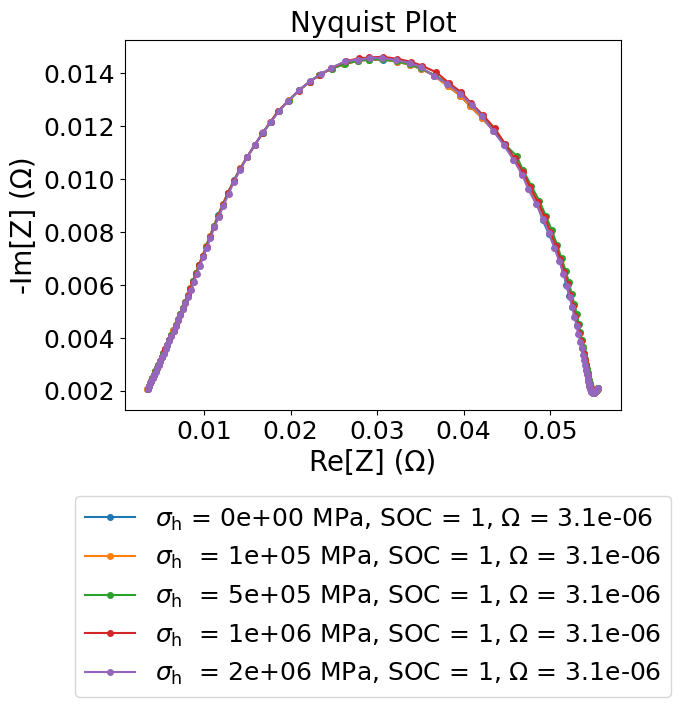

In [67]:
plt.plot(Z_0MPa_soc100_omgDef[:, 1], -Z_0MPa_soc100_omgDef[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param0['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param0['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

plt.plot(Z_01MPa_soc100_omgDef[:, 1], -Z_01MPa_soc100_omgDef[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
        label=fr"$\sigma_{{\mathrm{{h}}}}$  = {param01['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param01['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

plt.plot(Z_05MPa_soc100_omgDef[:, 1], -Z_05MPa_soc100_omgDef[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
        label=fr"$\sigma_{{\mathrm{{h}}}}$  = {param05['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param05['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

plt.plot(Z_1MPa_soc100_omgDef[:, 1], -Z_1MPa_soc100_omgDef[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
        label=fr"$\sigma_{{\mathrm{{h}}}}$  = {param1['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param1['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

plt.plot(Z_2MPa_soc100_omgDef[:, 1], -Z_2MPa_soc100_omgDef[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
        label=fr"$\sigma_{{\mathrm{{h}}}}$  = {param2['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param2['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')


plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

### $\Omega$ = 1e-6 $m^3/mol$

#### $\sigma_h$ = 0 Pa, SOC = 1

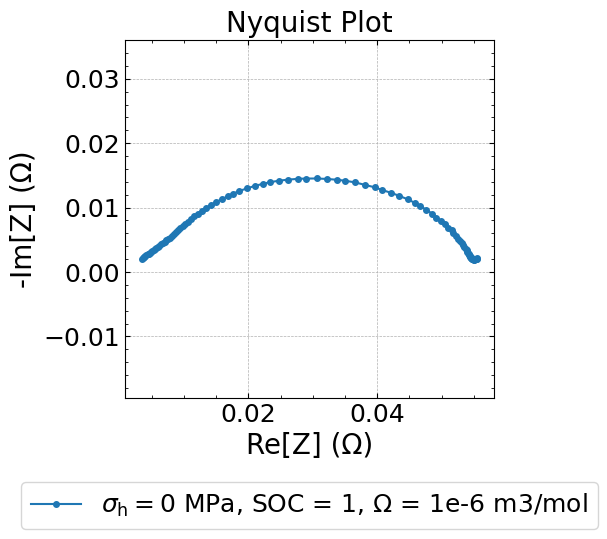

<Figure size 640x480 with 0 Axes>

In [28]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_0MPa_soc100_omg1 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        )

    param0 = pybamm.ParameterValues("Ai2020") 
    param0.update(
        {"Hydrostatic stress [Pa]": 0},
        check_already_exists=False  
    )
    param0.update(
    {"Negative electrode partial molar volume [m3.mol-1]": 1e-6},
    check_already_exists=False
    )
    param0["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param0, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_0MPa_soc100_omg1.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_0MPa_soc100_omg1 = np.array(Z_0MPa_soc100_omg1)

# save to txt
np.savetxt("Z_0MPa_soc100_Omg1e-6.txt", Z_0MPa_soc100_omg1)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_0MPa_soc100_omg1[:, 1], -Z_0MPa_soc100_omg1[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
         label="$\sigma_{\mathrm{h}}=0$ MPa, SOC = 1, $\Omega$ = 1e-6 m3/mol")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_0MPa_soc100_omg1[:, 1] + 1j * Z_0MPa_soc100_omg1[:, 2])  # Combine real and imag parts
phase = np.angle(Z_0MPa_soc100_omg1[:, 1] + 1j * Z_0MPa_soc100_omg1[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_0MPa_soc100_omg1[:, 0]  # Assuming first column is frequency

# Tidy layout
plt.tight_layout()
plt.show()

#### $\sigma_h$ = 1 MPa, SOC = 1

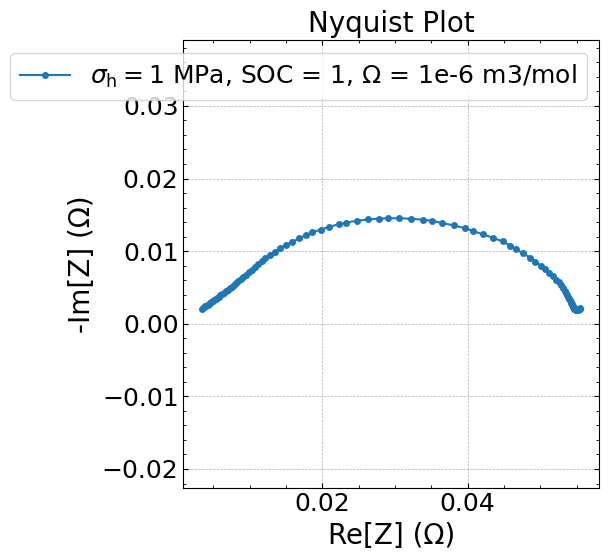

In [ ]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_1MPa_soc100_omg1 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        )

    # PARAMETRI
    param1 = pybamm.ParameterValues("Ai2020") 
    param1.update(
        {"Hydrostatic stress [Pa]": 1e6},
        check_already_exists=False  
    )
    param1.update(
    {"Negative electrode partial molar volume [m3.mol-1]": 1e-6},
    check_already_exists=False
    )
    param1["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param1, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_1MPa_soc100_omg1.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_1MPa_soc100_omg1 = np.array(Z_1MPa_soc100_omg1)

# save to txt
np.savetxt("Z_1MPa_soc100_Omg1e-6.txt", Z_1MPa_soc100_omg1)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_1MPa_soc100_omg1[:, 1], -Z_1MPa_soc100_omg1[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
         label="$\sigma_{\mathrm{h}}=1$ MPa, SOC = 1, $\Omega$ = 1e-6 m3/mol")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

# # Compute magnitude (absolute value) and phase (angle)
# magnitude = np.abs(Z_1MPa_soc100_omg1[:, 1] + 1j * Z_1MPa_soc100_omg1[:, 2])  # Combine real and imag parts
# phase = np.angle(Z_1MPa_soc100_omg1[:, 1] + 1j * Z_1MPa_soc100_omg1[:, 2], deg=True)  # Phase in degrees

# # Frequency axis (log scale typical for Bode)
# freq = Z_1MPa_soc100_omg1[:, 0]  # Assuming first column is frequency

# Tidy layout
plt.tight_layout()
plt.show()


#### Primerjava

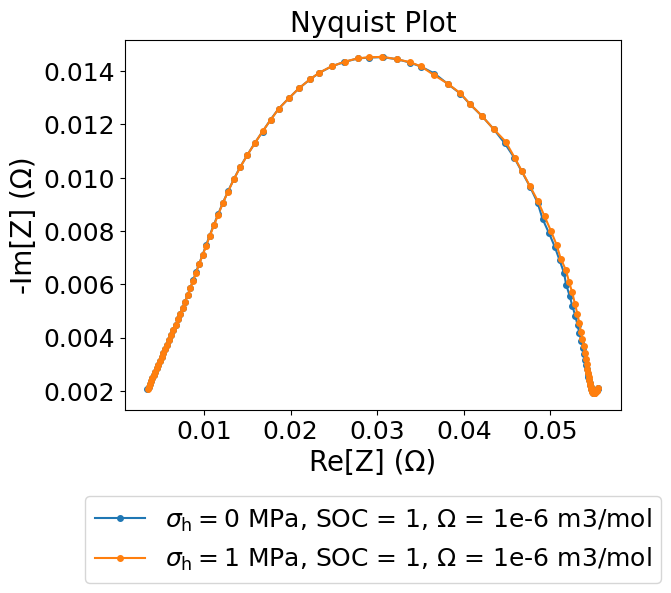

In [ ]:
plt.plot(Z_0MPa_soc100_omg1[:, 1], -Z_0MPa_soc100_omg1[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param0['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param0['Negative electrode partial molar volume [m3.mol-1]']:.1e}")
         
plt.plot(Z_1MPa_soc100_omg1[:, 1], -Z_1MPa_soc100_omg1[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
        label=fr"$\sigma_{{\mathrm{{h}}}}$  = {param1['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param1['Negative electrode partial molar volume [m3.mol-1]']:.1e}")


# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')


plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

### $\Omega$ = 6.2e-6 $m^3/mol$ (2 x default)

#### $\sigma_h$ = 0 Pa, SOC 1

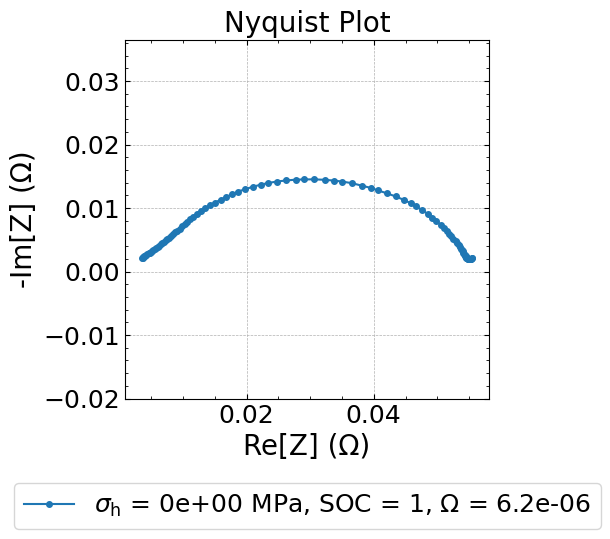

<Figure size 640x480 with 0 Axes>

In [68]:
hydrostatic_stress = 0
omega = 6.2e-6

I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_0MPa_soc100_omg6_2 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        )

    param0 = pybamm.ParameterValues("Ai2020") 
    param0.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param0.update(
    {"Negative electrode partial molar volume [m3.mol-1]": omega},
    check_already_exists=False
    )
    param0["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param0, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_0MPa_soc100_omg6_2.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_0MPa_soc100_omg6_2 = np.array(Z_0MPa_soc100_omg6_2)

# save to txt
np.savetxt("Z_0MPa_soc100_Omg6_2.txt", Z_0MPa_soc100_omg6_2)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_0MPa_soc100_omg6_2[:, 1], -Z_0MPa_soc100_omg6_2[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
         label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param0['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param0['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_0MPa_soc100_omg6_2[:, 1] + 1j * Z_0MPa_soc100_omg6_2[:, 2])  # Combine real and imag parts
phase = np.angle(Z_0MPa_soc100_omg6_2[:, 1] + 1j * Z_0MPa_soc100_omg6_2[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_0MPa_soc100_omg6_2[:, 0]  # Assuming first column is frequency

# Tidy layout
plt.tight_layout()
plt.show()

#### $\sigma_h$ = 1 MPa, SOC 1

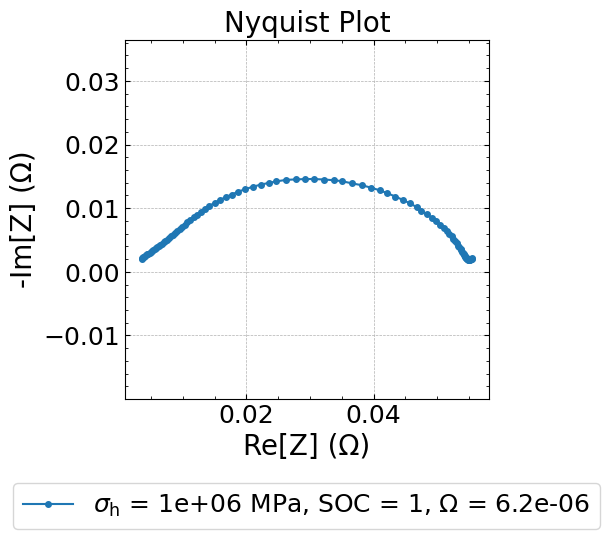

<Figure size 640x480 with 0 Axes>

In [69]:
hydrostic_stress = 1e6
omega = 6.2e-6

I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_1MPa_soc100_omg6_2 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        )

    param1 = pybamm.ParameterValues("Ai2020") 
    param1.update(
        {"Hydrostatic stress [Pa]": hydrostic_stress},
        check_already_exists=False  
    )
    param1.update(
    {"Negative electrode partial molar volume [m3.mol-1]": omega},
    check_already_exists=False
    )
    param1["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param1, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_1MPa_soc100_omg6_2.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_1MPa_soc100_omg6_2 = np.array(Z_1MPa_soc100_omg6_2)

# save to txt
np.savetxt("Z_1MPa_soc100_Omg6_2.txt", Z_1MPa_soc100_omg6_2)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_1MPa_soc100_omg6_2[:, 1], -Z_1MPa_soc100_omg6_2[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
         label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param1['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param1['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_1MPa_soc100_omg6_2[:, 1] + 1j * Z_1MPa_soc100_omg6_2[:, 2])  # Combine real and imag parts
phase = np.angle(Z_1MPa_soc100_omg6_2[:, 1] + 1j * Z_1MPa_soc100_omg6_2[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_1MPa_soc100_omg6_2[:, 0]  # Assuming first column is frequency

# Tidy layout
plt.tight_layout()
plt.show()

#### $\sigma_h$ = 0.5 MPa, SOC 1

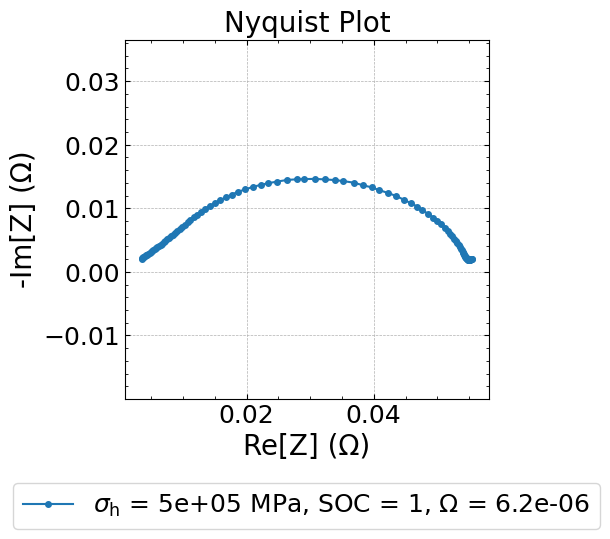

<Figure size 640x480 with 0 Axes>

In [70]:
hydrostatic_stress = 0.5e6
omega = 6.2e-6

I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_05MPa_soc100_omg6_2 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        )

    param05 = pybamm.ParameterValues("Ai2020") 
    param05.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param05.update(
    {"Negative electrode partial molar volume [m3.mol-1]": omega},
    check_already_exists=False
    )
    param05["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param05, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_05MPa_soc100_omg6_2.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_05MPa_soc100_omg6_2 = np.array(Z_05MPa_soc100_omg6_2)

# save to txt
np.savetxt("Z_05MPa_soc100_Omg6_2.txt", Z_05MPa_soc100_omg6_2)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_05MPa_soc100_omg6_2[:, 1], -Z_05MPa_soc100_omg6_2[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
         label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param05['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param05['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_05MPa_soc100_omg6_2[:, 1] + 1j * Z_05MPa_soc100_omg6_2[:, 2])  # Combine real and imag parts
phase = np.angle(Z_05MPa_soc100_omg6_2[:, 1] + 1j * Z_05MPa_soc100_omg6_2[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_05MPa_soc100_omg6_2[:, 0]  # Assuming first column is frequency

# Tidy layout
plt.tight_layout()
plt.show()

#### $\sigma_h$ = 0.1 MPa, SOC 1

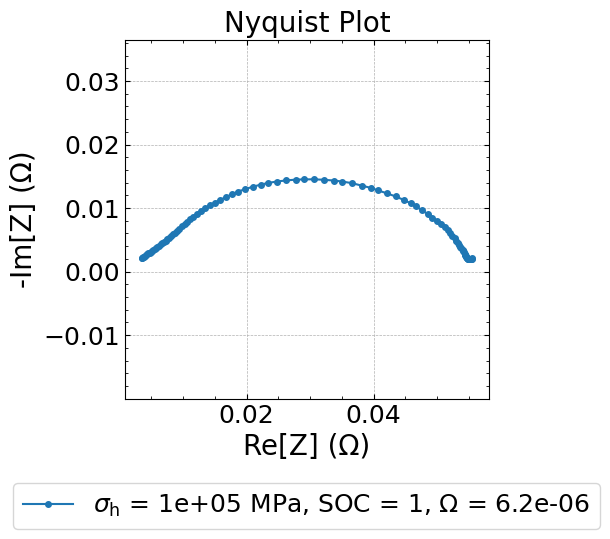

<Figure size 640x480 with 0 Axes>

In [71]:
hydrostatic_stress = 0.1e6
omega = 6.2e-6

I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_01MPa_soc100_omg6_2 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        )

    param01 = pybamm.ParameterValues("Ai2020") 
    param01.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param01.update(
    {"Negative electrode partial molar volume [m3.mol-1]": omega},
    check_already_exists=False
    )
    param01["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param01, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_01MPa_soc100_omg6_2.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_01MPa_soc100_omg6_2 = np.array(Z_01MPa_soc100_omg6_2)

# save to txt
np.savetxt("Z_01MPa_soc100_Omg6_2.txt", Z_01MPa_soc100_omg6_2)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_01MPa_soc100_omg6_2[:, 1], -Z_01MPa_soc100_omg6_2[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
         label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param01['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param01['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_01MPa_soc100_omg6_2[:, 1] + 1j * Z_01MPa_soc100_omg6_2[:, 2])  # Combine real and imag parts
phase = np.angle(Z_01MPa_soc100_omg6_2[:, 1] + 1j * Z_01MPa_soc100_omg6_2[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_01MPa_soc100_omgDef[:, 0]  # Assuming first column is frequency

# Tidy layout
plt.tight_layout()
plt.show()

#### $\sigma_h$ = 2 MPa, SOC 1

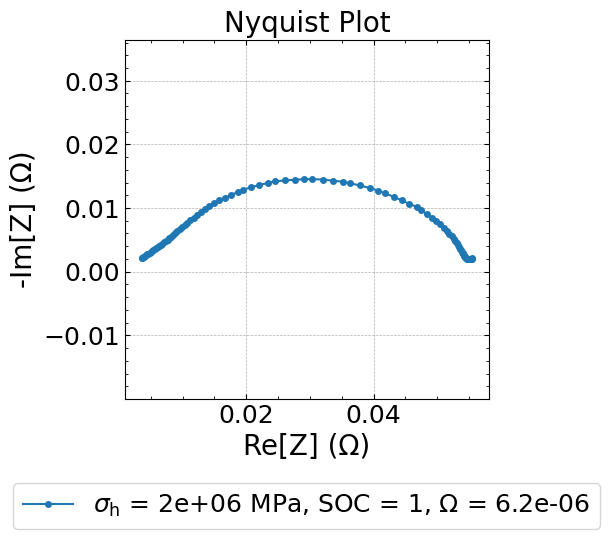

<Figure size 640x480 with 0 Axes>

In [72]:
hydrostatic_stress = 2e6
omega = 6.2e-6

I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_2MPa_soc100_omg6_2 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        )

    param2 = pybamm.ParameterValues("Ai2020") 
    param2.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param2.update(
    {"Negative electrode partial molar volume [m3.mol-1]": omega},
    check_already_exists=False
    )
    param2["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param2, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_2MPa_soc100_omg6_2.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_2MPa_soc100_omg6_2 = np.array(Z_2MPa_soc100_omg6_2)

# save to txt
np.savetxt("Z_2MPa_soc100_Omg6_2.txt", Z_2MPa_soc100_omg6_2)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_2MPa_soc100_omg6_2[:, 1], -Z_2MPa_soc100_omg6_2[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
         label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param2['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param2['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_2MPa_soc100_omg6_2[:, 1] + 1j * Z_2MPa_soc100_omg6_2[:, 2])  # Combine real and imag parts
phase = np.angle(Z_2MPa_soc100_omg6_2[:, 1] + 1j * Z_2MPa_soc100_omg6_2[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_2MPa_soc100_omg6_2[:, 0]  # Assuming first column is frequency

# Tidy layout
plt.tight_layout()
plt.show()

#### Primerjava

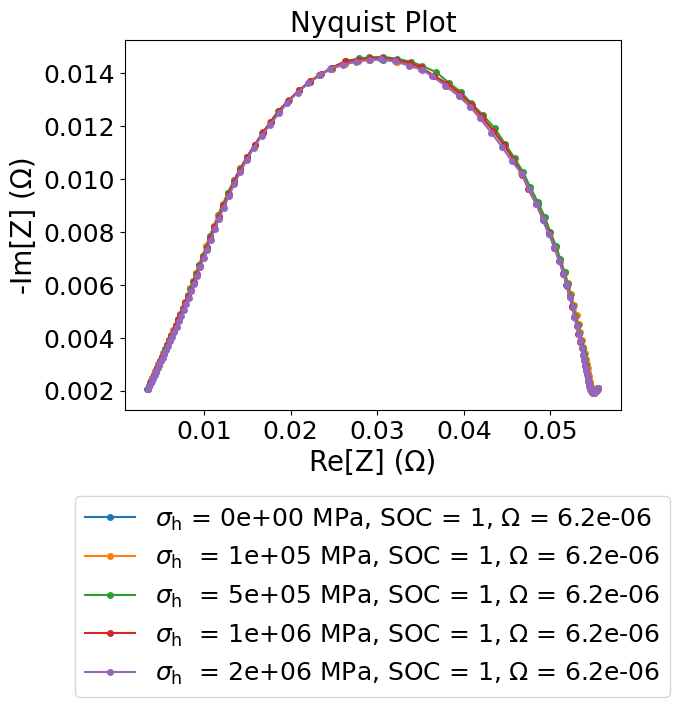

In [74]:
plt.plot(Z_0MPa_soc100_omg6_2[:, 1], -Z_0MPa_soc100_omg6_2[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param0['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param0['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

plt.plot(Z_01MPa_soc100_omg6_2[:, 1], -Z_01MPa_soc100_omg6_2[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
        label=fr"$\sigma_{{\mathrm{{h}}}}$  = {param01['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param01['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

plt.plot(Z_05MPa_soc100_omg6_2[:, 1], -Z_05MPa_soc100_omg6_2[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
        label=fr"$\sigma_{{\mathrm{{h}}}}$  = {param05['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param05['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

plt.plot(Z_1MPa_soc100_omg6_2[:, 1], -Z_1MPa_soc100_omg6_2[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
        label=fr"$\sigma_{{\mathrm{{h}}}}$  = {param1['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param1['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

plt.plot(Z_2MPa_soc100_omg6_2[:, 1], -Z_2MPa_soc100_omg6_2[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
        label=fr"$\sigma_{{\mathrm{{h}}}}$  = {param2['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param2['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')


plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

### $\Omega$ = 1e-5 $m^3/mol$

#### $\sigma_h$ = 0 Pa, SOC 1

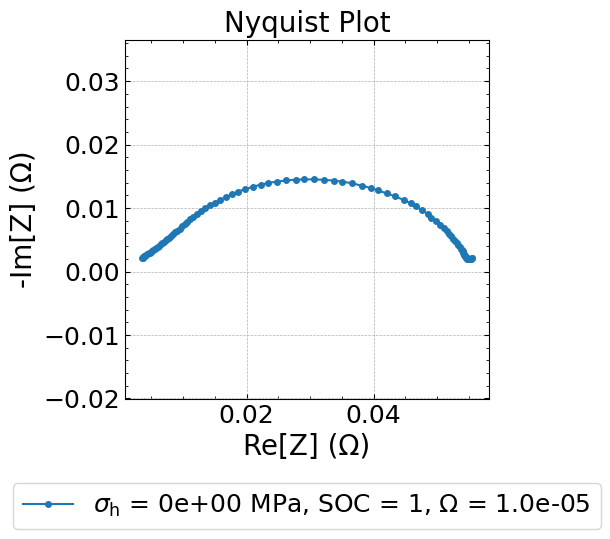

<Figure size 640x480 with 0 Axes>

In [75]:
hydrostatic_stress = 0
omega = 1e-5

I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_0MPa_soc100_omg1e5 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        )

    param0 = pybamm.ParameterValues("Ai2020") 
    param0.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param0.update(
    {"Negative electrode partial molar volume [m3.mol-1]": omega},
    check_already_exists=False
    )
    param0["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param0, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_0MPa_soc100_omg1e5.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_0MPa_soc100_omg1e5 = np.array(Z_0MPa_soc100_omg1e5)

# save to txt
np.savetxt("Z_0MPa_soc100_Omg1e5.txt", Z_0MPa_soc100_omg1e5)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_0MPa_soc100_omg1e5[:, 1], -Z_0MPa_soc100_omg1e5[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
         label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param0['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param0['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_0MPa_soc100_omg1e5[:, 1] + 1j * Z_0MPa_soc100_omg1e5[:, 2])  # Combine real and imag parts
phase = np.angle(Z_0MPa_soc100_omg1e5[:, 1] + 1j * Z_0MPa_soc100_omg1e5[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_0MPa_soc100_omg1e5[:, 0]  # Assuming first column is frequency

# Tidy layout
plt.tight_layout()
plt.show()

#### $\sigma_h$ = 1 MPa, SOC 1

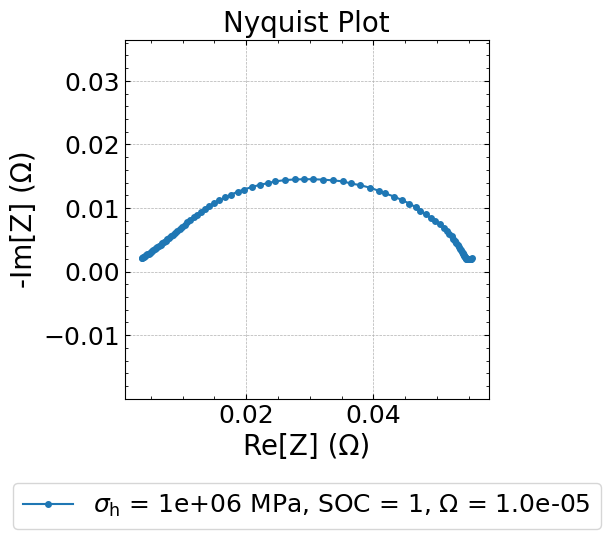

<Figure size 640x480 with 0 Axes>

In [76]:
hydrostic_stress = 1e6
omega = 1e-5

I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_1MPa_soc100_omg1e5 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        )

    param1 = pybamm.ParameterValues("Ai2020") 
    param1.update(
        {"Hydrostatic stress [Pa]": hydrostic_stress},
        check_already_exists=False  
    )
    param1.update(
    {"Negative electrode partial molar volume [m3.mol-1]": omega},
    check_already_exists=False
    )
    param1["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param1, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_1MPa_soc100_omg1e5.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_1MPa_soc100_omg1e5 = np.array(Z_1MPa_soc100_omg1e5)

# save to txt
np.savetxt("Z_1MPa_soc100_Omg1e5.txt", Z_1MPa_soc100_omg1e5)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_1MPa_soc100_omg1e5[:, 1], -Z_1MPa_soc100_omg1e5[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
         label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param1['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param1['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_1MPa_soc100_omg1e5[:, 1] + 1j * Z_1MPa_soc100_omg1e5[:, 2])  # Combine real and imag parts
phase = np.angle(Z_1MPa_soc100_omg1e5[:, 1] + 1j * Z_1MPa_soc100_omg1e5[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_1MPa_soc100_omg1e5[:, 0]  # Assuming first column is frequency

# Tidy layout
plt.tight_layout()
plt.show()

#### $\sigma_h$ = 0.5 MPa, SOC 1

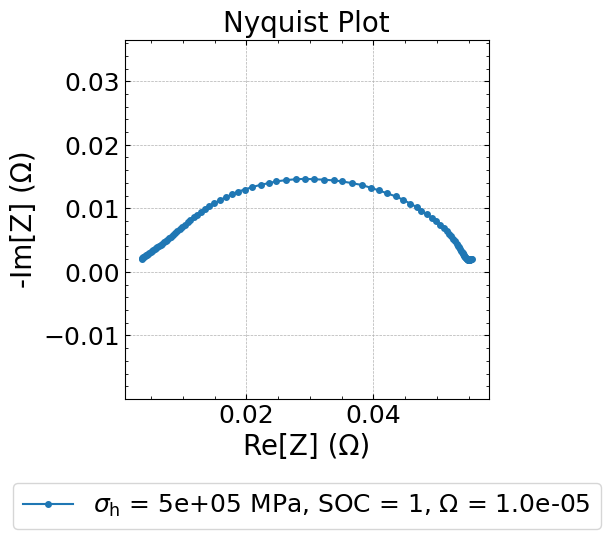

<Figure size 640x480 with 0 Axes>

In [77]:
hydrostatic_stress = 0.5e6
omega = 1e-5

I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_05MPa_soc100_omg1e5 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        )

    param05 = pybamm.ParameterValues("Ai2020") 
    param05.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param05.update(
    {"Negative electrode partial molar volume [m3.mol-1]": omega},
    check_already_exists=False
    )
    param05["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param05, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_05MPa_soc100_omg1e5.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_05MPa_soc100_omg1e5 = np.array(Z_05MPa_soc100_omg1e5)

# save to txt
np.savetxt("Z_05MPa_soc100_Omg1e5.txt", Z_05MPa_soc100_omg1e5)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_05MPa_soc100_omg1e5[:, 1], -Z_05MPa_soc100_omg1e5[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
         label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param05['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param05['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_05MPa_soc100_omg1e5[:, 1] + 1j * Z_05MPa_soc100_omg1e5[:, 2])  # Combine real and imag parts
phase = np.angle(Z_05MPa_soc100_omg1e5[:, 1] + 1j * Z_05MPa_soc100_omg1e5[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_05MPa_soc100_omg1e5[:, 0]  # Assuming first column is frequency

# Tidy layout
plt.tight_layout()
plt.show()

#### $\sigma_h$ = 0.1 MPa, SOC 1

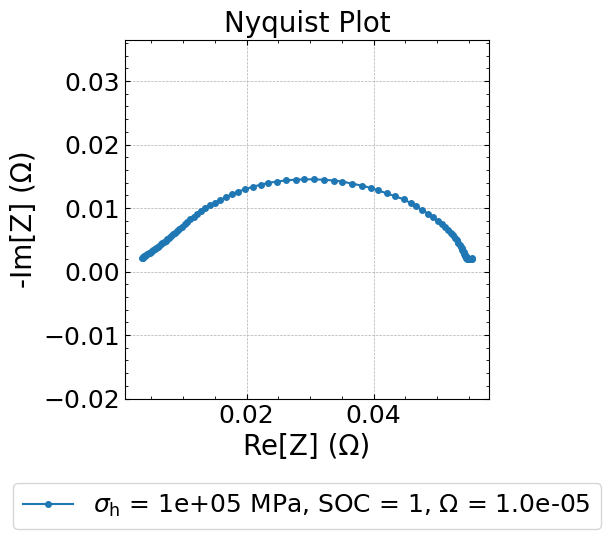

<Figure size 640x480 with 0 Axes>

In [78]:
hydrostatic_stress = 0.1e6
omega = 1e-5

I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_01MPa_soc100_omg1e5 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        )

    param01 = pybamm.ParameterValues("Ai2020") 
    param01.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param01.update(
    {"Negative electrode partial molar volume [m3.mol-1]": omega},
    check_already_exists=False
    )
    param01["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param01, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_01MPa_soc100_omg1e5.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_01MPa_soc100_omg1e5 = np.array(Z_01MPa_soc100_omg1e5)

# save to txt
np.savetxt("Z_01MPa_soc100_Omg1e5.txt", Z_01MPa_soc100_omg1e5)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_01MPa_soc100_omg1e5[:, 1], -Z_01MPa_soc100_omg1e5[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
         label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param01['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param01['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_01MPa_soc100_omg1e5[:, 1] + 1j * Z_01MPa_soc100_omg1e5[:, 2])  # Combine real and imag parts
phase = np.angle(Z_01MPa_soc100_omg1e5[:, 1] + 1j * Z_01MPa_soc100_omg1e5[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_01MPa_soc100_omgDef[:, 0]  # Assuming first column is frequency

# Tidy layout
plt.tight_layout()
plt.show()

#### $\sigma_h$ = 2 MPa, SOC 1

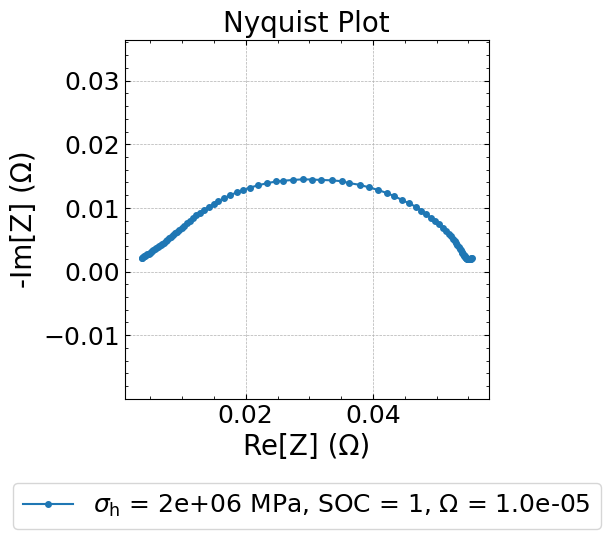

<Figure size 640x480 with 0 Axes>

In [79]:
hydrostatic_stress = 2e6
omega = 1e-5

I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_2MPa_soc100_omg1e5 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        )

    param2 = pybamm.ParameterValues("Ai2020") 
    param2.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param2.update(
    {"Negative electrode partial molar volume [m3.mol-1]": omega},
    check_already_exists=False
    )
    param2["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param2, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_2MPa_soc100_omg1e5.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_2MPa_soc100_omg1e5 = np.array(Z_2MPa_soc100_omg1e5)

# save to txt
np.savetxt("Z_2MPa_soc100_Omg1e5.txt", Z_2MPa_soc100_omg1e5)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_2MPa_soc100_omg1e5[:, 1], -Z_2MPa_soc100_omg1e5[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
         label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param2['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param2['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_2MPa_soc100_omg1e5[:, 1] + 1j * Z_2MPa_soc100_omg1e5[:, 2])  # Combine real and imag parts
phase = np.angle(Z_2MPa_soc100_omg1e5[:, 1] + 1j * Z_2MPa_soc100_omg1e5[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_2MPa_soc100_omg1e5[:, 0]  # Assuming first column is frequency

# Tidy layout
plt.tight_layout()
plt.show()

#### Primerjava

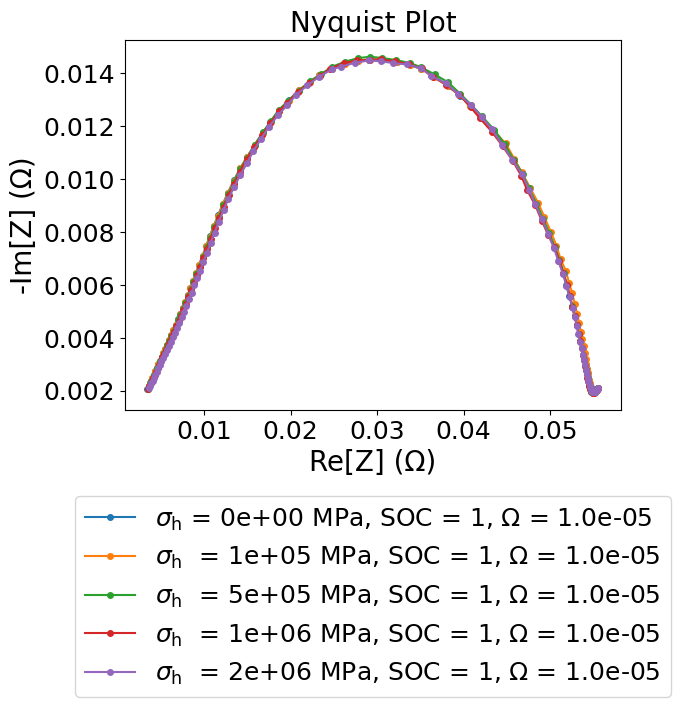

In [80]:
plt.plot(Z_0MPa_soc100_omg1e5[:, 1], -Z_0MPa_soc100_omg1e5[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param0['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param0['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

plt.plot(Z_01MPa_soc100_omg1e5[:, 1], -Z_01MPa_soc100_omg1e5[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
        label=fr"$\sigma_{{\mathrm{{h}}}}$  = {param01['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param01['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

plt.plot(Z_05MPa_soc100_omg1e5[:, 1], -Z_05MPa_soc100_omg1e5[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
        label=fr"$\sigma_{{\mathrm{{h}}}}$  = {param05['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param05['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

plt.plot(Z_1MPa_soc100_omg1e5[:, 1], -Z_1MPa_soc100_omg1e5[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
        label=fr"$\sigma_{{\mathrm{{h}}}}$  = {param1['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param1['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

plt.plot(Z_2MPa_soc100_omg1e5[:, 1], -Z_2MPa_soc100_omg1e5[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
        label=fr"$\sigma_{{\mathrm{{h}}}}$  = {param2['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param2['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')


plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

### $\Omega$ = 3.2e-5 $m^3/mol$

In [81]:
omega = 3.2e-5

#### $\sigma_h$ = 0 Pa, SOC 1

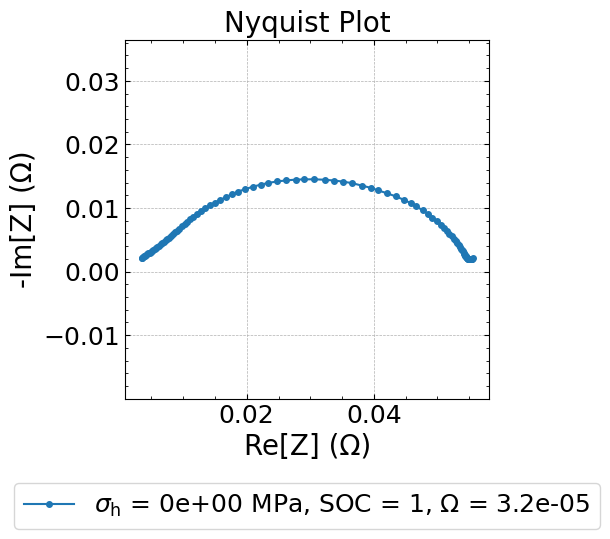

<Figure size 640x480 with 0 Axes>

In [84]:
hydrostatic_stress = 0

I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_0MPa_soc100_omg3_2e5 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        )

    param0 = pybamm.ParameterValues("Ai2020") 
    param0.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param0.update(
    {"Negative electrode partial molar volume [m3.mol-1]": omega},
    check_already_exists=False
    )
    param0["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param0, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_0MPa_soc100_omg3_2e5.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_0MPa_soc100_omg3_2e5 = np.array(Z_0MPa_soc100_omg3_2e5)

# save to txt
np.savetxt("Z_0MPa_soc100_omg3_2e5.txt", Z_0MPa_soc100_omg3_2e5)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_0MPa_soc100_omg3_2e5[:, 1], -Z_0MPa_soc100_omg3_2e5[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
         label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param0['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param0['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_0MPa_soc100_omg3_2e5[:, 1] + 1j * Z_0MPa_soc100_omg3_2e5[:, 2])  # Combine real and imag parts
phase = np.angle(Z_0MPa_soc100_omg3_2e5[:, 1] + 1j * Z_0MPa_soc100_omg3_2e5[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_0MPa_soc100_omg3_2e5[:, 0]  # Assuming first column is frequency

# Tidy layout
plt.tight_layout()
plt.show()

#### $\sigma_h$ = 1 MPa, SOC 1

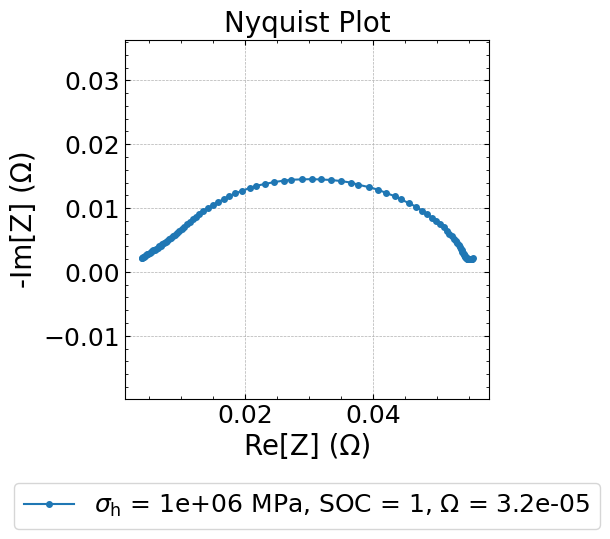

<Figure size 640x480 with 0 Axes>

In [85]:
hydrostic_stress = 1e6

I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_1MPa_soc100_omg3_2e5 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        )

    param1 = pybamm.ParameterValues("Ai2020") 
    param1.update(
        {"Hydrostatic stress [Pa]": hydrostic_stress},
        check_already_exists=False  
    )
    param1.update(
    {"Negative electrode partial molar volume [m3.mol-1]": omega},
    check_already_exists=False
    )
    param1["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param1, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_1MPa_soc100_omg3_2e5.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_1MPa_soc100_omg3_2e5 = np.array(Z_1MPa_soc100_omg3_2e5)

# save to txt
np.savetxt("Z_1MPa_soc100_Omg3_2e5.txt", Z_1MPa_soc100_omg3_2e5)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_1MPa_soc100_omg3_2e5[:, 1], -Z_1MPa_soc100_omg3_2e5[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
         label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param1['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param1['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_1MPa_soc100_omg3_2e5[:, 1] + 1j * Z_1MPa_soc100_omg3_2e5[:, 2])  # Combine real and imag parts
phase = np.angle(Z_1MPa_soc100_omg3_2e5[:, 1] + 1j * Z_1MPa_soc100_omg3_2e5[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_1MPa_soc100_omg3_2e5[:, 0]  # Assuming first column is frequency

# Tidy layout
plt.tight_layout()
plt.show()

#### $\sigma_h$ = 0.5 MPa, SOC 1

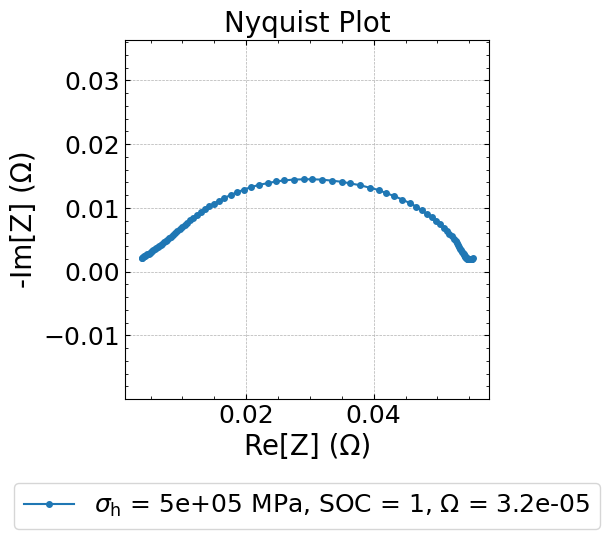

<Figure size 640x480 with 0 Axes>

In [86]:
hydrostatic_stress = 0.5e6

I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_05MPa_soc100_omg3_2e5 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        )

    param05 = pybamm.ParameterValues("Ai2020") 
    param05.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param05.update(
    {"Negative electrode partial molar volume [m3.mol-1]": omega},
    check_already_exists=False
    )
    param05["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param05, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_05MPa_soc100_omg3_2e5.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_05MPa_soc100_omg3_2e5 = np.array(Z_05MPa_soc100_omg3_2e5)

# save to txt
np.savetxt("Z_05MPa_soc100_Omg3_2e5.txt", Z_05MPa_soc100_omg3_2e5)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_05MPa_soc100_omg3_2e5[:, 1], -Z_05MPa_soc100_omg3_2e5[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
         label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param05['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param05['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_05MPa_soc100_omg3_2e5[:, 1] + 1j * Z_05MPa_soc100_omg3_2e5[:, 2])  # Combine real and imag parts
phase = np.angle(Z_05MPa_soc100_omg3_2e5[:, 1] + 1j * Z_05MPa_soc100_omg3_2e5[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_05MPa_soc100_omg3_2e5[:, 0]  # Assuming first column is frequency

# Tidy layout
plt.tight_layout()
plt.show()

#### $\sigma_h$ = 0.1 MPa, SOC 1

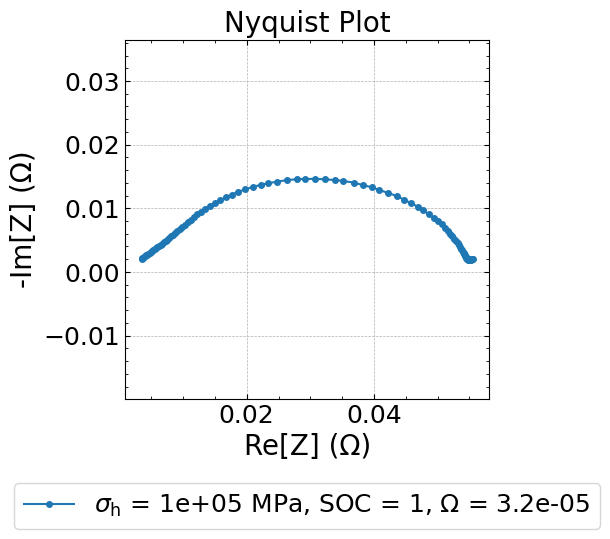

<Figure size 640x480 with 0 Axes>

In [87]:
hydrostatic_stress = 0.1e6

I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_01MPa_soc100_omg3_2e5 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        )

    param01 = pybamm.ParameterValues("Ai2020") 
    param01.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param01.update(
    {"Negative electrode partial molar volume [m3.mol-1]": omega},
    check_already_exists=False
    )
    param01["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param01, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_01MPa_soc100_omg3_2e5.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_01MPa_soc100_omg3_2e5 = np.array(Z_01MPa_soc100_omg3_2e5)

# save to txt
np.savetxt("Z_01MPa_soc100_Omg3_2e5.txt", Z_01MPa_soc100_omg3_2e5)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_01MPa_soc100_omg3_2e5[:, 1], -Z_01MPa_soc100_omg3_2e5[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
         label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param01['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param01['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_01MPa_soc100_omg3_2e5[:, 1] + 1j * Z_01MPa_soc100_omg3_2e5[:, 2])  # Combine real and imag parts
phase = np.angle(Z_01MPa_soc100_omg3_2e5[:, 1] + 1j * Z_01MPa_soc100_omg3_2e5[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_01MPa_soc100_omgDef[:, 0]  # Assuming first column is frequency

# Tidy layout
plt.tight_layout()
plt.show()

#### $\sigma_h$ = 2 MPa, SOC 1

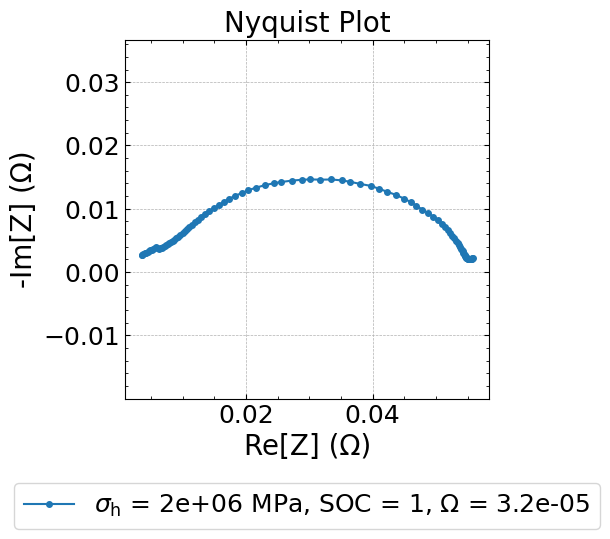

<Figure size 640x480 with 0 Axes>

In [88]:
hydrostatic_stress = 2e6

I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_2MPa_soc100_omg3_2e5 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        )

    param2 = pybamm.ParameterValues("Ai2020") 
    param2.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param2.update(
    {"Negative electrode partial molar volume [m3.mol-1]": omega},
    check_already_exists=False
    )
    param2["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param2, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_2MPa_soc100_omg3_2e5.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_2MPa_soc100_omg3_2e5 = np.array(Z_2MPa_soc100_omg3_2e5)

# save to txt
np.savetxt("Z_2MPa_soc100_Omg3_2e5.txt", Z_2MPa_soc100_omg3_2e5)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_2MPa_soc100_omg3_2e5[:, 1], -Z_2MPa_soc100_omg3_2e5[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
         label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param2['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param2['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_2MPa_soc100_omg3_2e5[:, 1] + 1j * Z_2MPa_soc100_omg3_2e5[:, 2])  # Combine real and imag parts
phase = np.angle(Z_2MPa_soc100_omg3_2e5[:, 1] + 1j * Z_2MPa_soc100_omg3_2e5[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_2MPa_soc100_omg3_2e5[:, 0]  # Assuming first column is frequency

# Tidy layout
plt.tight_layout()
plt.show()

#### Primerjava

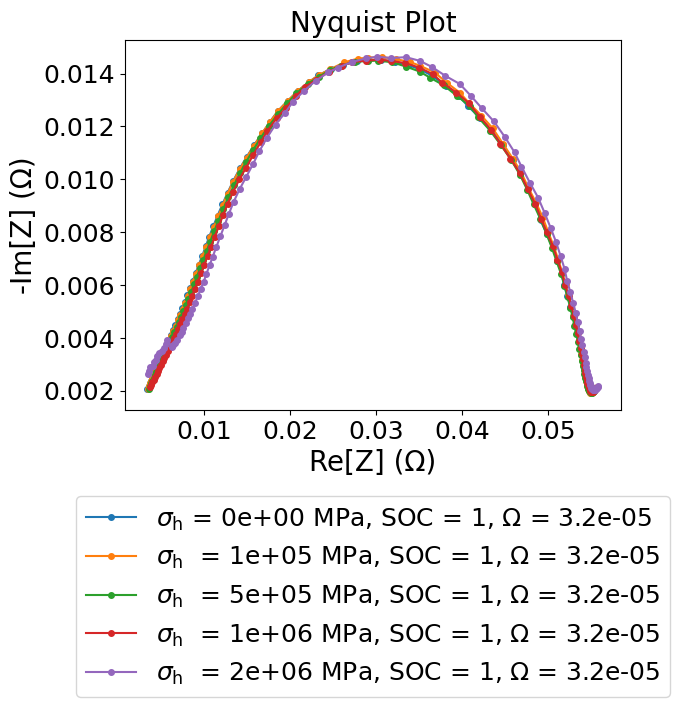

In [89]:
plt.plot(Z_0MPa_soc100_omg3_2e5[:, 1], -Z_0MPa_soc100_omg3_2e5[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param0['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param0['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

plt.plot(Z_01MPa_soc100_omg3_2e5[:, 1], -Z_01MPa_soc100_omg3_2e5[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
        label=fr"$\sigma_{{\mathrm{{h}}}}$  = {param01['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param01['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

plt.plot(Z_05MPa_soc100_omg3_2e5[:, 1], -Z_05MPa_soc100_omg3_2e5[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
        label=fr"$\sigma_{{\mathrm{{h}}}}$  = {param05['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param05['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

plt.plot(Z_1MPa_soc100_omg3_2e5[:, 1], -Z_1MPa_soc100_omg3_2e5[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
        label=fr"$\sigma_{{\mathrm{{h}}}}$  = {param1['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param1['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

plt.plot(Z_2MPa_soc100_omg3_2e5[:, 1], -Z_2MPa_soc100_omg3_2e5[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
        label=fr"$\sigma_{{\mathrm{{h}}}}$  = {param2['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param2['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')


plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

### $\Omega$ = 3.2e-4 $m^3/mol$

In [97]:
omega = 3.2e-4

#### $\sigma_h$ = 0 Pa, SOC 1

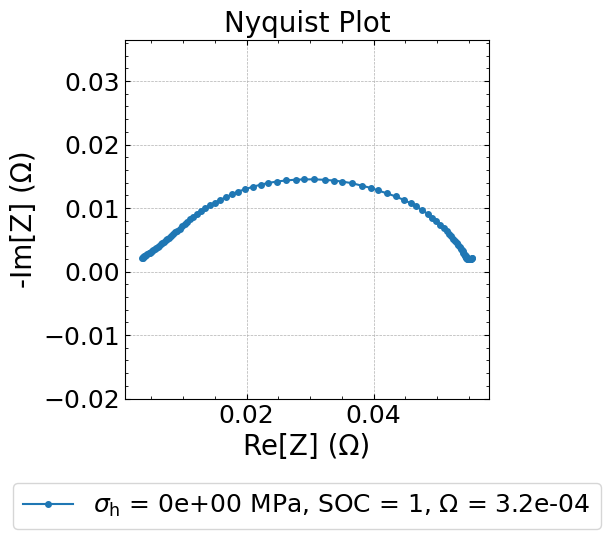

<Figure size 640x480 with 0 Axes>

In [98]:
hydrostatic_stress = 0

I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_0MPa_soc100_omg3_2e4 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        )

    param0 = pybamm.ParameterValues("Ai2020") 
    param0.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param0.update(
    {"Negative electrode partial molar volume [m3.mol-1]": omega},
    check_already_exists=False
    )
    param0["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param0, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_0MPa_soc100_omg3_2e4.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_0MPa_soc100_omg3_2e4 = np.array(Z_0MPa_soc100_omg3_2e4)

# save to txt
np.savetxt("Z_0MPa_soc100_omg3_2e4.txt", Z_0MPa_soc100_omg3_2e4)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_0MPa_soc100_omg3_2e4[:, 1], -Z_0MPa_soc100_omg3_2e4[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
         label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param0['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param0['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_0MPa_soc100_omg3_2e4[:, 1] + 1j * Z_0MPa_soc100_omg3_2e4[:, 2])  # Combine real and imag parts
phase = np.angle(Z_0MPa_soc100_omg3_2e4[:, 1] + 1j * Z_0MPa_soc100_omg3_2e4[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_0MPa_soc100_omg3_2e4[:, 0]  # Assuming first column is frequency

# Tidy layout
plt.tight_layout()
plt.show()

#### $\sigma_h$ = 1 MPa, SOC 1

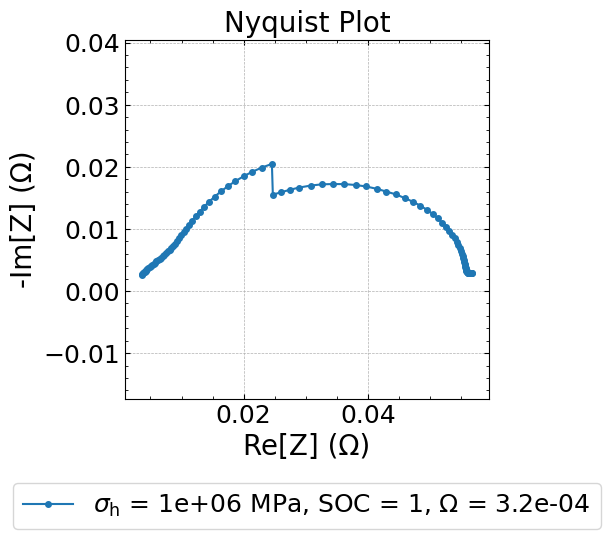

<Figure size 640x480 with 0 Axes>

In [99]:
hydrostic_stress = 1e6

I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_1MPa_soc100_omg3_2e4 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        )

    param1 = pybamm.ParameterValues("Ai2020") 
    param1.update(
        {"Hydrostatic stress [Pa]": hydrostic_stress},
        check_already_exists=False  
    )
    param1.update(
    {"Negative electrode partial molar volume [m3.mol-1]": omega},
    check_already_exists=False
    )
    param1["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param1, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_1MPa_soc100_omg3_2e4.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_1MPa_soc100_omg3_2e4 = np.array(Z_1MPa_soc100_omg3_2e4)

# save to txt
np.savetxt("Z_1MPa_soc100_Omg3_2e4.txt", Z_1MPa_soc100_omg3_2e4)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_1MPa_soc100_omg3_2e4[:, 1], -Z_1MPa_soc100_omg3_2e4[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
         label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param1['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param1['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_1MPa_soc100_omg3_2e4[:, 1] + 1j * Z_1MPa_soc100_omg3_2e4[:, 2])  # Combine real and imag parts
phase = np.angle(Z_1MPa_soc100_omg3_2e4[:, 1] + 1j * Z_1MPa_soc100_omg3_2e4[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_1MPa_soc100_omg3_2e4[:, 0]  # Assuming first column is frequency

# Tidy layout
plt.tight_layout()
plt.show()

#### $\sigma_h$ = 0.5 MPa, SOC 1

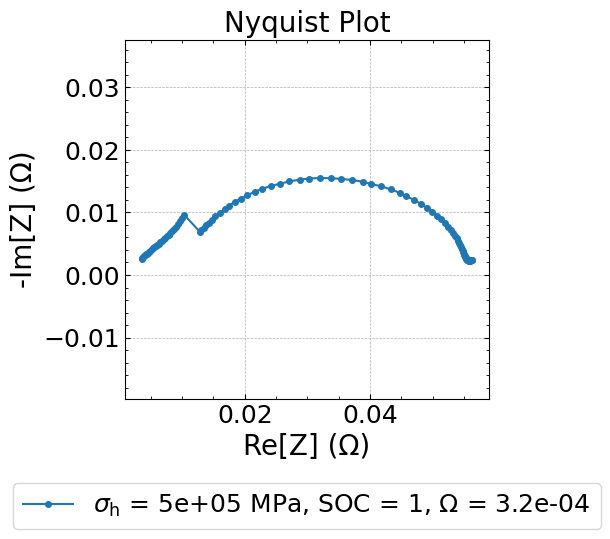

<Figure size 640x480 with 0 Axes>

In [100]:
hydrostatic_stress = 0.5e6

I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_05MPa_soc100_omg3_2e4 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        )

    param05 = pybamm.ParameterValues("Ai2020") 
    param05.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param05.update(
    {"Negative electrode partial molar volume [m3.mol-1]": omega},
    check_already_exists=False
    )
    param05["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param05, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_05MPa_soc100_omg3_2e4.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_05MPa_soc100_omg3_2e4 = np.array(Z_05MPa_soc100_omg3_2e4)

# save to txt
np.savetxt("Z_05MPa_soc100_Omg3_2e4.txt", Z_05MPa_soc100_omg3_2e4)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_05MPa_soc100_omg3_2e4[:, 1], -Z_05MPa_soc100_omg3_2e4[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
         label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param05['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param05['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_05MPa_soc100_omg3_2e4[:, 1] + 1j * Z_05MPa_soc100_omg3_2e4[:, 2])  # Combine real and imag parts
phase = np.angle(Z_05MPa_soc100_omg3_2e4[:, 1] + 1j * Z_05MPa_soc100_omg3_2e4[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_05MPa_soc100_omg3_2e4[:, 0]  # Assuming first column is frequency

# Tidy layout
plt.tight_layout()
plt.show()

#### $\sigma_h$ = 0.1 MPa, SOC 1

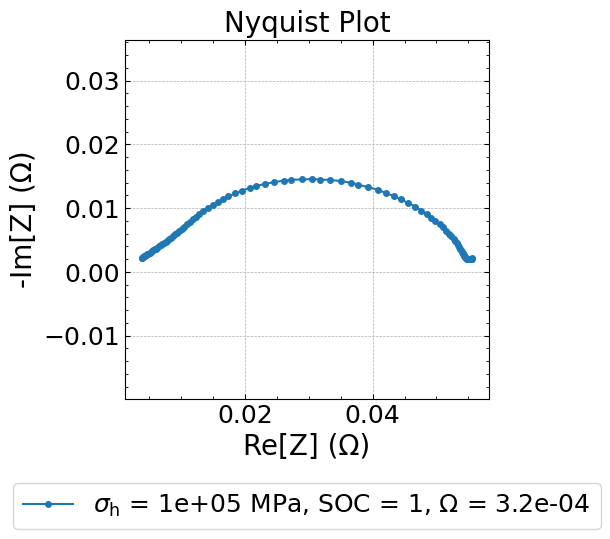

<Figure size 640x480 with 0 Axes>

In [101]:
hydrostatic_stress = 0.1e6

I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_01MPa_soc100_omg3_2e4 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        )

    param01 = pybamm.ParameterValues("Ai2020") 
    param01.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param01.update(
    {"Negative electrode partial molar volume [m3.mol-1]": omega},
    check_already_exists=False
    )
    param01["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param01, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_01MPa_soc100_omg3_2e4.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_01MPa_soc100_omg3_2e4 = np.array(Z_01MPa_soc100_omg3_2e4)

# save to txt
np.savetxt("Z_01MPa_soc100_Omg3_2e4.txt", Z_01MPa_soc100_omg3_2e4)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_01MPa_soc100_omg3_2e4[:, 1], -Z_01MPa_soc100_omg3_2e4[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
         label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param01['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param01['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_01MPa_soc100_omg3_2e4[:, 1] + 1j * Z_01MPa_soc100_omg3_2e4[:, 2])  # Combine real and imag parts
phase = np.angle(Z_01MPa_soc100_omg3_2e4[:, 1] + 1j * Z_01MPa_soc100_omg3_2e4[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_01MPa_soc100_omgDef[:, 0]  # Assuming first column is frequency

# Tidy layout
plt.tight_layout()
plt.show()

#### $\sigma_h$ = 2 MPa, SOC 1

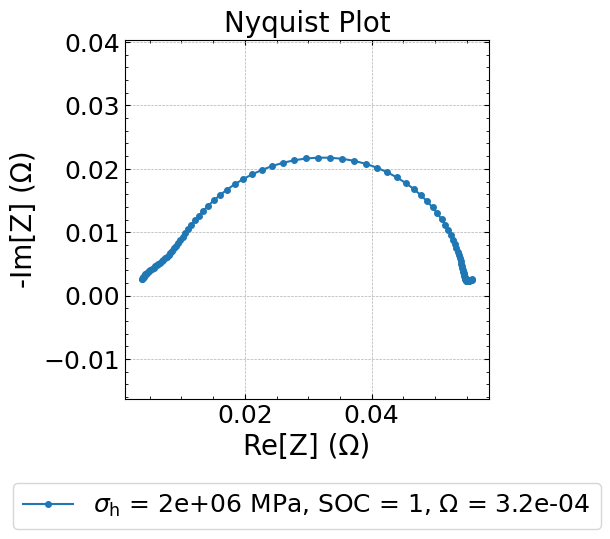

<Figure size 640x480 with 0 Axes>

In [102]:
hydrostatic_stress = 2e6

I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_2MPa_soc100_omg3_2e4 = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        )

    param2 = pybamm.ParameterValues("Ai2020") 
    param2.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param2.update(
    {"Negative electrode partial molar volume [m3.mol-1]": omega},
    check_already_exists=False
    )
    param2["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param2, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_2MPa_soc100_omg3_2e4.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_2MPa_soc100_omg3_2e4 = np.array(Z_2MPa_soc100_omg3_2e4)

# save to txt
np.savetxt("Z_2MPa_soc100_Omg3_2e4.txt", Z_2MPa_soc100_omg3_2e4)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#NARIŠEMO NIQUISTOV DIAGRAM
plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
plt.plot(Z_2MPa_soc100_omg3_2e4[:, 1], -Z_2MPa_soc100_omg3_2e4[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
         label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param2['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param2['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# Add grid for better readability
plt.grid(True, linestyle='--', linewidth=0.5)

# Equal aspect ratio for true representation of impedance
plt.axis('equal')

# Optional: add minor ticks
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

plt.tight_layout()
plt.show()


# Compute magnitude (absolute value) and phase (angle)
magnitude = np.abs(Z_2MPa_soc100_omg3_2e4[:, 1] + 1j * Z_2MPa_soc100_omg3_2e4[:, 2])  # Combine real and imag parts
phase = np.angle(Z_2MPa_soc100_omg3_2e4[:, 1] + 1j * Z_2MPa_soc100_omg3_2e4[:, 2], deg=True)  # Phase in degrees

# Frequency axis (log scale typical for Bode)
freq = Z_2MPa_soc100_omg3_2e4[:, 0]  # Assuming first column is frequency

# Tidy layout
plt.tight_layout()
plt.show()

#### Primerjava

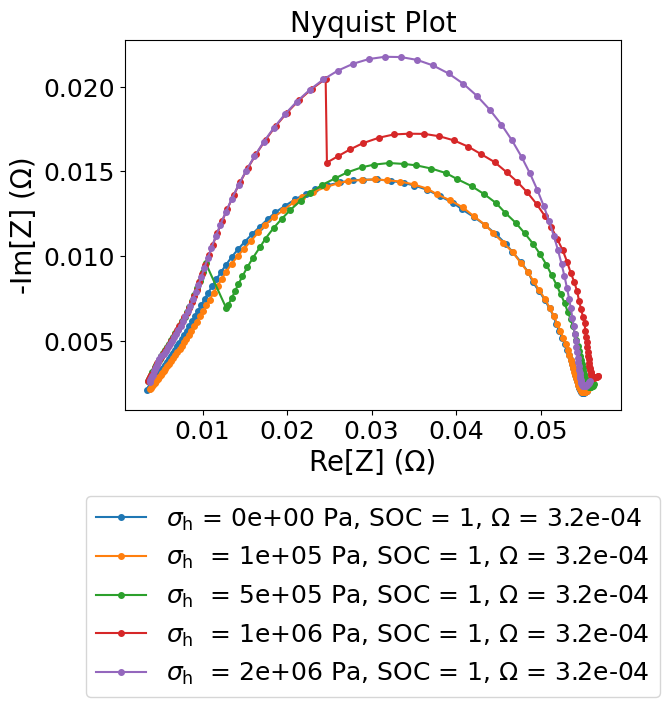

In [103]:
plt.plot(Z_0MPa_soc100_omg3_2e4[:, 1], -Z_0MPa_soc100_omg3_2e4[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param0['Hydrostatic stress [Pa]']:.0e} Pa, SOC = 1, $\Omega$ = {param0['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

plt.plot(Z_01MPa_soc100_omg3_2e4[:, 1], -Z_01MPa_soc100_omg3_2e4[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
        label=fr"$\sigma_{{\mathrm{{h}}}}$  = {param01['Hydrostatic stress [Pa]']:.0e} Pa, SOC = 1, $\Omega$ = {param01['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

plt.plot(Z_05MPa_soc100_omg3_2e4[:, 1], -Z_05MPa_soc100_omg3_2e4[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
        label=fr"$\sigma_{{\mathrm{{h}}}}$  = {param05['Hydrostatic stress [Pa]']:.0e} Pa, SOC = 1, $\Omega$ = {param05['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

plt.plot(Z_1MPa_soc100_omg3_2e4[:, 1], -Z_1MPa_soc100_omg3_2e4[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
        label=fr"$\sigma_{{\mathrm{{h}}}}$  = {param1['Hydrostatic stress [Pa]']:.0e} Pa, SOC = 1, $\Omega$ = {param1['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

plt.plot(Z_2MPa_soc100_omg3_2e4[:, 1], -Z_2MPa_soc100_omg3_2e4[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
        label=fr"$\sigma_{{\mathrm{{h}}}}$  = {param2['Hydrostatic stress [Pa]']:.0e} Pa, SOC = 1, $\Omega$ = {param2['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')


plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# Večji spekter frekvenc

### $\Omega$ = 3.1e-6 $m^3/mol$ (default)

#### $\sigma_h$ = 0 Pa, SOC 1

In [ ]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.001
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_0MPa_soc100_omgDef_vecF = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        )

    param0 = pybamm.ParameterValues("Ai2020") 
    param0.update(
        {"Hydrostatic stress [Pa]": 0},
        check_already_exists=False  
    )
    param0["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param0, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_0MPa_soc100_omgDef_vecF.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_0MPa_soc100_omgDef_vecF = np.array(Z_0MPa_soc100_omgDef_vecF)

# save to txt
np.savetxt("Z_0MPa_soc100_OmgDef_vecF.txt", Z_0MPa_soc100_omgDef_vecF)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

# #NARIŠEMO NIQUISTOV DIAGRAM
# plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
# plt.plot(Z_0MPa_soc100_omgDef_vecF[:, 1], -Z_0MPa_soc100_omgDef_vecF[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
#          label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param0['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param0['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# # Labels and title
# plt.xlabel('Re[Z] (Ω)')
# plt.ylabel('-Im[Z] (Ω)')
# plt.title('Nyquist Plot')
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# # Add grid for better readability
# plt.grid(True, linestyle='--', linewidth=0.5)

# # Equal aspect ratio for true representation of impedance
# plt.axis('equal')

# # Optional: add minor ticks
# plt.minorticks_on()
# plt.tick_params(which='both', direction='in', top=True, right=True)

# plt.tight_layout()
# plt.show()


# # Compute magnitude (absolute value) and phase (angle)
# magnitude = np.abs(Z_0MPa_soc100_omgDef_vecF[:, 1] + 1j * Z_0MPa_soc100_omgDef_vecF[:, 2])  # Combine real and imag parts
# phase = np.angle(Z_0MPa_soc100_omgDef_vecF[:, 1] + 1j * Z_0MPa_soc100_omgDef_vecF[:, 2], deg=True)  # Phase in degrees

# # Frequency axis (log scale typical for Bode)
# freq = Z_0MPa_soc100_omgDef_vecF[:, 0]  # Assuming first column is frequency

# # Tidy layout
# plt.tight_layout()
# plt.show()

#### $\sigma_h$ = 1 MPa, SOC 1

In [ ]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.001
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_1MPa_soc100_omgDef_vecF = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        )

    param1 = pybamm.ParameterValues("Ai2020") 
    param1.update(
        {"Hydrostatic stress [Pa]": 1e6},
        check_already_exists=False  
    )
    param1["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param1, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_1MPa_soc100_omgDef_vecF.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_1MPa_soc100_omgDef_vecF = np.array(Z_1MPa_soc100_omgDef_vecF)

# save to txt
np.savetxt("Z_1MPa_soc100_OmgDef_vecF.txt", Z_1MPa_soc100_omgDef_vecF)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

# #NARIŠEMO NIQUISTOV DIAGRAM
# plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
# plt.plot(Z_1MPa_soc100_omgDef_vecF[:, 1], -Z_1MPa_soc100_omgDef_vecF[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
#          label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param1['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param1['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# # Labels and title
# plt.xlabel('Re[Z] (Ω)')
# plt.ylabel('-Im[Z] (Ω)')
# plt.title('Nyquist Plot')
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# # Add grid for better readability
# plt.grid(True, linestyle='--', linewidth=0.5)

# # Equal aspect ratio for true representation of impedance
# plt.axis('equal')

# # Optional: add minor ticks
# plt.minorticks_on()
# plt.tick_params(which='both', direction='in', top=True, right=True)

# plt.tight_layout()
# plt.show()


# # Compute magnitude (absolute value) and phase (angle)
# magnitude = np.abs(Z_1MPa_soc100_omgDef_vecF[:, 1] + 1j * Z_1MPa_soc100_omgDef_vecF[:, 2])  # Combine real and imag parts
# phase = np.angle(Z_1MPa_soc100_omgDef_vecF[:, 1] + 1j * Z_1MPa_soc100_omgDef_vecF[:, 2], deg=True)  # Phase in degrees

# # Frequency axis (log scale typical for Bode)
# freq = Z_1MPa_soc100_omgDef_vecF[:, 0]  # Assuming first column is frequency

# # Tidy layout
# plt.tight_layout()
# plt.show()

#### $\sigma_h$ = 0.5 MPa, SOC 1

In [ ]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.001
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_05MPa_soc100_omgDef_vecF = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        )

    param05 = pybamm.ParameterValues("Ai2020") 
    param05.update(
        {"Hydrostatic stress [Pa]": 0.5e6},
        check_already_exists=False  
    )
    param05["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param05, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_05MPa_soc100_omgDef_vecF.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_05MPa_soc100_omgDef_vecF = np.array(Z_05MPa_soc100_omgDef_vecF)

# save to txt
np.savetxt("Z_05MPa_soc100_OmgDef_vecF.txt", Z_05MPa_soc100_omgDef_vecF)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

# #NARIŠEMO NIQUISTOV DIAGRAM
# plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
# plt.plot(Z_05MPa_soc100_omgDef_vecF[:, 1], -Z_05MPa_soc100_omgDef_vecF[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
#          label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param05['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param05['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# # Labels and title
# plt.xlabel('Re[Z] (Ω)')
# plt.ylabel('-Im[Z] (Ω)')
# plt.title('Nyquist Plot')
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# # Add grid for better readability
# plt.grid(True, linestyle='--', linewidth=0.5)

# # Equal aspect ratio for true representation of impedance
# plt.axis('equal')

# # Optional: add minor ticks
# plt.minorticks_on()
# plt.tick_params(which='both', direction='in', top=True, right=True)

# plt.tight_layout()
# plt.show()


# # Compute magnitude (absolute value) and phase (angle)
# magnitude = np.abs(Z_05MPa_soc100_omgDef_vecF[:, 1] + 1j * Z_05MPa_soc100_omgDef_vecF[:, 2])  # Combine real and imag parts
# phase = np.angle(Z_05MPa_soc100_omgDef_vecF[:, 1] + 1j * Z_05MPa_soc100_omgDef_vecF[:, 2], deg=True)  # Phase in degrees

# # Frequency axis (log scale typical for Bode)
# freq = Z_05MPa_soc100_omgDef_vecF[:, 0]  # Assuming first column is frequency

# # Tidy layout
# plt.tight_layout()
# plt.show()

#### $\sigma_h$ = 0.1 MPa, SOC 1

In [ ]:
hydrostatic_stress = 0.1e6

I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.001
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_01MPa_soc100_omgDef_vecF = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        )

    param01 = pybamm.ParameterValues("Ai2020") 
    param01.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param01["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param01, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_01MPa_soc100_omgDef_vecF.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_01MPa_soc100_omgDef_vecF = np.array(Z_01MPa_soc100_omgDef_vecF)

# save to txt
np.savetxt("Z_01MPa_soc100_OmgDef_vecF.txt", Z_01MPa_soc100_omgDef_vecF)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

# #NARIŠEMO NIQUISTOV DIAGRAM
# plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
# plt.plot(Z_01MPa_soc100_omgDef_vecF[:, 1], -Z_01MPa_soc100_omgDef_vecF[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
#          label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param01['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param01['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# # Labels and title
# plt.xlabel('Re[Z] (Ω)')
# plt.ylabel('-Im[Z] (Ω)')
# plt.title('Nyquist Plot')
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# # Add grid for better readability
# plt.grid(True, linestyle='--', linewidth=0.5)

# # Equal aspect ratio for true representation of impedance
# plt.axis('equal')

# # Optional: add minor ticks
# plt.minorticks_on()
# plt.tick_params(which='both', direction='in', top=True, right=True)

# plt.tight_layout()
# plt.show()


# # Compute magnitude (absolute value) and phase (angle)
# magnitude = np.abs(Z_01MPa_soc100_omgDef_vecF[:, 1] + 1j * Z_01MPa_soc100_omgDef_vecF[:, 2])  # Combine real and imag parts
# phase = np.angle(Z_01MPa_soc100_omgDef_vecF[:, 1] + 1j * Z_01MPa_soc100_omgDef_vecF[:, 2], deg=True)  # Phase in degrees

# # Frequency axis (log scale typical for Bode)
# freq = Z_01MPa_soc100_omgDef_vecF[:, 0]  # Assuming first column is frequency

# # Tidy layout
# plt.tight_layout()
# plt.show()

#### $\sigma_h$ = 2 MPa, SOC 1

In [ ]:
hydrostatic_stress = 2e6

I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.001
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_2MPa_soc100_omgDef_vecF = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        )

    param2 = pybamm.ParameterValues("Ai2020") 
    param2.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param2["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param2, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_2MPa_soc100_omgDef_vecF.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_2MPa_soc100_omgDef_vecF = np.array(Z_2MPa_soc100_omgDef_vecF)

# save to txt
np.savetxt("Z_2MPa_soc100_OmgDef_vecF.txt", Z_2MPa_soc100_omgDef_vecF)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

# #NARIŠEMO NIQUISTOV DIAGRAM
# plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
# plt.plot(Z_2MPa_soc100_omgDef_vecF[:, 1], -Z_2MPa_soc100_omgDef_vecF[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
#          label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param2['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param2['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# # Labels and title
# plt.xlabel('Re[Z] (Ω)')
# plt.ylabel('-Im[Z] (Ω)')
# plt.title('Nyquist Plot')
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# # Add grid for better readability
# plt.grid(True, linestyle='--', linewidth=0.5)

# # Equal aspect ratio for true representation of impedance
# plt.axis('equal')

# # Optional: add minor ticks
# plt.minorticks_on()
# plt.tick_params(which='both', direction='in', top=True, right=True)

# plt.tight_layout()
# plt.show()


# # Compute magnitude (absolute value) and phase (angle)
# magnitude = np.abs(Z_2MPa_soc100_omgDef_vecF[:, 1] + 1j * Z_2MPa_soc100_omgDef_vecF[:, 2])  # Combine real and imag parts
# phase = np.angle(Z_2MPa_soc100_omgDef_vecF[:, 1] + 1j * Z_2MPa_soc100_omgDef_vecF[:, 2], deg=True)  # Phase in degrees

# # Frequency axis (log scale typical for Bode)
# freq = Z_2MPa_soc100_omgDef_vecF[:, 0]  # Assuming first column is frequency

# # Tidy layout
# plt.tight_layout()
# plt.show()

#### Primerjava

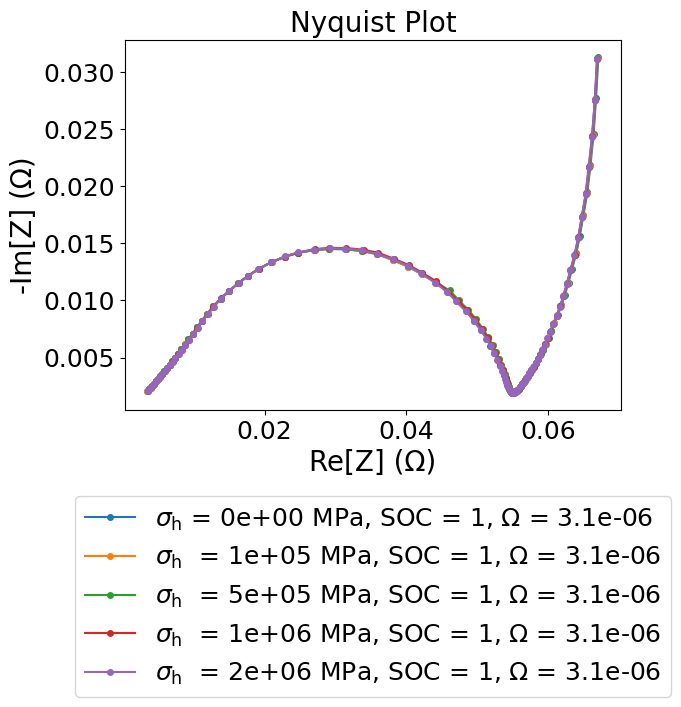

In [16]:
plt.plot(Z_0MPa_soc100_omgDef[:, 1], -Z_0MPa_soc100_omgDef[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param0['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param0['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

plt.plot(Z_01MPa_soc100_omgDef[:, 1], -Z_01MPa_soc100_omgDef[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
        label=fr"$\sigma_{{\mathrm{{h}}}}$  = {param01['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param01['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

plt.plot(Z_05MPa_soc100_omgDef[:, 1], -Z_05MPa_soc100_omgDef[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
        label=fr"$\sigma_{{\mathrm{{h}}}}$  = {param05['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param05['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

plt.plot(Z_1MPa_soc100_omgDef[:, 1], -Z_1MPa_soc100_omgDef[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
        label=fr"$\sigma_{{\mathrm{{h}}}}$  = {param1['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param1['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

plt.plot(Z_2MPa_soc100_omgDef[:, 1], -Z_2MPa_soc100_omgDef[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
        label=fr"$\sigma_{{\mathrm{{h}}}}$  = {param2['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param2['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')


plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# Vključimo SEI

V člankih je velikokrat navedeno, da se impedanca poveča zaradi kompresije SEI.

### $\Omega$ = 3.1e-6 $m^3/mol$ (default)

#### $\sigma_h$ = 0 Pa, SOC 1

In [17]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_0MPa_soc100_SEI = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                "particle mechanics": "swelling only",
                                                "SEI": "solvent-diffusion limited",
                                                "SEI porosity change": "true",},
                                        )

    param0 = pybamm.ParameterValues("Ai2020") 
    param0.update(
        {"Hydrostatic stress [Pa]": 0},
        check_already_exists=False  
    )
    param0["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param0, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_0MPa_soc100_SEI.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_0MPa_soc100_SEI = np.array(Z_0MPa_soc100_SEI)

# save to txt
np.savetxt("Z_0MPa_soc100_SEI.txt", Z_0MPa_soc100_SEI)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

# #NARIŠEMO NIQUISTOV DIAGRAM
# plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
# plt.plot(Z_0MPa_soc100_SEI[:, 1], -Z_0MPa_soc100_SEI[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
#          label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param0['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param0['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# # Labels and title
# plt.xlabel('Re[Z] (Ω)')
# plt.ylabel('-Im[Z] (Ω)')
# plt.title('Nyquist Plot')
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# # Add grid for better readability
# plt.grid(True, linestyle='--', linewidth=0.5)

# # Equal aspect ratio for true representation of impedance
# plt.axis('equal')

# # Optional: add minor ticks
# plt.minorticks_on()
# plt.tick_params(which='both', direction='in', top=True, right=True)

# plt.tight_layout()
# plt.show()


# # Compute magnitude (absolute value) and phase (angle)
# magnitude = np.abs(Z_0MPa_soc100_SEI[:, 1] + 1j * Z_0MPa_soc100_SEI[:, 2])  # Combine real and imag parts
# phase = np.angle(Z_0MPa_soc100_SEI[:, 1] + 1j * Z_0MPa_soc100_SEI[:, 2], deg=True)  # Phase in degrees

# # Frequency axis (log scale typical for Bode)
# freq = Z_0MPa_soc100_SEI[:, 0]  # Assuming first column is frequency

# # Tidy layout
# plt.tight_layout()
# plt.show()

#### $\sigma_h$ = 1 MPa, SOC 1

In [26]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_1MPa_soc100_SEI = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                "particle mechanics": "swelling only",
                                                "SEI": "solvent-diffusion limited",
                                                "SEI porosity change": "true",},
                                        )

    param1 = pybamm.ParameterValues("Ai2020") 
    param1.update(
        {"Hydrostatic stress [Pa]": 1e6},
        check_already_exists=False  
    )
    param1["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param1, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_1MPa_soc100_SEI.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_1MPa_soc100_SEI = np.array(Z_1MPa_soc100_SEI)

# save to txt
np.savetxt("Z_1MPa_soc100_SEI.txt", Z_1MPa_soc100_SEI)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

# #NARIŠEMO NIQUISTOV DIAGRAM
# plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
# plt.plot(Z_1MPa_soc100_SEI[:, 1], -Z_1MPa_soc100_SEI[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
#          label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param1['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param1['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# # Labels and title
# plt.xlabel('Re[Z] (Ω)')
# plt.ylabel('-Im[Z] (Ω)')
# plt.title('Nyquist Plot')
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# # Add grid for better readability
# plt.grid(True, linestyle='--', linewidth=0.5)

# # Equal aspect ratio for true representation of impedance
# plt.axis('equal')

# # Optional: add minor ticks
# plt.minorticks_on()
# plt.tick_params(which='both', direction='in', top=True, right=True)

# plt.tight_layout()
# plt.show()


# # Compute magnitude (absolute value) and phase (angle)
# magnitude = np.abs(Z_1MPa_soc100_SEI[:, 1] + 1j * Z_1MPa_soc100_SEI[:, 2])  # Combine real and imag parts
# phase = np.angle(Z_1MPa_soc100_SEI[:, 1] + 1j * Z_1MPa_soc100_SEI[:, 2], deg=True)  # Phase in degrees

# # Frequency axis (log scale typical for Bode)
# freq = Z_1MPa_soc100_SEI[:, 0]  # Assuming first column is frequency

# # Tidy layout
# plt.tight_layout()
# plt.show()

#### $\sigma_h$ = 0.5 MPa, SOC 1

In [ ]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.001
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_05MPa_soc100_omgDef = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        )

    param05 = pybamm.ParameterValues("Ai2020") 
    param05.update(
        {"Hydrostatic stress [Pa]": 0.5e6},
        check_already_exists=False  
    )
    param05["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param05, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_05MPa_soc100_omgDef.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_05MPa_soc100_omgDef = np.array(Z_05MPa_soc100_omgDef)

# save to txt
np.savetxt("Z_05MPa_soc100_OmgDef_vecF.txt", Z_05MPa_soc100_omgDef)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

# #NARIŠEMO NIQUISTOV DIAGRAM
# plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
# plt.plot(Z_05MPa_soc100_omgDef[:, 1], -Z_05MPa_soc100_omgDef[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
#          label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param05['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param05['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# # Labels and title
# plt.xlabel('Re[Z] (Ω)')
# plt.ylabel('-Im[Z] (Ω)')
# plt.title('Nyquist Plot')
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# # Add grid for better readability
# plt.grid(True, linestyle='--', linewidth=0.5)

# # Equal aspect ratio for true representation of impedance
# plt.axis('equal')

# # Optional: add minor ticks
# plt.minorticks_on()
# plt.tick_params(which='both', direction='in', top=True, right=True)

# plt.tight_layout()
# plt.show()


# # Compute magnitude (absolute value) and phase (angle)
# magnitude = np.abs(Z_05MPa_soc100_omgDef[:, 1] + 1j * Z_05MPa_soc100_omgDef[:, 2])  # Combine real and imag parts
# phase = np.angle(Z_05MPa_soc100_omgDef[:, 1] + 1j * Z_05MPa_soc100_omgDef[:, 2], deg=True)  # Phase in degrees

# # Frequency axis (log scale typical for Bode)
# freq = Z_05MPa_soc100_omgDef[:, 0]  # Assuming first column is frequency

# # Tidy layout
# plt.tight_layout()
# plt.show()

#### $\sigma_h$ = 0.1 MPa, SOC 1

In [ ]:
hydrostatic_stress = 0.1e6

I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.001
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_01MPa_soc100_omgDef = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling only",},
                                        )

    param01 = pybamm.ParameterValues("Ai2020") 
    param01.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param01["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param01, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_01MPa_soc100_omgDef.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_01MPa_soc100_omgDef = np.array(Z_01MPa_soc100_omgDef)

# save to txt
np.savetxt("Z_01MPa_soc100_OmgDef_vecF.txt", Z_01MPa_soc100_omgDef)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

# #NARIŠEMO NIQUISTOV DIAGRAM
# plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
# plt.plot(Z_01MPa_soc100_omgDef[:, 1], -Z_01MPa_soc100_omgDef[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
#          label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param01['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param01['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# # Labels and title
# plt.xlabel('Re[Z] (Ω)')
# plt.ylabel('-Im[Z] (Ω)')
# plt.title('Nyquist Plot')
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# # Add grid for better readability
# plt.grid(True, linestyle='--', linewidth=0.5)

# # Equal aspect ratio for true representation of impedance
# plt.axis('equal')

# # Optional: add minor ticks
# plt.minorticks_on()
# plt.tick_params(which='both', direction='in', top=True, right=True)

# plt.tight_layout()
# plt.show()


# # Compute magnitude (absolute value) and phase (angle)
# magnitude = np.abs(Z_01MPa_soc100_omgDef[:, 1] + 1j * Z_01MPa_soc100_omgDef[:, 2])  # Combine real and imag parts
# phase = np.angle(Z_01MPa_soc100_omgDef[:, 1] + 1j * Z_01MPa_soc100_omgDef[:, 2], deg=True)  # Phase in degrees

# # Frequency axis (log scale typical for Bode)
# freq = Z_01MPa_soc100_omgDef[:, 0]  # Assuming first column is frequency

# # Tidy layout
# plt.tight_layout()
# plt.show()

#### $\sigma_h$ = 2 MPa, SOC 1

In [27]:
hydrostatic_stress = 2e6

I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_2MPa_soc100_SEI = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                "particle mechanics": "swelling only",
                                                "SEI": "solvent-diffusion limited",
                                                "SEI porosity change": "true",},
                                        )

    param2 = pybamm.ParameterValues("Ai2020") 
    param2.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param2["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param2, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_2MPa_soc100_SEI.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_2MPa_soc100_SEI = np.array(Z_2MPa_soc100_SEI)

# save to txt
np.savetxt("Z_2MPa_soc100_SEI.txt", Z_2MPa_soc100_SEI)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

# #NARIŠEMO NIQUISTOV DIAGRAM
# plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
# plt.plot(Z_2MPa_soc100_SEI[:, 1], -Z_2MPa_soc100_SEI[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
#          label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param2['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param2['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# # Labels and title
# plt.xlabel('Re[Z] (Ω)')
# plt.ylabel('-Im[Z] (Ω)')
# plt.title('Nyquist Plot')
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# # Add grid for better readability
# plt.grid(True, linestyle='--', linewidth=0.5)

# # Equal aspect ratio for true representation of impedance
# plt.axis('equal')

# # Optional: add minor ticks
# plt.minorticks_on()
# plt.tick_params(which='both', direction='in', top=True, right=True)

# plt.tight_layout()
# plt.show()


# # Compute magnitude (absolute value) and phase (angle)
# magnitude = np.abs(Z_2MPa_soc100_SEI[:, 1] + 1j * Z_2MPa_soc100_SEI[:, 2])  # Combine real and imag parts
# phase = np.angle(Z_2MPa_soc100_SEI[:, 1] + 1j * Z_2MPa_soc100_SEI[:, 2], deg=True)  # Phase in degrees

# # Frequency axis (log scale typical for Bode)
# freq = Z_2MPa_soc100_SEI[:, 0]  # Assuming first column is frequency

# # Tidy layout
# plt.tight_layout()
# plt.show()

#### Primerjava

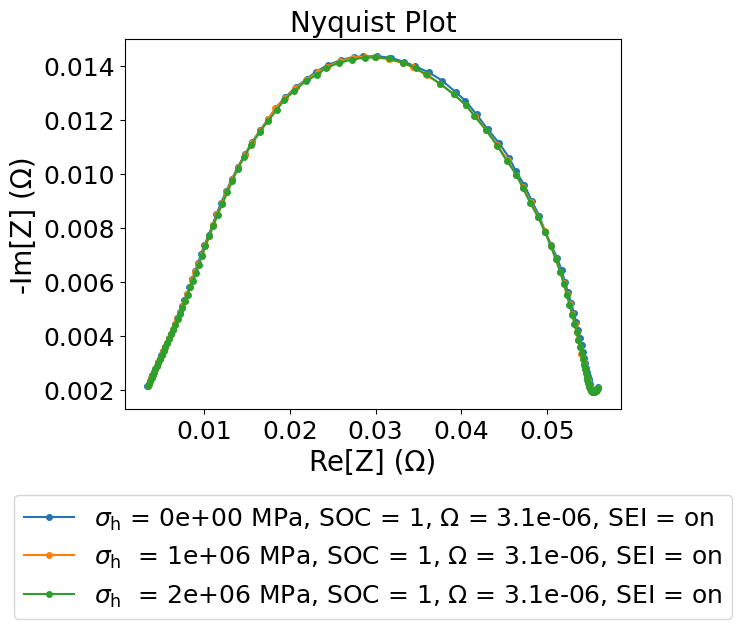

In [31]:
plt.plot(Z_0MPa_soc100_SEI[:, 1], -Z_0MPa_soc100_SEI[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param0['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param0['Negative electrode partial molar volume [m3.mol-1]']:.1e}, SEI = on")

# plt.plot(Z_01MPa_soc100_SEI[:, 1], -Z_01MPa_soc100_SEI[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
#         label=fr"$\sigma_{{\mathrm{{h}}}}$  = {param01['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param01['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# plt.plot(Z_05MPa_soc100_SEI[:, 1], -Z_05MPa_soc100_SEI[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
#         label=fr"$\sigma_{{\mathrm{{h}}}}$  = {param05['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param05['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

plt.plot(Z_1MPa_soc100_SEI[:, 1], -Z_1MPa_soc100_SEI[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
        label=fr"$\sigma_{{\mathrm{{h}}}}$  = {param1['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param1['Negative electrode partial molar volume [m3.mol-1]']:.1e}, SEI = on")

plt.plot(Z_2MPa_soc100_SEI[:, 1], -Z_2MPa_soc100_SEI[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
        label=fr"$\sigma_{{\mathrm{{h}}}}$  = {param2['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param2['Negative electrode partial molar volume [m3.mol-1]']:.1e}, SEI = on")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')


plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

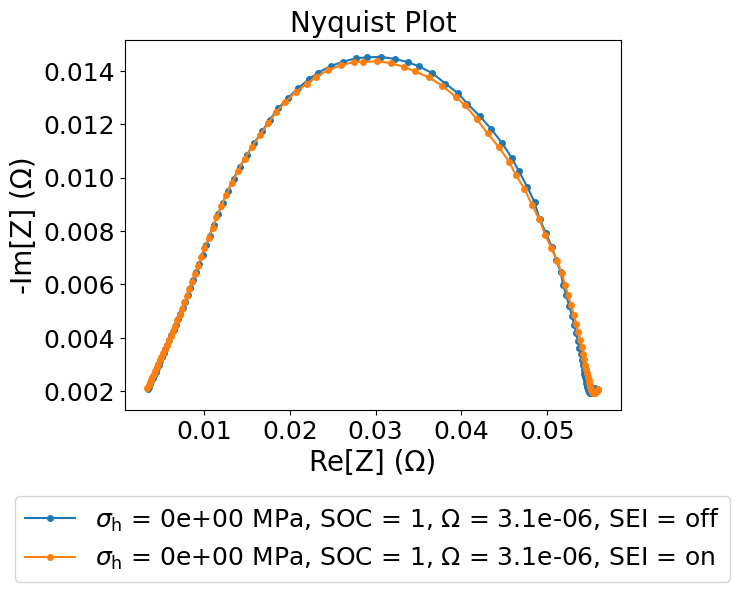

In [30]:
plt.plot(Z_0MPa_soc100_omgDef[:, 1], -Z_0MPa_soc100_omgDef[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param0['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param0['Negative electrode partial molar volume [m3.mol-1]']:.1e}, SEI = off")


plt.plot(Z_0MPa_soc100_SEI[:, 1], -Z_0MPa_soc100_SEI[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param0['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param0['Negative electrode partial molar volume [m3.mol-1]']:.1e}, SEI = on")


# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')


plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

#### $\sigma_h$ = 1 GPa, SOC 1

In [32]:
hydrostatic_stress = 1e9

I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_1MPa_soc100_SEI = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                "particle mechanics": "swelling only",
                                                "SEI": "solvent-diffusion limited",
                                                "SEI porosity change": "true",},
                                        )

    param1 = pybamm.ParameterValues("Ai2020") 
    param1.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param1["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param1, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_1MPa_soc100_SEI.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_1MPa_soc100_SEI = np.array(Z_1MPa_soc100_SEI)

# save to txt
np.savetxt("Z_1MPa_soc100_SEI.txt", Z_1MPa_soc100_SEI)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

# #NARIŠEMO NIQUISTOV DIAGRAM
# plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
# plt.plot(Z_1MPa_soc100_SEI[:, 1], -Z_1MPa_soc100_SEI[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
#          label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param1['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param1['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# # Labels and title
# plt.xlabel('Re[Z] (Ω)')
# plt.ylabel('-Im[Z] (Ω)')
# plt.title('Nyquist Plot')
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# # Add grid for better readability
# plt.grid(True, linestyle='--', linewidth=0.5)

# # Equal aspect ratio for true representation of impedance
# plt.axis('equal')

# # Optional: add minor ticks
# plt.minorticks_on()
# plt.tick_params(which='both', direction='in', top=True, right=True)

# plt.tight_layout()
# plt.show()


# # Compute magnitude (absolute value) and phase (angle)
# magnitude = np.abs(Z_1MPa_soc100_SEI[:, 1] + 1j * Z_1MPa_soc100_SEI[:, 2])  # Combine real and imag parts
# phase = np.angle(Z_1MPa_soc100_SEI[:, 1] + 1j * Z_1MPa_soc100_SEI[:, 2], deg=True)  # Phase in degrees

# # Frequency axis (log scale typical for Bode)
# freq = Z_1MPa_soc100_SEI[:, 0]  # Assuming first column is frequency

# # Tidy layout
# plt.tight_layout()
# plt.show()

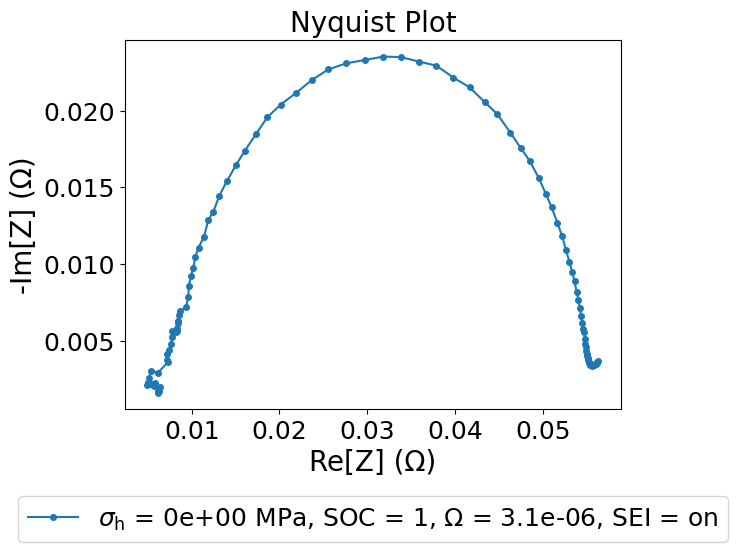

In [34]:
plt.plot(Z_1MPa_soc100_SEI[:, 1], -Z_1MPa_soc100_SEI[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param0['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param0['Negative electrode partial molar volume [m3.mol-1]']:.1e}, SEI = on")


# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')


plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

#### $\sigma_h$ = 2 GPa, SOC 1

In [33]:
hydrostatic_stress = 2e9

I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_1MPa_soc100_SEI = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                "particle mechanics": "swelling only",
                                                "SEI": "solvent-diffusion limited",
                                                "SEI porosity change": "true",},
                                        )

    param1 = pybamm.ParameterValues("Ai2020") 
    param1.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param1["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param1, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_1MPa_soc100_SEI.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_1MPa_soc100_SEI = np.array(Z_1MPa_soc100_SEI)

# save to txt
np.savetxt("Z_2GPa_soc100_SEI.txt", Z_1MPa_soc100_SEI)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

# #NARIŠEMO NIQUISTOV DIAGRAM
# plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
# plt.plot(Z_1MPa_soc100_SEI[:, 1], -Z_1MPa_soc100_SEI[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
#          label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param1['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param1['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# # Labels and title
# plt.xlabel('Re[Z] (Ω)')
# plt.ylabel('-Im[Z] (Ω)')
# plt.title('Nyquist Plot')
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# # Add grid for better readability
# plt.grid(True, linestyle='--', linewidth=0.5)

# # Equal aspect ratio for true representation of impedance
# plt.axis('equal')

# # Optional: add minor ticks
# plt.minorticks_on()
# plt.tick_params(which='both', direction='in', top=True, right=True)

# plt.tight_layout()
# plt.show()


# # Compute magnitude (absolute value) and phase (angle)
# magnitude = np.abs(Z_1MPa_soc100_SEI[:, 1] + 1j * Z_1MPa_soc100_SEI[:, 2])  # Combine real and imag parts
# phase = np.angle(Z_1MPa_soc100_SEI[:, 1] + 1j * Z_1MPa_soc100_SEI[:, 2], deg=True)  # Phase in degrees

# # Frequency axis (log scale typical for Bode)
# freq = Z_1MPa_soc100_SEI[:, 0]  # Assuming first column is frequency

# # Tidy layout
# plt.tight_layout()
# plt.show()

# Vključimo particle cracking

### $\Omega$ = 3.1e-6 $m^3/mol$ (default)

#### $\sigma_h$ = 0 Pa, SOC 1

In [6]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_0MPa_soc100_cracking = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                "particle mechanics": "swelling and cracking",
                                                },
                                        )

    param0 = pybamm.ParameterValues("Ai2020") 
    param0.update(
        {"Hydrostatic stress [Pa]": 0},
        check_already_exists=False  
    )
    param0["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param0, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_0MPa_soc100_cracking.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_0MPa_soc100_cracking = np.array(Z_0MPa_soc100_cracking)

# save to txt
np.savetxt("Z_0MPa_soc100_cracking.txt", Z_0MPa_soc100_cracking)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

# #NARIŠEMO NIQUISTOV DIAGRAM
# plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
# plt.plot(Z_0MPa_soc100_cracking[:, 1], -Z_0MPa_soc100_cracking[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
#          label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param0['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param0['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# # Labels and title
# plt.xlabel('Re[Z] (Ω)')
# plt.ylabel('-Im[Z] (Ω)')
# plt.title('Nyquist Plot')
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# # Add grid for better readability
# plt.grid(True, linestyle='--', linewidth=0.5)

# # Equal aspect ratio for true representation of impedance
# plt.axis('equal')

# # Optional: add minor ticks
# plt.minorticks_on()
# plt.tick_params(which='both', direction='in', top=True, right=True)

# plt.tight_layout()
# plt.show()


# # Compute magnitude (absolute value) and phase (angle)
# magnitude = np.abs(Z_0MPa_soc100_cracking[:, 1] + 1j * Z_0MPa_soc100_cracking[:, 2])  # Combine real and imag parts
# phase = np.angle(Z_0MPa_soc100_cracking[:, 1] + 1j * Z_0MPa_soc100_cracking[:, 2], deg=True)  # Phase in degrees

# # Frequency axis (log scale typical for Bode)
# freq = Z_0MPa_soc100_cracking[:, 0]  # Assuming first column is frequency

# # Tidy layout
# plt.tight_layout()
# plt.show()

#### $\sigma_h$ = 1 MPa, SOC 1

In [7]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_1MPa_soc100_cracking = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                "particle mechanics": "swelling and cracking",
                                                },
                                        )

    param1 = pybamm.ParameterValues("Ai2020") 
    param1.update(
        {"Hydrostatic stress [Pa]": 1e6},
        check_already_exists=False  
    )
    param1["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param1, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_1MPa_soc100_cracking.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_1MPa_soc100_cracking = np.array(Z_1MPa_soc100_cracking)

# save to txt
np.savetxt("Z_1MPa_soc100_cracking.txt", Z_1MPa_soc100_cracking)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

# #NARIŠEMO NIQUISTOV DIAGRAM
# plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
# plt.plot(Z_1MPa_soc100_cracking[:, 1], -Z_1MPa_soc100_cracking[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
#          label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param1['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param1['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# # Labels and title
# plt.xlabel('Re[Z] (Ω)')
# plt.ylabel('-Im[Z] (Ω)')
# plt.title('Nyquist Plot')
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# # Add grid for better readability
# plt.grid(True, linestyle='--', linewidth=0.5)

# # Equal aspect ratio for true representation of impedance
# plt.axis('equal')

# # Optional: add minor ticks
# plt.minorticks_on()
# plt.tick_params(which='both', direction='in', top=True, right=True)

# plt.tight_layout()
# plt.show()


# # Compute magnitude (absolute value) and phase (angle)
# magnitude = np.abs(Z_1MPa_soc100_cracking[:, 1] + 1j * Z_1MPa_soc100_cracking[:, 2])  # Combine real and imag parts
# phase = np.angle(Z_1MPa_soc100_cracking[:, 1] + 1j * Z_1MPa_soc100_cracking[:, 2], deg=True)  # Phase in degrees

# # Frequency axis (log scale typical for Bode)
# freq = Z_1MPa_soc100_cracking[:, 0]  # Assuming first column is frequency

# # Tidy layout
# plt.tight_layout()
# plt.show()

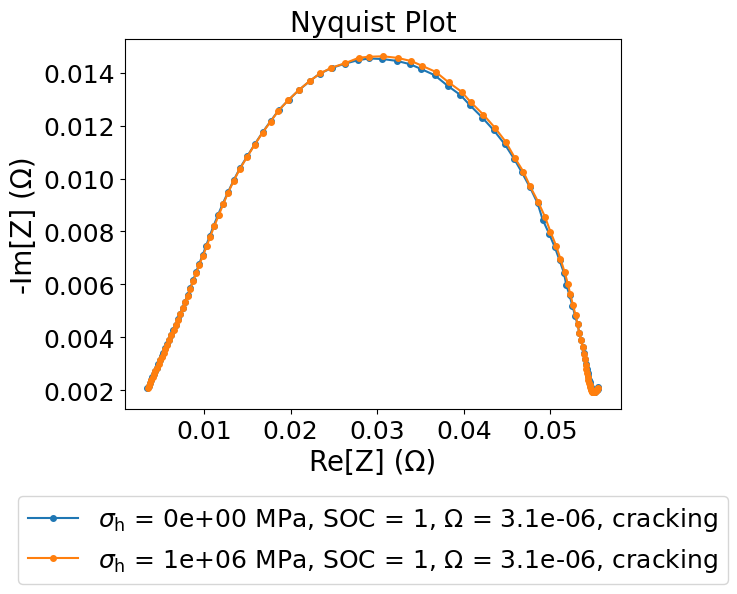

In [8]:
plt.plot(Z_0MPa_soc100_cracking[:, 1], -Z_0MPa_soc100_cracking[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param0['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param0['Negative electrode partial molar volume [m3.mol-1]']:.1e}, cracking")

plt.plot(Z_1MPa_soc100_cracking[:, 1], -Z_1MPa_soc100_cracking[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param1['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param1['Negative electrode partial molar volume [m3.mol-1]']:.1e}, cracking")


# Labels and title
plt.xlabel('Re[Z] (Ω)') 
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))


#### $\sigma_h$ = 0.5 MPa, SOC 1

In [9]:
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_05MPa_soc100_cracking = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling and cracking",
                                                 },
                                        )

    param05 = pybamm.ParameterValues("Ai2020") 
    param05.update(
        {"Hydrostatic stress [Pa]": 0.5e6},
        check_already_exists=False  
    )
    param05["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param05, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_05MPa_soc100_cracking.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_05MPa_soc100_cracking = np.array(Z_05MPa_soc100_cracking)

# save to txt
np.savetxt("Z_05MPa_soc100_cracking.txt", Z_05MPa_soc100_cracking)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

# #NARIŠEMO NIQUISTOV DIAGRAM
# plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
# plt.plot(Z_05MPa_soc100_cracking[:, 1], -Z_05MPa_soc100_cracking[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
#          label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param05['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param05['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# # Labels and title
# plt.xlabel('Re[Z] (Ω)')
# plt.ylabel('-Im[Z] (Ω)')
# plt.title('Nyquist Plot')
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# # Add grid for better readability
# plt.grid(True, linestyle='--', linewidth=0.5)

# # Equal aspect ratio for true representation of impedance
# plt.axis('equal')

# # Optional: add minor ticks
# plt.minorticks_on()
# plt.tick_params(which='both', direction='in', top=True, right=True)

# plt.tight_layout()
# plt.show()


# # Compute magnitude (absolute value) and phase (angle)
# magnitude = np.abs(Z_05MPa_soc100_cracking[:, 1] + 1j * Z_05MPa_soc100_cracking[:, 2])  # Combine real and imag parts
# phase = np.angle(Z_05MPa_soc100_cracking[:, 1] + 1j * Z_05MPa_soc100_cracking[:, 2], deg=True)  # Phase in degrees

# # Frequency axis (log scale typical for Bode)
# freq = Z_05MPa_soc100_cracking[:, 0]  # Assuming first column is frequency

# # Tidy layout
# plt.tight_layout()
# plt.show()

#### $\sigma_h$ = 0.1 MPa, SOC 1

In [11]:
hydrostatic_stress = 0.1e6

I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_01MPa_soc100_cracking = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                  "particle": "Fickian diffusion",
                                                 "particle mechanics": "swelling and cracking",},
                                        )

    param01 = pybamm.ParameterValues("Ai2020") 
    param01.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param01["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param01, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_01MPa_soc100_cracking.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_01MPa_soc100_cracking = np.array(Z_01MPa_soc100_cracking)

# save to txt
np.savetxt("Z_01MPa_soc100_cracking.txt", Z_01MPa_soc100_cracking)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

# #NARIŠEMO NIQUISTOV DIAGRAM
# plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
# plt.plot(Z_01MPa_soc100_cracking[:, 1], -Z_01MPa_soc100_cracking[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
#          label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param01['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param01['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# # Labels and title
# plt.xlabel('Re[Z] (Ω)')
# plt.ylabel('-Im[Z] (Ω)')
# plt.title('Nyquist Plot')
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# # Add grid for better readability
# plt.grid(True, linestyle='--', linewidth=0.5)

# # Equal aspect ratio for true representation of impedance
# plt.axis('equal')

# # Optional: add minor ticks
# plt.minorticks_on()
# plt.tick_params(which='both', direction='in', top=True, right=True)

# plt.tight_layout()
# plt.show()


# # Compute magnitude (absolute value) and phase (angle)
# magnitude = np.abs(Z_01MPa_soc100_cracking[:, 1] + 1j * Z_01MPa_soc100_cracking[:, 2])  # Combine real and imag parts
# phase = np.angle(Z_01MPa_soc100_cracking[:, 1] + 1j * Z_01MPa_soc100_cracking[:, 2], deg=True)  # Phase in degrees

# # Frequency axis (log scale typical for Bode)
# freq = Z_01MPa_soc100_cracking[:, 0]  # Assuming first column is frequency

# # Tidy layout
# plt.tight_layout()
# plt.show()

#### $\sigma_h$ = 2 MPa, SOC 1

In [12]:
hydrostatic_stress = 2e6

I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_2MPa_soc100_cracking = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                "particle mechanics": "swelling and cracking",
                                                },
                                        )

    param2 = pybamm.ParameterValues("Ai2020") 
    param2.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param2["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param2, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_2MPa_soc100_cracking.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_2MPa_soc100_cracking = np.array(Z_2MPa_soc100_cracking)

# save to txt
np.savetxt("Z_2MPa_soc100_cracking.txt", Z_2MPa_soc100_cracking)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

# #NARIŠEMO NIQUISTOV DIAGRAM
# plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
# plt.plot(Z_2MPa_soc100_cracking[:, 1], -Z_2MPa_soc100_cracking[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
#          label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param2['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param2['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# # Labels and title
# plt.xlabel('Re[Z] (Ω)')
# plt.ylabel('-Im[Z] (Ω)')
# plt.title('Nyquist Plot')
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# # Add grid for better readability
# plt.grid(True, linestyle='--', linewidth=0.5)

# # Equal aspect ratio for true representation of impedance
# plt.axis('equal')

# # Optional: add minor ticks
# plt.minorticks_on()
# plt.tick_params(which='both', direction='in', top=True, right=True)

# plt.tight_layout()
# plt.show()


# # Compute magnitude (absolute value) and phase (angle)
# magnitude = np.abs(Z_2MPa_soc100_cracking[:, 1] + 1j * Z_2MPa_soc100_cracking[:, 2])  # Combine real and imag parts
# phase = np.angle(Z_2MPa_soc100_cracking[:, 1] + 1j * Z_2MPa_soc100_cracking[:, 2], deg=True)  # Phase in degrees

# # Frequency axis (log scale typical for Bode)
# freq = Z_2MPa_soc100_cracking[:, 0]  # Assuming first column is frequency

# # Tidy layout
# plt.tight_layout()
# plt.show()

#### Primerjava

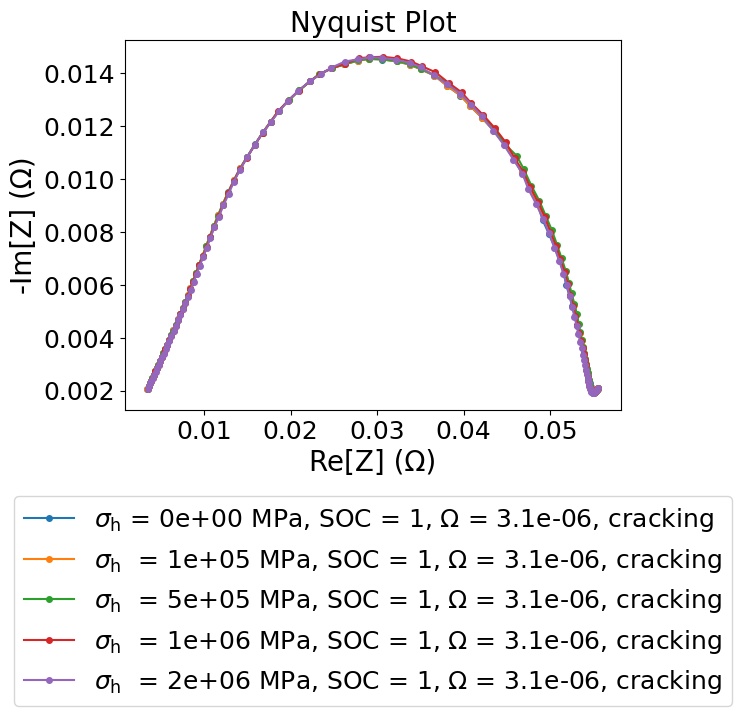

In [13]:
plt.plot(Z_0MPa_soc100_cracking[:, 1], -Z_0MPa_soc100_cracking[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param0['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param0['Negative electrode partial molar volume [m3.mol-1]']:.1e}, cracking")

plt.plot(Z_01MPa_soc100_cracking[:, 1], -Z_01MPa_soc100_cracking[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
        label=fr"$\sigma_{{\mathrm{{h}}}}$  = {param01['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param01['Negative electrode partial molar volume [m3.mol-1]']:.1e}, cracking")

plt.plot(Z_05MPa_soc100_cracking[:, 1], -Z_05MPa_soc100_cracking[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
        label=fr"$\sigma_{{\mathrm{{h}}}}$  = {param05['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param05['Negative electrode partial molar volume [m3.mol-1]']:.1e}, cracking")

plt.plot(Z_1MPa_soc100_cracking[:, 1], -Z_1MPa_soc100_cracking[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
        label=fr"$\sigma_{{\mathrm{{h}}}}$  = {param1['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param1['Negative electrode partial molar volume [m3.mol-1]']:.1e}, cracking")

plt.plot(Z_2MPa_soc100_cracking[:, 1], -Z_2MPa_soc100_cracking[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
        label=fr"$\sigma_{{\mathrm{{h}}}}$  = {param2['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param2['Negative electrode partial molar volume [m3.mol-1]']:.1e}, cracking")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')


plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

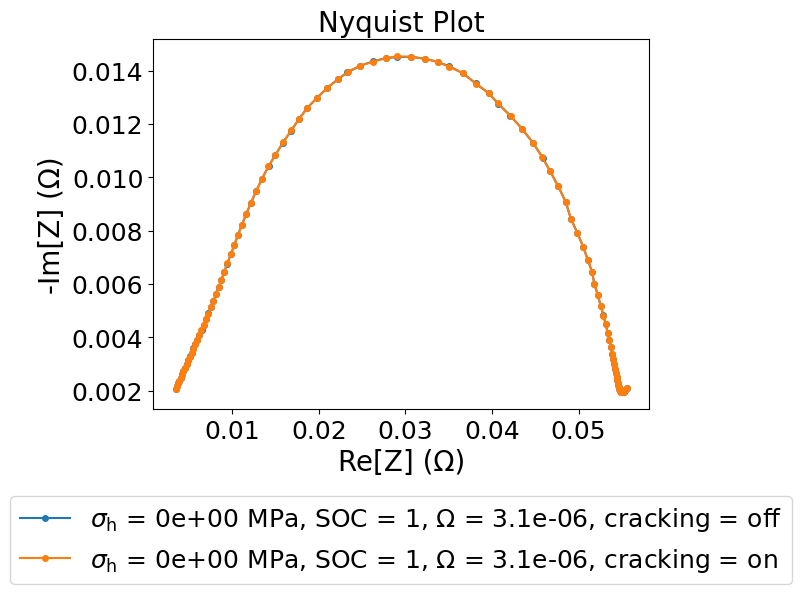

In [15]:
#import from txt file
Z_0MPa_soc100_omgDef = np.loadtxt("Z_0MPa_soc100_omgDef.txt")  

plt.plot(Z_0MPa_soc100_omgDef[:, 1], -Z_0MPa_soc100_omgDef[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param0['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param0['Negative electrode partial molar volume [m3.mol-1]']:.1e}, cracking = off")


plt.plot(Z_0MPa_soc100_cracking[:, 1], -Z_0MPa_soc100_cracking[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param0['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param0['Negative electrode partial molar volume [m3.mol-1]']:.1e}, cracking = on")


# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')


plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

#### $\sigma_h$ = 1 GPa, SOC 1

In [16]:
hydrostatic_stress = 1e9

I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_1GPa_soc100_cracking = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                "particle mechanics": "swelling and cracking",
                                                },
                                        )

    param1 = pybamm.ParameterValues("Ai2020") 
    param1.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param1["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param1, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_1GPa_soc100_cracking.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_1GPa_soc100_cracking = np.array(Z_1GPa_soc100_cracking)

# save to txt
np.savetxt("Z_1GPa_soc100_cracking.txt", Z_1GPa_soc100_cracking)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

# #NARIŠEMO NIQUISTOV DIAGRAM
# plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
# plt.plot(Z_1GPa_soc100_cracking[:, 1], -Z_1GPa_soc100_cracking[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
#          label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param1['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param1['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# # Labels and title
# plt.xlabel('Re[Z] (Ω)')
# plt.ylabel('-Im[Z] (Ω)')
# plt.title('Nyquist Plot')
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# # Add grid for better readability
# plt.grid(True, linestyle='--', linewidth=0.5)

# # Equal aspect ratio for true representation of impedance
# plt.axis('equal')

# # Optional: add minor ticks
# plt.minorticks_on()
# plt.tick_params(which='both', direction='in', top=True, right=True)

# plt.tight_layout()
# plt.show()


# # Compute magnitude (absolute value) and phase (angle)
# magnitude = np.abs(Z_1GPa_soc100_cracking[:, 1] + 1j * Z_1GPa_soc100_cracking[:, 2])  # Combine real and imag parts
# phase = np.angle(Z_1GPa_soc100_cracking[:, 1] + 1j * Z_1GPa_soc100_cracking[:, 2], deg=True)  # Phase in degrees

# # Frequency axis (log scale typical for Bode)
# freq = Z_1GPa_soc100_cracking[:, 0]  # Assuming first column is frequency

# # Tidy layout
# plt.tight_layout()
# plt.show()

#### $\sigma_h$ = 2 GPa, SOC 1

In [ ]:
hydrostatic_stress = 2e9

I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_2GPa_soc100_cracking = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):
    # model = pybamm.lithium_ion.DFN(options={"surface form": "differential"},)
    # model, ki ima le mehansko degradacijo
    # model = pybamm.lithium_ion.BasicDFN()
    # param = model.default_parameter_values 

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                "particle mechanics": "swelling and cracking",
                                                },
                                        )

    param2 = pybamm.ParameterValues("Ai2020") 
    param2.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param2["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param2, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #print(est_amp, est_mean, est_phase*180/np.pi) #JUST FOR DEBUGGING

    #plt.plot(est_amp * np.sin(2*np.pi*freq*t + est_phase) + est_mean)
    #plt.plot(simulated_U_L)
    #plt.show()

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_2GPa_soc100_cracking.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_2GPa_soc100_cracking = np.array(Z_2GPa_soc100_cracking)

# save to txt
np.savetxt("Z_2GPa_soc100_cracking.txt", Z_2GPa_soc100_cracking)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

# #NARIŠEMO NIQUISTOV DIAGRAM
# plt.figure(figsize=(6, 6))  # Make the figure square for Nyquist plots
# plt.plot(Z_2GPa_soc100_cracking[:, 1], -Z_2GPa_soc100_cracking[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
#          label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param2['Hydrostatic stress [Pa]']:.0e} MPa, SOC = 1, $\Omega$ = {param2['Negative electrode partial molar volume [m3.mol-1]']:.1e}")

# # Labels and title
# plt.xlabel('Re[Z] (Ω)')
# plt.ylabel('-Im[Z] (Ω)')
# plt.title('Nyquist Plot')
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))

# # Add grid for better readability
# plt.grid(True, linestyle='--', linewidth=0.5)

# # Equal aspect ratio for true representation of impedance
# plt.axis('equal')

# # Optional: add minor ticks
# plt.minorticks_on()
# plt.tick_params(which='both', direction='in', top=True, right=True)

# plt.tight_layout()
# plt.show()


# # Compute magnitude (absolute value) and phase (angle)
# magnitude = np.abs(Z_2GPa_soc100_cracking[:, 1] + 1j * Z_2GPa_soc100_cracking[:, 2])  # Combine real and imag parts
# phase = np.angle(Z_2GPa_soc100_cracking[:, 1] + 1j * Z_2GPa_soc100_cracking[:, 2], deg=True)  # Phase in degrees

# # Frequency axis (log scale typical for Bode)
# freq = Z_2GPa_soc100_cracking[:, 0]  # Assuming first column is frequency

# # Tidy layout
# plt.tight_layout()
# plt.show()

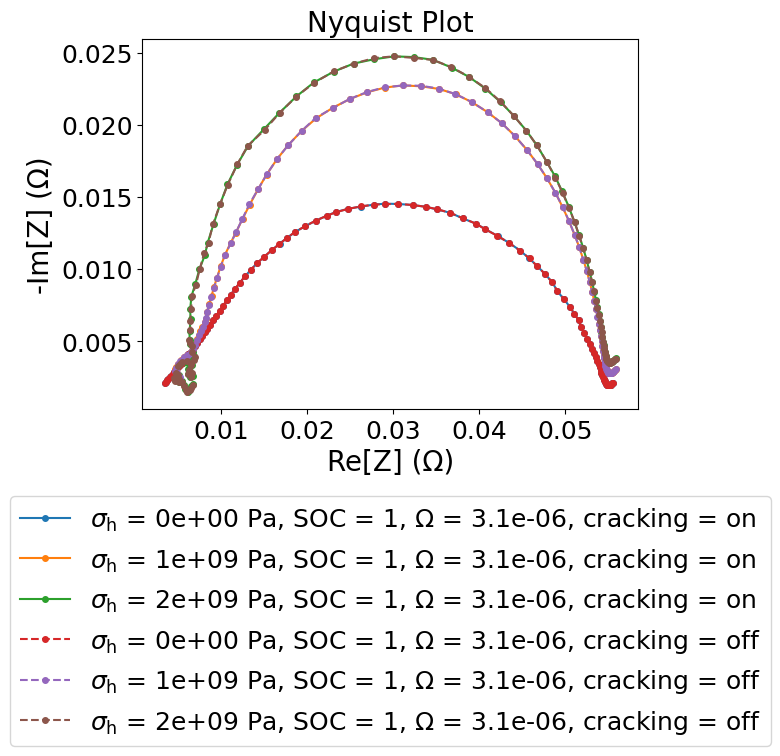

In [31]:
Z_0GPa_soc100_highPrecision = np.loadtxt("Z_0GPa_soc100_highPrecision.txt")
Z_1GPa_soc100_highPrecision = np.loadtxt("Z_1GPa_soc100_highPrecision.txt")
Z_2GPa_soc100_highPrecision = np.loadtxt("Z_2GPa_soc100_highPrecision.txt")

plt.plot(Z_0MPa_soc100_cracking[:, 1], -Z_0MPa_soc100_cracking[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param0['Hydrostatic stress [Pa]']:.0e} Pa, SOC = 1, $\Omega$ = {param0['Negative electrode partial molar volume [m3.mol-1]']:.1e}, cracking = on")  

plt.plot(Z_1GPa_soc100_cracking[:, 1], -Z_1GPa_soc100_cracking[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param1['Hydrostatic stress [Pa]']:.0e} Pa, SOC = 1, $\Omega$ = {param1['Negative electrode partial molar volume [m3.mol-1]']:.1e}, cracking = on")

plt.plot(Z_2GPa_soc100_cracking[:, 1], -Z_2GPa_soc100_cracking[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4,
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param2['Hydrostatic stress [Pa]']:.0e} Pa, SOC = 1, $\Omega$ = {param0['Negative electrode partial molar volume [m3.mol-1]']:.1e}, cracking = on")

plt.plot(Z_0GPa_soc100_highPrecision[:, 1], -Z_0GPa_soc100_highPrecision[:, 2], marker='o', linestyle='--', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param0['Hydrostatic stress [Pa]']:.0e} Pa, SOC = 1, $\Omega$ = {param0['Negative electrode partial molar volume [m3.mol-1]']:.1e}, cracking = off")

plt.plot(Z_1GPa_soc100_highPrecision[:, 1], -Z_1GPa_soc100_highPrecision[:, 2], marker='o', linestyle='--', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param1['Hydrostatic stress [Pa]']:.0e} Pa, SOC = 1, $\Omega$ = {param1['Negative electrode partial molar volume [m3.mol-1]']:.1e}, cracking = off")       

plt.plot(Z_2GPa_soc100_highPrecision[:, 1], -Z_2GPa_soc100_highPrecision[:, 2], marker='o', linestyle='--', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param2['Hydrostatic stress [Pa]']:.0e} Pa, SOC = 1, $\Omega$ = {param2['Negative electrode partial molar volume [m3.mol-1]']:.1e}, cracking = off")       

# Labels and title
plt.xlabel('Re[Z] (Ω)') 
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))
plt.show()

# Half-cell model

## Positive half-cell

In [21]:
hydrostatic_stress = 0

I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 100000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_0Pa_soc100_positiveHalf = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):

    model = pybamm.lithium_ion.DFN(options={"working electrode": "positive",
                                                "surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                # "particle mechanics": "swelling only", # odpravimo KeyError: "'Positive electrode partial molar volume [m3.mol-1]' not found. 
                                                },
                                        )

    param0 = pybamm.ParameterValues("Xu2019") 
    param0.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param0["Current function [A]"] = my_fun(I_0, freq)

    ##################################################### DODALA zaradi KeyError-ja "'Negative electrode partial molar volume [m3.mol-1]' not found. 
    param0.update(
        {"Negative electrode partial molar volume [m3.mol-1]": param0['Lithium metal partial molar volume [m3.mol-1]']}, #setting partial molar volume to zero to avoid mechanics in the negative electrode
        check_already_exists=False
    )

#     var_pts = {
#     "x_n": 30,  # negative electrode
#     "x_s": 20,  # separator
#     "x_p": 30,  # positive electrode
#     "r_n": 25,  # negative particle
#     "r_p": 25,  # positive particle
# }

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param0, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_0Pa_soc100_positiveHalf.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_0Pa_soc100_positiveHalf = np.array(Z_0Pa_soc100_positiveHalf)

# save to txt
np.savetxt("Z_0Pa_soc100_positiveHalf.txt", Z_0Pa_soc100_positiveHalf)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")



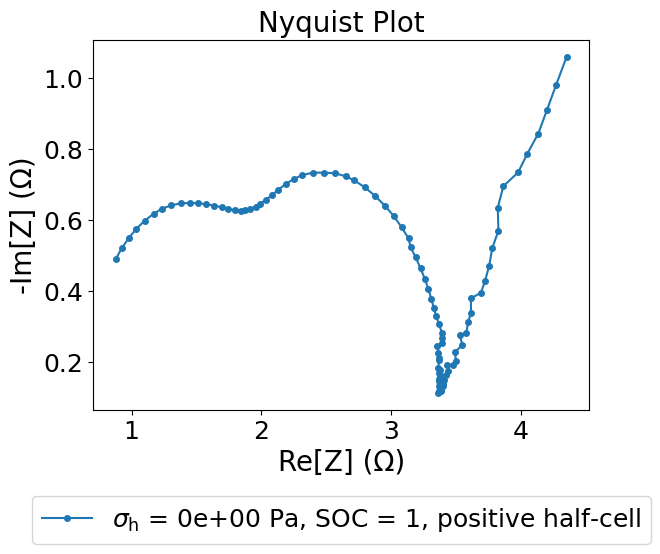

In [19]:
plt.plot(Z_0Pa_soc100_positiveHalf[:, 1], -Z_0Pa_soc100_positiveHalf[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {param0['Hydrostatic stress [Pa]']:.0e} Pa, SOC = 1, positive half-cell")  

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot') 
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))
plt.show()

# Symmetrical cell

Korekcije v PyBaMM mapi `src/input/parameters/lithium_ion`: 
1. izdelava `SymLCOAi2020` - simetrična celica s katodama  -> prepisala vse anodne parametre s katodnimi
2. izdelava `SymGraphiteAi2020` - simetrična celica z anodama -> prepisala vse katodne parametre z anodnimi
3. korekcija `__init__.py` -> dodala imeni obeh setov parametrov

Nato v glavni mapi PyBaMM:
4. korekcija dokumenta `pyproject.toml` -> dodala:
```
SymGraphiteAi2020 = "pybamm.input.parameters.lithium_ion.SymGraphiteAi2020:get_parameter_values"
SymLCOAi2020 = "pybamm.input.parameters.lithium_ion.SymLCOAi2020:get_parameter_values"
```

Potem sem zagnala `install_pybamm.ipynb`.

In [1]:
# import
import pybamm
import pybammeis 
import numpy as np
import matplotlib.pyplot as plt
import time
from ipywidgets import interact, FloatSlider
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from scipy import interpolate
from scipy import optimize

# Shrani slike
save_fig = False 

# Shrani animacijo
save_ani = False

# Formatiranje grafov
# Nastavitev velikosti grafa (širina, višina v inch-ih)
fig_size = figsize=(8, 6)  

# Nastavitev velikosti pisave
plt.rcParams.update({
    'font.size': 20,           # Osnovna velikost pisave
    'axes.titlesize': 20,      # Velikost naslova grafa
    'axes.labelsize': 20,      # Velikost pisave na osi
    'xtick.labelsize': 18,     # Velikost številk na x osi
    'ytick.labelsize': 18,     # Velikost številk na y osi
    'legend.fontsize': 18,     # Velikost pisave v legendi
})

## LiCo2

### $\sigma_h$ = 0 Pa, SOC 1

In [ ]:
hydrostatic_stress = 0

I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z_0Pa_soc100_SymLCO = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):

    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                "particle mechanics": "swelling only",
                                                },
                                        )

    param0 = pybamm.ParameterValues("SymLCOAi2020") 
    param0.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param0["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param0, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN_0.solve(t_eval=t, initial_soc=1)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]


    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z_0Pa_soc100_SymLCO.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z_0Pa_soc100_SymLCO = np.array(Z_0Pa_soc100_SymLCO)

# save to txt
np.savetxt("Z_0Pa_soc100_SymLCO.txt", Z_0Pa_soc100_SymLCO)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")



In [ ]:
# param0.search("voltage")
# model.variables.search("voltage")

Results for 'voltage': ['Lower voltage cut-off [V]', 'Upper voltage cut-off [V]', 'Open-circuit voltage at 0% SOC [V]', 'Open-circuit voltage at 100% SOC [V]']
Lower voltage cut-off [V] -> 3.0
Upper voltage cut-off [V] -> 4.2
Open-circuit voltage at 0% SOC [V] -> 3.0
Open-circuit voltage at 100% SOC [V] -> 4.2


# EIS pri konst. napetosti

To je napačen pristop -> v2 je pravilni.

In [1]:
# import
import pybamm
import pybammeis 
import numpy as np
import matplotlib.pyplot as plt
import time
from ipywidgets import interact, FloatSlider
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from scipy import interpolate
from scipy import optimize

# Shrani slike
save_fig = False 

# Shrani animacijo
save_ani = False

# Formatiranje grafov
# Nastavitev velikosti grafa (širina, višina v inch-ih)
fig_size = figsize=(8, 6)  

# Nastavitev velikosti pisave
plt.rcParams.update({
    'font.size': 20,           # Osnovna velikost pisave
    'axes.titlesize': 20,      # Velikost naslova grafa
    'axes.labelsize': 20,      # Velikost pisave na osi
    'xtick.labelsize': 18,     # Velikost številk na x osi
    'ytick.labelsize': 18,     # Velikost številk na y osi
    'legend.fontsize': 18,     # Velikost pisave v legendi
})

In [39]:
model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                },
                                        )
param0 = pybamm.ParameterValues("Ai2020") 
param0.update(
    {"Hydrostatic stress [Pa]": 0},
    check_already_exists=False  
)


param1 = pybamm.ParameterValues("Ai2020") 
param1.update(
    {"Hydrostatic stress [Pa]": 1e8},
    check_already_exists=False  
)


param2 = pybamm.ParameterValues("Ai2020") 
param2.update(
    {"Hydrostatic stress [Pa]": 1e9},
    check_already_exists=False  
)


var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
solver = pybamm.IDAKLUSolver()  



sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param0, var_pts=var_pts, solver=solver, experiment=experiment 
                              )
sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param1, var_pts=var_pts, solver=solver, experiment=experiment 
                              )
sim_DFN_2 = pybamm.Simulation(model= model, parameter_values=param2, var_pts=var_pts, solver=solver,experiment=experiment 
                              )

######################
t_eval = [0, 3600]
# t_eval = np.linspace(0, 0.3, 1000)  
######################

start = time.time()
sol_DFN = sim_DFN_0.solve(t_eval=t_eval, initial_soc=1)
end = time.time()
print(f"Simulacija DFN_0 zaključena v {end - start:.2f} s.")

start = time.time()
sol_DFN_1 = sim_DFN_1.solve(t_eval=t_eval, initial_soc=1)
end = time.time()
print(f"Simulacija DFN_1 zaključena v {end - start:.2f} s.")

start = time.time()
sol_DFN_2 = sim_DFN_2.solve(t_eval=t_eval, initial_soc=1)
end = time.time()
print(f"Simulacija DFN_2 zaključena v {end - start:.2f} s.")

2025-10-30 11:21:48.241 - [WARNING] simulation.solve(557): Ignoring t_eval as solution times are specified by the experiment


Simulacija DFN_0 zaključena v 2.08 s.


2025-10-30 11:21:50.494 - [WARNING] simulation.solve(557): Ignoring t_eval as solution times are specified by the experiment


Simulacija DFN_1 zaključena v 2.59 s.


2025-10-30 11:21:53.052 - [WARNING] simulation.solve(557): Ignoring t_eval as solution times are specified by the experiment


Simulacija DFN_2 zaključena v 2.21 s.


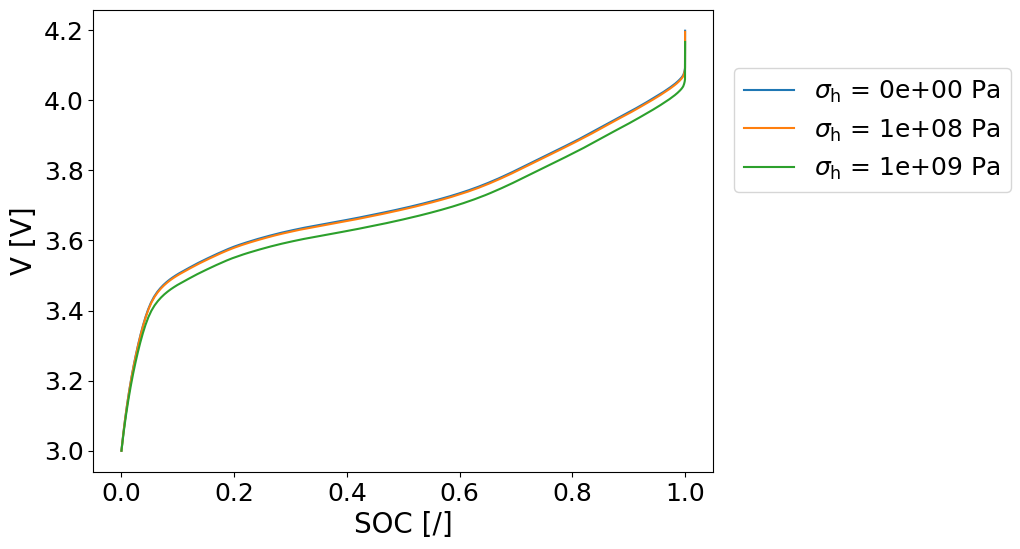

In [40]:
Q_discharged = sol_DFN["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD = (Q_discharged / Q_max)
SOC = 1 - DOD

Q_discharged = sol_DFN_1["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD_1 = (Q_discharged / Q_max)
SOC_1 = 1 - DOD_1

Q_discharged = sol_DFN_2["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD_2 = (Q_discharged / Q_max)
SOC_2 = 1 - DOD_2

# x_val = [DOD, 
#          DOD_1,
#         DOD_2
#          ]

x_val = [SOC,
         SOC_1,
        SOC_2
         ]

y_val = [sol_DFN["Voltage [V]"].data, 
         sol_DFN_1["Voltage [V]"].data,
        sol_DFN_2["Voltage [V]"].data
         ]

plt.figure(figsize=fig_size)
for i in range(len(x_val)):
    plt.plot(x_val[i], y_val[i], label=[fr"$\sigma_{{\mathrm{{h}}}}$ = {param0['Hydrostatic stress [Pa]']:.0e} Pa", 
                                        fr"$\sigma_{{\mathrm{{h}}}}$ = {param1['Hydrostatic stress [Pa]']:.0e} Pa", 
                                        fr"$\sigma_{{\mathrm{{h}}}}$ = {param2['Hydrostatic stress [Pa]']:.0e} Pa", 
                                        ][i]
                                        )
    
plt.xlabel("SOC [/]")
plt.ylabel("V [V]")
plt.legend(loc="upper right", bbox_to_anchor=(1.5, 0.9))

## SOC = 0.5

### $\sigma_h$ = 0 Pa

Pogledamo pri kateri napetosti neobremenjene celice je SOC = 50%.

In [41]:
# find soc value closest to 0.5
target_soc = 0.5
index = (np.abs(SOC - target_soc)).argmin() 
print(f"Closest SOC to {target_soc} is {SOC[index]:.4f} at index {index}.")
print(f"Corresponding Voltage: {sol_DFN['Voltage [V]'].entries[index]:.4f} V.")

Closest SOC to 0.5 is 0.5025 at index 225.
Corresponding Voltage: 3.6925 V.


Prištejemo napetosti neobremenjene celice mehanski prispevek in pogledamo pri katerem SOC je ta.

In [42]:
# target voltage
omega = param1["Negative electrode partial molar volume [m3.mol-1]"]
sigma_h_surf = param1["Hydrostatic stress [Pa]"]
F = param1["Faraday constant [C.mol-1]"]
eta_stress_1 =   omega/ F * sigma_h_surf

target_voltage_1 = sol_DFN['Voltage [V]'].entries[index] + eta_stress_1
index_voltage_1 = (np.abs(sol_DFN["Voltage [V]"].entries - target_voltage_1 )).argmin()
target_soc_1 = SOC[index_voltage_1]

print(f"For hydrostatic stress of {param1['Hydrostatic stress [Pa]']:.0e} Pa and partial molar volume of {param1['Negative electrode partial molar volume [m3.mol-1]']:.1e} m3.mol-1:")
print(f"Corrected voltage: {sol_DFN['Voltage [V]'].entries[index_voltage_1]:.4f} V at index {index_voltage_1}.")
print(f"Corresponding SOC: {target_soc_1:.4f}.")

For hydrostatic stress of 1e+08 Pa and partial molar volume of 3.1e-06 m3.mol-1:
Corrected voltage: 3.6962 V at index 224.
Corresponding SOC: 0.5123.


In [43]:
# target voltage
omega = param2["Negative electrode partial molar volume [m3.mol-1]"]
sigma_h_surf = param2["Hydrostatic stress [Pa]"]
F = param2["Faraday constant [C.mol-1]"]
eta_stress_2 =   omega/ F * sigma_h_surf

target_voltage_2 = sol_DFN['Voltage [V]'].entries[index] + eta_stress_2
index_voltage_2 = (np.abs(sol_DFN["Voltage [V]"].entries - target_voltage_2 )).argmin()
target_soc_2 = SOC[index_voltage_2]

print(f"For hydrostatic stress of {param2['Hydrostatic stress [Pa]']:.0e} Pa and partial molar volume of {param2['Negative electrode partial molar volume [m3.mol-1]']:.1e} m3.mol-1:")
print(f"Corrected voltage: {sol_DFN['Voltage [V]'].entries[index_voltage_2]:.4f} V at index {index_voltage_2}.")
print(f"Corresponding SOC: {target_soc_2:.4f}.")

For hydrostatic stress of 1e+09 Pa and partial molar volume of 3.1e-06 m3.mol-1:
Corrected voltage: 3.7260 V at index 216.
Corresponding SOC: 0.5828.


Izračunamo EIS

In [70]:
hydrostatic_stress = 0 # Pa
initialSOC = 0.5

######################################
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):


    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                },
                                        )

    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN.solve(t_eval=t, initial_soc=initialSOC)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

   
    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z = np.array(Z)

#########################################

# rename variables
Z_0Pa_soc50 = []
Z_0Pa_soc50 = Z
initialSOC0 = initialSOC
hydrostatic_stress0 = hydrostatic_stress

In [71]:
# save results
sol_DFN.save("sol_0Pa_soc50.pkl")

# save to txt
np.save("Z_0Pa_soc50", Z_0Pa_soc50)
np.savetxt("Z_0Pa_soc50.txt", Z_0Pa_soc50)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

### $\sigma_h$ = 1e8 Pa

In [ ]:
hydrostatic_stress = 1e8 # Pa
initialSOC = target_soc_1

#####################################
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):


    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                },
                                        )

    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN.solve(t_eval=t, initial_soc=initialSOC)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

   
    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z = np.array(Z)

############################
# rename variables
Z_1e8Pa_soc50 = []
Z_1e8Pa_soc50 = Z
initialSOC1 = initialSOC
hydrostatic_stress1 = hydrostatic_stress

In [54]:
# save results
sol_DFN.save("sol_1e8Pa_soc50.pkl")

# save to txt
np.save("Z_1e8Pa_soc50", Z_1e8Pa_soc50)
np.savetxt("Z_1e8Pa_soc50.txt", Z_1e8Pa_soc50)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

### $\sigma_h$ = 1e9 Pa

In [63]:
hydrostatic_stress = 1e9 # Pa
initialSOC = target_soc_2

######################################
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):


    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                },
                                        )

    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN.solve(t_eval=t, initial_soc=initialSOC)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

   
    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z = np.array(Z)

#########################################
# rename variables
Z_1e9Pa_soc50 = []
Z_1e9Pa_soc50 = Z
initialSOC2 = initialSOC
hydrostatic_stress2 = hydrostatic_stress

In [57]:
# save results
sol_DFN.save("sol_1e9Pa_soc50.pkl")

# save to txt
np.save("Z_1e9Pa_soc50", Z_1e9Pa_soc50)
np.savetxt("Z_1e9Pa_soc50.txt", Z_1e9Pa_soc50)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

## Vsi rezultati

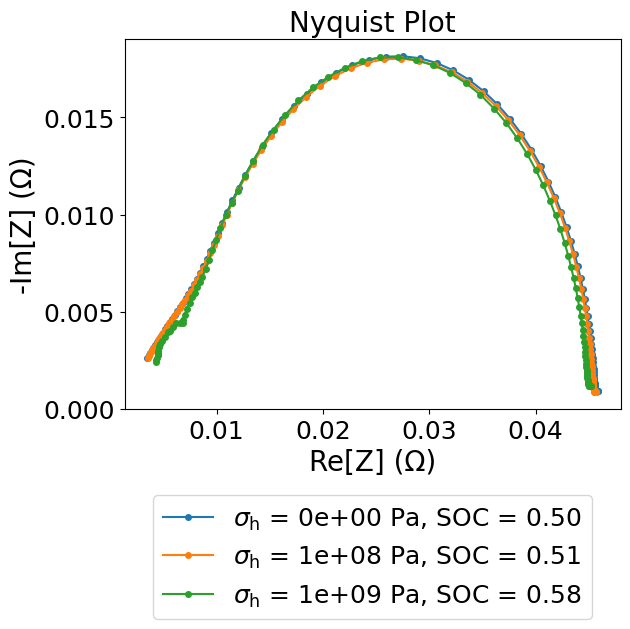

In [72]:
# Z_0Pa_soc50 = np.load("Z_0Pa_soc50.npy")
# Z_1e8Pa_soc50 = np.load("Z_1e8Pa_soc50.npy")
# Z_1e9Pa_soc50 = np.load("Z_1e9Pa_soc50.npy")

plt.plot(Z_0Pa_soc50[:, 1], -Z_0Pa_soc50[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress0:.0e} Pa, SOC = {initialSOC0:.2f}")

plt.plot(Z_1e8Pa_soc50[:, 1], -Z_1e8Pa_soc50[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress1:.0e} Pa, SOC = {initialSOC1:.2f}")

plt.plot(Z_1e9Pa_soc50[:, 1], -Z_1e9Pa_soc50[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress2:.0e} Pa, SOC = {initialSOC2:.2f}")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))
plt.show()

Preverimo, če so enake napetosti

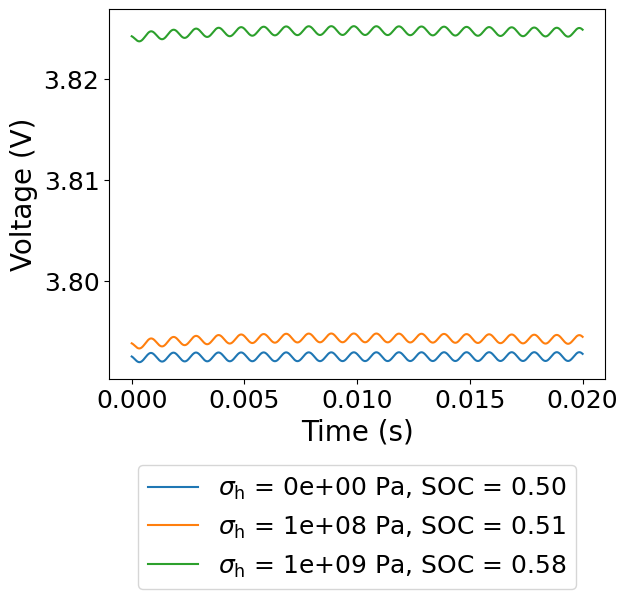

In [77]:
sol_0Pa = pybamm.load("sol_0Pa_soc50.pkl")
sol_1e8Pa = pybamm.load("sol_1e8Pa_soc50.pkl")
sol_1e9Pa = pybamm.load("sol_1e9Pa_soc50.pkl")

plt.plot(sol_0Pa["Time [s]"].entries, sol_0Pa["Voltage [V]"].entries, label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress0:.0e} Pa, SOC = {initialSOC0:.2f}")
plt.plot(sol_1e8Pa["Time [s]"].entries, sol_1e8Pa["Voltage [V]"].entries, label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress1:.0e} Pa, SOC = {initialSOC1:.2f}")
plt.plot(sol_1e9Pa["Time [s]"].entries, sol_1e9Pa["Voltage [V]"].entries, label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress2:.0e} Pa, SOC = {initialSOC2:.2f}")   

plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))
plt.show()

# EIS pri konst. napetosti v2

In [1]:
# import
import pybamm
import pybammeis 
import numpy as np
import matplotlib.pyplot as plt
import time
from ipywidgets import interact, FloatSlider
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from scipy import interpolate
from scipy import optimize

# Shrani slike
save_fig = False 

# Shrani animacijo
save_ani = False

# Formatiranje grafov
# Nastavitev velikosti grafa (širina, višina v inch-ih)
fig_size = figsize=(8, 6)  

# Nastavitev velikosti pisave
plt.rcParams.update({
    'font.size': 20,           # Osnovna velikost pisave
    'axes.titlesize': 20,      # Velikost naslova grafa
    'axes.labelsize': 20,      # Velikost pisave na osi
    'xtick.labelsize': 18,     # Velikost številk na x osi
    'ytick.labelsize': 18,     # Velikost številk na y osi
    'legend.fontsize': 18,     # Velikost pisave v legendi
})

In [2]:
model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                },
                                        )
param0 = pybamm.ParameterValues("Ai2020") 
param0.update(
    {"Hydrostatic stress [Pa]": 0},
    check_already_exists=False  
)


param1 = pybamm.ParameterValues("Ai2020") 
param1.update(
    {"Hydrostatic stress [Pa]": 1e8},
    check_already_exists=False  
)


param2 = pybamm.ParameterValues("Ai2020") 
param2.update(
    {"Hydrostatic stress [Pa]": 1e9},
    check_already_exists=False  
)


var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
solver = pybamm.IDAKLUSolver()  



sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param0, var_pts=var_pts, solver=solver, experiment=experiment 
                              )
sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param1, var_pts=var_pts, solver=solver, experiment=experiment 
                              )
sim_DFN_2 = pybamm.Simulation(model= model, parameter_values=param2, var_pts=var_pts, solver=solver,experiment=experiment 
                              )

######################
t_eval = [0, 3600]
# t_eval = np.linspace(0, 0.3, 1000)  
######################

start = time.time()
sol_DFN = sim_DFN_0.solve(t_eval=t_eval, initial_soc=1)
end = time.time()
print(f"Simulacija DFN_0 zaključena v {end - start:.2f} s.")

start = time.time()
sol_DFN_1 = sim_DFN_1.solve(t_eval=t_eval, initial_soc=1)
end = time.time()
print(f"Simulacija DFN_1 zaključena v {end - start:.2f} s.")

start = time.time()
sol_DFN_2 = sim_DFN_2.solve(t_eval=t_eval, initial_soc=1)
end = time.time()
print(f"Simulacija DFN_2 zaključena v {end - start:.2f} s.")

2025-11-10 09:22:35.245 - [WARNING] simulation.solve(557): Ignoring t_eval as solution times are specified by the experiment


Simulacija DFN_0 zaključena v 5.00 s.


2025-11-10 09:22:39.982 - [WARNING] simulation.solve(557): Ignoring t_eval as solution times are specified by the experiment


Simulacija DFN_1 zaključena v 4.50 s.


2025-11-10 09:22:44.713 - [WARNING] simulation.solve(557): Ignoring t_eval as solution times are specified by the experiment


Simulacija DFN_2 zaključena v 4.83 s.


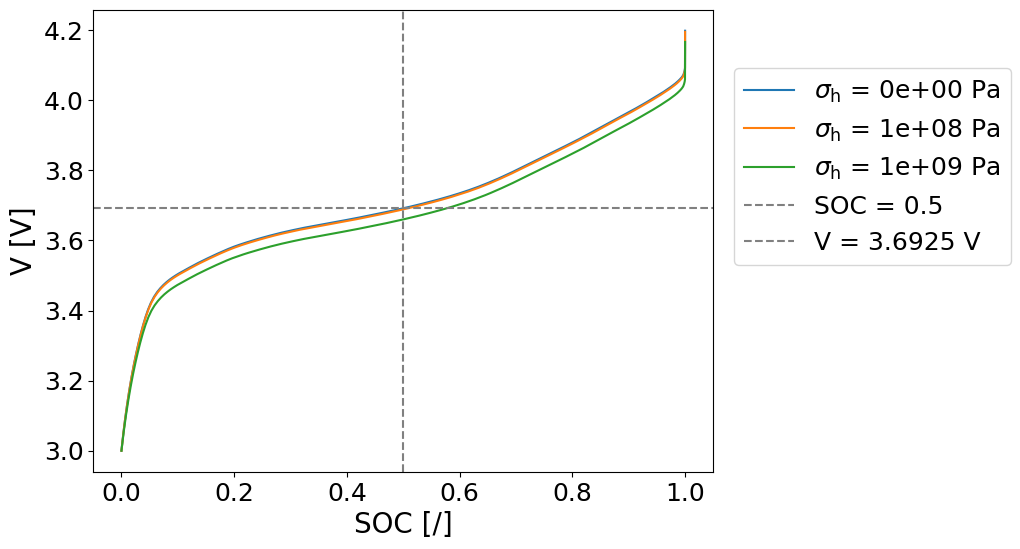

In [3]:
Q_discharged = sol_DFN["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD = (Q_discharged / Q_max)
SOC = 1 - DOD

Q_discharged = sol_DFN_1["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD_1 = (Q_discharged / Q_max)
SOC_1 = 1 - DOD_1

Q_discharged = sol_DFN_2["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD_2 = (Q_discharged / Q_max)
SOC_2 = 1 - DOD_2

# x_val = [DOD, 
#          DOD_1,
#         DOD_2
#          ]

x_val = [SOC,
         SOC_1,
        SOC_2
         ]

y_val = [sol_DFN["Voltage [V]"].data, 
         sol_DFN_1["Voltage [V]"].data,
        sol_DFN_2["Voltage [V]"].data
         ]

plt.figure(figsize=fig_size)
for i in range(len(x_val)):
    plt.plot(x_val[i], y_val[i], label=[fr"$\sigma_{{\mathrm{{h}}}}$ = {param0['Hydrostatic stress [Pa]']:.0e} Pa", 
                                        fr"$\sigma_{{\mathrm{{h}}}}$ = {param1['Hydrostatic stress [Pa]']:.0e} Pa", 
                                        fr"$\sigma_{{\mathrm{{h}}}}$ = {param2['Hydrostatic stress [Pa]']:.0e} Pa", 
                                        ][i]
                                        )
# draw line at soc = 0.5
plt.axvline(x=0.5, color='gray', linestyle='--', label='SOC = 0.5')

# draw line at 3.6925 V
plt.axhline(y=3.6925, color='gray', linestyle='--', label='V = 3.6925 V')

plt.xlabel("SOC [/]")
plt.ylabel("V [V]")
plt.legend(loc="upper right", bbox_to_anchor=(1.5, 0.9))

## SOC = 0.5

### $\sigma_h$ = 0 Pa

Pogledamo pri kateri napetosti neobremenjene celice je SOC = 50%.

In [5]:
# find soc value closest to 0.5
target_soc = 0.5
index = (np.abs(SOC - target_soc)).argmin() 
print(f"Closest SOC to {target_soc} is {SOC[index]:.4f} at index {index}.")
print(f"Corresponding Voltage: {sol_DFN['Voltage [V]'].entries[index]:.4f} V.")

Closest SOC to 0.5 is 0.5025 at index 225.
Corresponding Voltage: 3.6925 V.


Pogledamo pri katerem SOC so obremenjene celice za enako napetost.

In [8]:
# target voltage
target_voltage_1 = sol_DFN['Voltage [V]'].entries[index]
index_voltage_1 = (np.abs(sol_DFN_1["Voltage [V]"].entries - target_voltage_1 )).argmin()
target_soc_1 = SOC_1[index_voltage_1]

print(f"For hydrostatic stress of {param1['Hydrostatic stress [Pa]']:.0e} Pa and partial molar volume of {param1['Negative electrode partial molar volume [m3.mol-1]']:.1e} m3.mol-1:")
print(f"Corrected voltage: {sol_DFN_1['Voltage [V]'].entries[index_voltage_1]:.4f} V at index {index_voltage_1}.")
print(f"Corresponding SOC: {target_soc_1:.4f}.")

For hydrostatic stress of 1e+08 Pa and partial molar volume of 3.1e-06 m3.mol-1:
Corrected voltage: 3.6911 V at index 209.
Corresponding SOC: 0.5072.


In [9]:
# target voltage
target_voltage_2 = sol_DFN['Voltage [V]'].entries[index]
index_voltage_2 = (np.abs(sol_DFN_2["Voltage [V]"].entries - target_voltage_2 )).argmin()
target_soc_2 = SOC_2[index_voltage_2]

print(f"For hydrostatic stress of {param2['Hydrostatic stress [Pa]']:.0e} Pa and partial molar volume of {param2['Negative electrode partial molar volume [m3.mol-1]']:.1e} m3.mol-1:")
print(f"Corrected voltage: {sol_DFN_2['Voltage [V]'].entries[index_voltage_2]:.4f} V at index {index_voltage_2}.")
print(f"Corresponding SOC: {target_soc_2:.4f}.")

For hydrostatic stress of 1e+09 Pa and partial molar volume of 3.1e-06 m3.mol-1:
Corrected voltage: 3.6917 V at index 217.
Corresponding SOC: 0.5773.


Izračunamo EIS

In [ ]:
hydrostatic_stress = 0 # Pa
initialSOC = 0.5

######################################
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):


    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                },
                                        )

    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN.solve(t_eval=t, initial_soc=initialSOC)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

   
    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z = np.array(Z)

#########################################

# rename variables
Z_0Pa_soc50 = []
Z_0Pa_soc50 = Z
initialSOC0 = initialSOC
hydrostatic_stress0 = hydrostatic_stress

In [ ]:
# save results
sol_DFN.save("sol_0Pa_soc50.pkl")

# save to txt
np.save("Z_0Pa_soc50", Z_0Pa_soc50)
np.savetxt("Z_0Pa_soc50.txt", Z_0Pa_soc50)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

### $\sigma_h$ = 1e8 Pa

In [10]:
hydrostatic_stress = 1e8 # Pa
initialSOC = target_soc_1

#####################################
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):


    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                },
                                        )

    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN.solve(t_eval=t, initial_soc=initialSOC)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

   
    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z = np.array(Z)

############################
# rename variables
Z_1e8Pa_soc50 = []
Z_1e8Pa_soc50 = Z
initialSOC1 = initialSOC
hydrostatic_stress1 = hydrostatic_stress

In [11]:
# save results
sol_DFN.save("sol_1e8Pa_soc50.pkl")

# save to txt
np.save("Z_1e8Pa_soc50", Z_1e8Pa_soc50)
np.savetxt("Z_1e8Pa_soc50.txt", Z_1e8Pa_soc50)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

### $\sigma_h$ = 1e9 Pa

In [12]:
hydrostatic_stress = 1e9 # Pa
initialSOC = target_soc_2

######################################
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):


    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                },
                                        )

    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN.solve(t_eval=t, initial_soc=initialSOC)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

   
    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z = np.array(Z)

#########################################
# rename variables
Z_1e9Pa_soc50 = []
Z_1e9Pa_soc50 = Z
initialSOC2 = initialSOC
hydrostatic_stress2 = hydrostatic_stress

In [13]:
# save results
sol_DFN.save("sol_1e9Pa_soc50.pkl")

# save to txt
np.save("Z_1e9Pa_soc50", Z_1e9Pa_soc50)
np.savetxt("Z_1e9Pa_soc50.txt", Z_1e9Pa_soc50)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

### Vsi rezultati

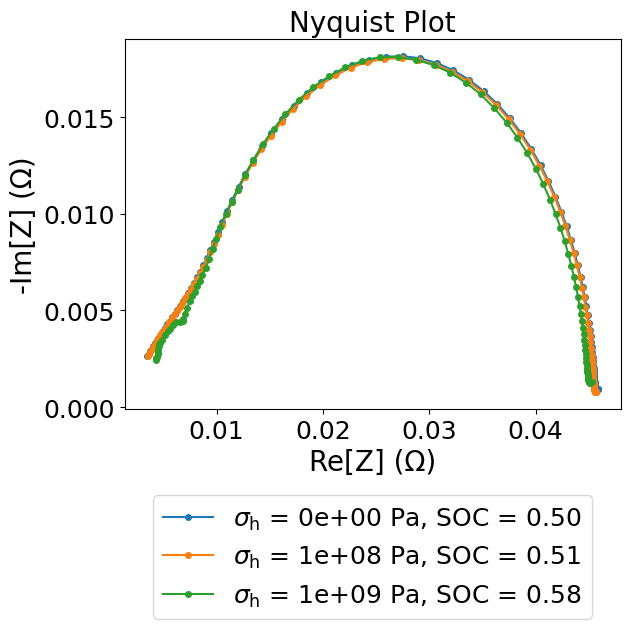

In [18]:
Z_0Pa_soc50 = np.load("Z_0Pa_soc50.npy")
# Z_1e8Pa_soc50 = np.load("Z_1e8Pa_soc50.npy")
# Z_1e9Pa_soc50 = np.load("Z_1e9Pa_soc50.npy")

plt.plot(Z_0Pa_soc50[:, 1], -Z_0Pa_soc50[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress0:.0e} Pa, SOC = {initialSOC0:.2f}")

plt.plot(Z_1e8Pa_soc50[:, 1], -Z_1e8Pa_soc50[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress1:.0e} Pa, SOC = {initialSOC1:.2f}")

plt.plot(Z_1e9Pa_soc50[:, 1], -Z_1e9Pa_soc50[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress2:.0e} Pa, SOC = {initialSOC2:.2f}")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))
plt.show()

Preverimo, če so enake napetosti

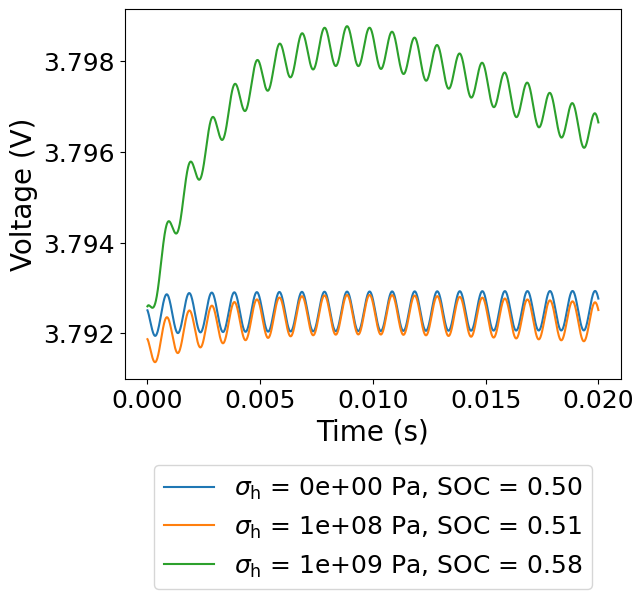

In [21]:
sol_0Pa = pybamm.load("sol_0Pa_soc50.pkl")
sol_1e8Pa = pybamm.load("sol_1e8Pa_soc50.pkl")
sol_1e9Pa = pybamm.load("sol_1e9Pa_soc50.pkl")

plt.plot(sol_0Pa["Time [s]"].entries, sol_0Pa["Voltage [V]"].entries, label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress0:.0e} Pa, SOC = {initialSOC0:.2f}")
plt.plot(sol_1e8Pa["Time [s]"].entries, sol_1e8Pa["Voltage [V]"].entries, label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress1:.0e} Pa, SOC = {initialSOC1:.2f}")
plt.plot(sol_1e9Pa["Time [s]"].entries, sol_1e9Pa["Voltage [V]"].entries, label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress2:.0e} Pa, SOC = {initialSOC2:.2f}")   

plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))
plt.show()

## SOC = 50 %, $\Omega$ = 3.1e-5 (10x)

In [ ]:
model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                },
                                        )
param0 = pybamm.ParameterValues("Ai2020") 
param0.update(
    {"Hydrostatic stress [Pa]": 0},
    check_already_exists=False  
)
param0.update(
    {"Negative electrode partial molar volume [m3.mol-1]": 3.1e-5},
    check_already_exists=False  
)


param1 = pybamm.ParameterValues("Ai2020") 
param1.update(
    {"Hydrostatic stress [Pa]": 1e8},
    check_already_exists=False  
)
param1.update(
    {"Negative electrode partial molar volume [m3.mol-1]": 3.1e-5},
    check_already_exists=False  
)


param2 = pybamm.ParameterValues("Ai2020") 
param2.update(
    {"Hydrostatic stress [Pa]": 1e9},
    check_already_exists=False  
)
param2.update(
    {"Negative electrode partial molar volume [m3.mol-1]": 3.1e-5},
    check_already_exists=False  
)

param1e7 = pybamm.ParameterValues("Ai2020")
param1e7.update(
    {"Hydrostatic stress [Pa]": 1e7},
    check_already_exists=False  
)
param1e7.update(
    {"Negative electrode partial molar volume [m3.mol-1]": 3.1e-5},
    check_already_exists=False  
)


var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
solver = pybamm.IDAKLUSolver()  



sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param0, var_pts=var_pts, solver=solver, experiment=experiment 
                              )
sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param1, var_pts=var_pts, solver=solver, experiment=experiment 
                              )
sim_DFN_2 = pybamm.Simulation(model= model, parameter_values=param2, var_pts=var_pts, solver=solver,experiment=experiment 
                              )
sim_DFN_1e7 = pybamm.Simulation(model= model, parameter_values=param1e7, var_pts=var_pts, solver=solver,experiment=experiment 
                              )

######################
t_eval = [0, 3600]
# t_eval = np.linspace(0, 0.3, 1000)  
######################

start = time.time()
sol_DFN = sim_DFN_0.solve(t_eval=t_eval, initial_soc=1)
end = time.time()
print(f"Simulacija DFN_0 zaključena v {end - start:.2f} s.")

start = time.time()
sol_DFN_1 = sim_DFN_1.solve(t_eval=t_eval, initial_soc=1)
end = time.time()
print(f"Simulacija DFN_1 zaključena v {end - start:.2f} s.")

start = time.time()
sol_DFN_2 = sim_DFN_2.solve(t_eval=t_eval, initial_soc=1)
end = time.time()
print(f"Simulacija DFN_2 zaključena v {end - start:.2f} s.")

start = time.time()
sol_DFN_1e7 = sim_DFN_1e7.solve(t_eval=t_eval, initial_soc=1)
end = time.time()
print(f"Simulacija DFN_1e7 zaključena v {end - start:.2f} s.")

2025-10-30 15:08:59.151 - [WARNING] simulation.solve(557): Ignoring t_eval as solution times are specified by the experiment


Simulacija DFN_0 zaključena v 2.23 s.


2025-10-30 15:09:01.873 - [WARNING] simulation.solve(557): Ignoring t_eval as solution times are specified by the experiment


Simulacija DFN_1e7 zaključena v 2.70 s.


Text(0.5, 1.0, '$\\Omega$ = 3.1e-5 m3.mol-1')

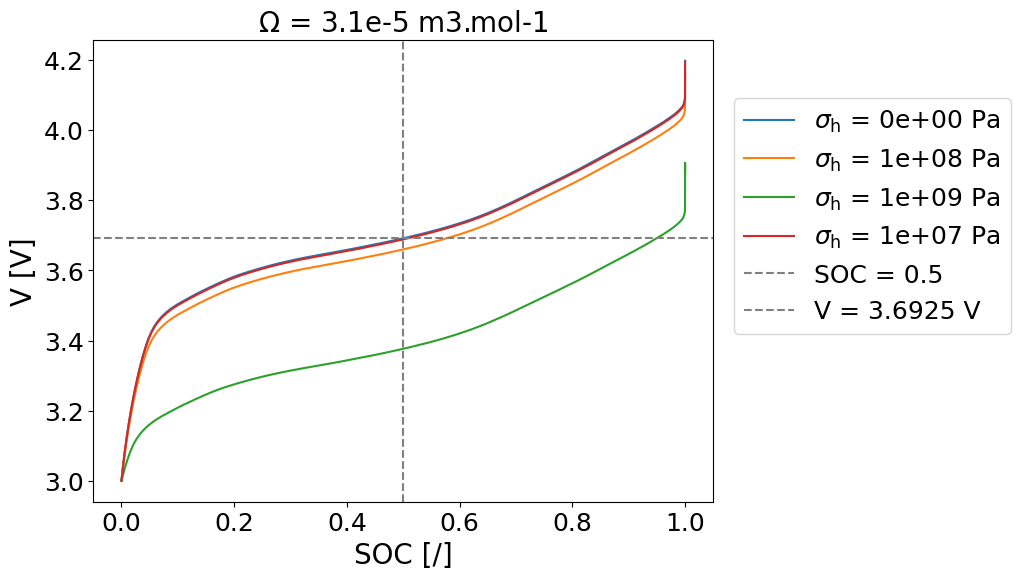

In [45]:
Q_discharged = sol_DFN["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD = (Q_discharged / Q_max)
SOC = 1 - DOD

Q_discharged = sol_DFN_1["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD_1 = (Q_discharged / Q_max)
SOC_1 = 1 - DOD_1

Q_discharged = sol_DFN_2["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD_2 = (Q_discharged / Q_max)
SOC_2 = 1 - DOD_2

Q_discharged = sol_DFN_1e7["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD_1e7 = (Q_discharged / Q_max)
SOC_1e7 = 1 - DOD_1e7

# x_val = [DOD, 
#          DOD_1,
#         DOD_2
#          ]

x_val = [SOC,
         SOC_1,
        SOC_2,
        SOC_1e7
         ]

y_val = [sol_DFN["Voltage [V]"].data, 
         sol_DFN_1["Voltage [V]"].data,
        sol_DFN_2["Voltage [V]"].data,
        sol_DFN_1e7["Voltage [V]"].data
         ]

plt.figure(figsize=fig_size)
for i in range(len(x_val)):
    plt.plot(x_val[i], y_val[i], label=[fr"$\sigma_{{\mathrm{{h}}}}$ = {param0['Hydrostatic stress [Pa]']:.0e} Pa", 
                                        fr"$\sigma_{{\mathrm{{h}}}}$ = {param1['Hydrostatic stress [Pa]']:.0e} Pa", 
                                        fr"$\sigma_{{\mathrm{{h}}}}$ = {param2['Hydrostatic stress [Pa]']:.0e} Pa", 
                                        fr"$\sigma_{{\mathrm{{h}}}}$ = {param1e7['Hydrostatic stress [Pa]']:.0e} Pa",
                                        ][i]
                                        )
# draw line at soc = 0.5
plt.axvline(x=0.5, color='gray', linestyle='--', label='SOC = 0.5')

# draw line at 3.6925 V
plt.axhline(y=3.6925, color='gray', linestyle='--', label='V = 3.6925 V')
plt.xlabel("SOC [/]")
plt.ylabel("V [V]")
plt.legend(loc="upper right", bbox_to_anchor=(1.5, 0.9))
plt.title("$\Omega$ = 3.1e-5 m3.mol-1")


### $\sigma_h$ = 0 Pa

Pogledamo pri kateri napetosti neobremenjene celice je SOC = 50%.

In [31]:
# find soc value closest to 0.5
target_soc = 0.5
index = (np.abs(SOC - target_soc)).argmin() 
print(f"Closest SOC to {target_soc} is {SOC[index]:.4f} at index {index}.")
print(f"Corresponding Voltage: {sol_DFN['Voltage [V]'].entries[index]:.4f} V.")

Closest SOC to 0.5 is 0.5025 at index 225.
Corresponding Voltage: 3.6925 V.


Pogledamo pri katerem SOC so obremenjene celice za enako napetost.

In [32]:
# target voltage
target_voltage_1 = sol_DFN['Voltage [V]'].entries[index]
index_voltage_1 = (np.abs(sol_DFN_1["Voltage [V]"].entries - target_voltage_1 )).argmin()
target_soc_1 = SOC_1[index_voltage_1]

print(f"For hydrostatic stress of {param1['Hydrostatic stress [Pa]']:.0e} Pa and partial molar volume of {param1['Negative electrode partial molar volume [m3.mol-1]']:.1e} m3.mol-1:")
print(f"Corrected voltage: {sol_DFN_1['Voltage [V]'].entries[index_voltage_1]:.4f} V at index {index_voltage_1}.")
print(f"Corresponding SOC: {target_soc_1:.4f}.")

For hydrostatic stress of 1e+08 Pa and partial molar volume of 3.1e-05 m3.mol-1:
Corrected voltage: 3.6917 V at index 217.
Corresponding SOC: 0.5773.


In [33]:
# target voltage
target_voltage_2 = sol_DFN['Voltage [V]'].entries[index]
index_voltage_2 = (np.abs(sol_DFN_2["Voltage [V]"].entries - target_voltage_2 )).argmin()
target_soc_2 = SOC_2[index_voltage_2]

print(f"For hydrostatic stress of {param2['Hydrostatic stress [Pa]']:.0e} Pa and partial molar volume of {param2['Negative electrode partial molar volume [m3.mol-1]']:.1e} m3.mol-1:")
print(f"Corrected voltage: {sol_DFN_2['Voltage [V]'].entries[index_voltage_2]:.4f} V at index {index_voltage_2}.")
print(f"Corresponding SOC: {target_soc_2:.4f}.")

For hydrostatic stress of 1e+09 Pa and partial molar volume of 3.1e-05 m3.mol-1:
Corrected voltage: 3.6925 V at index 137.
Corresponding SOC: 0.9506.


In [46]:
# target voltage
target_voltage_1e7 = sol_DFN['Voltage [V]'].entries[index]
index_voltage_1e7 = (np.abs(sol_DFN_1e7["Voltage [V]"].entries - target_voltage_1e7 )).argmin()
target_soc_1e7 = SOC_1e7[index_voltage_1e7]

print(f"For hydrostatic stress of {param1e7['Hydrostatic stress [Pa]']:.0e} Pa and partial molar volume of {param1e7['Negative electrode partial molar volume [m3.mol-1]']:.1e} m3.mol-1:")
print(f"Corrected voltage: {sol_DFN_1e7['Voltage [V]'].entries[index_voltage_1e7]:.4f} V at index {index_voltage_1e7}.")
print(f"Corresponding SOC: {target_soc_1e7:.4f}.")

For hydrostatic stress of 1e+07 Pa and partial molar volume of 3.1e-05 m3.mol-1:
Corrected voltage: 3.6911 V at index 209.
Corresponding SOC: 0.5072.


Izračunamo EIS

In [34]:
hydrostatic_stress = 0 # Pa
initialSOC = 0.5

######################################
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):


    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                },
                                        )

    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param.update(
        {"Negative electrode partial molar volume [m3.mol-1]": 3.1e-5},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN.solve(t_eval=t, initial_soc=initialSOC)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

   
    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z = np.array(Z)

#########################################

# rename variables
Z_0Pa_soc50_Omg1e5 = []
Z_0Pa_soc50_Omg1e5 = Z
initialSOC0_Omg1e5 = initialSOC
hydrostatic_stress0 = hydrostatic_stress

In [35]:
# save results
sol_DFN.save("sol_0Pa_soc50_Omg1e5.pkl")

# save to txt
np.save("Z_0Pa_soc50_Omg1e5", Z_0Pa_soc50_Omg1e5)
np.savetxt("Z_0Pa_soc50_Omg1e5.txt", Z_0Pa_soc50_Omg1e5)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

### $\sigma_h$ = 1e8 Pa

In [36]:
hydrostatic_stress = 1e8 # Pa
initialSOC = target_soc_1

#####################################
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):


    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                },
                                        )

    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param.update(
        {"Negative electrode partial molar volume [m3.mol-1]": 3.1e-5},
        check_already_exists=False
        )
    
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN.solve(t_eval=t, initial_soc=initialSOC)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

   
    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z = np.array(Z)

############################
# rename variables
Z_1e8Pa_soc50_Omg1e5 = []
Z_1e8Pa_soc50_Omg1e5 = Z
initialSOC1_Omg1e5 = initialSOC
hydrostatic_stress1 = hydrostatic_stress

In [37]:
# save results
sol_DFN.save("sol_1e8Pa_soc50_Omg1e5.pkl")

# save to txt
np.save("Z_1e8Pa_soc50_Omg1e5", Z_1e8Pa_soc50_Omg1e5)
np.savetxt("Z_1e8Pa_soc50_Omg1e5.txt", Z_1e8Pa_soc50_Omg1e5)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

### $\sigma_h$ = 1e9 Pa

In [38]:
hydrostatic_stress = 1e9 # Pa
initialSOC = target_soc_2

######################################
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):


    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                },
                                        )

    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param.update(
        {"Negative electrode partial molar volume [m3.mol-1]": 3.1e-5},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN.solve(t_eval=t, initial_soc=initialSOC)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

   
    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z = np.array(Z)

#########################################
# rename variables
Z_1e9Pa_soc50_Omg1e5 = []
Z_1e9Pa_soc50_Omg1e5 = Z
initialSOC2_Omg1e5 = initialSOC
hydrostatic_stress2 = hydrostatic_stress

In [39]:
# save results
sol_DFN.save("sol_1e9Pa_soc50_Omg1e5.pkl")

# save to txt
np.save("Z_1e9Pa_soc50_Omg1e5", Z_1e9Pa_soc50_Omg1e5)
np.savetxt("Z_1e9Pa_soc50_Omg1e5.txt", Z_1e9Pa_soc50_Omg1e5)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

### $\sigma_h$ = 1e7 Pa

In [47]:
hydrostatic_stress = 1e7 # Pa
initialSOC = target_soc_1e7

######################################
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):


    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                },
                                        )

    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param.update(
        {"Negative electrode partial molar volume [m3.mol-1]": 3.1e-5},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN.solve(t_eval=t, initial_soc=initialSOC)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

   
    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z = np.array(Z)

#########################################
# rename variables
Z_1e7Pa_soc50_Omg1e5 = []
Z_1e7Pa_soc50_Omg1e5 = Z
initialSOC_1e7_Omg1e5 = initialSOC
hydrostatic_stress_1e7 = hydrostatic_stress

In [48]:
# save results
sol_DFN.save("sol_1e7Pa_soc50_Omg1e5.pkl")

# save to txt
np.save("Z_1e7Pa_soc50_Omg1e5", Z_1e7Pa_soc50_Omg1e5)
np.savetxt("Z_1e7Pa_soc50_Omg1e5.txt", Z_1e7Pa_soc50_Omg1e5)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

### Vsi rezultati

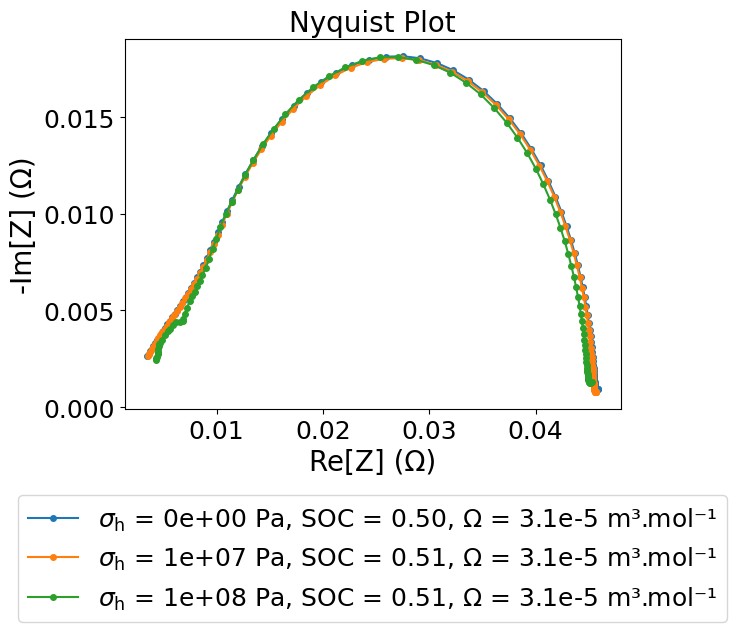

In [56]:
# Z_0Pa_soc50_Omg1e5 = np.load("Z_0Pa_soc50_Omg1e5.npy")
# Z_1e8Pa_soc50_Omg1e5 = np.load("Z_1e8Pa_soc50_Omg1e5.npy")
# Z_1e9Pa_soc50_Omg1e5 = np.load("Z_1e9Pa_soc50_Omg1e5.npy")

plt.plot(Z_0Pa_soc50_Omg1e5[:, 1], -Z_0Pa_soc50_Omg1e5[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress0:.0e} Pa, SOC = {initialSOC0:.2f}, $\Omega$ = 3.1e-5 m³.mol⁻¹")

plt.plot(Z_1e7Pa_soc50_Omg1e5[:, 1], -Z_1e7Pa_soc50_Omg1e5[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress_1e7:.0e} Pa, SOC = {initialSOC_1e7_Omg1e5:.2f}, $\Omega$ = 3.1e-5 m³.mol⁻¹")


plt.plot(Z_1e8Pa_soc50_Omg1e5[:, 1], -Z_1e8Pa_soc50_Omg1e5[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress1:.0e} Pa, SOC = {initialSOC1:.2f}, $\Omega$ = 3.1e-5 m³.mol⁻¹")

# plt.plot(Z_1e9Pa_soc50_Omg1e5[:, 1], -Z_1e9Pa_soc50_Omg1e5[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
#         label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress2:.0e} Pa, SOC = {initialSOC2:.2f}, $\Omega$ = 3.1e-5 m³.mol⁻¹")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))
plt.show()

Preverimo, če so enake napetosti

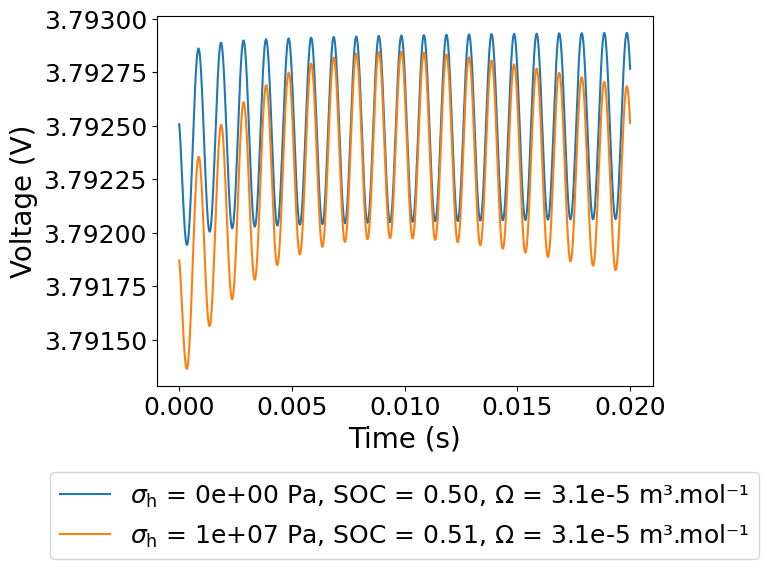

In [54]:
sol_0Pa_Omg1e5 = pybamm.load("sol_0Pa_soc50_Omg1e5.pkl")
sol_1e7Pa_Omg1e5 = pybamm.load("sol_1e7Pa_soc50_Omg1e5.pkl")
sol_1e8Pa_Omg1e5 = pybamm.load("sol_1e8Pa_soc50_Omg1e5.pkl")
sol_1e9Pa_Omg1e5 = pybamm.load("sol_1e9Pa_soc50_Omg1e5.pkl")

plt.plot(sol_0Pa_Omg1e5["Time [s]"].entries, sol_0Pa_Omg1e5["Voltage [V]"].entries, label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress0:.0e} Pa, SOC = {initialSOC0:.2f}, $\Omega$ = 3.1e-5 m³.mol⁻¹")
plt.plot(sol_1e7Pa_Omg1e5["Time [s]"].entries, sol_1e7Pa_Omg1e5["Voltage [V]"].entries, label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress_1e7:.0e} Pa, SOC = {initialSOC_1e7_Omg1e5:.2f}, $\Omega$ = 3.1e-5 m³.mol⁻¹")
# plt.plot(sol_1e8Pa_Omg1e5["Time [s]"].entries, sol_1e8Pa_Omg1e5["Voltage [V]"].entries, label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress1:.0e} Pa, SOC = {initialSOC1:.2f}, $\Omega$ = 3.1e-5 m³.mol⁻¹")
# plt.plot(sol_1e9Pa_Omg1e5["Time [s]"].entries, sol_1e9Pa_Omg1e5["Voltage [V]"].entries, label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress2:.0e} Pa, SOC = {initialSOC2:.2f}, $\Omega$ = 3.1e-5 m³.mol⁻¹")   

plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))
plt.show()

## SOC = 50 %, $\Omega$ = 3.1e-4 (100x)

In [2]:
model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                },
                                        )
param0 = pybamm.ParameterValues("Ai2020") 
param0.update(
    {"Hydrostatic stress [Pa]": 0},
    check_already_exists=False  
)
param0.update(
    {"Negative electrode partial molar volume [m3.mol-1]": 3.1e-4},
    check_already_exists=False  
)


param1 = pybamm.ParameterValues("Ai2020") 
param1.update(
    {"Hydrostatic stress [Pa]": 1e6},
    check_already_exists=False  
)
param1.update(
    {"Negative electrode partial molar volume [m3.mol-1]": 3.1e-4},
    check_already_exists=False  
)


param2 = pybamm.ParameterValues("Ai2020") 
param2.update(
    {"Hydrostatic stress [Pa]": 1e7},
    check_already_exists=False  
)
param2.update(
    {"Negative electrode partial molar volume [m3.mol-1]": 3.1e-4},
    check_already_exists=False  
)



var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
solver = pybamm.IDAKLUSolver()  



sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param0, var_pts=var_pts, solver=solver, experiment=experiment 
                              )
sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param1, var_pts=var_pts, solver=solver, experiment=experiment 
                              )
sim_DFN_2 = pybamm.Simulation(model= model, parameter_values=param2, var_pts=var_pts, solver=solver,experiment=experiment 
                              )


######################
t_eval = [0, 3600]
# t_eval = np.linspace(0, 0.3, 1000)  
######################

start = time.time()
sol_DFN = sim_DFN_0.solve(t_eval=t_eval, initial_soc=1)
end = time.time()
print(f"Simulacija DFN_0 zaključena v {end - start:.2f} s.")

start = time.time()
sol_DFN_1 = sim_DFN_1.solve(t_eval=t_eval, initial_soc=1)
end = time.time()
print(f"Simulacija DFN_1 zaključena v {end - start:.2f} s.")

start = time.time()
sol_DFN_2 = sim_DFN_2.solve(t_eval=t_eval, initial_soc=1)
end = time.time()
print(f"Simulacija DFN_2 zaključena v {end - start:.2f} s.")


2025-11-03 09:27:58.827 - [WARNING] simulation.solve(557): Ignoring t_eval as solution times are specified by the experiment


Simulacija DFN_0 zaključena v 3.31 s.


2025-11-03 09:28:01.948 - [WARNING] simulation.solve(557): Ignoring t_eval as solution times are specified by the experiment


Simulacija DFN_1 zaključena v 2.84 s.


2025-11-03 09:28:04.247 - [WARNING] simulation.solve(557): Ignoring t_eval as solution times are specified by the experiment


Simulacija DFN_2 zaključena v 2.18 s.


Text(0.5, 1.0, '$\\Omega$ = 3.1e-4 m3.mol-1')

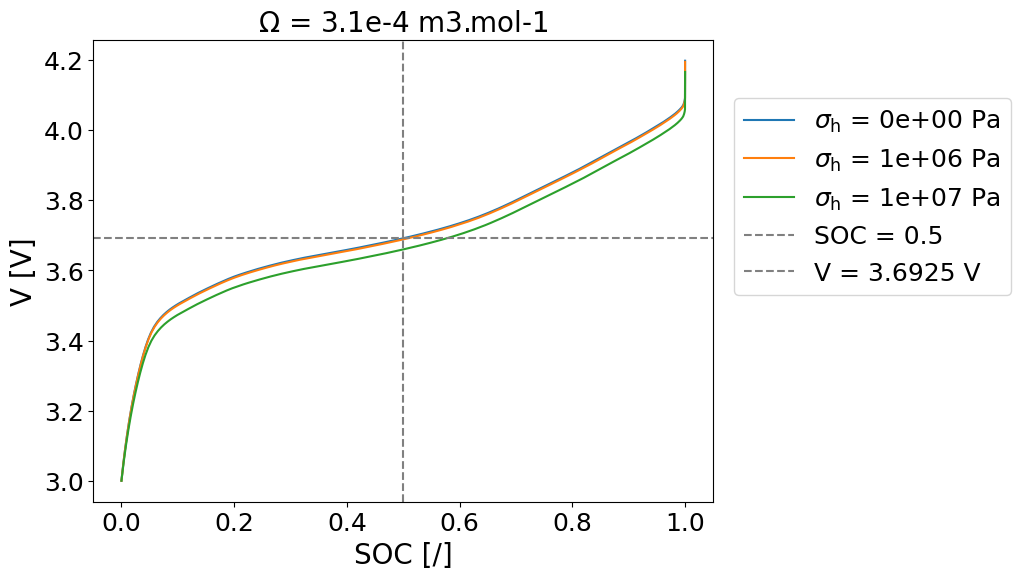

In [3]:
Q_discharged = sol_DFN["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD = (Q_discharged / Q_max)
SOC = 1 - DOD

Q_discharged = sol_DFN_1["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD_1 = (Q_discharged / Q_max)
SOC_1 = 1 - DOD_1

Q_discharged = sol_DFN_2["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD_2 = (Q_discharged / Q_max)
SOC_2 = 1 - DOD_2


# x_val = [DOD, 
#          DOD_1,
#         DOD_2
#          ]

x_val = [SOC,
         SOC_1,
        SOC_2,

         ]

y_val = [sol_DFN["Voltage [V]"].data, 
         sol_DFN_1["Voltage [V]"].data,
        sol_DFN_2["Voltage [V]"].data
         ]

plt.figure(figsize=fig_size)
for i in range(len(x_val)):
    plt.plot(x_val[i], y_val[i], label=[fr"$\sigma_{{\mathrm{{h}}}}$ = {param0['Hydrostatic stress [Pa]']:.0e} Pa", 
                                        fr"$\sigma_{{\mathrm{{h}}}}$ = {param1['Hydrostatic stress [Pa]']:.0e} Pa", 
                                        fr"$\sigma_{{\mathrm{{h}}}}$ = {param2['Hydrostatic stress [Pa]']:.0e} Pa", 
                                        ][i]
                                        )
# draw line at soc = 0.5
plt.axvline(x=0.5, color='gray', linestyle='--', label='SOC = 0.5')

# draw line at 3.6925 V
plt.axhline(y=3.6925, color='gray', linestyle='--', label='V = 3.6925 V')
plt.xlabel("SOC [/]")
plt.ylabel("V [V]")
plt.legend(loc="upper right", bbox_to_anchor=(1.5, 0.9))
plt.title("$\Omega$ = 3.1e-4 m3.mol-1")


### $\sigma_h$ = 0 Pa

Pogledamo pri kateri napetosti neobremenjene celice je SOC = 50%.

In [4]:
# find soc value closest to 0.5
target_soc = 0.5
index = (np.abs(SOC - target_soc)).argmin() 
print(f"Closest SOC to {target_soc} is {SOC[index]:.4f} at index {index}.")
print(f"Corresponding Voltage: {sol_DFN['Voltage [V]'].entries[index]:.4f} V.")

Closest SOC to 0.5 is 0.5025 at index 225.
Corresponding Voltage: 3.6925 V.


Pogledamo pri katerem SOC so obremenjene celice za enako napetost.

In [5]:
# target voltage
target_voltage_1 = sol_DFN['Voltage [V]'].entries[index]
index_voltage_1 = (np.abs(sol_DFN_1["Voltage [V]"].entries - target_voltage_1 )).argmin()
target_soc_1 = SOC_1[index_voltage_1]

print(f"For hydrostatic stress of {param1['Hydrostatic stress [Pa]']:.0e} Pa and partial molar volume of {param1['Negative electrode partial molar volume [m3.mol-1]']:.1e} m3.mol-1:")
print(f"Corrected voltage: {sol_DFN_1['Voltage [V]'].entries[index_voltage_1]:.4f} V at index {index_voltage_1}.")
print(f"Corresponding SOC: {target_soc_1:.4f}.")

For hydrostatic stress of 1e+06 Pa and partial molar volume of 3.1e-04 m3.mol-1:
Corrected voltage: 3.6911 V at index 209.
Corresponding SOC: 0.5072.


In [6]:
# target voltage
target_voltage_2 = sol_DFN['Voltage [V]'].entries[index]
index_voltage_2 = (np.abs(sol_DFN_2["Voltage [V]"].entries - target_voltage_2 )).argmin()
target_soc_2 = SOC_2[index_voltage_2]

print(f"For hydrostatic stress of {param2['Hydrostatic stress [Pa]']:.0e} Pa and partial molar volume of {param2['Negative electrode partial molar volume [m3.mol-1]']:.1e} m3.mol-1:")
print(f"Corrected voltage: {sol_DFN_2['Voltage [V]'].entries[index_voltage_2]:.4f} V at index {index_voltage_2}.")
print(f"Corresponding SOC: {target_soc_2:.4f}.")

For hydrostatic stress of 1e+07 Pa and partial molar volume of 3.1e-04 m3.mol-1:
Corrected voltage: 3.6917 V at index 217.
Corresponding SOC: 0.5773.


Izračunamo EIS

In [7]:
hydrostatic_stress = 0 # Pa
initialSOC = 0.5

######################################
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):


    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                },
                                        )

    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param.update(
        {"Negative electrode partial molar volume [m3.mol-1]": 3.1e-4},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN.solve(t_eval=t, initial_soc=initialSOC)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

   
    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z = np.array(Z)

#########################################

# rename variables
Z_0Pa_soc50_Omg1e4 = []
Z_0Pa_soc50_Omg1e4 = Z
initialSOC0 = initialSOC
hydrostatic_stress0 = hydrostatic_stress

In [8]:
# save results
sol_DFN.save("sol_0Pa_soc50_Omg1e4.pkl")

# save to txt
np.save("Z_0Pa_soc50_Omg1e4", Z_0Pa_soc50_Omg1e4)
np.savetxt("Z_0Pa_soc50_Omg1e4.txt", Z_0Pa_soc50_Omg1e4)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

### $\sigma_h$ = 1e6 Pa

In [63]:
hydrostatic_stress = 1e6 # Pa
initialSOC = target_soc_1

#####################################
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):


    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                },
                                        )

    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param.update(
        {"Negative electrode partial molar volume [m3.mol-1]": 3.1e-4},
        check_already_exists=False
        )
    
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN.solve(t_eval=t, initial_soc=initialSOC)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

   
    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z = np.array(Z)

############################
# rename variables
Z_1e6Pa_soc50_Omg1e4 = []
Z_1e6Pa_soc50_Omg1e4 = Z
initialSOC1 = initialSOC
hydrostatic_stress1 = hydrostatic_stress

In [64]:
# save results
sol_DFN.save("sol_1e6Pa_soc50_Omg1e4.pkl")

# save to txt
np.save("Z_1e6Pa_soc50_Omg1e4", Z_1e6Pa_soc50_Omg1e4)
np.savetxt("Z_1e6Pa_soc50_Omg1e4.txt", Z_1e6Pa_soc50_Omg1e4)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

### $\sigma_h$ = 1e7 Pa

In [65]:
hydrostatic_stress = 1e7 # Pa
initialSOC = target_soc_2

######################################
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):


    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                },
                                        )

    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param.update(
        {"Negative electrode partial molar volume [m3.mol-1]": 3.1e-4},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN.solve(t_eval=t, initial_soc=initialSOC)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

   
    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z = np.array(Z)

#########################################
# rename variables
Z_1e7Pa_soc50_Omg1e4 = []
Z_1e7Pa_soc50_Omg1e4 = Z
initialSOC2 = initialSOC
hydrostatic_stress2 = hydrostatic_stress

In [66]:
# save results
sol_DFN.save("sol_1e7Pa_soc50_Omg1e4.pkl")

# save to txt
np.save("Z_1e7Pa_soc50_Omg1e4", Z_1e7Pa_soc50_Omg1e4)
np.savetxt("Z_1e7Pa_soc50_Omg1e4.txt", Z_1e7Pa_soc50_Omg1e4)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

### Vsi rezultati

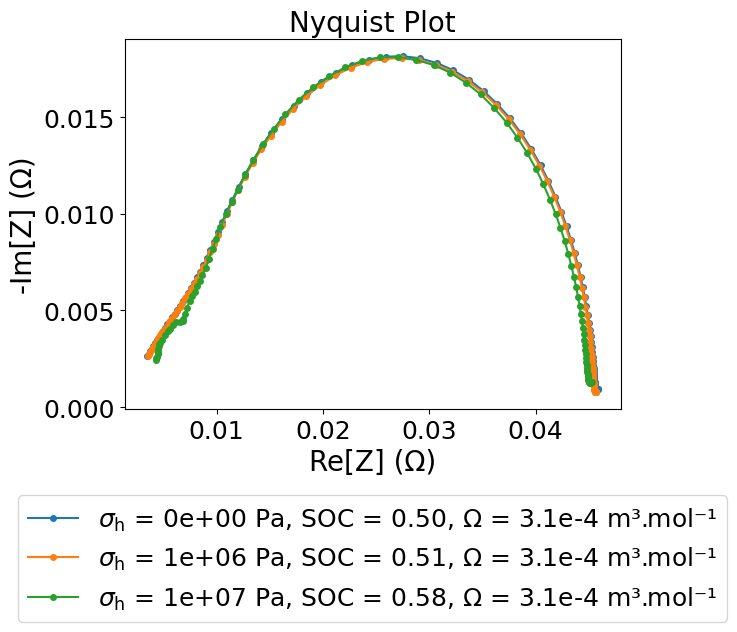

In [ ]:
Z_0Pa_soc50_Omg1e4 = np.load("Z_0Pa_soc50_Omg1e4.npy")
Z_1e6Pa_soc50_Omg1e4 = np.load("Z_1e6Pa_soc50_Omg1e4.npy")
Z_1e7Pa_soc50_Omg1e4 = np.load("Z_1e7Pa_soc50_Omg1e4.npy")

hydrostatic_stress1 = 1e6
hydrostatic_stress2 = 1e7

initialSOC1 = target_soc_1
initialSOC2 = target_soc_2

plt.plot(Z_0Pa_soc50_Omg1e4[:, 1], -Z_0Pa_soc50_Omg1e4[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress0:.0e} Pa, SOC = {initialSOC0:.2f}, $\Omega$ = 3.1e-4 m³.mol⁻¹")

plt.plot(Z_1e6Pa_soc50_Omg1e4[:, 1], -Z_1e6Pa_soc50_Omg1e4[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress1:.0e} Pa, SOC = {initialSOC1:.2f}, $\Omega$ = 3.1e-4 m³.mol⁻¹")

plt.plot(Z_1e7Pa_soc50_Omg1e4[:, 1], -Z_1e7Pa_soc50_Omg1e4[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress2:.0e} Pa, SOC = {initialSOC2:.2f}, $\Omega$ = 3.1e-4 m³.mol⁻¹")


# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))
plt.show()

Preverimo, če so enake napetosti

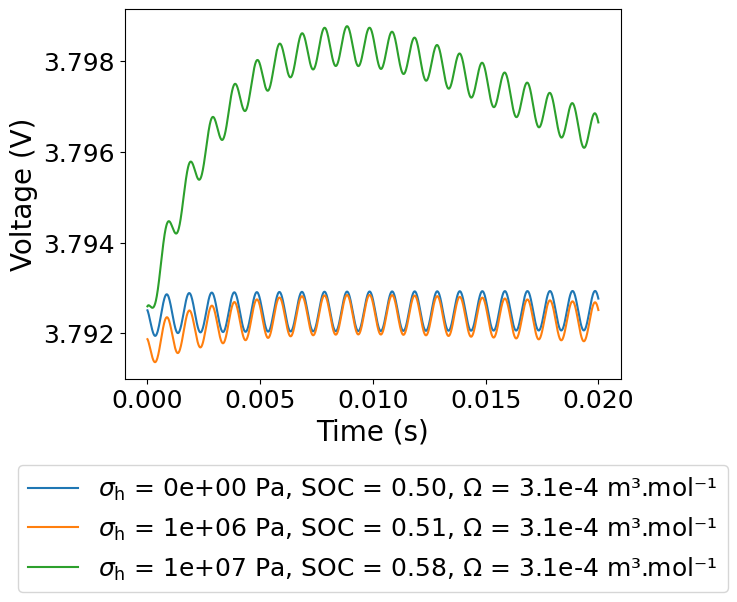

In [15]:
sol_0Pa_Omg1e4 = pybamm.load("sol_0Pa_soc50_Omg1e4.pkl")
sol_1e6Pa_Omg1e4 = pybamm.load("sol_1e6Pa_soc50_Omg1e4.pkl")
sol_1e7Pa_Omg1e4 = pybamm.load("sol_1e7Pa_soc50_Omg1e4.pkl")

plt.plot(sol_0Pa_Omg1e4["Time [s]"].entries, sol_0Pa_Omg1e4["Voltage [V]"].entries, label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress0:.0e} Pa, SOC = {initialSOC0:.2f}, $\Omega$ = 3.1e-4 m³.mol⁻¹")
plt.plot(sol_1e6Pa_Omg1e4["Time [s]"].entries, sol_1e6Pa_Omg1e4["Voltage [V]"].entries, label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress1:.0e} Pa, SOC = {initialSOC1:.2f}, $\Omega$ = 3.1e-4 m³.mol⁻¹")
plt.plot(sol_1e7Pa_Omg1e4["Time [s]"].entries, sol_1e7Pa_Omg1e4["Voltage [V]"].entries, label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress2:.0e} Pa, SOC = {initialSOC2:.2f}, $\Omega$ = 3.1e-4 m³.mol⁻¹")   

plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))
plt.show()

## SOC = 80 % 

In [21]:
model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                },
                                        )
param0 = pybamm.ParameterValues("Ai2020") 
param0.update(
    {"Hydrostatic stress [Pa]": 0},
    check_already_exists=False  
)


param1 = pybamm.ParameterValues("Ai2020") 
param1.update(
    {"Hydrostatic stress [Pa]": 1e8},
    check_already_exists=False  
)


param2 = pybamm.ParameterValues("Ai2020") 
param2.update(
    {"Hydrostatic stress [Pa]": 1e9},
    check_already_exists=False  
)


var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
solver = pybamm.IDAKLUSolver()  



sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param0, var_pts=var_pts, solver=solver, experiment=experiment 
                              )
sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param1, var_pts=var_pts, solver=solver, experiment=experiment 
                              )
sim_DFN_2 = pybamm.Simulation(model= model, parameter_values=param2, var_pts=var_pts, solver=solver,experiment=experiment 
                              )

######################
t_eval = [0, 3600]
# t_eval = np.linspace(0, 0.3, 1000)  
######################

start = time.time()
sol_DFN = sim_DFN_0.solve(t_eval=t_eval, initial_soc=1)
end = time.time()
print(f"Simulacija DFN_0 zaključena v {end - start:.2f} s.")

start = time.time()
sol_DFN_1 = sim_DFN_1.solve(t_eval=t_eval, initial_soc=1)
end = time.time()
print(f"Simulacija DFN_1 zaključena v {end - start:.2f} s.")

start = time.time()
sol_DFN_2 = sim_DFN_2.solve(t_eval=t_eval, initial_soc=1)
end = time.time()
print(f"Simulacija DFN_2 zaključena v {end - start:.2f} s.")

2025-11-10 12:24:57.489 - [WARNING] simulation.solve(557): Ignoring t_eval as solution times are specified by the experiment


Simulacija DFN_0 zaključena v 2.92 s.


2025-11-10 12:25:00.278 - [WARNING] simulation.solve(557): Ignoring t_eval as solution times are specified by the experiment


Simulacija DFN_1 zaključena v 2.53 s.


2025-11-10 12:25:02.572 - [WARNING] simulation.solve(557): Ignoring t_eval as solution times are specified by the experiment


Simulacija DFN_2 zaključena v 2.25 s.


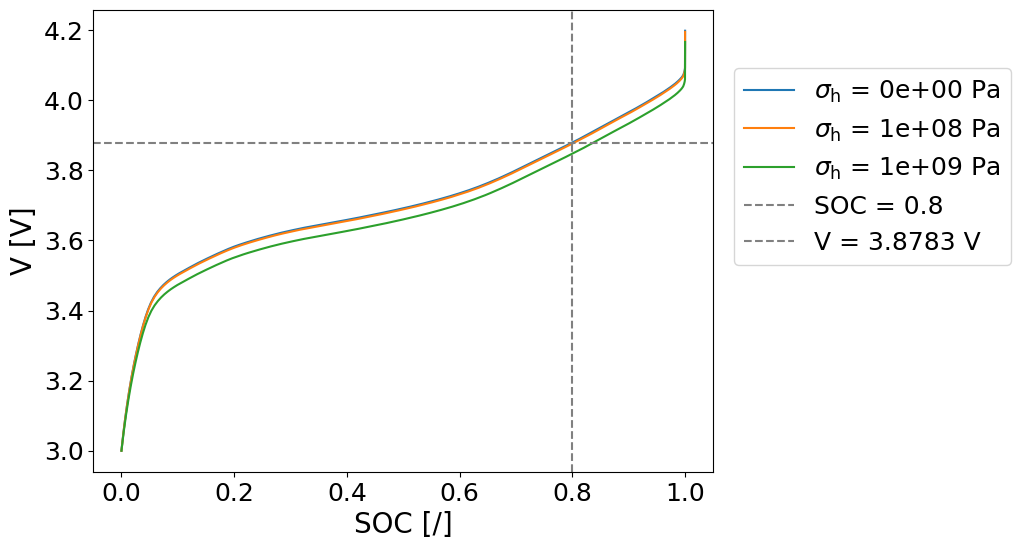

In [23]:
Q_discharged = sol_DFN["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD = (Q_discharged / Q_max)
SOC = 1 - DOD

Q_discharged = sol_DFN_1["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD_1 = (Q_discharged / Q_max)
SOC_1 = 1 - DOD_1

Q_discharged = sol_DFN_2["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD_2 = (Q_discharged / Q_max)
SOC_2 = 1 - DOD_2

# x_val = [DOD, 
#          DOD_1,
#         DOD_2
#          ]

x_val = [SOC,
         SOC_1,
        SOC_2
         ]

y_val = [sol_DFN["Voltage [V]"].data, 
         sol_DFN_1["Voltage [V]"].data,
        sol_DFN_2["Voltage [V]"].data
         ]

plt.figure(figsize=fig_size)
for i in range(len(x_val)):
    plt.plot(x_val[i], y_val[i], label=[fr"$\sigma_{{\mathrm{{h}}}}$ = {param0['Hydrostatic stress [Pa]']:.0e} Pa", 
                                        fr"$\sigma_{{\mathrm{{h}}}}$ = {param1['Hydrostatic stress [Pa]']:.0e} Pa", 
                                        fr"$\sigma_{{\mathrm{{h}}}}$ = {param2['Hydrostatic stress [Pa]']:.0e} Pa", 
                                        ][i]
                                        )
# draw line at soc = 0.8
plt.axvline(x=0.8, color='gray', linestyle='--', label='SOC = 0.8')

# draw line at 3.8783 V
plt.axhline(y=3.8783, color='gray', linestyle='--', label='V = 3.8783 V')

plt.xlabel("SOC [/]")
plt.ylabel("V [V]")
plt.legend(loc="upper right", bbox_to_anchor=(1.5, 0.9))

### $\sigma_h$ = 0 Pa

Pogledamo pri kateri napetosti neobremenjene celice je SOC = 50%.

In [4]:
# find soc value closest to 0.8
target_soc = 0.8
index = (np.abs(SOC - target_soc)).argmin() 
print(f"Closest SOC to {target_soc} is {SOC[index]:.4f} at index {index}.")
print(f"Corresponding Voltage: {sol_DFN['Voltage [V]'].entries[index]:.4f} V.")

Closest SOC to 0.8 is 0.7987 at index 187.
Corresponding Voltage: 3.8783 V.


Pogledamo pri katerem SOC so obremenjene celice za enako napetost.

In [5]:
# target voltage
target_voltage_1 = sol_DFN['Voltage [V]'].entries[index]
index_voltage_1 = (np.abs(sol_DFN_1["Voltage [V]"].entries - target_voltage_1 )).argmin()
target_soc_1 = SOC_1[index_voltage_1]

print(f"For hydrostatic stress of {param1['Hydrostatic stress [Pa]']:.0e} Pa and partial molar volume of {param1['Negative electrode partial molar volume [m3.mol-1]']:.1e} m3.mol-1:")
print(f"Corrected voltage: {sol_DFN_1['Voltage [V]'].entries[index_voltage_1]:.4f} V at index {index_voltage_1}.")
print(f"Corresponding SOC: {target_soc_1:.4f}.")

For hydrostatic stress of 1e+08 Pa and partial molar volume of 3.1e-06 m3.mol-1:
Corrected voltage: 3.8795 V at index 175.
Corresponding SOC: 0.8042.


In [6]:
# target voltage
target_voltage_2 = sol_DFN['Voltage [V]'].entries[index]
index_voltage_2 = (np.abs(sol_DFN_2["Voltage [V]"].entries - target_voltage_2 )).argmin()
target_soc_2 = SOC_2[index_voltage_2]

print(f"For hydrostatic stress of {param2['Hydrostatic stress [Pa]']:.0e} Pa and partial molar volume of {param2['Negative electrode partial molar volume [m3.mol-1]']:.1e} m3.mol-1:")
print(f"Corrected voltage: {sol_DFN_2['Voltage [V]'].entries[index_voltage_2]:.4f} V at index {index_voltage_2}.")
print(f"Corresponding SOC: {target_soc_2:.4f}.")

For hydrostatic stress of 1e+09 Pa and partial molar volume of 3.1e-06 m3.mol-1:
Corrected voltage: 3.8783 V at index 181.
Corresponding SOC: 0.8369.


Izračunamo EIS

In [8]:
hydrostatic_stress = 0 # Pa
initialSOC = 0.8

######################################
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):


    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                },
                                        )

    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN.solve(t_eval=t, initial_soc=initialSOC)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

   
    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z = np.array(Z)

#########################################

# rename variables
Z_0Pa_soc80 = []
Z_0Pa_soc80 = Z
initialSOC0 = initialSOC
hydrostatic_stress0 = hydrostatic_stress

In [9]:
# save results
sol_DFN.save("sol_0Pa_soc80.pkl")

# save to txt
np.save("Z_0Pa_soc80", Z_0Pa_soc80)
np.savetxt("Z_0Pa_soc80.txt", Z_0Pa_soc80)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

### $\sigma_h$ = 1e8 Pa

In [10]:
hydrostatic_stress = 1e8 # Pa
initialSOC = target_soc_1

#####################################
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):


    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                },
                                        )

    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN.solve(t_eval=t, initial_soc=initialSOC)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

   
    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z = np.array(Z)

############################
# rename variables
Z_1e8Pa_soc80 = []
Z_1e8Pa_soc80 = Z
initialSOC1 = initialSOC
hydrostatic_stress1 = hydrostatic_stress

In [11]:
# save results
sol_DFN.save("sol_1e8Pa_soc80.pkl")

# save to txt
np.save("Z_1e8Pa_soc80", Z_1e8Pa_soc80)
np.savetxt("Z_1e8Pa_soc80.txt", Z_1e8Pa_soc80)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

### $\sigma_h$ = 1e9 Pa

In [12]:
hydrostatic_stress = 1e9 # Pa
initialSOC = target_soc_2

######################################
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):


    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                },
                                        )

    param = pybamm.ParameterValues("Ai2020") 
    param.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN.solve(t_eval=t, initial_soc=initialSOC)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

   
    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z = np.array(Z)

#########################################
# rename variables
Z_1e9Pa_soc80 = []
Z_1e9Pa_soc80 = Z
initialSOC2 = initialSOC
hydrostatic_stress2 = hydrostatic_stress

In [13]:
# save results
sol_DFN.save("sol_1e9Pa_soc80.pkl")

# save to txt
np.save("Z_1e9Pa_soc80", Z_1e9Pa_soc80)
np.savetxt("Z_1e9Pa_soc80.txt", Z_1e9Pa_soc80)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

### Vsi rezultati

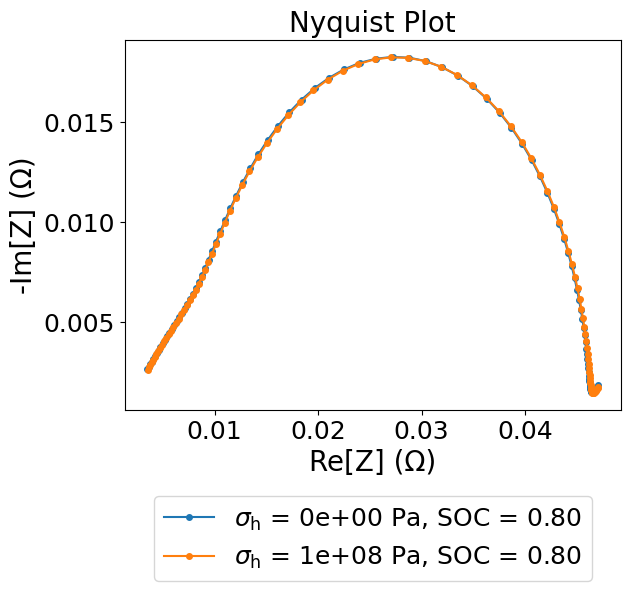

In [ ]:
# Z_0Pa_soc80 = np.load("Z_0Pa_soc80.npy")
# Z_1e8Pa_soc80 = np.load("Z_1e8Pa_soc80.npy")
# Z_1e9Pa_soc80 = np.load("Z_1e9Pa_soc80.npy")

plt.plot(Z_0Pa_soc80[:, 1], -Z_0Pa_soc80[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress0:.0e} Pa, SOC = {initialSOC0:.2f}")

plt.plot(Z_1e8Pa_soc80[:, 1], -Z_1e8Pa_soc80[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress1:.0e} Pa, SOC = {initialSOC1:.2f}")

plt.plot(Z_1e9Pa_soc80[:, 1], -Z_1e9Pa_soc80[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress2:.0e} Pa, SOC = {initialSOC2:.2f}")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))
plt.show()

Preverimo, če so enake napetosti

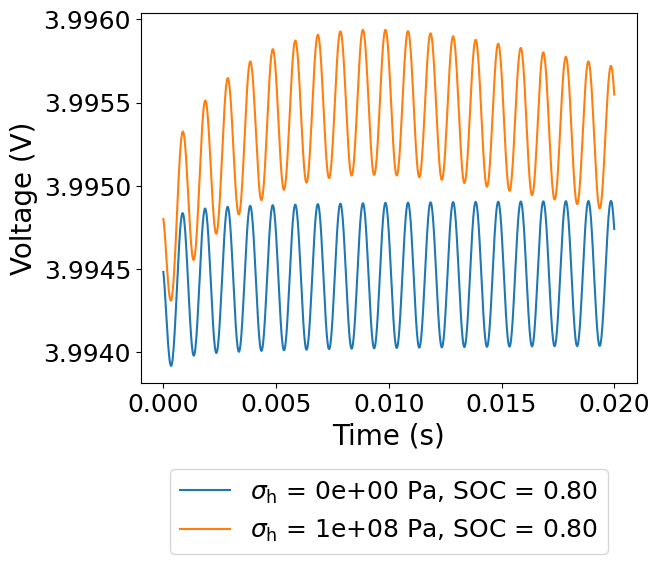

In [19]:
sol_0Pa = pybamm.load("sol_0Pa_soc80.pkl")
sol_1e8Pa = pybamm.load("sol_1e8Pa_soc80.pkl")
sol_1e9Pa = pybamm.load("sol_1e9Pa_soc80.pkl")

plt.plot(sol_0Pa["Time [s]"].entries, sol_0Pa["Voltage [V]"].entries, label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress0:.0e} Pa, SOC = {initialSOC0:.2f}")
plt.plot(sol_1e8Pa["Time [s]"].entries, sol_1e8Pa["Voltage [V]"].entries, label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress1:.0e} Pa, SOC = {initialSOC1:.2f}")
# plt.plot(sol_1e9Pa["Time [s]"].entries, sol_1e9Pa["Voltage [V]"].entries, label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress2:.0e} Pa, SOC = {initialSOC2:.2f}")   

plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))
plt.show()

# NMC + SiG: EIS pri konst. napetosti

In [1]:
# import
import pybamm
import pybammeis 
import numpy as np
import matplotlib.pyplot as plt
import time
from ipywidgets import interact, FloatSlider
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from scipy import interpolate
from scipy import optimize

# Shrani slike
save_fig = False 

# Shrani animacijo
save_ani = False

# Formatiranje grafov
# Nastavitev velikosti grafa (širina, višina v inch-ih)
fig_size = figsize=(8, 6)  

# Nastavitev velikosti pisave
plt.rcParams.update({
    'font.size': 20,           # Osnovna velikost pisave
    'axes.titlesize': 20,      # Velikost naslova grafa
    'axes.labelsize': 20,      # Velikost pisave na osi
    'xtick.labelsize': 18,     # Velikost številk na x osi
    'ytick.labelsize': 18,     # Velikost številk na y osi
    'legend.fontsize': 18,     # Velikost pisave v legendi
})

Moramo definirati $\Omega$ za katero pa ni podatkov na internetu. Trenutno je definirana enaka $\Omega$ kot pri Ai2020 za LCO+LiC6 baterijo, $\Omega$ = 3.1e-6 m3/mol.

In [25]:
model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                },
                                        )
param0 = pybamm.ParameterValues("Chen2020") 
param0.update(
    {"Hydrostatic stress [Pa]": 0,
     "Negative electrode partial molar volume [m3.mol-1]": 3.1e-6},
    check_already_exists=False ,
    
)


param1 = pybamm.ParameterValues("Chen2020") 
param1.update(
    {"Hydrostatic stress [Pa]": 1e8,
     "Negative electrode partial molar volume [m3.mol-1]": 3.1e-6},
    check_already_exists=False  
)


param2 = pybamm.ParameterValues("Chen2020") 
param2.update(
    {"Hydrostatic stress [Pa]": 1e9,
     "Negative electrode partial molar volume [m3.mol-1]": 3.1e-6},
    check_already_exists=False  
)


var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
solver = pybamm.IDAKLUSolver()  



sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param0, var_pts=var_pts, solver=solver, experiment=experiment 
                              )
sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param1, var_pts=var_pts, solver=solver, experiment=experiment 
                              )
sim_DFN_2 = pybamm.Simulation(model= model, parameter_values=param2, var_pts=var_pts, solver=solver,experiment=experiment 
                              )

######################
t_eval = [0, 3600]
# t_eval = np.linspace(0, 0.3, 1000)  
######################

start = time.time()
sol_DFN = sim_DFN_0.solve(t_eval=t_eval, initial_soc=1)
end = time.time()
print(f"Simulacija DFN_0 zaključena v {end - start:.2f} s.")

start = time.time()
sol_DFN_1 = sim_DFN_1.solve(t_eval=t_eval, initial_soc=1)
end = time.time()
print(f"Simulacija DFN_1 zaključena v {end - start:.2f} s.")

start = time.time()
sol_DFN_2 = sim_DFN_2.solve(t_eval=t_eval, initial_soc=1)
end = time.time()
print(f"Simulacija DFN_2 zaključena v {end - start:.2f} s.")

2025-11-07 12:49:01.462 - [WARNING] simulation.solve(557): Ignoring t_eval as solution times are specified by the experiment


Simulacija DFN_0 zaključena v 2.24 s.


2025-11-07 12:49:03.652 - [WARNING] simulation.solve(557): Ignoring t_eval as solution times are specified by the experiment


Simulacija DFN_1 zaključena v 2.65 s.


2025-11-07 12:49:06.538 - [WARNING] simulation.solve(557): Ignoring t_eval as solution times are specified by the experiment


Simulacija DFN_2 zaključena v 2.27 s.


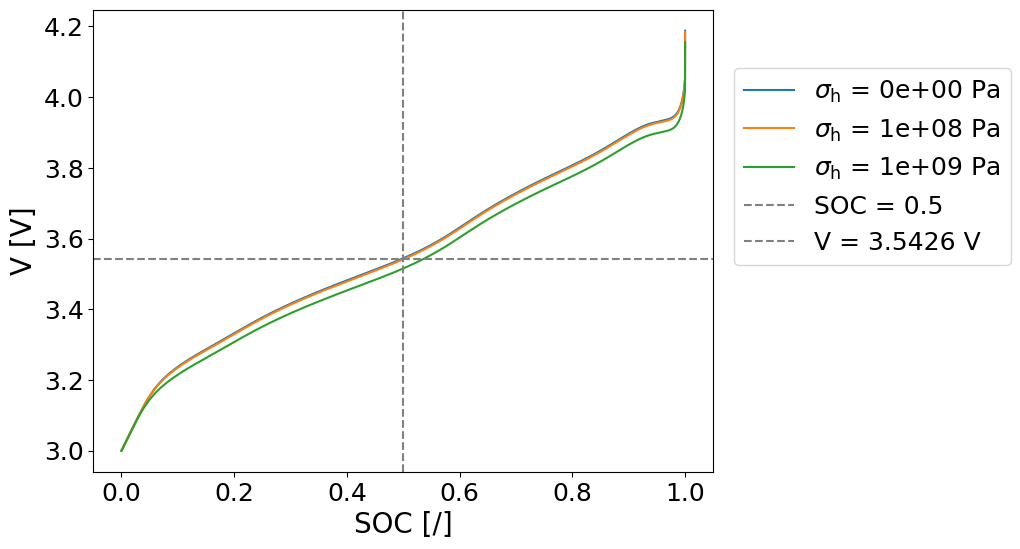

In [27]:
Q_discharged = sol_DFN["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD = (Q_discharged / Q_max)
SOC = 1 - DOD

Q_discharged = sol_DFN_1["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD_1 = (Q_discharged / Q_max)
SOC_1 = 1 - DOD_1

Q_discharged = sol_DFN_2["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD_2 = (Q_discharged / Q_max)
SOC_2 = 1 - DOD_2

# x_val = [DOD, 
#          DOD_1,
#         DOD_2
#          ]

x_val = [SOC,
         SOC_1,
        SOC_2
         ]

y_val = [sol_DFN["Voltage [V]"].data, 
         sol_DFN_1["Voltage [V]"].data,
        sol_DFN_2["Voltage [V]"].data
         ]

plt.figure(figsize=fig_size)
for i in range(len(x_val)):
    plt.plot(x_val[i], y_val[i], label=[fr"$\sigma_{{\mathrm{{h}}}}$ = {param0['Hydrostatic stress [Pa]']:.0e} Pa", 
                                        fr"$\sigma_{{\mathrm{{h}}}}$ = {param1['Hydrostatic stress [Pa]']:.0e} Pa", 
                                        fr"$\sigma_{{\mathrm{{h}}}}$ = {param2['Hydrostatic stress [Pa]']:.0e} Pa", 
                                        ][i]
                                        )
# draw line at soc = 0.5
plt.axvline(x=0.5, color='gray', linestyle='--', label='SOC = 0.5')

# draw line at 3.5426 V
plt.axhline(y=3.5426, color='gray', linestyle='--', label='V = 3.5426 V')

plt.xlabel("SOC [/]")
plt.ylabel("V [V]")
plt.legend(loc="upper right", bbox_to_anchor=(1.5, 0.9))

## SOC = 0.5

### $\sigma_h$ = 0 Pa

Pogledamo pri kateri napetosti neobremenjene celice je SOC = 50%.

In [11]:
# find soc value closest to 0.5
target_soc = 0.5
index = (np.abs(SOC - target_soc)).argmin() 
print(f"Closest SOC to {target_soc} is {SOC[index]:.4f} at index {index}.")
print(f"Corresponding Voltage: {sol_DFN['Voltage [V]'].entries[index]:.4f} V.")

Closest SOC to 0.5 is 0.4976 at index 197.
Corresponding Voltage: 3.5426 V.


Pogledamo pri katerem SOC so obremenjene celice za enako napetost.

In [12]:
# target voltage
target_voltage_1 = sol_DFN['Voltage [V]'].entries[index]
index_voltage_1 = (np.abs(sol_DFN_1["Voltage [V]"].entries - target_voltage_1 )).argmin()
target_soc_1 = SOC_1[index_voltage_1]

print(f"For hydrostatic stress of {param1['Hydrostatic stress [Pa]']:.0e} Pa and partial molar volume of {param1['Negative electrode partial molar volume [m3.mol-1]']:.1e} m3.mol-1:")
print(f"Corrected voltage: {sol_DFN_1['Voltage [V]'].entries[index_voltage_1]:.4f} V at index {index_voltage_1}.")
print(f"Corresponding SOC: {target_soc_1:.4f}.")

For hydrostatic stress of 1e+08 Pa and partial molar volume of 3.1e-06 m3.mol-1:
Corrected voltage: 3.5446 V at index 186.
Corresponding SOC: 0.5047.


In [13]:
# target voltage
target_voltage_2 = sol_DFN['Voltage [V]'].entries[index]
index_voltage_2 = (np.abs(sol_DFN_2["Voltage [V]"].entries - target_voltage_2 )).argmin()
target_soc_2 = SOC_2[index_voltage_2]

print(f"For hydrostatic stress of {param2['Hydrostatic stress [Pa]']:.0e} Pa and partial molar volume of {param2['Negative electrode partial molar volume [m3.mol-1]']:.1e} m3.mol-1:")
print(f"Corrected voltage: {sol_DFN_2['Voltage [V]'].entries[index_voltage_2]:.4f} V at index {index_voltage_2}.")
print(f"Corresponding SOC: {target_soc_2:.4f}.")

For hydrostatic stress of 1e+09 Pa and partial molar volume of 3.1e-06 m3.mol-1:
Corrected voltage: 3.5461 V at index 183.
Corresponding SOC: 0.5403.


Izračunamo EIS

In [14]:
hydrostatic_stress = 0 # Pa
initialSOC = 0.5
omega = 3.1e-6

######################################
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):


    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                },
                                        )

    param = pybamm.ParameterValues("Chen2020") 
    param.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress,
         "Negative electrode partial molar volume [m3.mol-1]": omega},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN.solve(t_eval=t, initial_soc=initialSOC)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

   
    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z = np.array(Z)

#########################################

# rename variables
Z_0Pa_soc50 = []
Z_0Pa_soc50 = Z
initialSOC0 = initialSOC
hydrostatic_stress0 = hydrostatic_stress

In [15]:
# save results
sol_DFN.save("NMC_sol_0Pa_soc50.pkl")

# save to txt
np.save("NMC_Z_0Pa_soc50", Z_0Pa_soc50)
np.savetxt("NMC_Z_0Pa_soc50.txt", Z_0Pa_soc50)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

### $\sigma_h$ = 1e8 Pa

In [16]:
hydrostatic_stress = 1e8 # Pa
initialSOC = target_soc_1
omega = 3.1e-6

#####################################
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):


    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                },
                                        )

    param = pybamm.ParameterValues("Chen2020") 
    param.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress,
         "Negative electrode partial molar volume [m3.mol-1]": omega},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN.solve(t_eval=t, initial_soc=initialSOC)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

   
    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z = np.array(Z)

############################
# rename variables
Z_1e8Pa_soc50 = []
Z_1e8Pa_soc50 = Z
initialSOC1 = initialSOC
hydrostatic_stress1 = hydrostatic_stress

In [17]:
# save results
sol_DFN.save("NMC_sol_1e8Pa_soc50.pkl")

# save to txt
np.save("NMC_Z_1e8Pa_soc50", Z_1e8Pa_soc50)
np.savetxt("NMC_Z_1e8Pa_soc50.txt", Z_1e8Pa_soc50)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

### $\sigma_h$ = 1e9 Pa

In [18]:
hydrostatic_stress = 1e9 # Pa
initialSOC = target_soc_2
omega = 3.1e-6

######################################
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):


    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                },
                                        )

    param = pybamm.ParameterValues("Chen2020") 
    param.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress,
         "Negative electrode partial molar volume [m3.mol-1]": omega},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN.solve(t_eval=t, initial_soc=initialSOC)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

   
    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z = np.array(Z)

#########################################
# rename variables
Z_1e9Pa_soc50 = []
Z_1e9Pa_soc50 = Z
initialSOC2 = initialSOC
hydrostatic_stress2 = hydrostatic_stress

In [19]:
# save results
sol_DFN.save("NMC_sol_1e9Pa_soc50.pkl")

# save to txt
np.save("NMC_Z_1e9Pa_soc50", Z_1e9Pa_soc50)
np.savetxt("NMC_Z_1e9Pa_soc50.txt", Z_1e9Pa_soc50)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

## Vsi rezultati

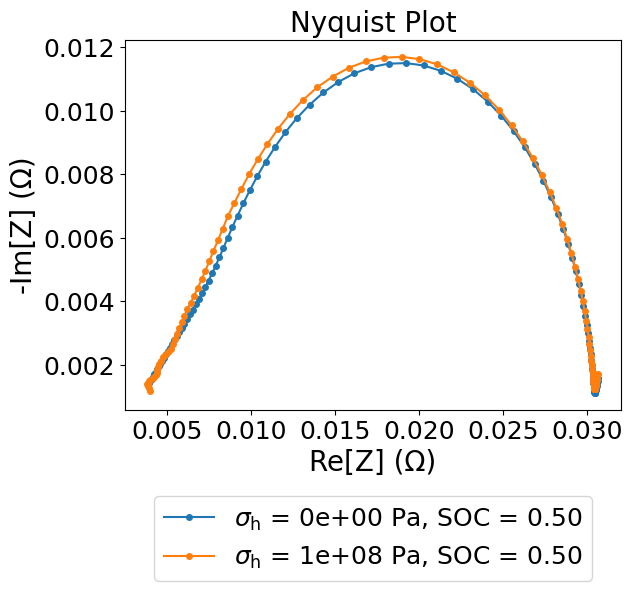

In [ ]:
# Z_0Pa_soc50 = np.load("Z_0Pa_soc50.npy")
# Z_1e8Pa_soc50 = np.load("Z_1e8Pa_soc50.npy")
# Z_1e9Pa_soc50 = np.load("Z_1e9Pa_soc50.npy")

plt.plot(Z_0Pa_soc50[:, 1], -Z_0Pa_soc50[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress0:.0e} Pa, SOC = {initialSOC0:.2f}")

plt.plot(Z_1e8Pa_soc50[:, 1], -Z_1e8Pa_soc50[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress1:.0e} Pa, SOC = {initialSOC1:.2f}")

plt.plot(Z_1e9Pa_soc50[:, 1], -Z_1e9Pa_soc50[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress2:.0e} Pa, SOC = {initialSOC2:.2f}")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))
plt.show()

Preverimo, če so enake napetosti

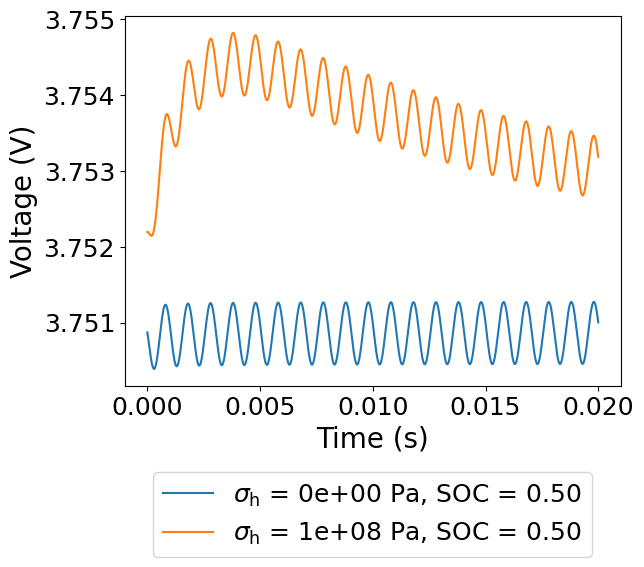

In [ ]:
sol_0Pa = pybamm.load("NMC_sol_0Pa_soc50.pkl")
sol_1e8Pa = pybamm.load("NMC_sol_1e8Pa_soc50.pkl")
sol_1e9Pa = pybamm.load("NMC_sol_1e9Pa_soc50.pkl")

plt.plot(sol_0Pa["Time [s]"].entries, sol_0Pa["Voltage [V]"].entries, label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress0:.0e} Pa, SOC = {initialSOC0:.2f}")
plt.plot(sol_1e8Pa["Time [s]"].entries, sol_1e8Pa["Voltage [V]"].entries, label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress1:.0e} Pa, SOC = {initialSOC1:.2f}")
plt.plot(sol_1e9Pa["Time [s]"].entries, sol_1e9Pa["Voltage [V]"].entries, label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress2:.0e} Pa, SOC = {initialSOC2:.2f}")   

plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))
plt.show()

# NMC + LiC6: EIS pri konst. napetosti

In [ ]:
# import
import pybamm
import pybammeis 
import numpy as np
import matplotlib.pyplot as plt
import time
from ipywidgets import interact, FloatSlider
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from scipy import interpolate
from scipy import optimize

# Shrani slike
save_fig = False 

# Shrani animacijo
save_ani = False

# Formatiranje grafov
# Nastavitev velikosti grafa (širina, višina v inch-ih)
fig_size = figsize=(8, 6)  

# Nastavitev velikosti pisave
plt.rcParams.update({
    'font.size': 20,           # Osnovna velikost pisave
    'axes.titlesize': 20,      # Velikost naslova grafa
    'axes.labelsize': 20,      # Velikost pisave na osi
    'xtick.labelsize': 18,     # Velikost številk na x osi
    'ytick.labelsize': 18,     # Velikost številk na y osi
    'legend.fontsize': 18,     # Velikost pisave v legendi
})

Moramo definirati $\Omega$ za katero pa ni podatkov na internetu. Trenutno je definirana enaka $\Omega$ kot pri Ai2020 za LCO+LiC6 baterijo, $\Omega$ = 3.1e-6 m3/mol.

In [31]:
model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                },
                                        )
param0 = pybamm.ParameterValues("Mohtat2020") 
param0.update(
    {"Hydrostatic stress [Pa]": 0,
     "Negative electrode partial molar volume [m3.mol-1]": 3.1e-6},
    check_already_exists=False ,
    
)


param1 = pybamm.ParameterValues("Mohtat2020") 
param1.update(
    {"Hydrostatic stress [Pa]": 1e8,
     "Negative electrode partial molar volume [m3.mol-1]": 3.1e-6},
    check_already_exists=False  
)


param2 = pybamm.ParameterValues("Mohtat2020") 
param2.update(
    {"Hydrostatic stress [Pa]": 1e9,
     "Negative electrode partial molar volume [m3.mol-1]": 3.1e-6},
    check_already_exists=False  
)


var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
solver = pybamm.IDAKLUSolver()  



sim_DFN_0 = pybamm.Simulation(model= model, parameter_values=param0, var_pts=var_pts, solver=solver, experiment=experiment 
                              )
sim_DFN_1 = pybamm.Simulation(model= model, parameter_values=param1, var_pts=var_pts, solver=solver, experiment=experiment 
                              )
sim_DFN_2 = pybamm.Simulation(model= model, parameter_values=param2, var_pts=var_pts, solver=solver,experiment=experiment 
                              )

######################
t_eval = [0, 3600]
# t_eval = np.linspace(0, 0.3, 1000)  
######################

start = time.time()
sol_DFN = sim_DFN_0.solve(t_eval=t_eval, initial_soc=1)
end = time.time()
print(f"Simulacija DFN_0 zaključena v {end - start:.2f} s.")

start = time.time()
sol_DFN_1 = sim_DFN_1.solve(t_eval=t_eval, initial_soc=1)
end = time.time()
print(f"Simulacija DFN_1 zaključena v {end - start:.2f} s.")

start = time.time()
sol_DFN_2 = sim_DFN_2.solve(t_eval=t_eval, initial_soc=1)
end = time.time()
print(f"Simulacija DFN_2 zaključena v {end - start:.2f} s.")

2025-11-07 13:06:50.569 - [WARNING] simulation.solve(557): Ignoring t_eval as solution times are specified by the experiment


Simulacija DFN_0 zaključena v 0.88 s.


2025-11-07 13:06:51.724 - [WARNING] simulation.solve(557): Ignoring t_eval as solution times are specified by the experiment


Simulacija DFN_1 zaključena v 1.10 s.


2025-11-07 13:06:52.533 - [WARNING] simulation.solve(557): Ignoring t_eval as solution times are specified by the experiment


Simulacija DFN_2 zaključena v 0.80 s.


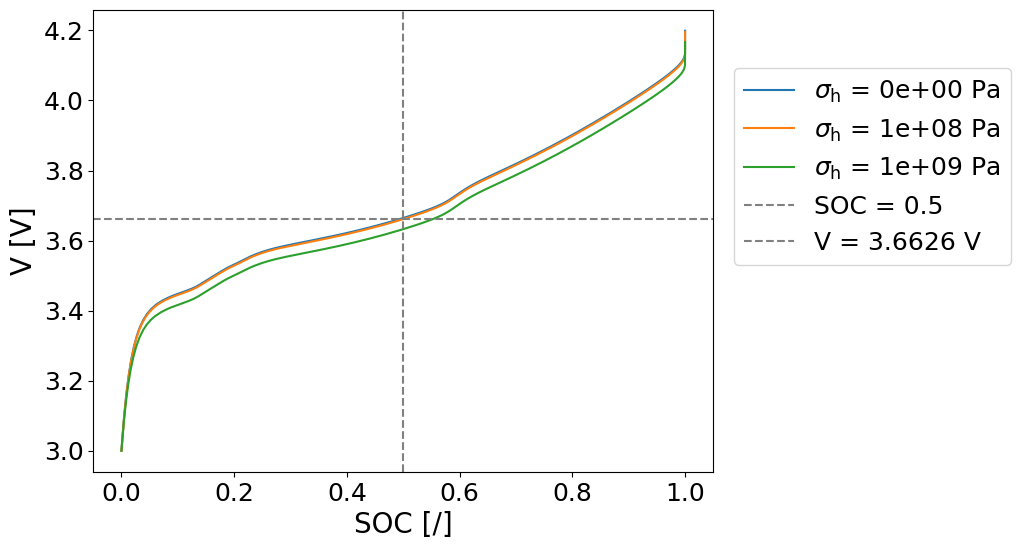

In [34]:
Q_discharged = sol_DFN["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD = (Q_discharged / Q_max)
SOC = 1 - DOD

Q_discharged = sol_DFN_1["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD_1 = (Q_discharged / Q_max)
SOC_1 = 1 - DOD_1

Q_discharged = sol_DFN_2["Discharge capacity [A.h]"].entries
Q_max = Q_discharged[-1] 
DOD_2 = (Q_discharged / Q_max)
SOC_2 = 1 - DOD_2

# x_val = [DOD, 
#          DOD_1,
#         DOD_2
#          ]

x_val = [SOC,
         SOC_1,
        SOC_2
         ]

y_val = [sol_DFN["Voltage [V]"].data, 
         sol_DFN_1["Voltage [V]"].data,
        sol_DFN_2["Voltage [V]"].data
         ]

plt.figure(figsize=fig_size)
for i in range(len(x_val)):
    plt.plot(x_val[i], y_val[i], label=[fr"$\sigma_{{\mathrm{{h}}}}$ = {param0['Hydrostatic stress [Pa]']:.0e} Pa", 
                                        fr"$\sigma_{{\mathrm{{h}}}}$ = {param1['Hydrostatic stress [Pa]']:.0e} Pa", 
                                        fr"$\sigma_{{\mathrm{{h}}}}$ = {param2['Hydrostatic stress [Pa]']:.0e} Pa", 
                                        ][i]
                                        )
# draw line at soc = 0.5
plt.axvline(x=0.5, color='gray', linestyle='--', label='SOC = 0.5')

# draw line at 3.6626 V
plt.axhline(y=3.6626, color='gray', linestyle='--', label='V = 3.6626 V')

plt.xlabel("SOC [/]")
plt.ylabel("V [V]")
plt.legend(loc="upper right", bbox_to_anchor=(1.5, 0.9))

## SOC = 0.5

### $\sigma_h$ = 0 Pa

Pogledamo pri kateri napetosti neobremenjene celice je SOC = 50%.

In [33]:
# find soc value closest to 0.5
target_soc = 0.5
index = (np.abs(SOC - target_soc)).argmin() 
print(f"Closest SOC to {target_soc} is {SOC[index]:.4f} at index {index}.")
print(f"Corresponding Voltage: {sol_DFN['Voltage [V]'].entries[index]:.4f} V.")

Closest SOC to 0.5 is 0.4963 at index 191.
Corresponding Voltage: 3.6626 V.


Pogledamo pri katerem SOC so obremenjene celice za enako napetost.

In [35]:
# target voltage
target_voltage_1 = sol_DFN['Voltage [V]'].entries[index]
index_voltage_1 = (np.abs(sol_DFN_1["Voltage [V]"].entries - target_voltage_1 )).argmin()
target_soc_1 = SOC_1[index_voltage_1]

print(f"For hydrostatic stress of {param1['Hydrostatic stress [Pa]']:.0e} Pa and partial molar volume of {param1['Negative electrode partial molar volume [m3.mol-1]']:.1e} m3.mol-1:")
print(f"Corrected voltage: {sol_DFN_1['Voltage [V]'].entries[index_voltage_1]:.4f} V at index {index_voltage_1}.")
print(f"Corresponding SOC: {target_soc_1:.4f}.")

For hydrostatic stress of 1e+08 Pa and partial molar volume of 3.1e-06 m3.mol-1:
Corrected voltage: 3.6611 V at index 178.
Corresponding SOC: 0.4997.


In [36]:
# target voltage
target_voltage_2 = sol_DFN['Voltage [V]'].entries[index]
index_voltage_2 = (np.abs(sol_DFN_2["Voltage [V]"].entries - target_voltage_2 )).argmin()
target_soc_2 = SOC_2[index_voltage_2]

print(f"For hydrostatic stress of {param2['Hydrostatic stress [Pa]']:.0e} Pa and partial molar volume of {param2['Negative electrode partial molar volume [m3.mol-1]']:.1e} m3.mol-1:")
print(f"Corrected voltage: {sol_DFN_2['Voltage [V]'].entries[index_voltage_2]:.4f} V at index {index_voltage_2}.")
print(f"Corresponding SOC: {target_soc_2:.4f}.")

For hydrostatic stress of 1e+09 Pa and partial molar volume of 3.1e-06 m3.mol-1:
Corrected voltage: 3.6617 V at index 172.
Corresponding SOC: 0.5531.


Izračunamo EIS

In [37]:
hydrostatic_stress = 0 # Pa
initialSOC = 0.5
omega = 3.1e-6

######################################
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):


    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                },
                                        )

    param = pybamm.ParameterValues("Mohtat2020") 
    param.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress,
         "Negative electrode partial molar volume [m3.mol-1]": omega},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN.solve(t_eval=t, initial_soc=initialSOC)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

   
    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z = np.array(Z)

#########################################

# rename variables
Z_0Pa_soc50 = []
Z_0Pa_soc50 = Z
initialSOC0 = initialSOC
hydrostatic_stress0 = hydrostatic_stress

In [38]:
# save results
sol_DFN.save("NMC_LiC6_sol_0Pa_soc50.pkl")

# save to txt
np.save("NMC_LiC6_Z_0Pa_soc50", Z_0Pa_soc50)
np.savetxt("NMC_LiC6_Z_0Pa_soc50.txt", Z_0Pa_soc50)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

### $\sigma_h$ = 1e8 Pa

In [39]:
hydrostatic_stress = 1e8 # Pa
initialSOC = target_soc_1
omega = 3.1e-6

#####################################
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):


    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                },
                                        )

    param = pybamm.ParameterValues("Mohtat2020") 
    param.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress,
         "Negative electrode partial molar volume [m3.mol-1]": omega},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN.solve(t_eval=t, initial_soc=initialSOC)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

   
    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z = np.array(Z)

############################
# rename variables
Z_1e8Pa_soc50 = []
Z_1e8Pa_soc50 = Z
initialSOC1 = initialSOC
hydrostatic_stress1 = hydrostatic_stress

In [40]:
# save results
sol_DFN.save("NMC_LiC6_sol_1e8Pa_soc50.pkl")

# save to txt
np.save("NMC_LiC6_Z_1e8Pa_soc50", Z_1e8Pa_soc50)
np.savetxt("NMC_LiC6_Z_1e8Pa_soc50.txt", Z_1e8Pa_soc50)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

### $\sigma_h$ = 1e9 Pa

In [41]:
hydrostatic_stress = 1e9 # Pa
initialSOC = target_soc_2
omega = 3.1e-6

######################################
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):


    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                },
                                        )

    param = pybamm.ParameterValues("Mohtat2020") 
    param.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress,
         "Negative electrode partial molar volume [m3.mol-1]": omega},
        check_already_exists=False  
    )
    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN.solve(t_eval=t, initial_soc=initialSOC)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

   
    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z = np.array(Z)

#########################################
# rename variables
Z_1e9Pa_soc50 = []
Z_1e9Pa_soc50 = Z
initialSOC2 = initialSOC
hydrostatic_stress2 = hydrostatic_stress

In [42]:
# save results
sol_DFN.save("NMC_LiC6_sol_1e9Pa_soc50.pkl")

# save to txt
np.save("NMC_LiC6_Z_1e9Pa_soc50", Z_1e9Pa_soc50)
np.savetxt("NMC_LiC6_Z_1e9Pa_soc50.txt", Z_1e9Pa_soc50)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

### Vsi rezultati

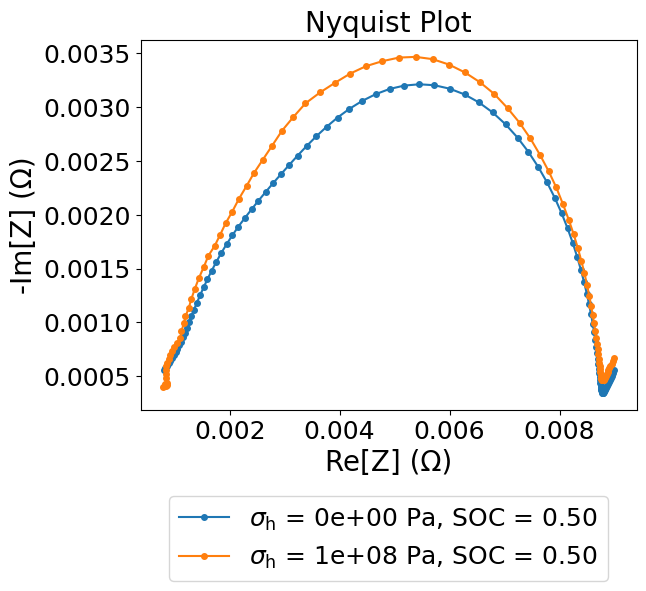

In [45]:
# Z_0Pa_soc50 = np.load("Z_0Pa_soc50.npy")
# Z_1e8Pa_soc50 = np.load("Z_1e8Pa_soc50.npy")
# Z_1e9Pa_soc50 = np.load("Z_1e9Pa_soc50.npy")

plt.plot(Z_0Pa_soc50[:, 1], -Z_0Pa_soc50[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress0:.0e} Pa, SOC = {initialSOC0:.2f}")

plt.plot(Z_1e8Pa_soc50[:, 1], -Z_1e8Pa_soc50[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
        label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress1:.0e} Pa, SOC = {initialSOC1:.2f}")

# plt.plot(Z_1e9Pa_soc50[:, 1], -Z_1e9Pa_soc50[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, 
#         label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress2:.0e} Pa, SOC = {initialSOC2:.2f}")

# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('Nyquist Plot')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))
plt.show()

Preverimo, če so enake napetosti

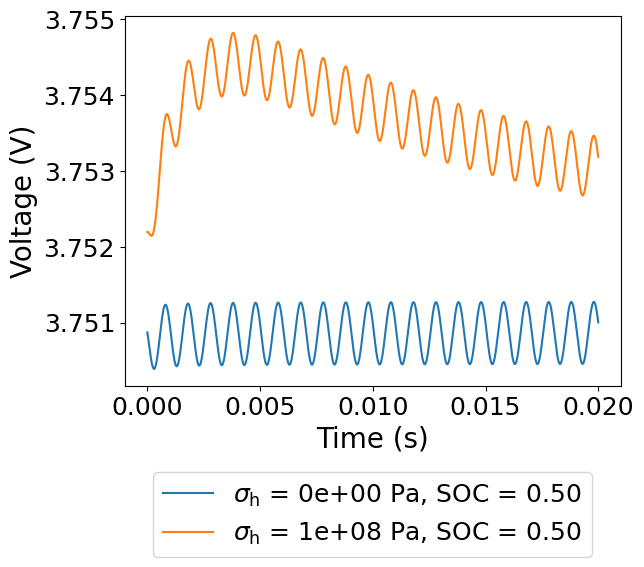

In [46]:
# sol_0Pa = pybamm.load("NMC_LiC6_sol_0Pa_soc50.pkl")
# sol_1e8Pa = pybamm.load("NMC_LiC6_sol_1e8Pa_soc50.pkl")
# sol_1e9Pa = pybamm.load("NMC_LiC6_sol_1e9Pa_soc50.pkl")

plt.plot(sol_0Pa["Time [s]"].entries, sol_0Pa["Voltage [V]"].entries, label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress0:.0e} Pa, SOC = {initialSOC0:.2f}")
plt.plot(sol_1e8Pa["Time [s]"].entries, sol_1e8Pa["Voltage [V]"].entries, label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress1:.0e} Pa, SOC = {initialSOC1:.2f}")
# plt.plot(sol_1e9Pa["Time [s]"].entries, sol_1e9Pa["Voltage [V]"].entries, label=fr"$\sigma_{{\mathrm{{h}}}}$ = {hydrostatic_stress2:.0e} Pa, SOC = {initialSOC2:.2f}")   

plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2))
plt.show()

## $\sigma_h$ = 0e9 Pa

#### SOC = 0.99

Računam pri SOC 99% ker pri SOC 100% da error: Events ['Maximum voltage [V]'] are non-positive at initial conditions.

In [29]:
hydrostatic_stress = 0 # Pa
initialSOC = 0.99
omega = 3.1e-6

######################################
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):


    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                },
                                        )

    param = pybamm.ParameterValues("Mohtat2020") 
    param.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress,
         "Negative electrode partial molar volume [m3.mol-1]": omega},
        check_already_exists=False  
    )

    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN.solve(t_eval=t, initial_soc=initialSOC)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

   
    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z = np.array(Z)

#########################################

# rename variables
Z_0Pa_soc99 = []
Z_0Pa_soc99 = Z
initialSOC99 = initialSOC
hydrostatic_stress0 = hydrostatic_stress

In [30]:
# save results
sol_DFN.save("NMC_LiC6_sol_0Pa_soc99.pkl")

# save to txt
np.save("NMC_LiC6_Z_0Pa_soc99", Z_0Pa_soc99)
np.savetxt("NMC_LiC6_Z_0Pa_soc99.txt", Z_0Pa_soc99)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#### SOC = 0.9

In [31]:
hydrostatic_stress = 0 # Pa
initialSOC = 0.9
omega = 3.1e-6

######################################
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):


    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                },
                                        )

    param = pybamm.ParameterValues("Mohtat2020") 
    param.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress,
         "Negative electrode partial molar volume [m3.mol-1]": omega},
        check_already_exists=False  
    )

    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN.solve(t_eval=t, initial_soc=initialSOC)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

   
    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z = np.array(Z)

#########################################

# rename variables
Z_0Pa_soc90 = []
Z_0Pa_soc90 = Z
initialSOC90 = initialSOC
hydrostatic_stress0 = hydrostatic_stress

In [32]:
# save results
sol_DFN.save("NMC_LiC6_sol_0Pa_soc90.pkl")

# save to txt
np.save("NMC_LiC6_Z_0Pa_soc90", Z_0Pa_soc90)
np.savetxt("NMC_LiC6_Z_0Pa_soc90.txt", Z_0Pa_soc90)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#### SOC = 0.8

In [33]:
hydrostatic_stress = 0 # Pa
initialSOC = 0.8
omega = 3.1e-6

######################################
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):


    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                },
                                        )

    param = pybamm.ParameterValues("Mohtat2020") 
    param.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress,
         "Negative electrode partial molar volume [m3.mol-1]": omega},
        check_already_exists=False  
    )

    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN.solve(t_eval=t, initial_soc=initialSOC)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

   
    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z = np.array(Z)

#########################################

# rename variables
Z_0Pa_soc80 = []
Z_0Pa_soc80 = Z
initialSOC80 = initialSOC
hydrostatic_stress0 = hydrostatic_stress

In [34]:
# save results
sol_DFN.save("NMC_LiC6_sol_0Pa_soc80.pkl")

# save to txt
np.save("NMC_LiC6_Z_0Pa_soc80", Z_0Pa_soc80)
np.savetxt("NMC_LiC6_Z_0Pa_soc80.txt", Z_0Pa_soc80)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#### SOC = 0.7

In [35]:
hydrostatic_stress = 0 # Pa
initialSOC = 0.7
omega = 3.1e-6

######################################
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):


    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                },
                                        )

    param = pybamm.ParameterValues("Mohtat2020") 
    param.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress,
         "Negative electrode partial molar volume [m3.mol-1]": omega},
        check_already_exists=False  
    )

    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN.solve(t_eval=t, initial_soc=initialSOC)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

   
    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z = np.array(Z)

#########################################

# rename variables
Z_0Pa_soc70 = []
Z_0Pa_soc70 = Z
initialSOC70 = initialSOC
hydrostatic_stress0 = hydrostatic_stress

In [36]:
# save results
sol_DFN.save("NMC_LiC6_sol_0Pa_soc70.pkl")

# save to txt
np.save("NMC_LiC6_Z_0Pa_soc70", Z_0Pa_soc70)
np.savetxt("NMC_LiC6_Z_0Pa_soc70.txt", Z_0Pa_soc70)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#### SOC = 0.6

In [37]:
hydrostatic_stress = 0 # Pa
initialSOC = 0.6
omega = 3.1e-6

######################################
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):


    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                },
                                        )

    param = pybamm.ParameterValues("Mohtat2020") 
    param.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress,
         "Negative electrode partial molar volume [m3.mol-1]": omega},
        check_already_exists=False  
    )

    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN.solve(t_eval=t, initial_soc=initialSOC)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

   
    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z = np.array(Z)

#########################################

# rename variables
Z_0Pa_soc60 = []
Z_0Pa_soc60 = Z
initialSOC60 = initialSOC
hydrostatic_stress0 = hydrostatic_stress

In [38]:
# save results
sol_DFN.save("NMC_LiC6_sol_0Pa_soc60.pkl")

# save to txt
np.save("NMC_LiC6_Z_0Pa_soc60", Z_0Pa_soc60)
np.savetxt("NMC_LiC6_Z_0Pa_soc60.txt", Z_0Pa_soc60)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#### SOC = 0.5

In [39]:
hydrostatic_stress = 0 # Pa
initialSOC = 0.50
omega = 3.1e-6

######################################
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):


    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                },
                                        )

    param = pybamm.ParameterValues("Mohtat2020") 
    param.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress,
         "Negative electrode partial molar volume [m3.mol-1]": omega},
        check_already_exists=False  
    )

    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN.solve(t_eval=t, initial_soc=initialSOC)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

   
    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z = np.array(Z)

#########################################

# rename variables
Z_0Pa_soc50 = []
Z_0Pa_soc50 = Z
initialSOC50 = initialSOC
hydrostatic_stress0 = hydrostatic_stress

In [40]:
# save results
sol_DFN.save("NMC_LiC6_sol_0Pa_soc50.pkl")

# save to txt
np.save("NMC_LiC6_Z_0Pa_soc50", Z_0Pa_soc50)
np.savetxt("NMC_LiC6_Z_0Pa_soc50.txt", Z_0Pa_soc50)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#### SOC = 0.4

In [41]:
hydrostatic_stress = 0 # Pa
initialSOC = 0.40
omega = 3.1e-6

######################################
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):


    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                },
                                        )

    param = pybamm.ParameterValues("Mohtat2020") 
    param.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress,
         "Negative electrode partial molar volume [m3.mol-1]": omega},
        check_already_exists=False  
    )

    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN.solve(t_eval=t, initial_soc=initialSOC)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

   
    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z = np.array(Z)

#########################################

# rename variables
Z_0Pa_soc40 = []
Z_0Pa_soc40 = Z
initialSOC40 = initialSOC
hydrostatic_stress0 = hydrostatic_stress

In [42]:
# save results
sol_DFN.save("NMC_LiC6_sol_0Pa_soc40.pkl")

# save to txt
np.save("NMC_LiC6_Z_0Pa_soc40", Z_0Pa_soc40)
np.savetxt("NMC_LiC6_Z_0Pa_soc40.txt", Z_0Pa_soc40)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#### SOC = 0.3

In [43]:
hydrostatic_stress = 0 # Pa
initialSOC = 0.30
omega = 3.1e-6

######################################
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):


    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                },
                                        )

    param = pybamm.ParameterValues("Mohtat2020") 
    param.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress,
         "Negative electrode partial molar volume [m3.mol-1]": omega},
        check_already_exists=False  
    )

    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN.solve(t_eval=t, initial_soc=initialSOC)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

   
    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z = np.array(Z)

#########################################

# rename variables
Z_0Pa_soc30 = []
Z_0Pa_soc30 = Z
initialSOC30 = initialSOC
hydrostatic_stress0 = hydrostatic_stress

In [44]:
# save results
sol_DFN.save("NMC_LiC6_sol_0Pa_soc30.pkl")

# save to txt
np.save("NMC_LiC6_Z_0Pa_soc30", Z_0Pa_soc30)
np.savetxt("NMC_LiC6_Z_0Pa_soc30.txt", Z_0Pa_soc30)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#### SOC = 0.2

In [45]:
hydrostatic_stress = 0 # Pa
initialSOC = 0.20
omega = 3.1e-6

######################################
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):


    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                },
                                        )

    param = pybamm.ParameterValues("Mohtat2020") 
    param.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress,
         "Negative electrode partial molar volume [m3.mol-1]": omega},
        check_already_exists=False  
    )

    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN.solve(t_eval=t, initial_soc=initialSOC)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

   
    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z = np.array(Z)

#########################################

# rename variables
Z_0Pa_soc20 = []
Z_0Pa_soc20 = Z
initialSOC20 = initialSOC
hydrostatic_stress0 = hydrostatic_stress

In [46]:
# save results
sol_DFN.save("NMC_LiC6_sol_0Pa_soc20.pkl")

# save to txt
np.save("NMC_LiC6_Z_0Pa_soc20", Z_0Pa_soc20)
np.savetxt("NMC_LiC6_Z_0Pa_soc20.txt", Z_0Pa_soc20)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

#### SOC = 0.1

In [47]:
hydrostatic_stress = 0 # Pa
initialSOC = 0.10
omega = 3.1e-6

######################################
I_0 = 0.1 #sampling current amplitude
N = 1000 #precission (higher value results in more precise impedance calculation at the expense of longer computational time)
Number_of_waves = 20 #number of sine waves used to determine the impedance (higher value results in more precise impedance calculation at the expense of longer computational time)

low_frequency = 0.1
high_frequency = 1000
Number_of_Nyquist_points = 100

#initialisation of table where impedances will be stored
Z = []

#freq_points = [0.0001, 0.001, 0.01, 0.1, 1] #for testing
freq_points = np.logspace(np.log10(low_frequency), np.log10(high_frequency), Number_of_Nyquist_points)

#for loop acros all measured frequencies
for i in range(0,len(freq_points)):

    freq = freq_points[i]
    
    t = np.linspace(0, Number_of_waves / (freq), N) #preparing table with simulation times (30 wavelengths of given frequency freq)
   
    #Generation of the current signal used for sampling
    sim_I_L = I_0*np.sin(freq*t) # creating sinusoidal wave data stored in a form of list with the precission N
    # TUKAJ JE TREBA APLICIRAN SIMULACIJSKI TOK (sinusni) SPRAVITI V PYTHON FUNKCIJO, KI JO PYBAMM RAZUME - PRED TEM JE TO TABELA sim_I_L
    # To je prekopirano iz https://docs.pybamm.org/en/stable/source/examples/notebooks/parameterization/change-input-current.html
    def my_fun(I0, freq):
        def current(t):
            return I0 * pybamm.sin(2 * np.pi * freq * t)
        return current
    

    #TUKAJ POŽENEŠ SVOJO PYBAMM SIMULACIJO (TRENUTNO JE TUKAJ OSNOVNA "PLACEHOLDER SIMULACIJA"):


    model = pybamm.lithium_ion.DFN(options={"surface form": "differential",
                                                "particle": "Fickian diffusion",
                                                },
                                        )

    param = pybamm.ParameterValues("Mohtat2020") 
    param.update(
        {"Hydrostatic stress [Pa]": hydrostatic_stress,
         "Negative electrode partial molar volume [m3.mol-1]": omega},
        check_already_exists=False  
    )

    param["Current function [A]"] = my_fun(I_0, freq)

    var_pts = {
    "x_n": 30,  # negative electrode
    "x_s": 20,  # separator
    "x_p": 30,  # positive electrode
    "r_n": 25,  # negative particle
    "r_p": 25,  # positive particle
}

    # experiment = pybamm.Experiment(["Discharge at 1 C until 3.0 V"])
    solver = pybamm.IDAKLUSolver()  

    sim_DFN = pybamm.Simulation(model= model, parameter_values=param, var_pts=var_pts, solver=solver, #experiment=experiment 
                                )

    sol_DFN = sim_DFN.solve(t_eval=t, initial_soc=initialSOC)

    simulated_U_L =  sol_DFN["Voltage [V]"].entries #VRNEMO IZRAČUNANO NAPETOST


    #SLEDI FITTING RUTINA, KI PREBERE AMPLITUDO IN FAZNI ZAMIK IZRAČUNANE NAPETOSTI
    #Preparing guess that will be used as a starting point for the fitting function
    guess_mean = np.mean(simulated_U_L) #guess for the mean voltage
    guess_phase = 0 #gues for the phase shift is set to 0
    guess_amp = np.std(simulated_U_L)/(2**0.5)/(2**0.5) #guess for the amplitude is calculated as standard deviation of simulated data


    # Defining the function to optimize, in this case, we want to minimize the difference between the simulated data and our "guessed" parameters
    optimize_func = lambda x: -x[0]*np.sin(2 * np.pi * freq * sol_DFN["Time [s]"].entries + x[1]) + x[2] - simulated_U_L
    #fitting - estimating amplitude, phase shift and mean of the simulated voltage function
    est_amp, est_phase, est_mean = optimize.leastsq(optimize_func, [guess_amp, guess_phase, guess_mean])[0]

   
    #IZRAČUNANE VREDNOSTI UPORABIMO ZA IMEPDANCO Z
    #Calculating impedance of the system for given frequency from est_amp and ext_phase and storing it in the table Z
    Z.append([freq, (est_amp/I_0)*np.cos(est_phase),(est_amp/I_0)*np.sin(est_phase)])

Z = np.array(Z)

#########################################

# rename variables
Z_0Pa_soc10 = []
Z_0Pa_soc10 = Z
initialSOC10 = initialSOC
hydrostatic_stress0 = hydrostatic_stress

In [48]:
# save results
sol_DFN.save("NMC_LiC6_sol_0Pa_soc10.pkl")

# save to txt
np.save("NMC_LiC6_Z_0Pa_soc10", Z_0Pa_soc10)
np.savetxt("NMC_LiC6_Z_0Pa_soc10.txt", Z_0Pa_soc10)#, header="Frequency(Hz) Re(Z)(Ohm) Im(Z)(Ohm)")

## Vsi rezultati

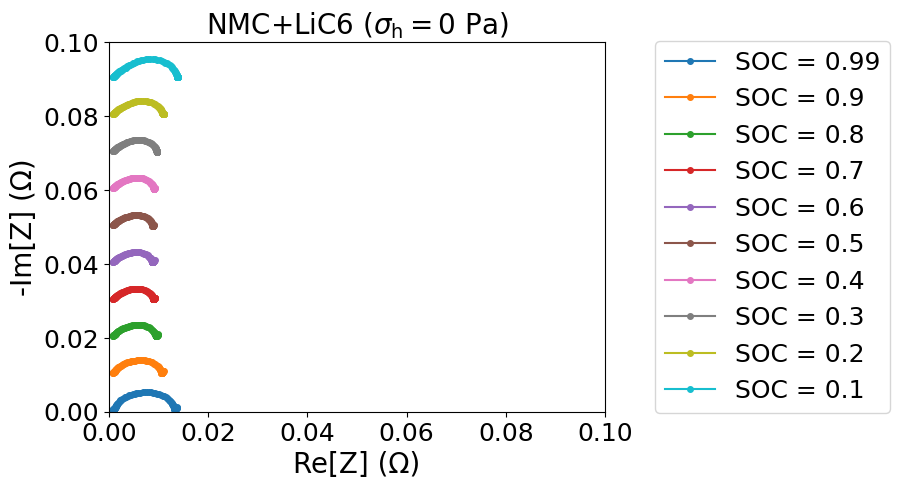

In [64]:
plt.plot(Z_0Pa_soc99[:, 1], -Z_0Pa_soc99[:, 2], marker='o', linestyle='-', linewidth=1.5, markersize=4, label="SOC = 0.99")
plt.plot(Z_0Pa_soc90[:, 1], -Z_0Pa_soc90[:, 2]+0.01, marker='o', linestyle='-', linewidth=1.5, markersize=4, label="SOC = 0.9")
plt.plot(Z_0Pa_soc80[:, 1], -Z_0Pa_soc80[:, 2]+0.02, marker='o', linestyle='-', linewidth=1.5, markersize=4, label="SOC = 0.8")
plt.plot(Z_0Pa_soc70[:, 1], -Z_0Pa_soc70[:, 2]+0.03, marker='o', linestyle='-', linewidth=1.5, markersize=4, label="SOC = 0.7")
plt.plot(Z_0Pa_soc60[:, 1], -Z_0Pa_soc60[:, 2]+0.04, marker='o', linestyle='-', linewidth=1.5, markersize=4, label="SOC = 0.6")
plt.plot(Z_0Pa_soc50[:, 1], -Z_0Pa_soc50[:, 2]+0.05, marker='o', linestyle='-', linewidth=1.5, markersize=4, label="SOC = 0.5")
plt.plot(Z_0Pa_soc40[:, 1], -Z_0Pa_soc40[:, 2]+0.06, marker='o', linestyle='-', linewidth=1.5, markersize=4, label="SOC = 0.4")
plt.plot(Z_0Pa_soc30[:, 1], -Z_0Pa_soc30[:, 2]+0.07, marker='o', linestyle='-', linewidth=1.5, markersize=4, label="SOC = 0.3")
plt.plot(Z_0Pa_soc20[:, 1], -Z_0Pa_soc20[:, 2]+0.08, marker='o', linestyle='-', linewidth=1.5, markersize=4, label="SOC = 0.2")
plt.plot(Z_0Pa_soc10[:, 1], -Z_0Pa_soc10[:, 2]+0.09, marker='o', linestyle='-', linewidth=1.5, markersize=4, label="SOC = 0.1")


# Labels and title
plt.xlabel('Re[Z] (Ω)')
plt.ylabel('-Im[Z] (Ω)')
plt.title('NMC+LiC6 ($\sigma_{\mathrm{h}}=0$ Pa)')
plt.xlim(0, 0.1)
plt.ylim(0, 0.1)

plt.legend(loc = "center right", bbox_to_anchor=(1.6, 0.5))

## Sprememba $i_0$ 

Spremenili bomo exchange current density na anodi in pogledali v katero smer se premakne DRT.
Izvedli bomo pri SOC 50%.